In [1]:
# ==============================================================================
# Step 0. [환경설정] - 한글 폰트/필수 패키지 임포트
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os
import re
from typing import Dict, List, Optional, Tuple
from math import ceil

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
try:
    matplotlib.rc('font', family='Malgun Gothic')
except:
    matplotlib.rc('font', family='AppleGothic')
matplotlib.rc('axes', unicode_minus=False)

# ==============================================================================
# Step 1. [분석 함수 정의]
# ==============================================================================
def find_header_row(file_path: str, sheet_name: str) -> int:
    """
    엑셀 시트에서 'time' 문자열이 포함된 행을 찾아 헤더로 사용될 행 번호를 반환합니다.
    """
    try:
        tmp_df = pd.read_excel(file_path, sheet_name=sheet_name, engine='openpyxl', header=None, nrows=20)
        for i, row in tmp_df.iterrows():
            if any('time' in str(cell).strip().lower() for cell in row):
                return i
    except Exception as e:
        print(f"'{sheet_name}' 시트에서 헤더를 찾는 중 오류 발생: {e}")
    return 0

def extract_bloom_sensor_table(df: pd.DataFrame, sheet_name: str, time_point: float) -> Optional[pd.DataFrame]:
    """
    주어진 데이터프레임에서 특정 시점(time_point)의 Bloom 센서 데이터를 추출하여 테이블 형태로 가공합니다.
    """
    try:
        time_col = next((col for col in df.columns if 'time' in str(col).lower()), None)
        if not time_col:
            print(f"'{sheet_name}' 시트에서 Time 컬럼을 찾을 수 없습니다.")
            return None

        df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
        if df[time_col].isna().all():
            print(f"'{sheet_name}' 시트의 Time 컬럼에 유효한 숫자 데이터가 없습니다.")
            return None
        
        time_data_row = df.iloc[df[time_col].sub(time_point).abs().idxmin()]

        rows = []
        for i in range(1, 19):
            for j in range(1, 10):
                col_name = f'Bloom {i} sensor {j}'
                if col_name in df.columns:
                    value = time_data_row.get(col_name)
                    if pd.notna(value):
                        rows.append({"Case": sheet_name, "Time": time_point, "Bloom": i, "Sensor": j, "Value": value})

        return pd.DataFrame(rows) if rows else None
    except Exception as e:
        print(f"'{sheet_name}' 시트, {time_point}초 시점 데이터 추출 중 오류: {e}")
        return None

def extract_cooling_curve_data(df: pd.DataFrame, sheet_name: str, start_time: float, duration: float) -> Optional[pd.DataFrame]:
    """
    냉각 시작 시점부터 지정된 시간 동안의 온도 변화 데이터를 추출합니다.
    """
    try:
        time_col = next((col for col in df.columns if 'time' in str(col).lower()), None)
        if not time_col: return None

        df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
        
        cooling_df = df[(df[time_col] >= start_time) & (df[time_col] <= start_time + duration)].copy()
        if cooling_df.empty: return None

        cooling_df['경과 시간(초)'] = cooling_df[time_col] - start_time
        
        sensor_cols = [col for col in df.columns if 'sensor' in str(col).lower()]
        cooling_df['평균 온도'] = cooling_df[sensor_cols].mean(axis=1)
        
        sampled_times = np.arange(0, duration + 1, 20)
        resampled_data = []
        for t in sampled_times:
            closest_row = cooling_df.iloc[cooling_df['경과 시간(초)'].sub(t).abs().idxmin()]
            resampled_data.append(closest_row)
        
        result_df = pd.DataFrame(resampled_data)[['경과 시간(초)', '평균 온도']]
        result_df['Case'] = sheet_name
        return result_df

    except Exception as e:
        print(f"'{sheet_name}'에서 냉각 곡선 데이터 추출 중 오류: {e}")
        return None


def natural_sort_key(s: str) -> tuple:
    """
    "Case 1", "Case 10", "Case 2*"와 같은 문자열을 자연스럽게 정렬하기 위한 키를 생성합니다.
    """
    match = re.match(r'Case (\d+)(.*)', s)
    if match:
        number, suffix = match.groups()
        return int(number), suffix.strip()
    return (float('inf'), s)

# ==============================================================================
# Step 1a. [데이터 로딩 및 전처리 실행]
# ==============================================================================
# --- 분석 환경 설정 ---
excel_file_path = "250718_가열로 시뮬레이션 results4_가공.xlsx"
target_temperature = 1280.0

# --- 메타데이터 정의 ---
case_meta_data = {
    'Case': [
        'Case 1', 'Case 2', 'Case 2*', 'Case 3', 'Case 4', 'Case 5', 'Case 6', 'Case 7', 'Case 8', 'Case 8 냉각',
        'Case 9', 'Case 10', 'Case 11', 'Case 11 추가', 'Case 12', 'Case 13', 'Case 13 추가', 'Case 14', 'Case 14 추가',
        'Case 15', 'Case 15 냉각', 'Case 16', 'Case 17', 'Case 18', 'Case 18 냉각', 'Case 19', 'Case 20'
    ],
    'Sheet_Name': [
        'Case 1', 'Case 2', 'Case 2"', 'Case 3', 'Case 4', 'Case 5', 'Case 6', 'Case 7', 'Case 8', 'Case 8 냉각',
        'Case 9', 'Case 10', 'Case 11', 'Case 11 추가', 'Case 12', 'Case 13', 'Case 13 추가', 'Case 14', 'Case 14 추가',
        'Case 15', 'Case 15 냉각', 'Case 16', 'Case 17', 'Case 18', 'Case 18 냉각', 'Case 19', 'Case 20'
    ],
    'Furnace': [
        'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type',
        'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type',
        'Soaking-Pit', 'Soaking-Pit', 'Soaking-Pit', 'Soaking-Pit', 'Soaking-Pit', 'Soaking-Pit', 'Soaking-Pit', 'Soaking-Pit'
    ],
    '작업방향': [
        'Longitudinal', 'Longitudinal', 'Longitudinal', 'Longitudinal', 'Longitudinal', 'Longitudinal', 'Longitudinal', 'Longitudinal', 'Longitudinal', 'Longitudinal',
        'Longitudinal', 'Longitudinal', 'Transverse', 'Transverse', 'Transverse', 'Transverse', 'Transverse', 'Transverse', 'Transverse',
        '수직 장입', '수직 장입', '수직 장입', '수직 장입', '수직 장입', '수직 장입', '수직 장입', '수직 장입'
    ],
    '적치단수': [ '2단', '2단', '2단', '1단', '2단', '2단', '2단', '2단', '1단', '1단', '2단', '2단', '2단', '2단', '1단', '2단', '2단', '2단', '2단', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X' ],
    '서포트높이': [ '250mm', '250mm', '250mm', '250mm', '250mm', '250mm', '470mm', '470mm', '470mm', '470mm', '470mm', '470mm', '250mm', '250mm', '250mm', '250mm', '250mm', '470mm', '470mm', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X' ],
    '작업방법': [ '2단(2-1)', '2단(2-5hr-1)', '2단(2-5hr-1)', '1단', '2단(2-1)', '2단(2-5hr-1)', '2단(2-1)', '2단(2-5hr-1)', '1단', '1단', '2단(2-1)', '2단(2-5hr-1)', '2단(2-1)', '2단(2-1)', '1단', '2단(2-5hr-1)', '2단(2-1)', '2단(2-1)', '2단(2-1)', '-', '-', '-', '-', '-', '-', '-', '-' ],
    '제어': [ '1Zone', '1Zone', '1Zone', '1Zone', '2Zone', '2Zone', '1Zone', '1Zone', '1Zone', '1Zone', '2Zone', '2Zone', '1Zone', '1Zone', '1Zone', '2Zone', '2Zone', '2Zone', '2Zone', '1Zone', '1Zone', '1Zone', '2Zone', '2Zone', '2Zone', '1Zone', '2Zone' ],
    '냉각': [ '-', '-', '7zone 37332초 후 온도고정', '-', '-', '-', '-', '-', '-', '대기 냉각 추가 (600초)', '-', '-', '추가 해석', '추가 해석', '-', '추가 해석', '추가 해석', '추가 해석', '추가 해석', '-', '대기 냉각 추가 (600초)', '-', '625', '-', '대기 냉각 추가 (600초)=625', '-', '-' ]
}
case_meta_df_all = pd.DataFrame(case_meta_data)

# --- 분석 대상 케이스 선택 ---
selected_cases = [
    'Case 1', 'Case 4', 'Case 5', 'Case 6', 'Case 9', 'Case 10', 
    'Case 11 추가', 'Case 13 추가', 'Case 14 추가', 
    'Case 15', 'Case 16', 'Case 17', 'Case 18', 'Case 19', 'Case 20',
    'Case 8 냉각', 'Case 15 냉각', 'Case 18 냉각'
]
case_meta_df = case_meta_df_all[case_meta_df_all['Case'].isin(selected_cases)].copy()
case_meta_df.reset_index(drop=True, inplace=True)

case_sheets = case_meta_df['Sheet_Name'].tolist()

time_points = { "4hr 시점": 47860.0, "가열완료 시점": 57382.5, "냉각완료 시점": 57382.5 + 600 }

# --- 엑셀 시트 미리 읽어오기 ---
print("엑셀 파일 로딩 시작...")
all_sheets_data = {}
if os.path.exists(excel_file_path):
    for sheet in case_sheets:
        try:
            df = pd.read_excel(excel_file_path, sheet_name=sheet, engine='openpyxl', header=find_header_row(excel_file_path, sheet))
            all_sheets_data[sheet] = df
        except Exception as e:
            print(f"'{sheet}' 시트 로딩 실패: {e}")
else:
    print(f"오류: 엑셀 파일을 찾을 수 없습니다 - {excel_file_path}")

print(f"엑셀 파일 로딩 완료. ({len(all_sheets_data)}/{len(case_sheets)} 시트)")

# --- 데이터 추출 및 병합 ---
if all_sheets_data:
    print("데이터 추출 및 가공 시작...")
    bloom_sensor_all = []
    cooling_curve_all = []
    long_heating_cases = case_meta_df[case_meta_df['작업방법'].str.contains('2-5hr', na=False)]['Sheet_Name'].tolist()
    special_completion_time = 75382.5

    for sheet, df in all_sheets_data.items():
        meta_info = case_meta_df[case_meta_df['Sheet_Name'] == sheet].iloc[0]
        heat_time = special_completion_time if sheet in long_heating_cases else time_points["가열완료 시점"]
        
        for time_desc, time_val in [("4hr 시점", time_points["4hr 시점"]), ("가열완료 시점", heat_time)]:
            result = extract_bloom_sensor_table(df, sheet, time_val)
            if result is not None:
                result["TimeDesc"] = time_desc
                bloom_sensor_all.append(result)

        is_cooling_case = '냉각' in meta_info['Case']
        if is_cooling_case:
            curve_data = extract_cooling_curve_data(df, meta_info['Case'], 0, 600)
            if curve_data is not None:
                cooling_curve_all.append(curve_data)

    if bloom_sensor_all:
        bloom_sensor_df = pd.concat(bloom_sensor_all, ignore_index=True)
        bloom_sensor_df.rename(columns={'Case': 'Sheet_Name'}, inplace=True)
        bloom_sensor_df = pd.merge(bloom_sensor_df, case_meta_df, on="Sheet_Name")

        summary_cols = ['Case', 'TimeDesc', 'Bloom', 'Furnace', '작업방향', '서포트높이', '제어', '적치단수', '작업방법']
        bloom_summary = (
            bloom_sensor_df.groupby([col for col in summary_cols if col in bloom_sensor_df.columns])
            .agg(평균=('Value', 'mean'), 내부ΔT=('Value', lambda x: np.nanmax(x) - np.nanmin(x) if x.notna().any() else np.nan))
            .reset_index()
        )
        
        cooling_case_names = case_meta_df[case_meta_df['Case'].str.contains('냉각')]['Case'].tolist()
        heating_summary = bloom_summary[~bloom_summary['Case'].isin(cooling_case_names)]
        heating_sensor_df = bloom_sensor_df[~bloom_sensor_df['Case'].isin(cooling_case_names)]
        
        print("데이터 준비 완료.")
    else:
        print("추출된 데이터가 없어 분석을 진행할 수 없습니다.")


엑셀 파일 로딩 시작...
엑셀 파일 로딩 완료. (18/18 시트)
데이터 추출 및 가공 시작...
데이터 준비 완료.



[냉각 완료 케이스 분석]


c:\python_study\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\python_study\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\python_study\venv\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\python_study\venv\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_

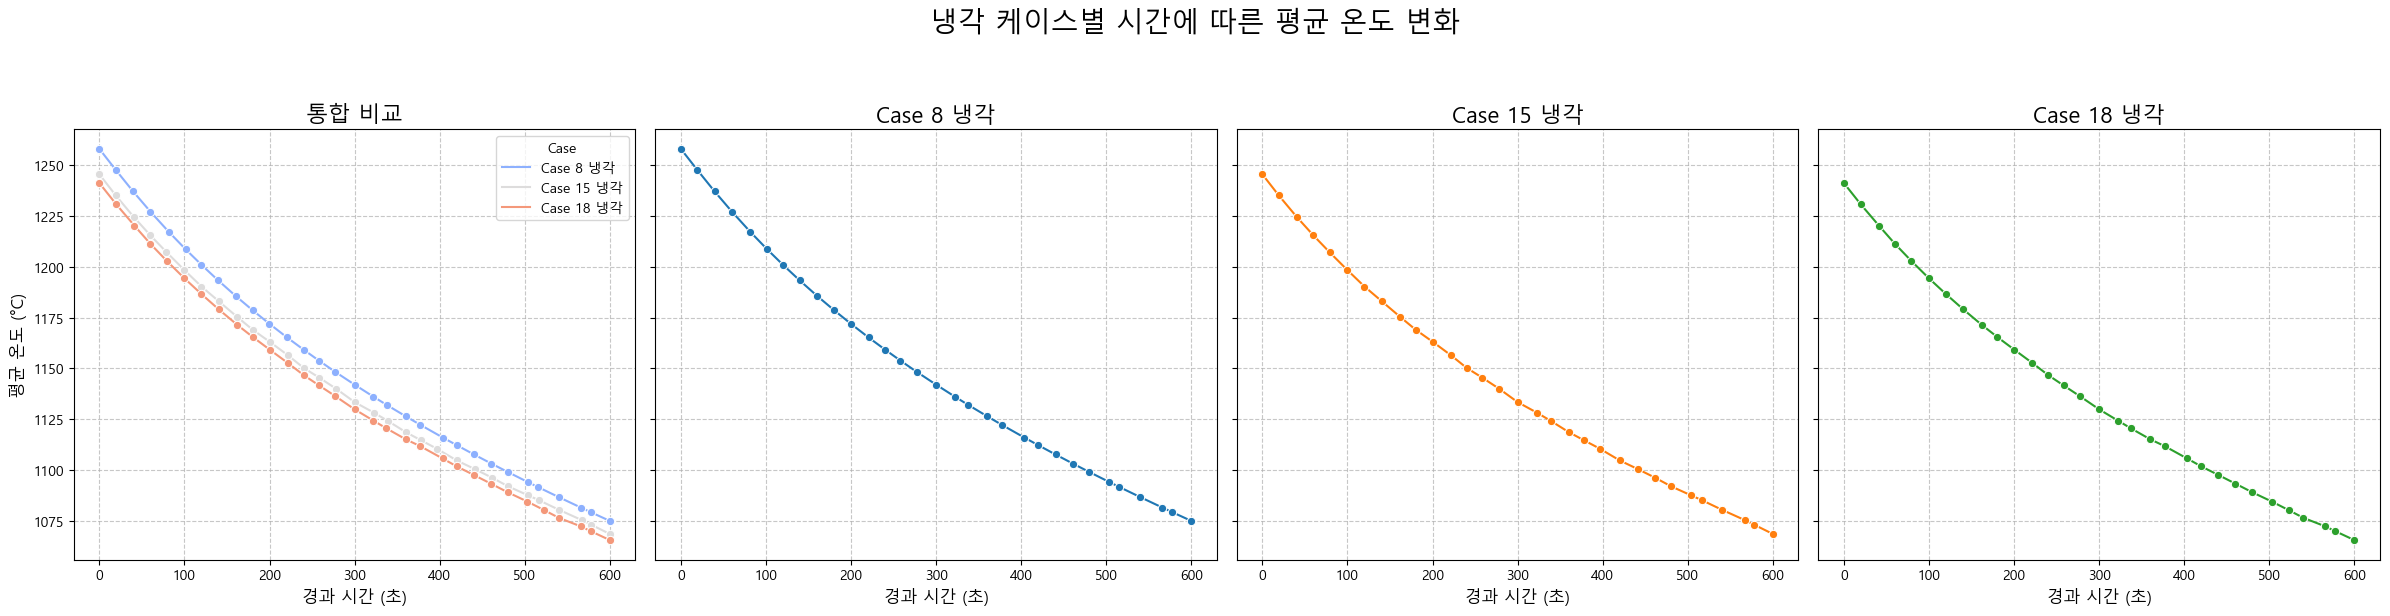

In [6]:
# ==============================================================================
# Step 3a. [냉각 케이스 분석 실행]
# ==============================================================================
if 'cooling_curve_all' in locals() and cooling_curve_all:
    print("\n" + "="*50 + "\n[냉각 완료 케이스 분석]\n" + "="*50)
    cooling_curve_df = pd.concat(cooling_curve_all, ignore_index=True)
    plot_cooling_curves(cooling_curve_df)
else:
    print("\n" + "="*50 + "\n[냉각 완료 케이스 분석]\n" + "="*50)
    print("분석 대상에 냉각 케이스가 없거나 데이터 추출에 실패했습니다.")



[Case 1 - 4hr 시점] 상세 분석


c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


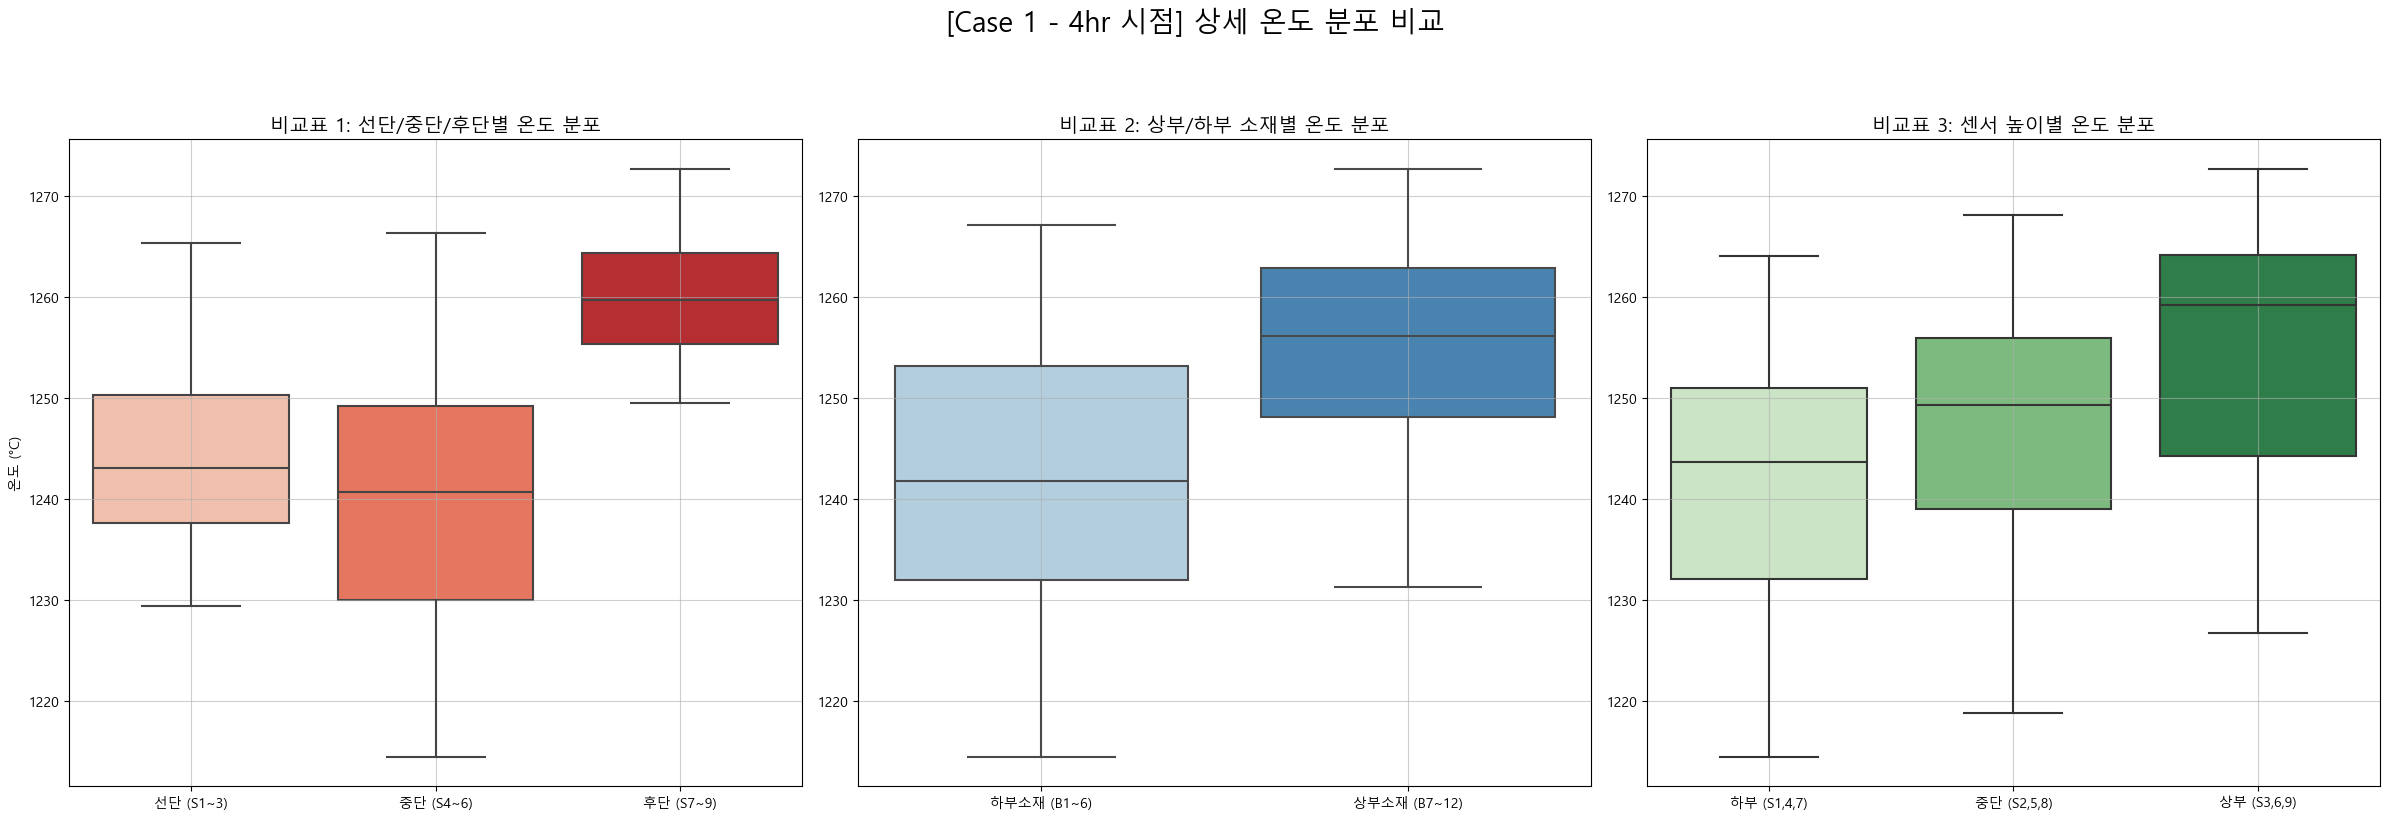

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean   std     min     25%     50%     75%     max
위치 (선/중/후)                                                             
선단 (S1~3)   36.00 1244.86  9.72 1229.44 1237.62 1243.02 1250.28 1265.34
중단 (S4~6)   36.00 1240.17 13.77 1214.47 1229.99 1240.66 1249.20 1266.32
후단 (S7~9)   36.00 1260.29  6.28 1249.52 1255.37 1259.70 1264.36 1272.69

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean   std     min     25%     50%     75%     max
소재 위치 (상/하)                                                              
상부소재 (B7~12)  54.00 1254.94 10.16 1231.30 1248.12 1256.09 1262.87 1272.69
하부소재 (B1~6)   54.00 1241.94 13.22 1214.47 1231.95 1241.81 1253.19 1267.06

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean   std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                             
상부 (S3,6,9)    36.00 

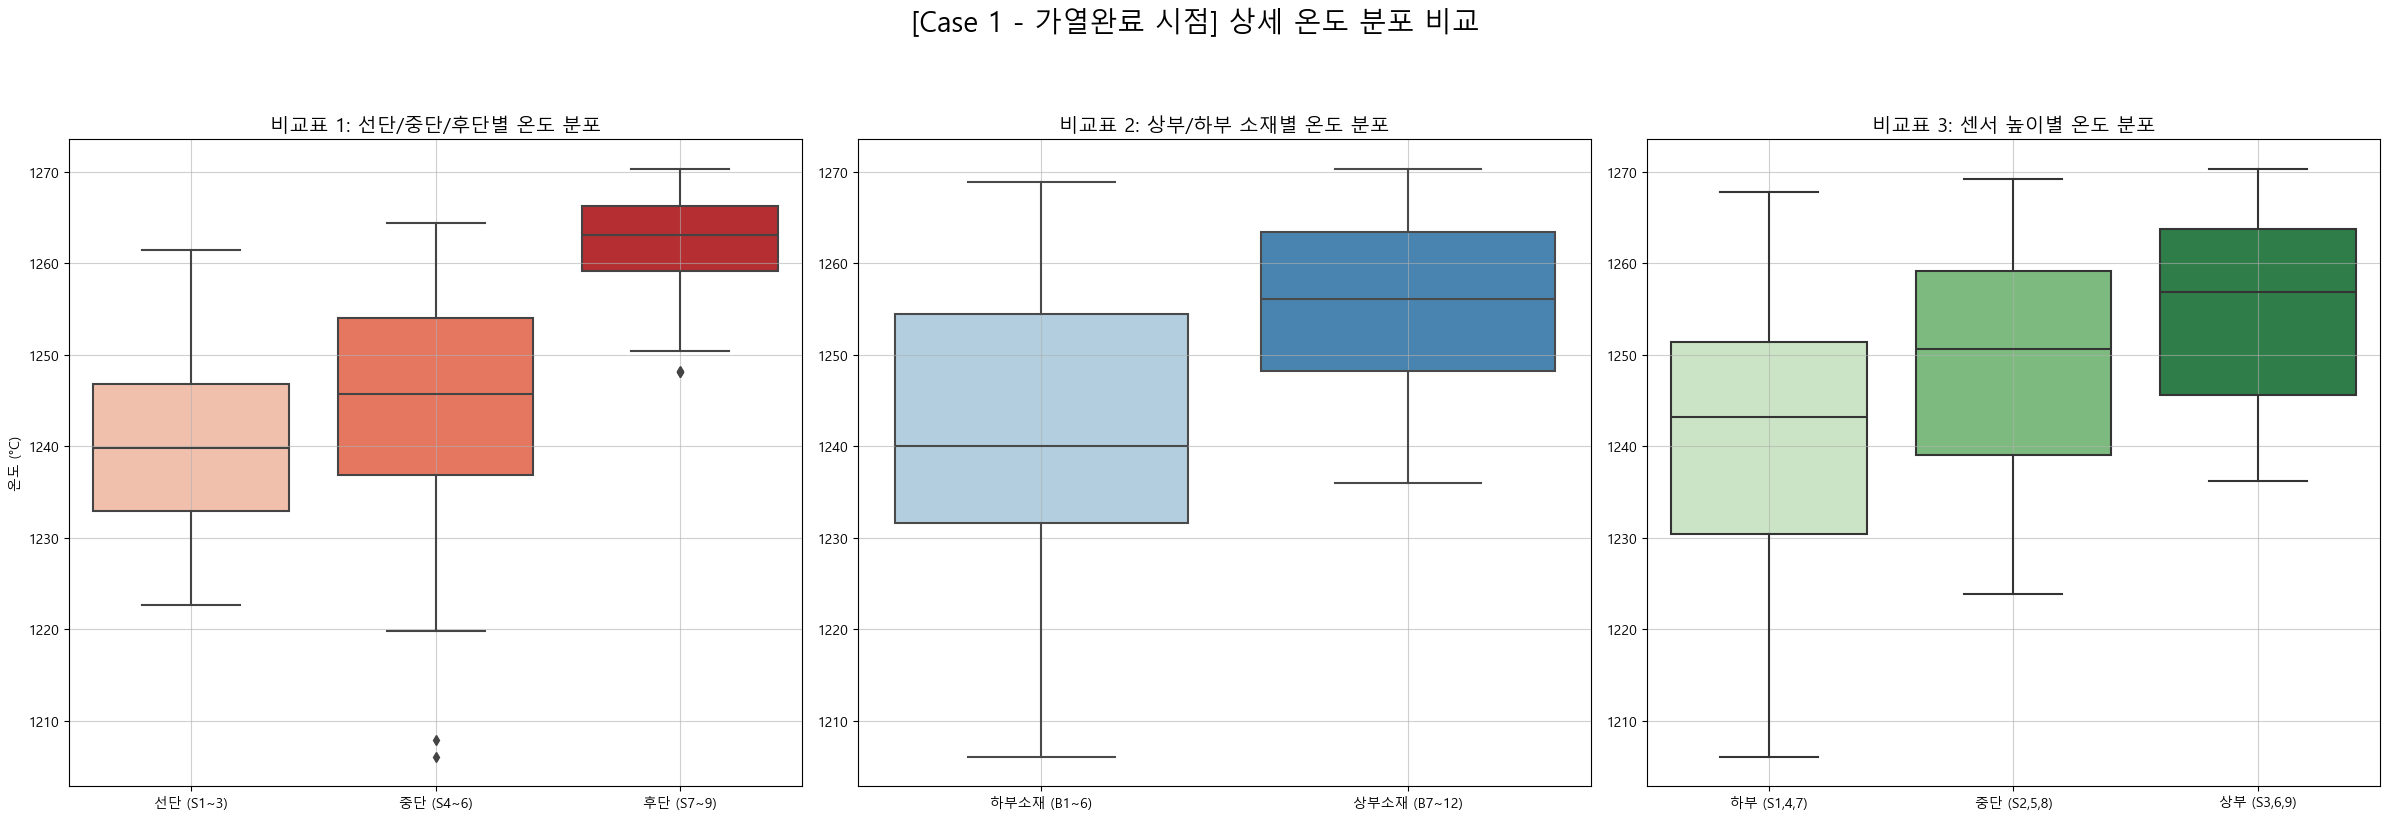

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean   std     min     25%     50%     75%     max
위치 (선/중/후)                                                             
선단 (S1~3)   36.00 1240.32 10.16 1222.70 1232.91 1239.84 1246.81 1261.42
중단 (S4~6)   36.00 1243.12 14.23 1206.08 1236.82 1245.73 1254.00 1264.40
후단 (S7~9)   36.00 1261.78  6.16 1248.07 1259.10 1263.12 1266.22 1270.32

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean   std     min     25%     50%     75%     max
소재 위치 (상/하)                                                              
상부소재 (B7~12)  54.00 1255.19  9.57 1235.94 1248.23 1256.05 1263.42 1270.32
하부소재 (B1~6)   54.00 1241.62 15.05 1206.08 1231.65 1240.07 1254.43 1268.82

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean   std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                             
상부 (S3,6,9)    36.00 

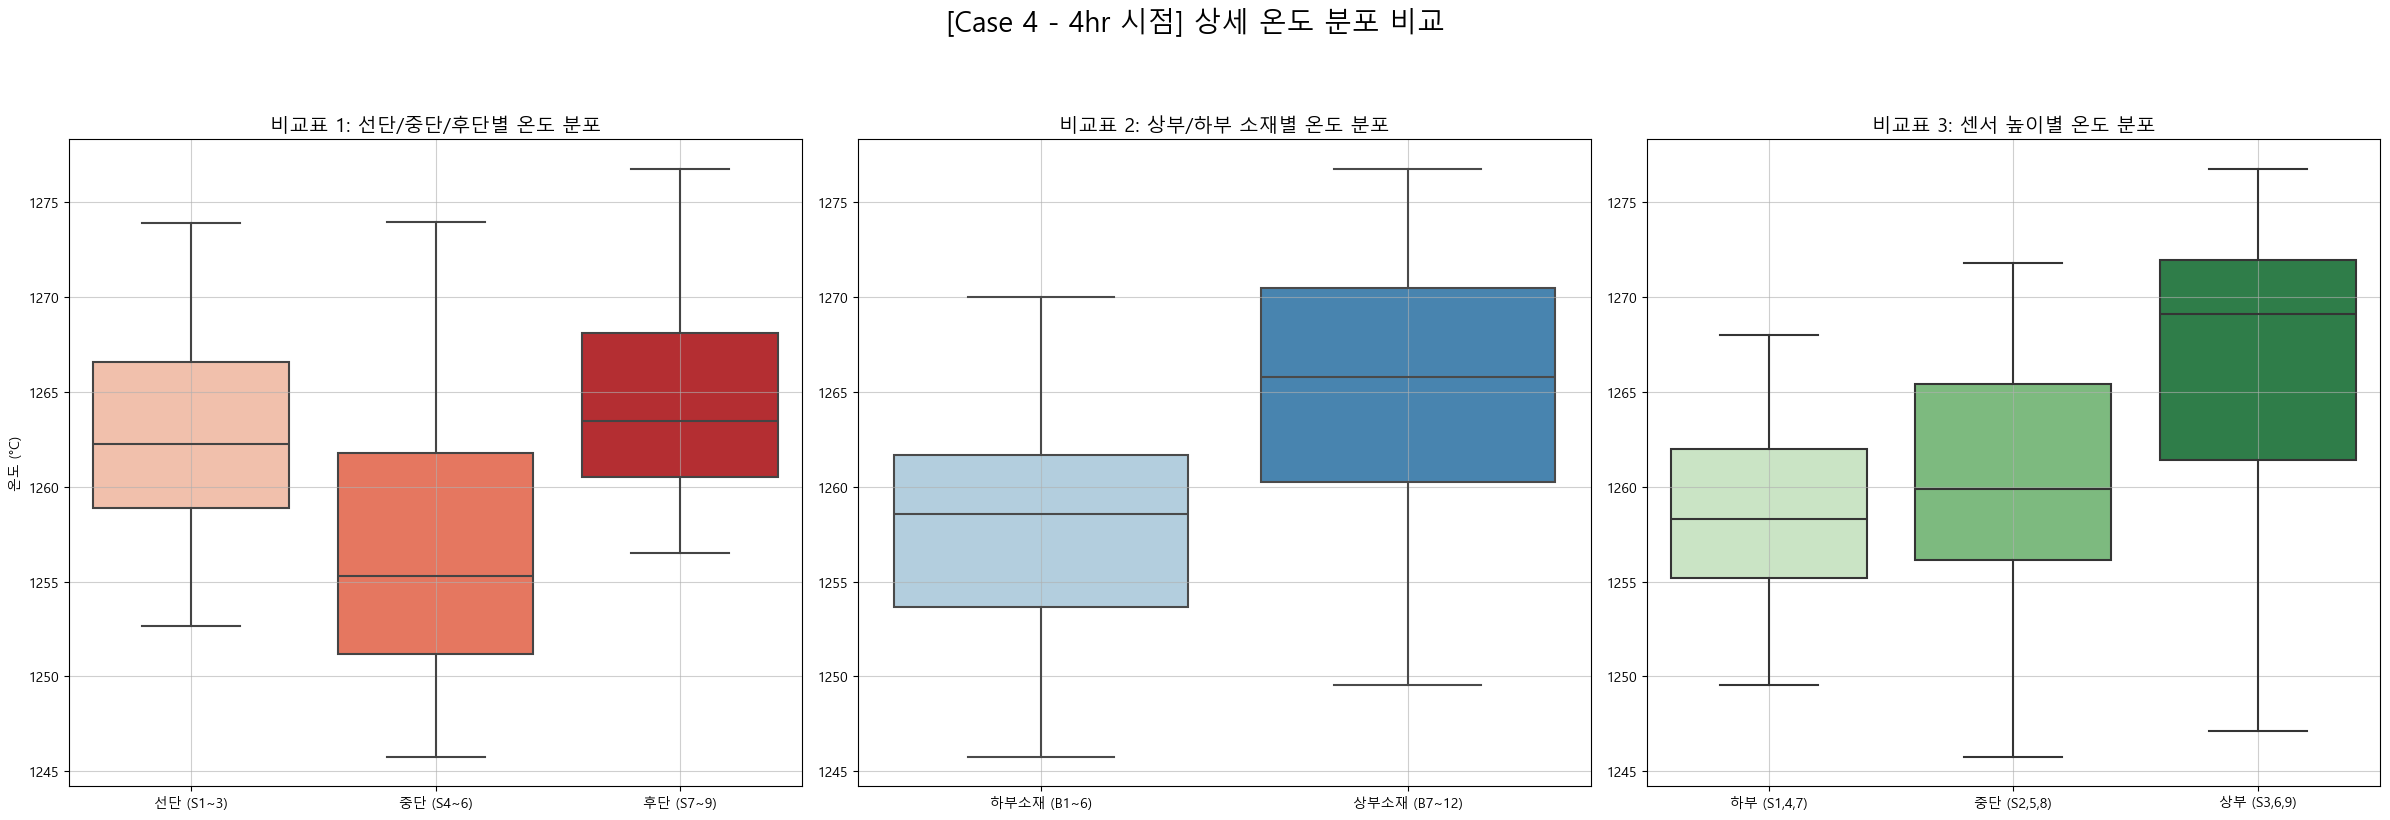

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1262.77 5.72 1252.63 1258.90 1262.27 1266.58 1273.89
중단 (S4~6)   36.00 1256.95 7.90 1245.76 1251.17 1255.26 1261.79 1273.96
후단 (S7~9)   36.00 1264.70 5.71 1256.52 1260.53 1263.47 1268.11 1276.76

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                             
상부소재 (B7~12)  54.00 1265.23 6.82 1249.56 1260.23 1265.76 1270.45 1276.76
하부소재 (B1~6)   54.00 1257.72 5.59 1245.76 1253.63 1258.54 1261.69 1269.97

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    36.00 1265.72 8.1

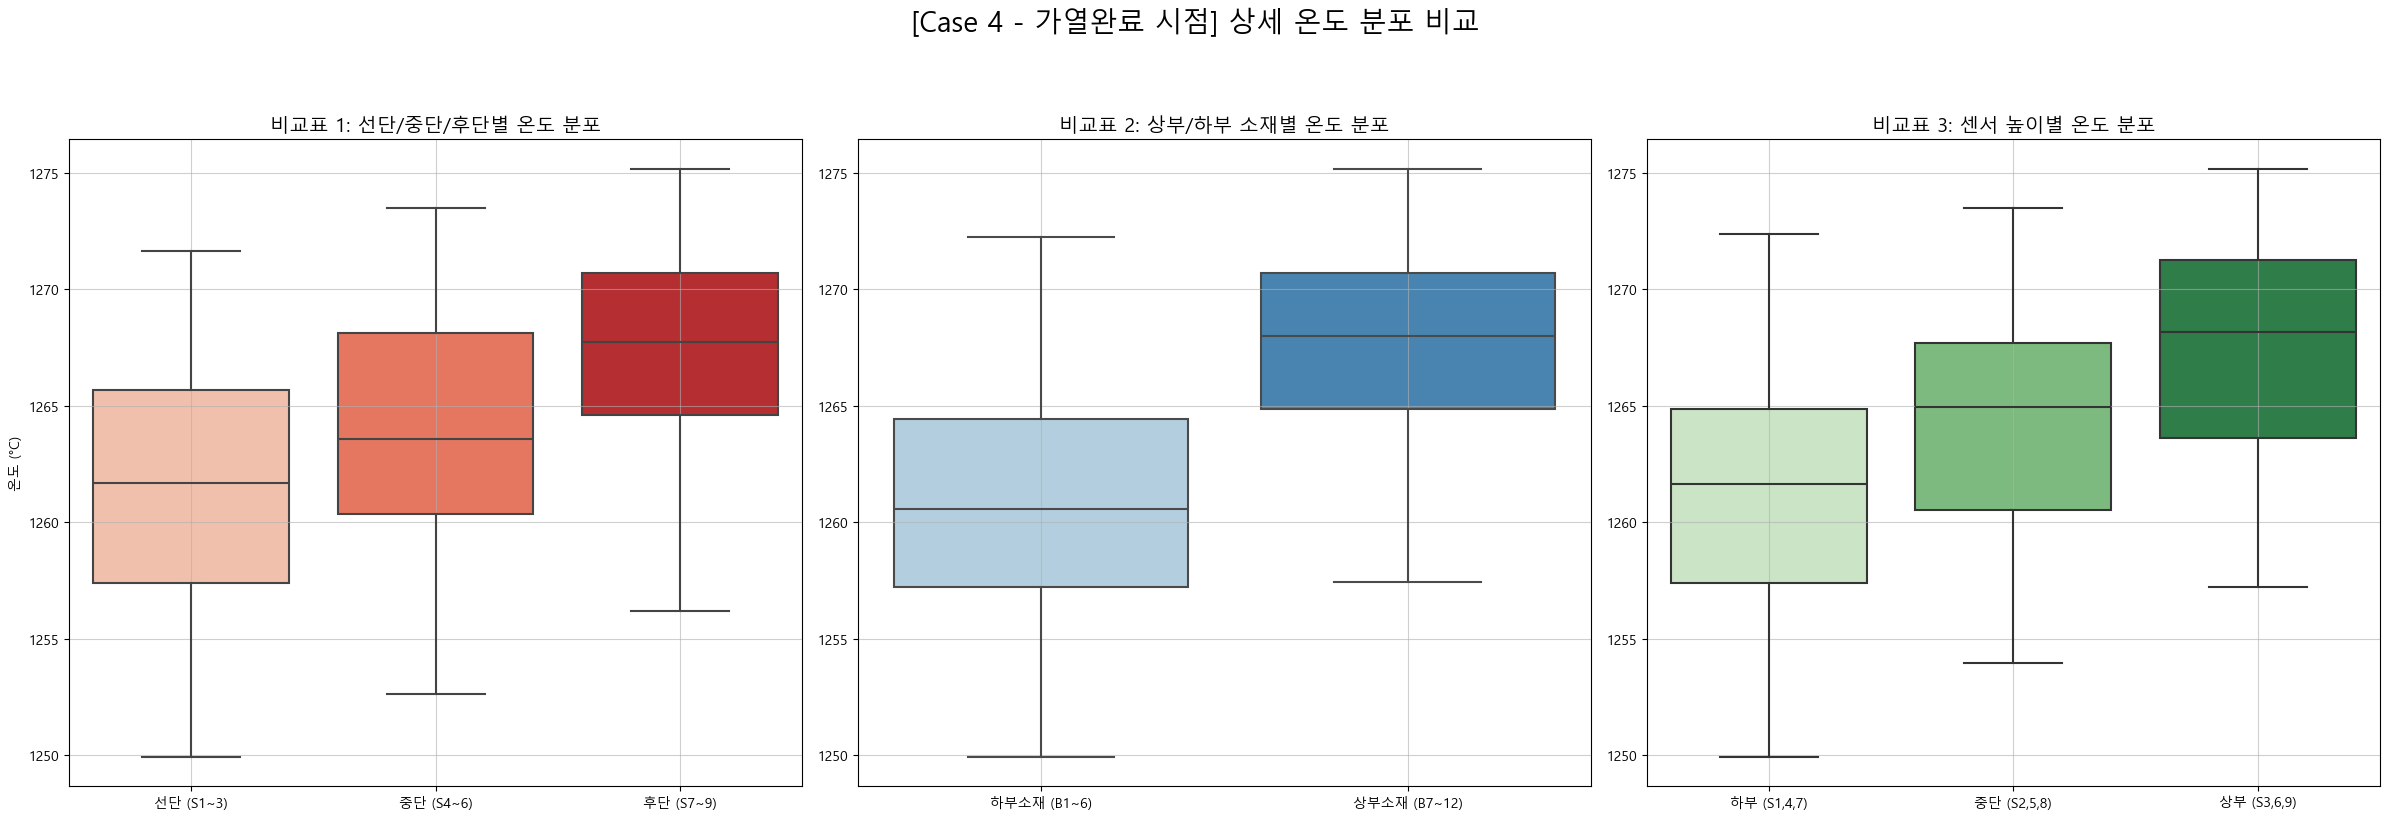

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1261.58 5.54 1249.92 1257.40 1261.70 1265.67 1271.66
중단 (S4~6)   36.00 1263.81 5.45 1252.61 1260.36 1263.57 1268.14 1273.48
후단 (S7~9)   36.00 1267.38 4.67 1256.19 1264.61 1267.75 1270.70 1275.19

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                             
상부소재 (B7~12)  54.00 1267.68 4.09 1257.44 1264.87 1267.99 1270.69 1275.19
하부소재 (B1~6)   54.00 1260.84 5.03 1249.92 1257.22 1260.59 1264.45 1272.26

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    36.00 1267.46 4.8

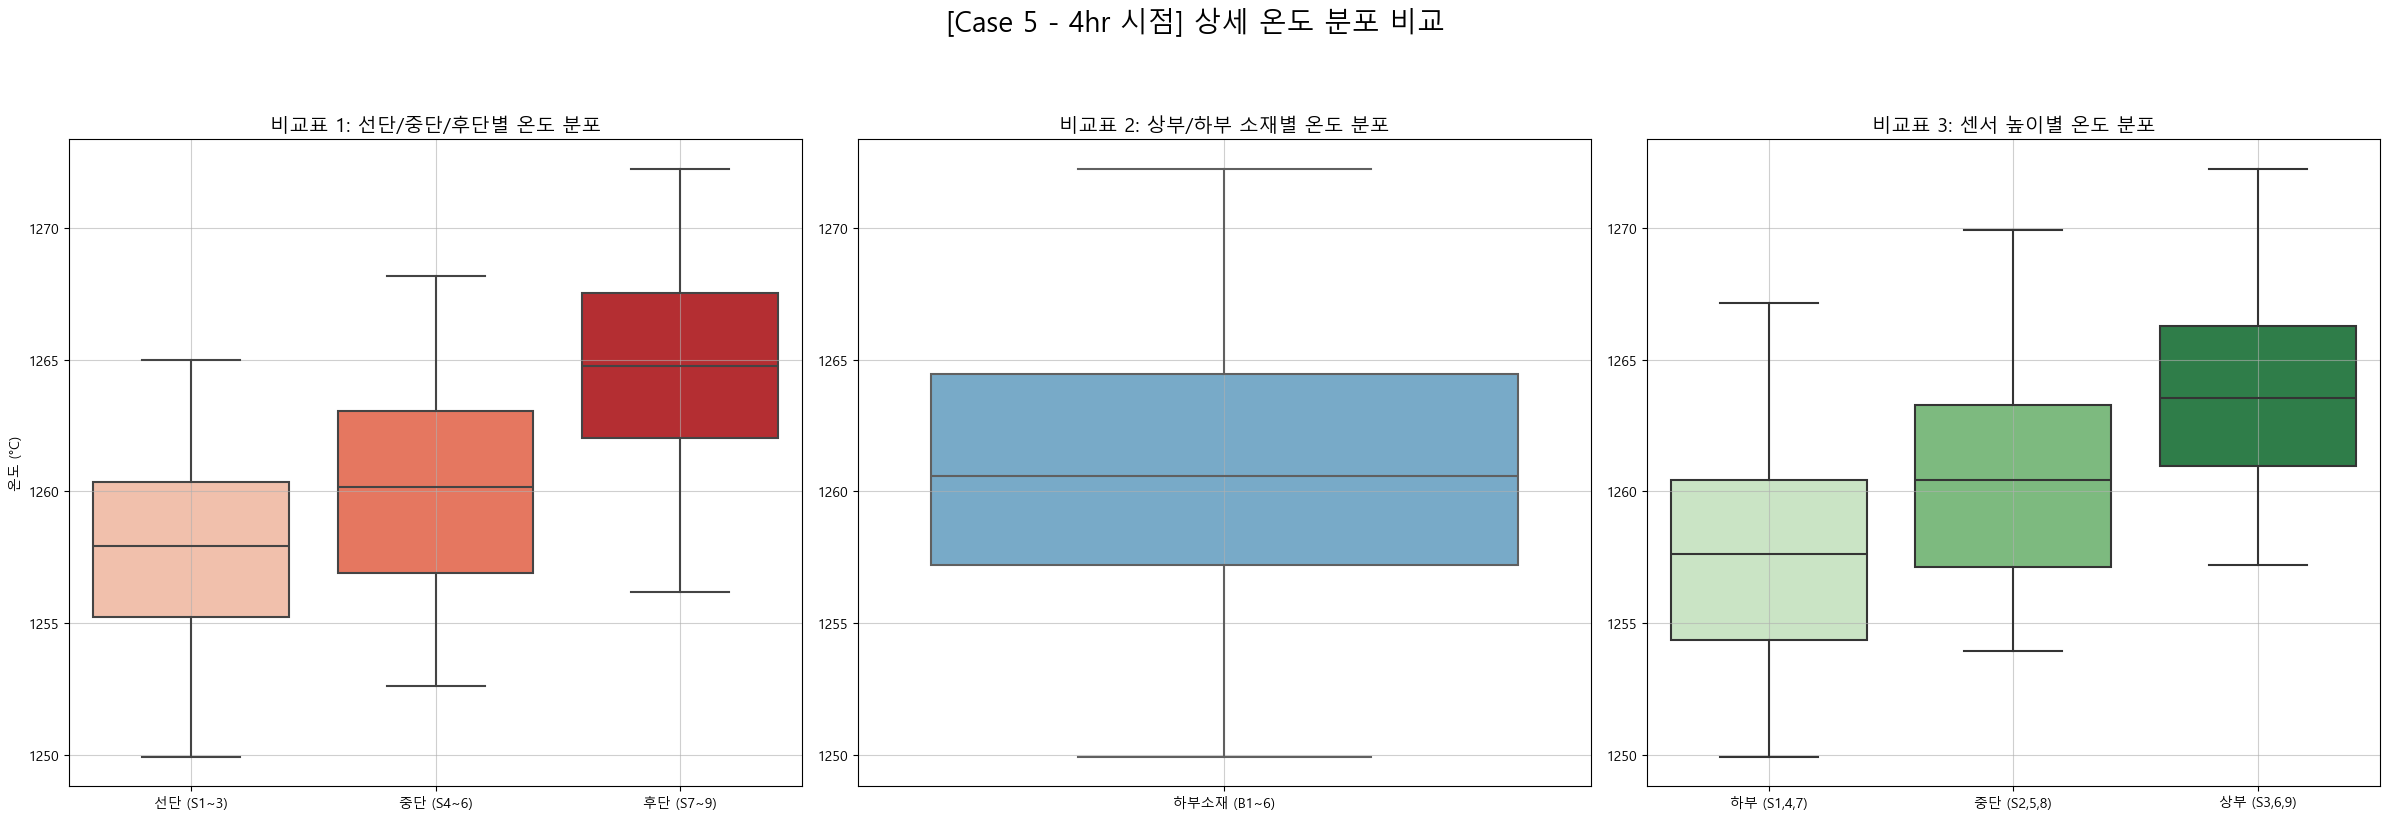

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   18.00 1257.82 4.13 1249.92 1255.22 1257.93 1260.37 1264.99
중단 (S4~6)   18.00 1260.07 4.23 1252.61 1256.89 1260.15 1263.05 1268.19
후단 (S7~9)   18.00 1264.62 4.31 1256.19 1262.02 1264.76 1267.54 1272.26

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

             count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                            
하부소재 (B1~6)  54.00 1260.84 5.03 1249.92 1257.22 1260.59 1264.45 1272.26

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    18.00 1263.95 4.09 1257.20 1260.97 1263.57 1266.27 1272.26
중단 (S2,5,8)    18.00 1260.78 4.46 

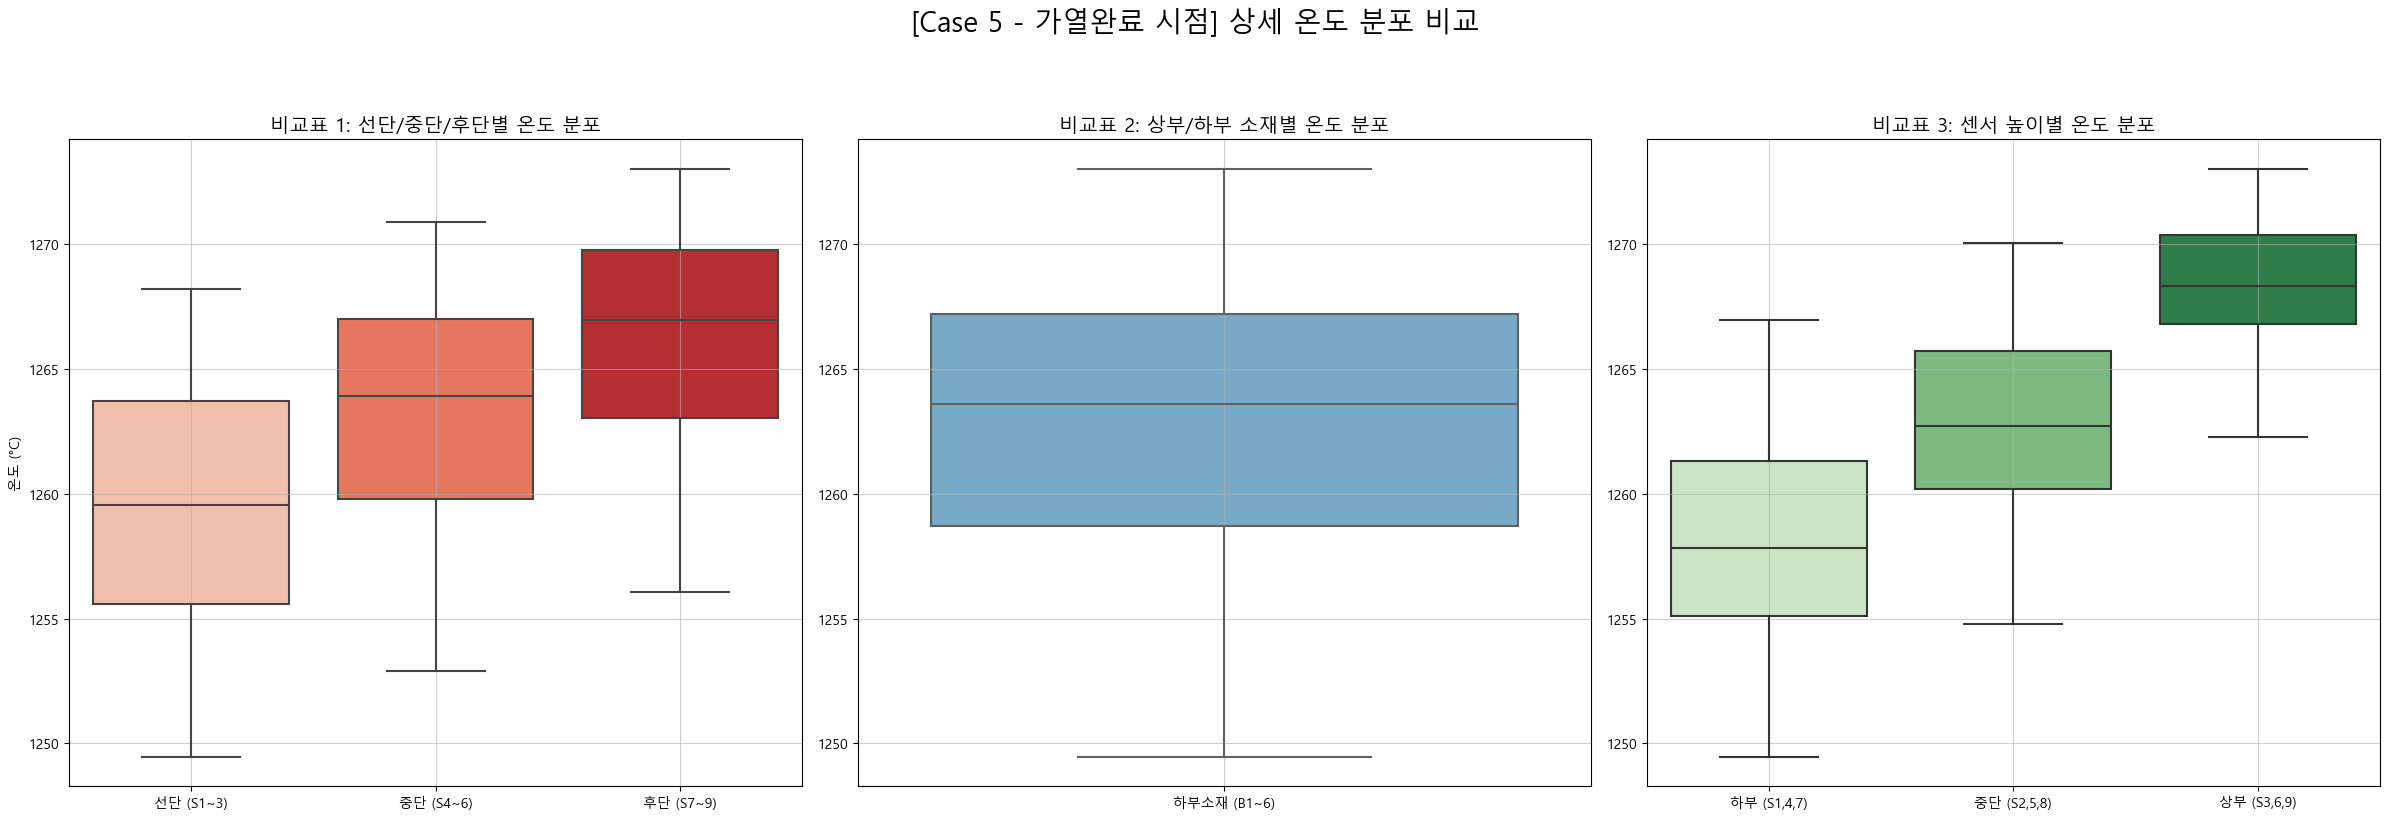

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   18.00 1259.66 5.62 1249.46 1255.59 1259.54 1263.74 1268.20
중단 (S4~6)   18.00 1263.36 5.27 1252.89 1259.79 1263.92 1267.03 1270.88
후단 (S7~9)   18.00 1266.07 4.81 1256.08 1263.03 1266.99 1269.77 1273.04

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

             count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                            
하부소재 (B1~6)  54.00 1263.03 5.79 1249.46 1258.71 1263.62 1267.20 1273.04

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    18.00 1268.26 2.89 1262.27 1266.80 1268.32 1270.38 1273.04
중단 (S2,5,8)    18.00 1262.77 4.22 

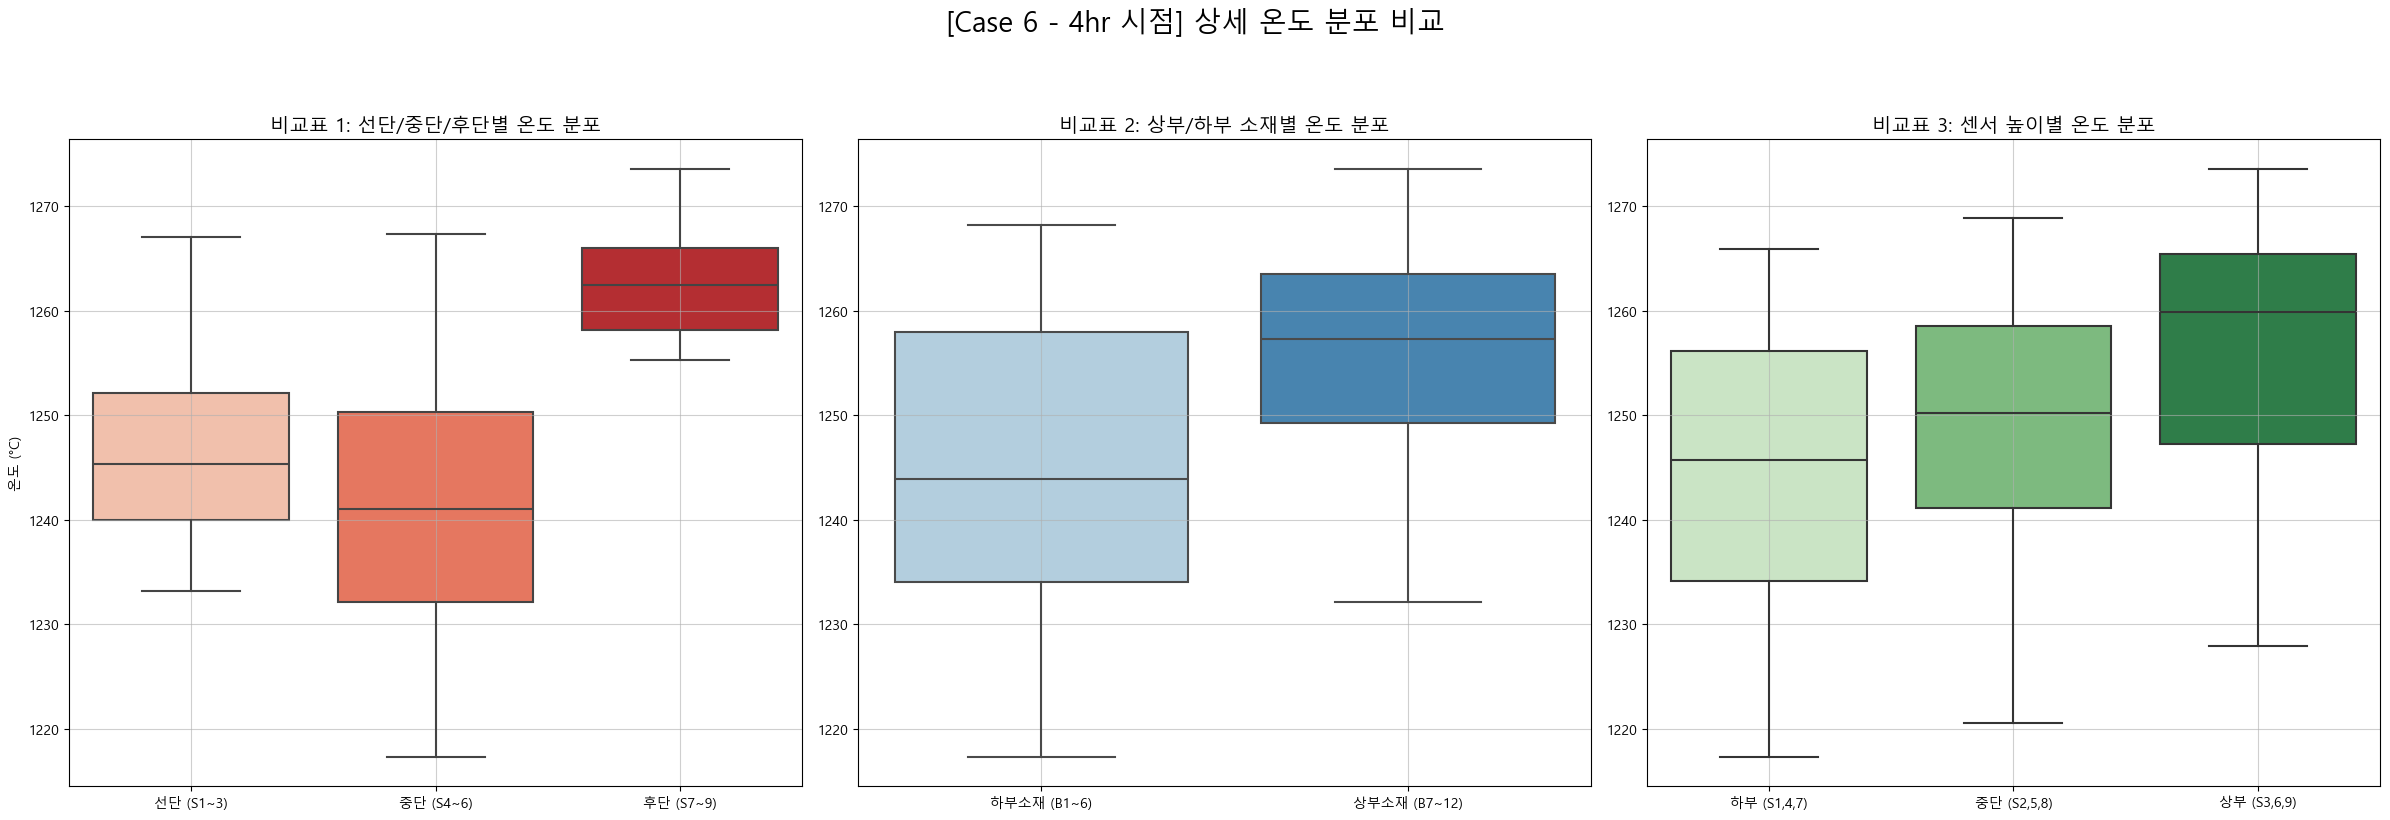

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean   std     min     25%     50%     75%     max
위치 (선/중/후)                                                             
선단 (S1~3)   36.00 1247.03  9.04 1233.15 1239.96 1245.36 1252.13 1267.03
중단 (S4~6)   36.00 1241.35 13.28 1217.30 1232.09 1240.99 1250.35 1267.40
후단 (S7~9)   36.00 1262.74  4.96 1255.30 1258.20 1262.43 1265.99 1273.62

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean   std     min     25%     50%     75%     max
소재 위치 (상/하)                                                              
상부소재 (B7~12)  54.00 1255.89 10.10 1232.17 1249.31 1257.34 1263.48 1273.62
하부소재 (B1~6)   54.00 1244.85 13.76 1217.30 1234.05 1243.88 1258.01 1268.19

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean   std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                             
상부 (S3,6,9)    36.00 

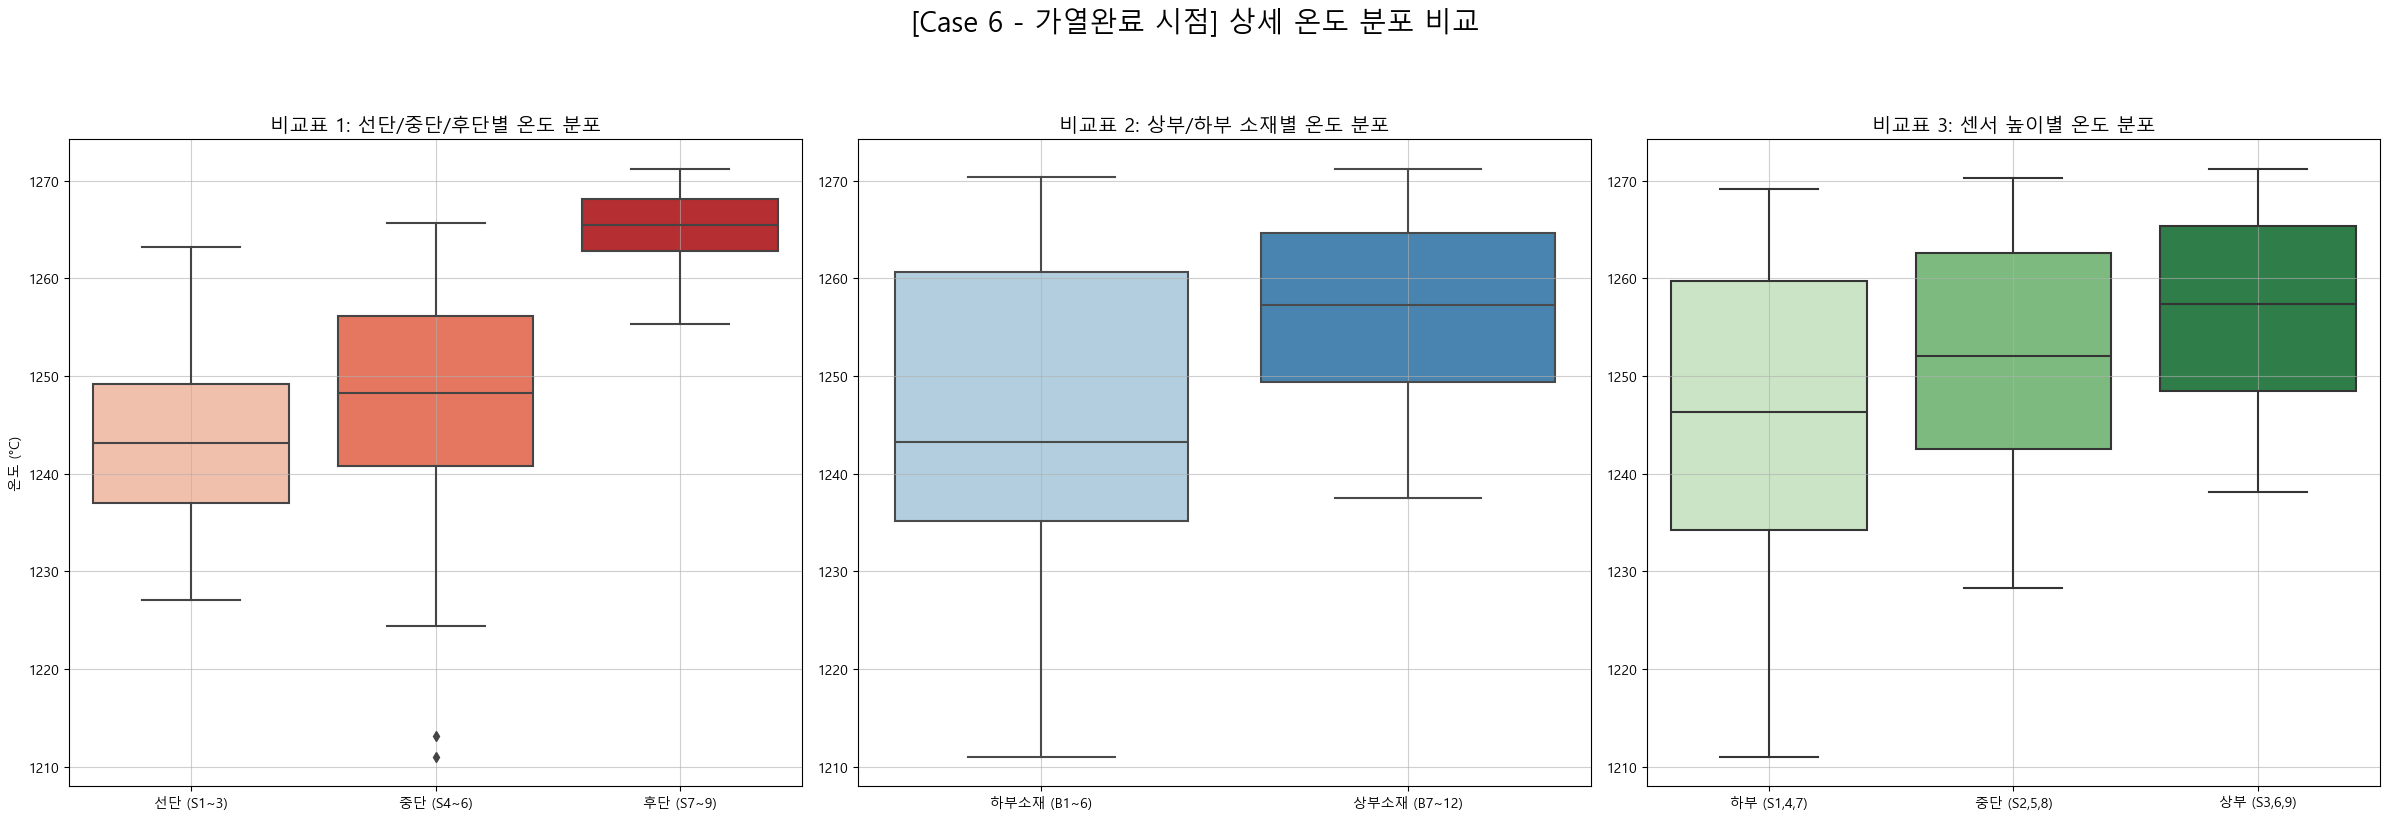

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean   std     min     25%     50%     75%     max
위치 (선/중/후)                                                             
선단 (S1~3)   36.00 1242.94  9.25 1227.03 1236.97 1243.14 1249.21 1263.20
중단 (S4~6)   36.00 1245.92 13.00 1210.99 1240.83 1248.26 1256.17 1265.71
후단 (S7~9)   36.00 1265.13  3.85 1255.32 1262.81 1265.49 1268.16 1271.25

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean   std     min     25%     50%     75%     max
소재 위치 (상/하)                                                              
상부소재 (B7~12)  54.00 1256.74  9.26 1237.50 1249.37 1257.26 1264.70 1271.25
하부소재 (B1~6)   54.00 1245.91 15.14 1210.99 1235.12 1243.21 1260.69 1270.34

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean   std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                             
상부 (S3,6,9)    36.00 

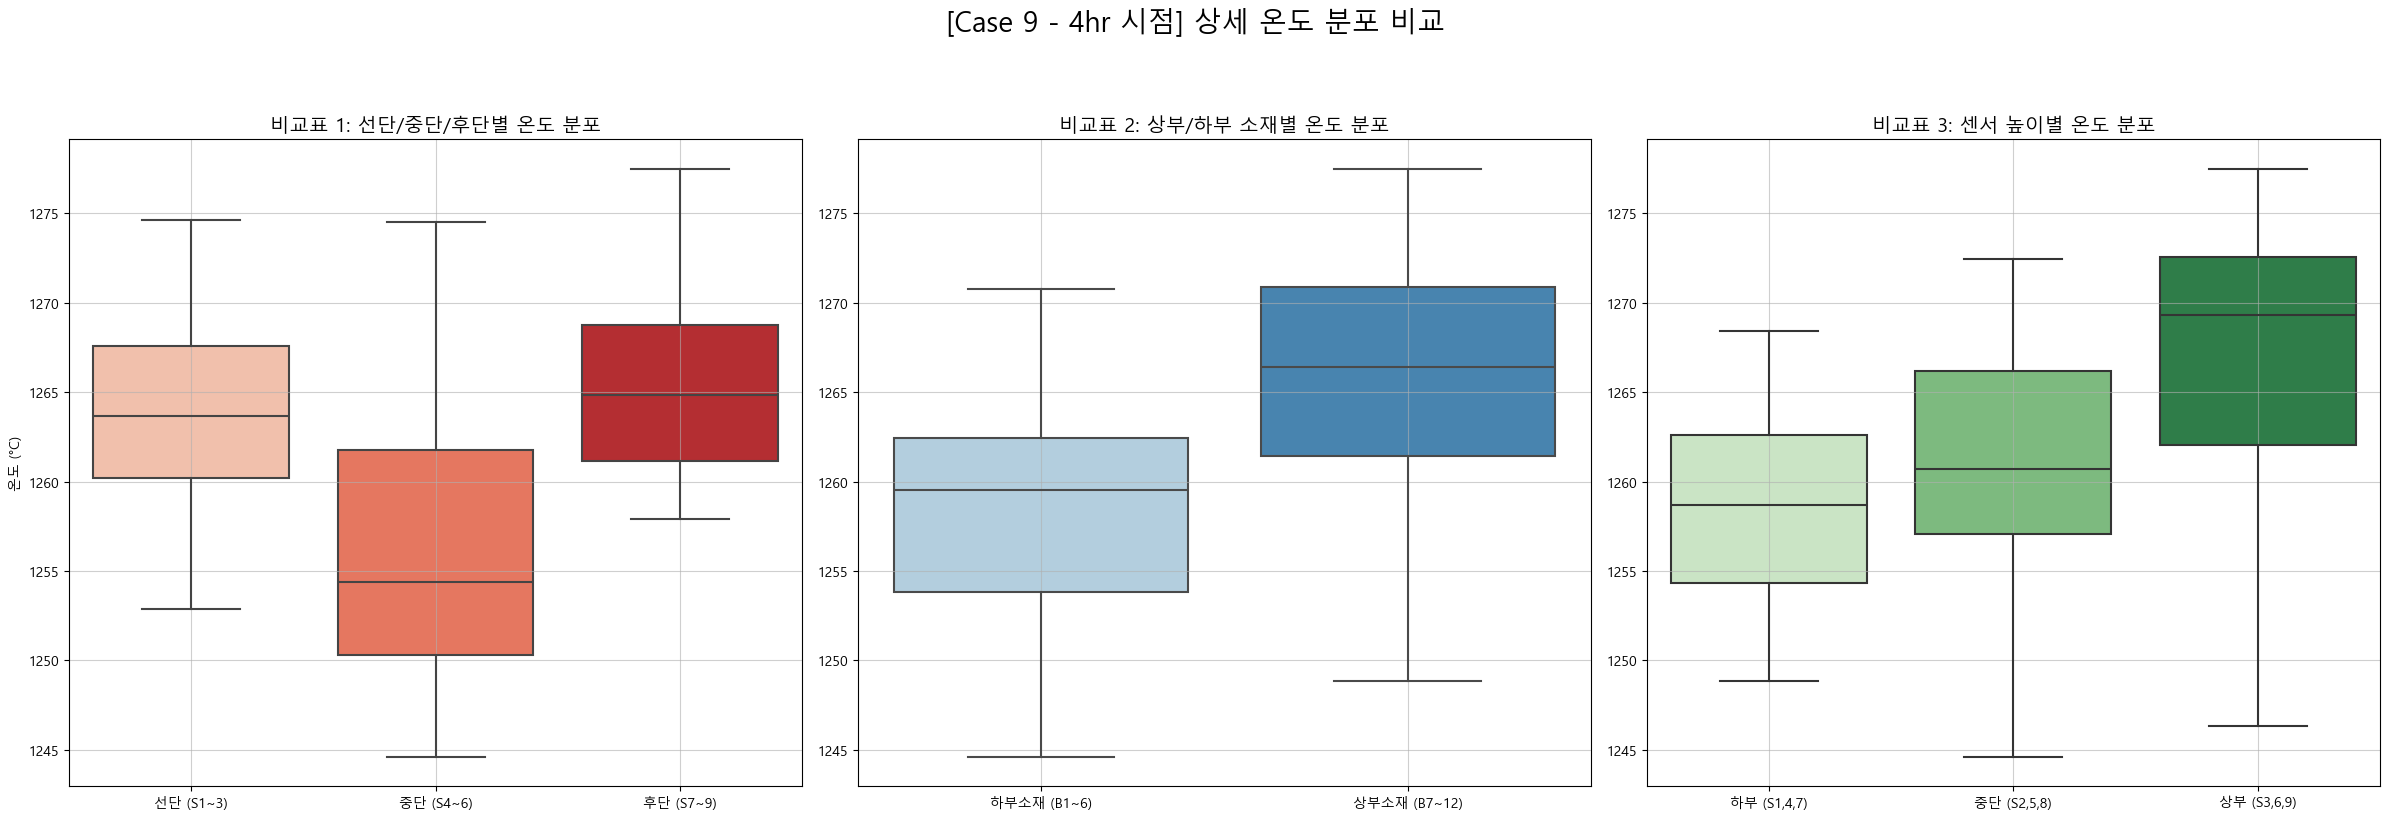

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1263.76 5.74 1252.86 1260.19 1263.64 1267.59 1274.62
중단 (S4~6)   36.00 1256.53 8.39 1244.61 1250.32 1254.37 1261.78 1274.51
후단 (S7~9)   36.00 1265.64 5.57 1257.89 1261.13 1264.83 1268.73 1277.49

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                             
상부소재 (B7~12)  54.00 1265.72 7.13 1248.86 1261.40 1266.38 1270.86 1277.49
하부소재 (B1~6)   54.00 1258.24 6.38 1244.61 1253.81 1259.54 1262.43 1270.74

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    36.00 1266.31 8.4

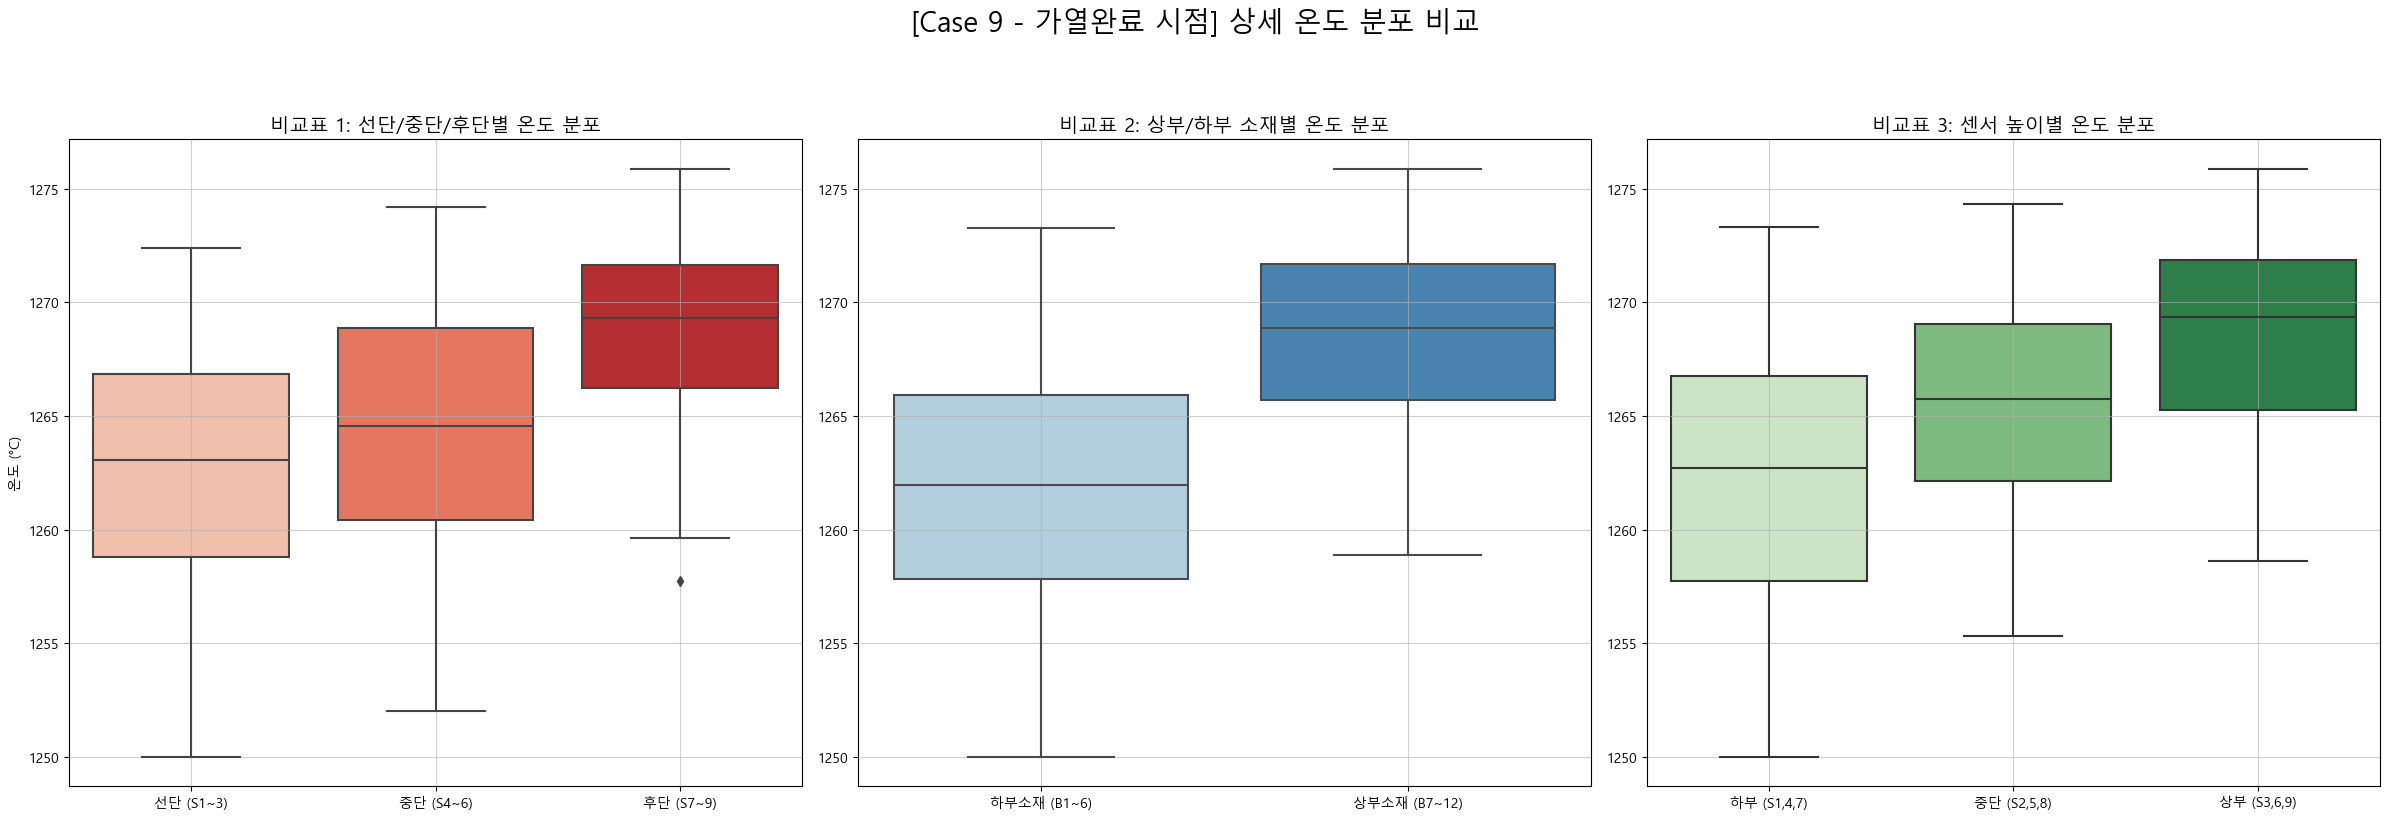

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1262.65 5.63 1250.00 1258.82 1263.07 1266.84 1272.40
중단 (S4~6)   36.00 1264.33 5.73 1252.01 1260.41 1264.55 1268.89 1274.19
후단 (S7~9)   36.00 1268.71 4.37 1257.73 1266.23 1269.30 1271.64 1275.89

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                             
상부소재 (B7~12)  54.00 1268.61 3.91 1258.88 1265.72 1268.87 1271.67 1275.89
하부소재 (B1~6)   54.00 1261.85 5.47 1250.00 1257.84 1261.99 1265.91 1273.26

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    36.00 1268.43 4.6

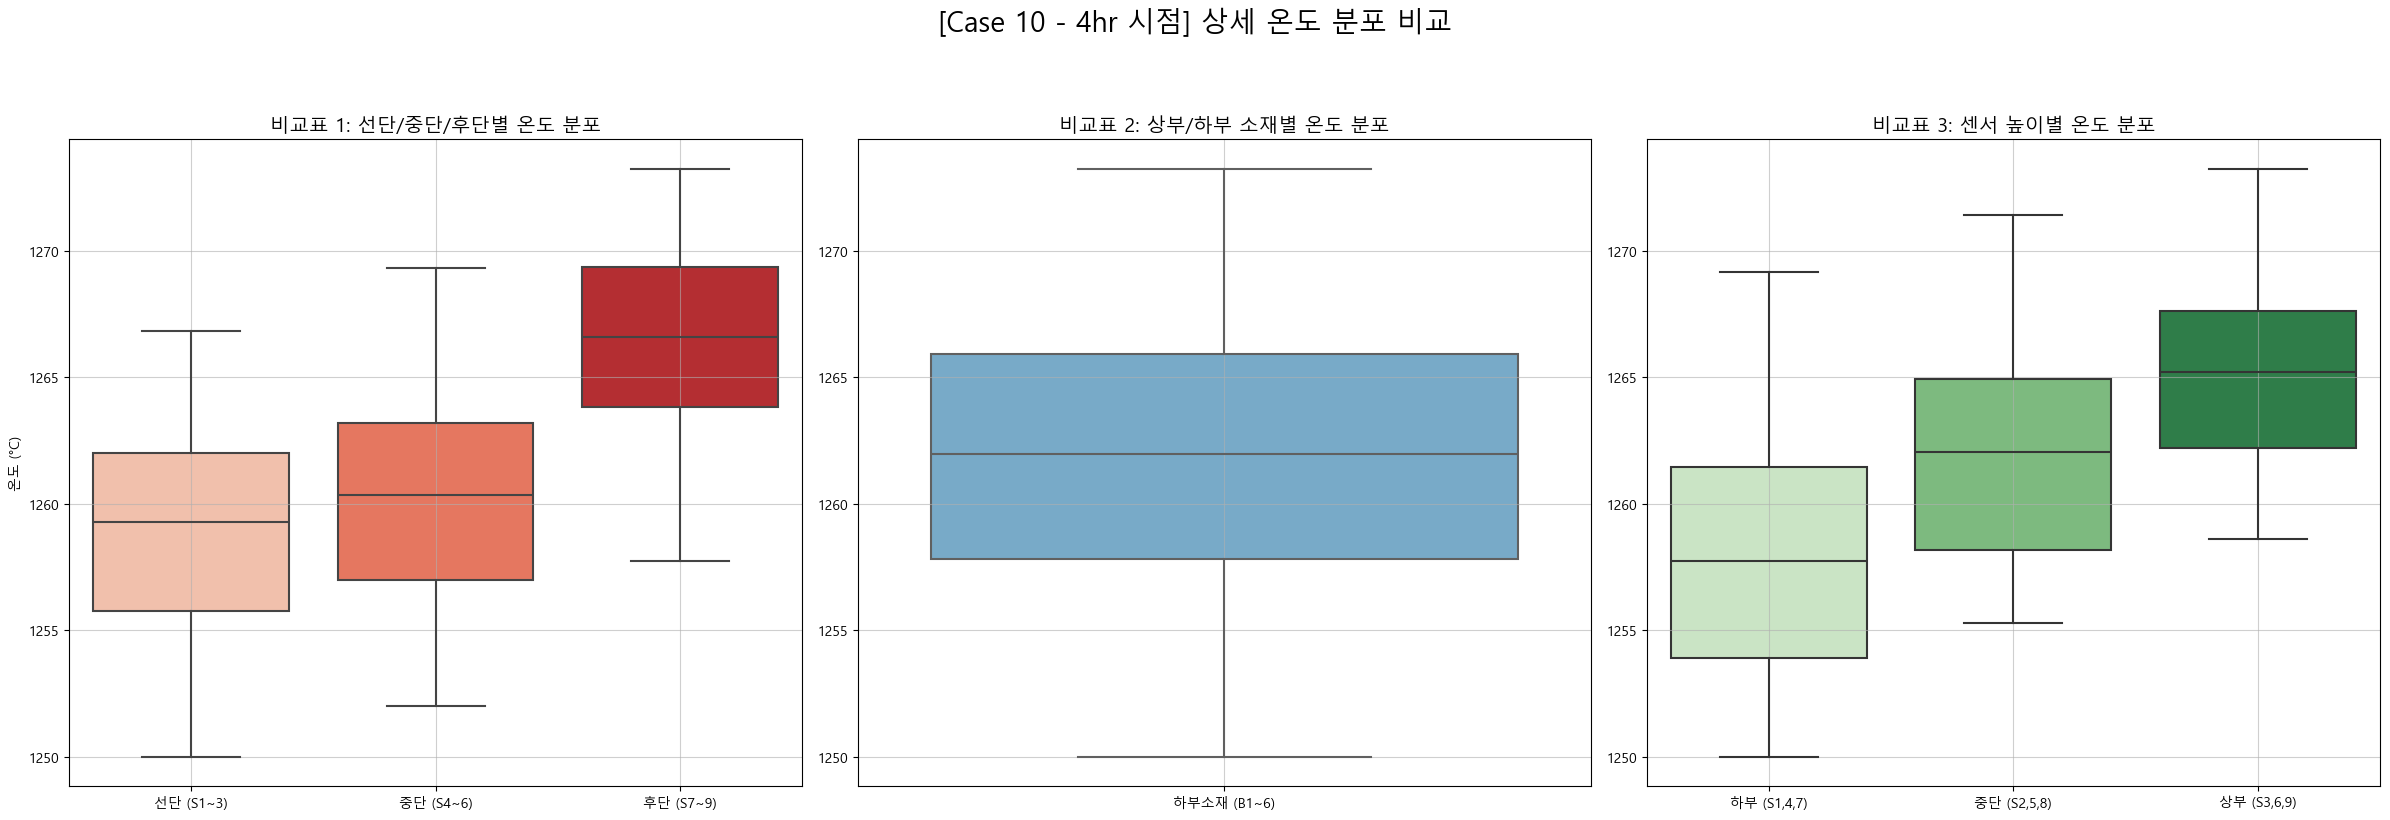

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   18.00 1258.92 4.67 1250.00 1255.76 1259.29 1262.02 1266.85
중단 (S4~6)   18.00 1260.37 4.67 1252.01 1257.00 1260.36 1263.19 1269.32
후단 (S7~9)   18.00 1266.26 4.21 1257.73 1263.85 1266.60 1269.36 1273.26

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

             count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                            
하부소재 (B1~6)  54.00 1261.85 5.47 1250.00 1257.84 1261.99 1265.91 1273.26

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    18.00 1265.28 4.04 1258.62 1262.21 1265.21 1267.62 1273.26
중단 (S2,5,8)    18.00 1261.97 4.69 

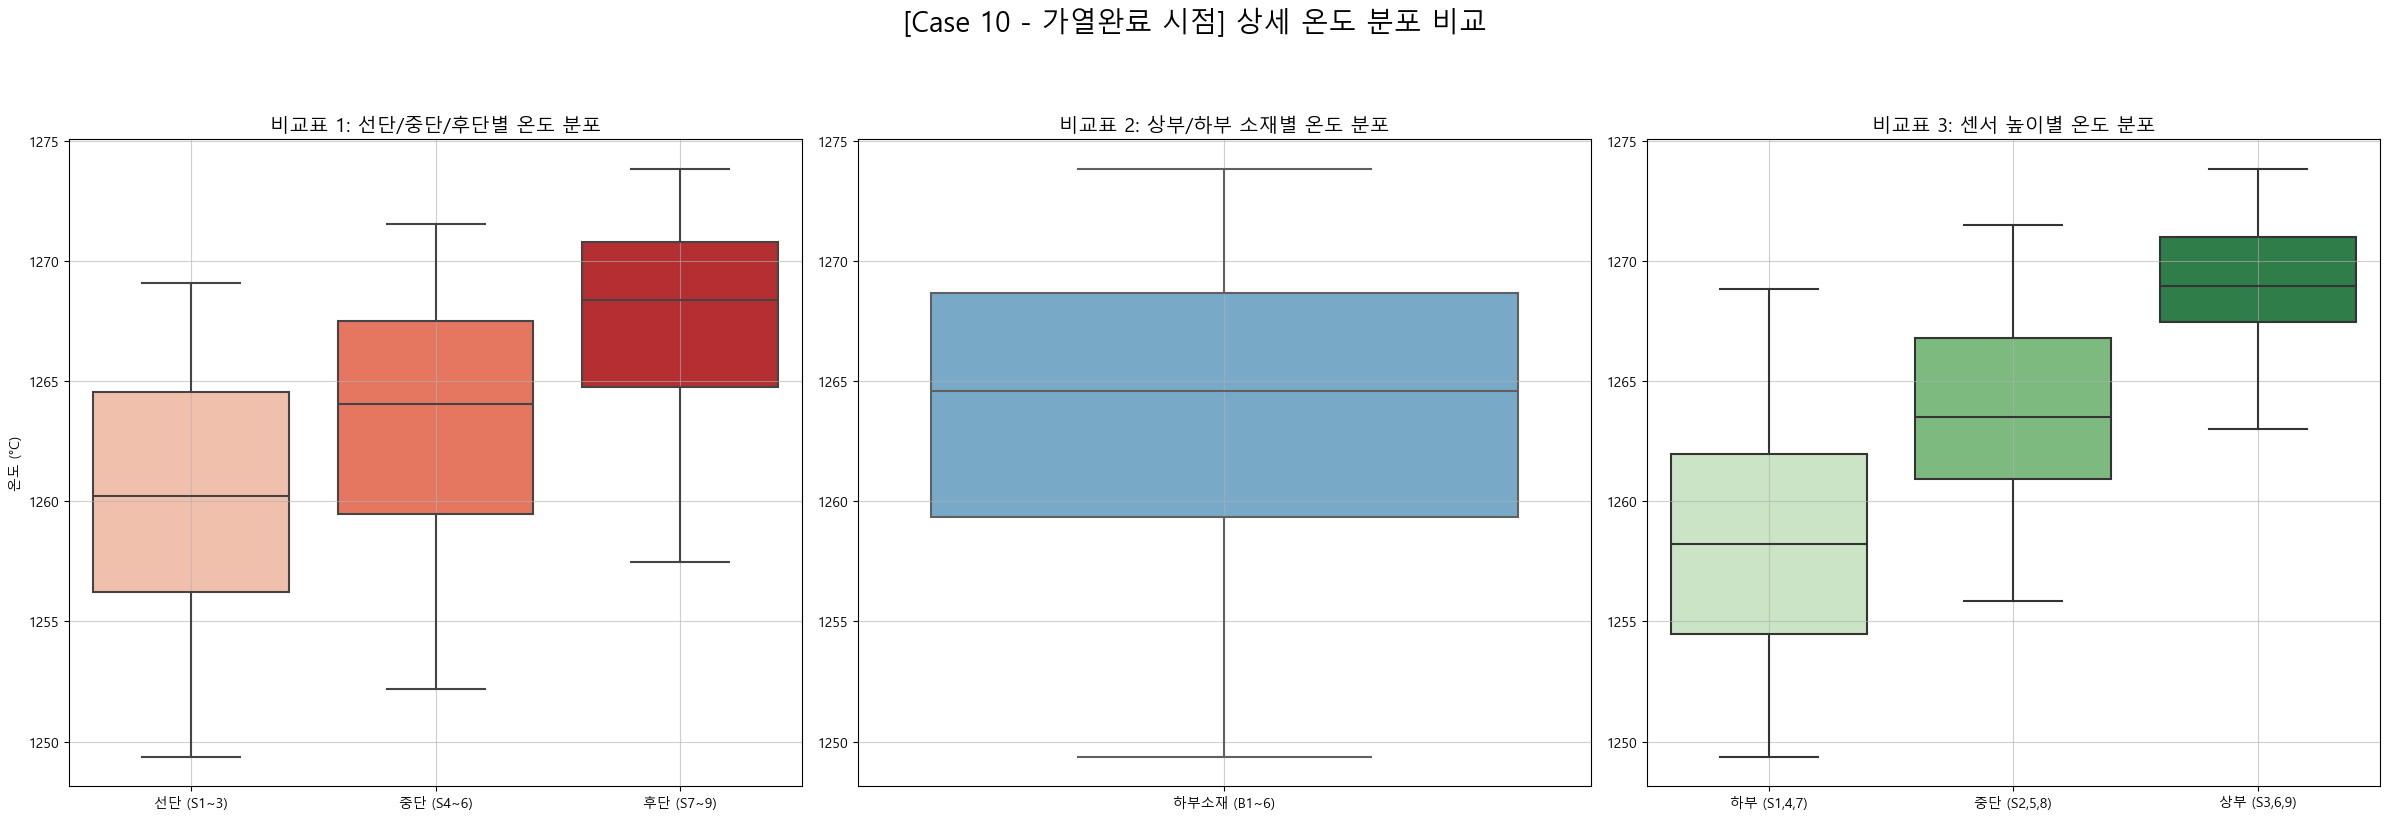

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   18.00 1260.28 5.92 1249.36 1256.21 1260.22 1264.57 1269.09
중단 (S4~6)   18.00 1263.48 5.72 1252.17 1259.46 1264.05 1267.53 1271.56
후단 (S7~9)   18.00 1267.43 4.60 1257.47 1264.76 1268.38 1270.80 1273.87

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

             count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                            
하부소재 (B1~6)  54.00 1263.73 6.10 1249.36 1259.35 1264.60 1268.70 1273.87

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    18.00 1268.98 2.92 1263.04 1267.48 1268.98 1271.02 1273.87
중단 (S2,5,8)    18.00 1263.73 4.38 

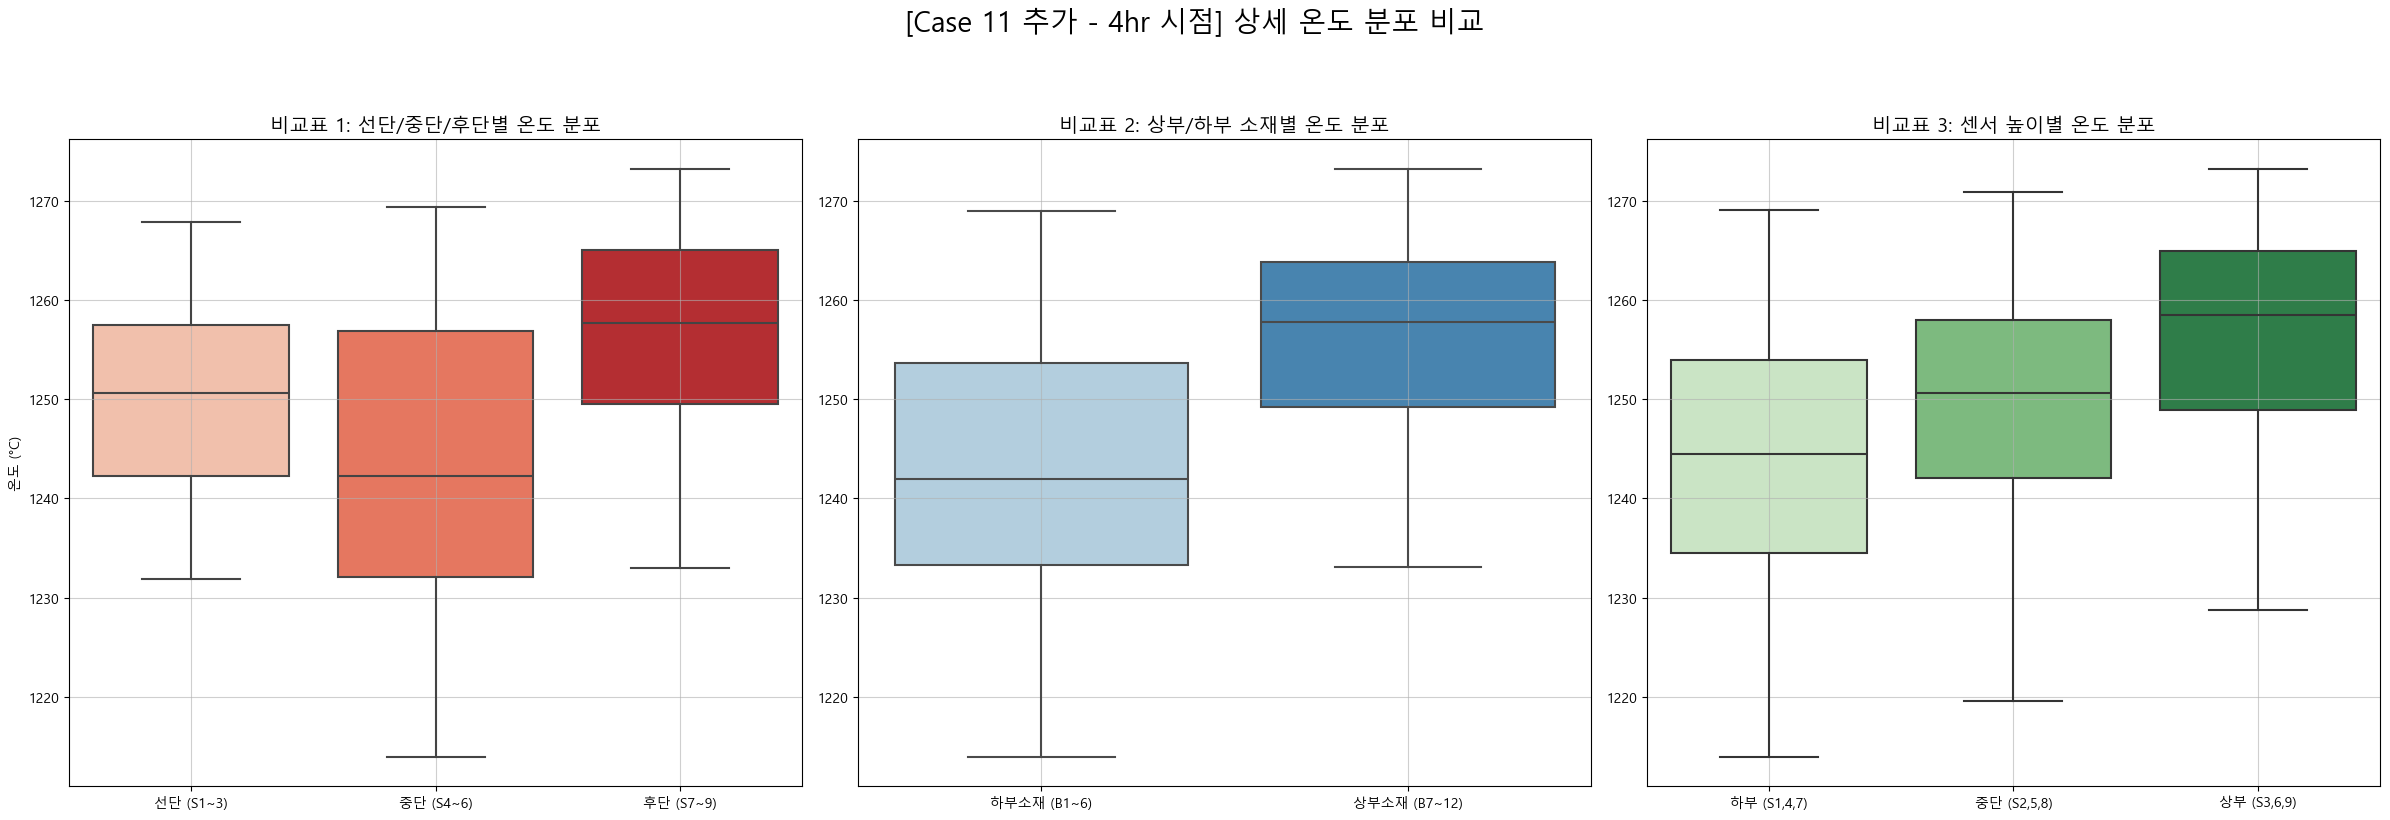

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean   std     min     25%     50%     75%     max
위치 (선/중/후)                                                             
선단 (S1~3)   36.00 1250.14  9.61 1231.84 1242.28 1250.60 1257.51 1267.86
중단 (S4~6)   36.00 1242.88 14.89 1213.95 1232.07 1242.22 1256.90 1269.38
후단 (S7~9)   36.00 1256.44 10.87 1232.99 1249.48 1257.67 1265.08 1273.26

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean   std     min     25%     50%     75%     max
소재 위치 (상/하)                                                              
상부소재 (B7~12)  54.00 1256.35  9.77 1233.08 1249.19 1257.84 1263.88 1273.26
하부소재 (B1~6)   54.00 1243.28 12.87 1213.95 1233.32 1241.99 1253.70 1268.98

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean   std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                             
상부 (S3,6,9)    36.00 

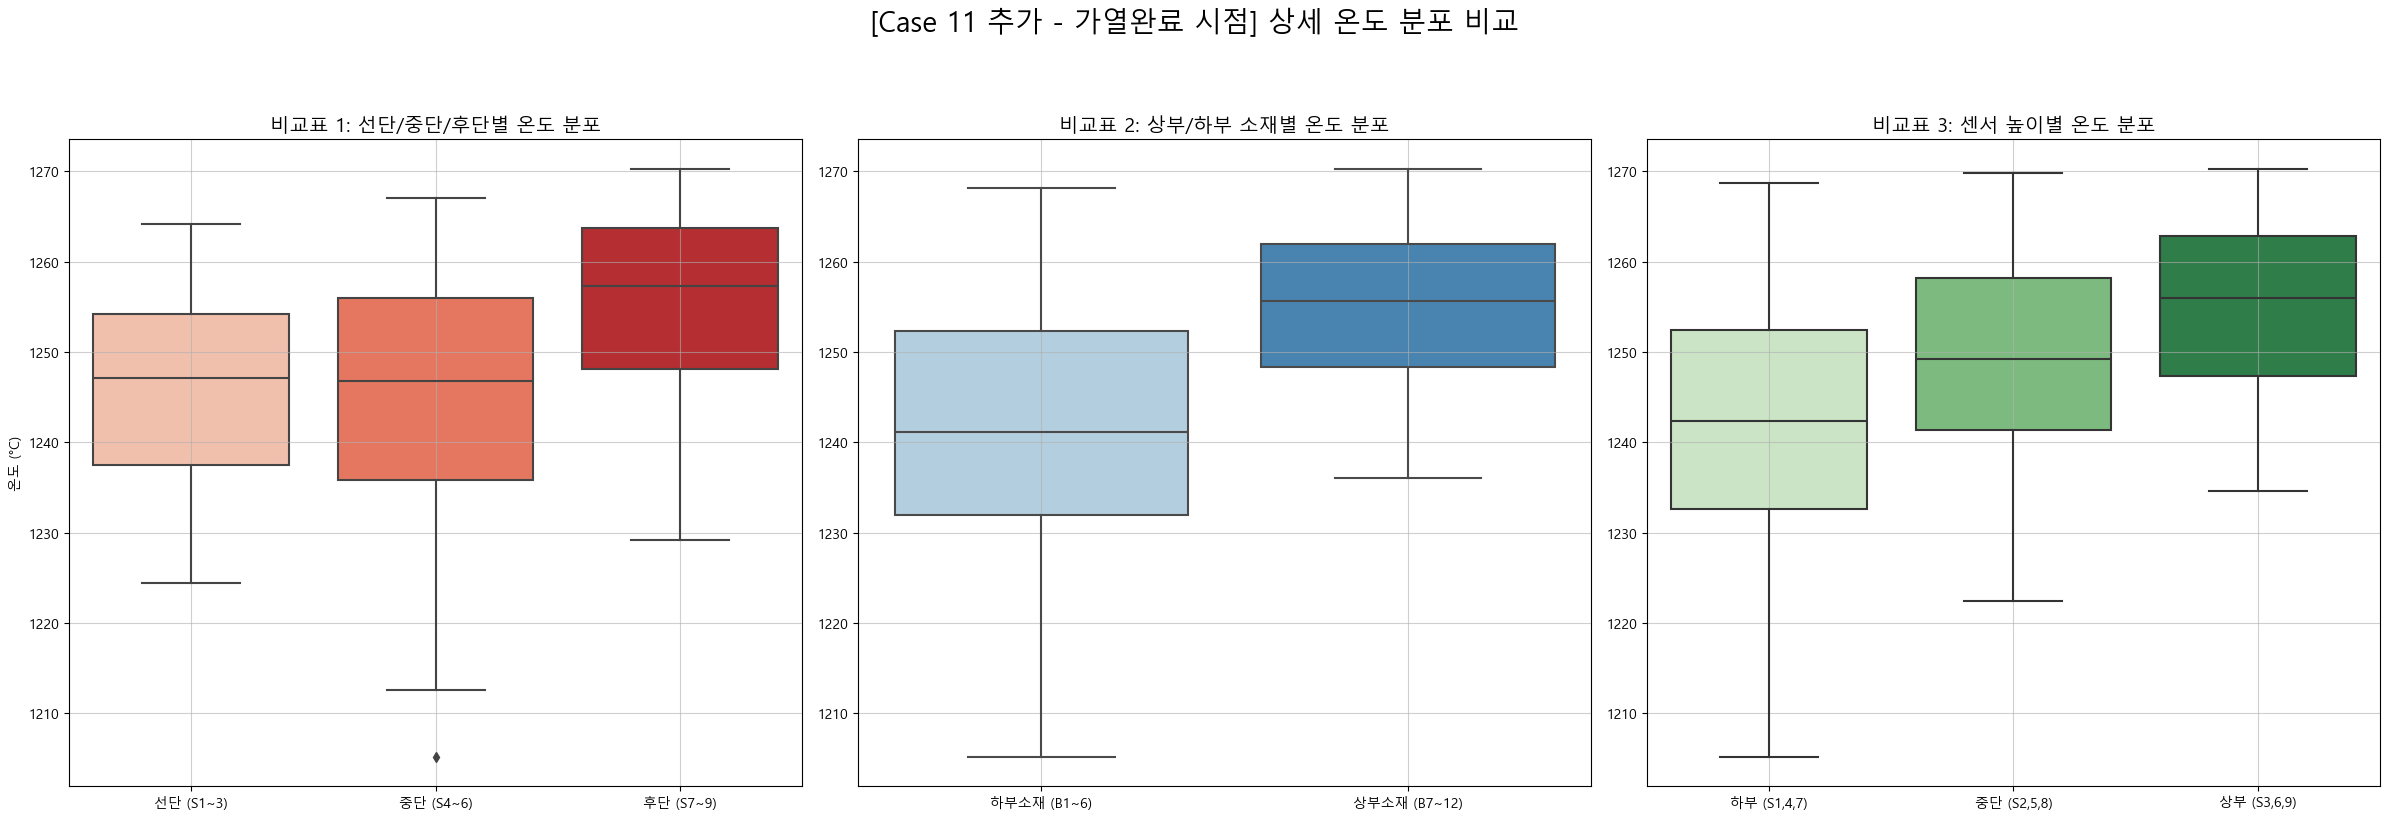

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean   std     min     25%     50%     75%     max
위치 (선/중/후)                                                             
선단 (S1~3)   36.00 1246.04 10.73 1224.44 1237.47 1247.13 1254.23 1264.13
중단 (S4~6)   36.00 1244.22 15.81 1205.20 1235.87 1246.81 1255.94 1267.04
후단 (S7~9)   36.00 1254.74 11.26 1229.23 1248.15 1257.28 1263.73 1270.29

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean   std     min     25%     50%     75%     max
소재 위치 (상/하)                                                              
상부소재 (B7~12)  54.00 1255.04  8.96 1236.07 1248.35 1255.59 1261.95 1270.29
하부소재 (B1~6)   54.00 1241.63 14.00 1205.20 1232.00 1241.09 1252.31 1268.19

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean   std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                             
상부 (S3,6,9)    36.00 

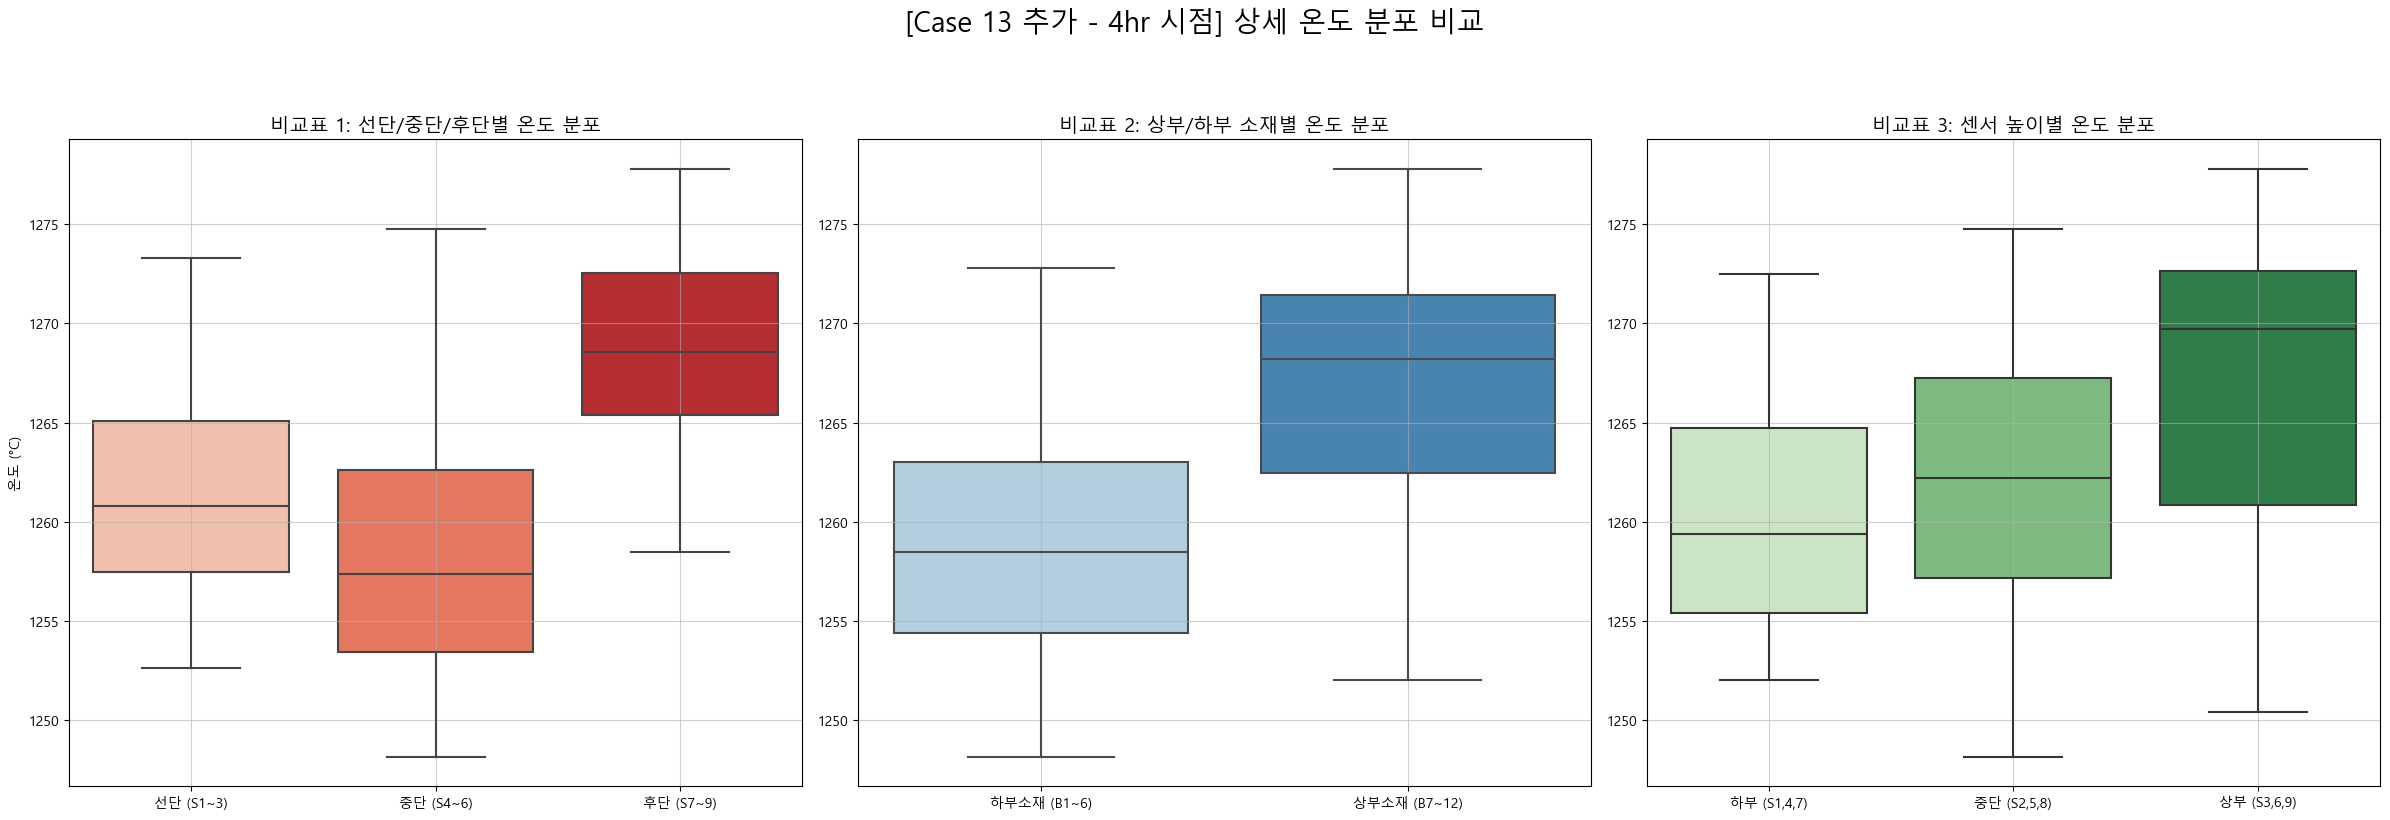

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1261.64 5.70 1252.62 1257.46 1260.82 1265.09 1273.29
중단 (S4~6)   36.00 1258.80 7.34 1248.16 1253.44 1257.35 1262.61 1274.74
후단 (S7~9)   36.00 1268.38 5.06 1258.50 1265.38 1268.54 1272.56 1277.80

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                             
상부소재 (B7~12)  54.00 1266.79 6.44 1252.05 1262.44 1268.20 1271.45 1277.80
하부소재 (B1~6)   54.00 1259.09 5.92 1248.16 1254.40 1258.50 1263.04 1272.78

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    36.00 1266.91 7.6

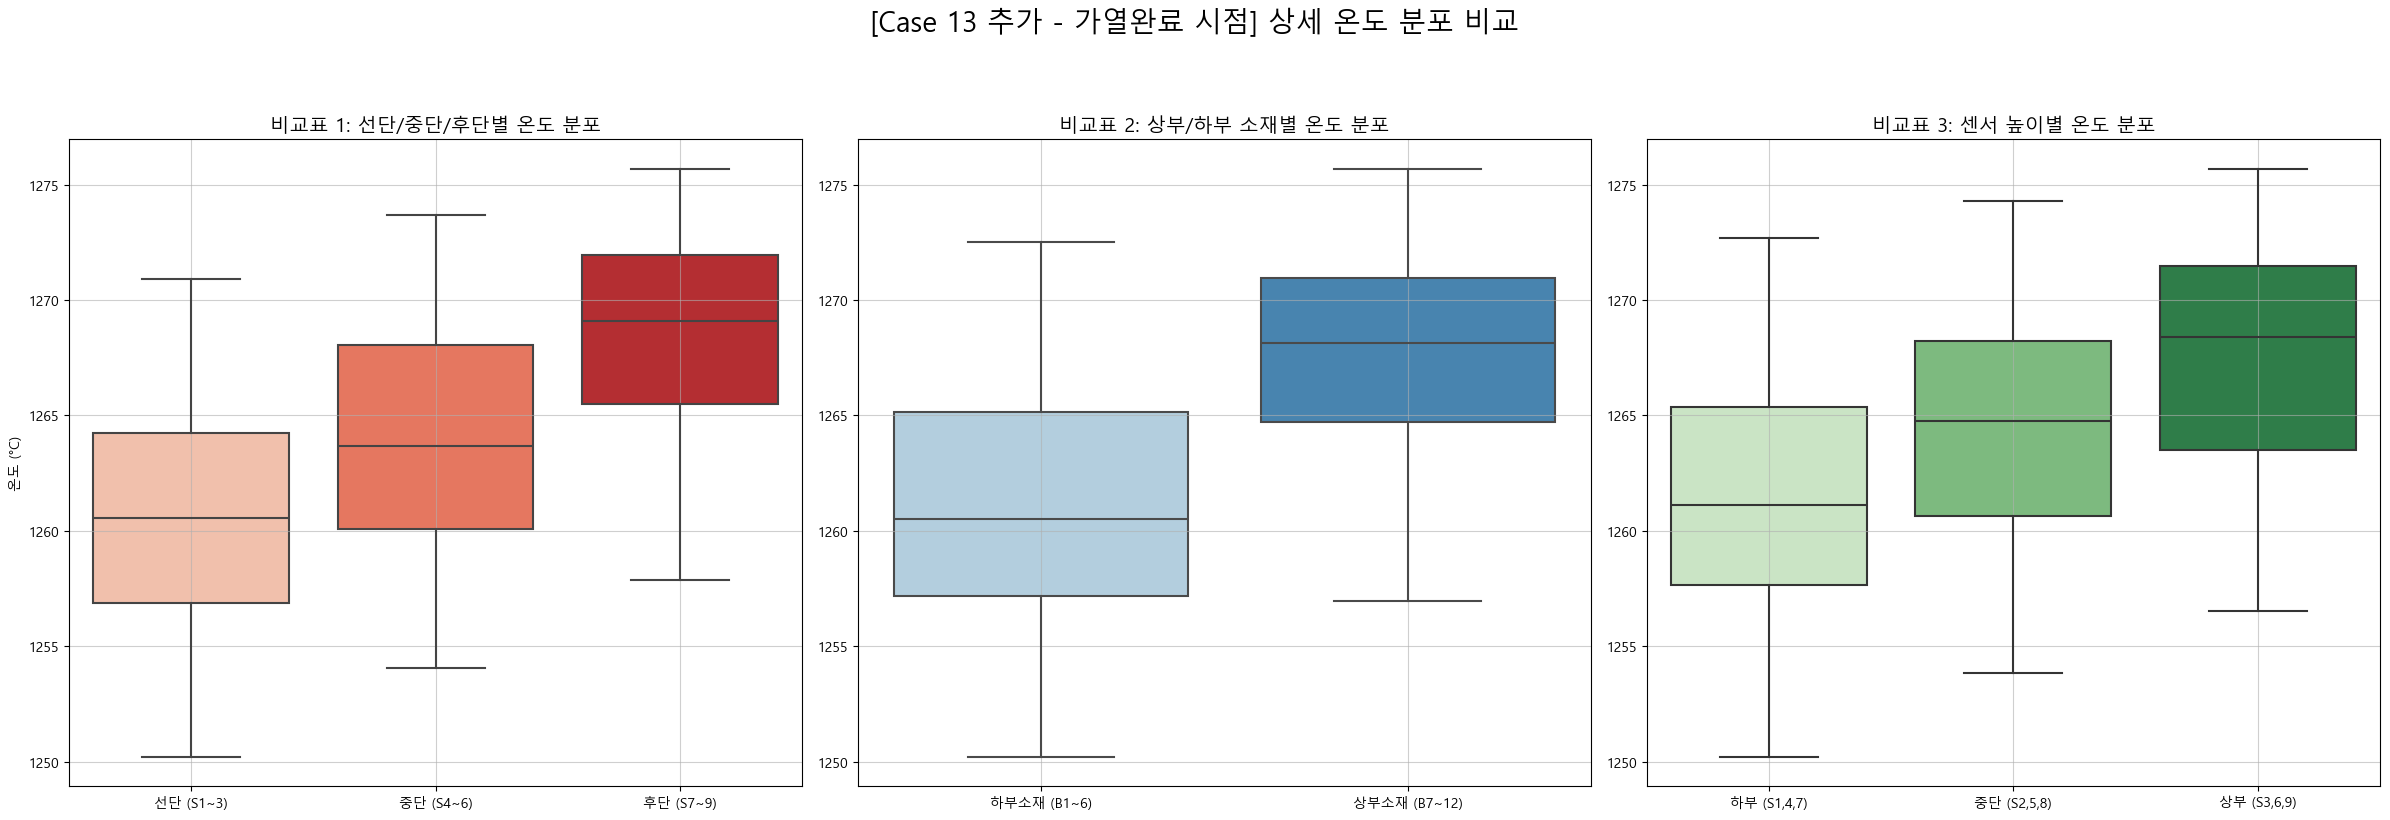

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1260.51 5.45 1250.21 1256.87 1260.55 1264.23 1270.89
중단 (S4~6)   36.00 1263.90 5.30 1254.05 1260.09 1263.65 1268.05 1273.66
후단 (S7~9)   36.00 1268.46 4.53 1257.89 1265.50 1269.09 1271.93 1275.69

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                             
상부소재 (B7~12)  54.00 1267.71 4.56 1256.98 1264.72 1268.12 1270.97 1275.69
하부소재 (B1~6)   54.00 1260.87 5.36 1250.21 1257.16 1260.53 1265.16 1272.53

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    36.00 1267.42 5.3

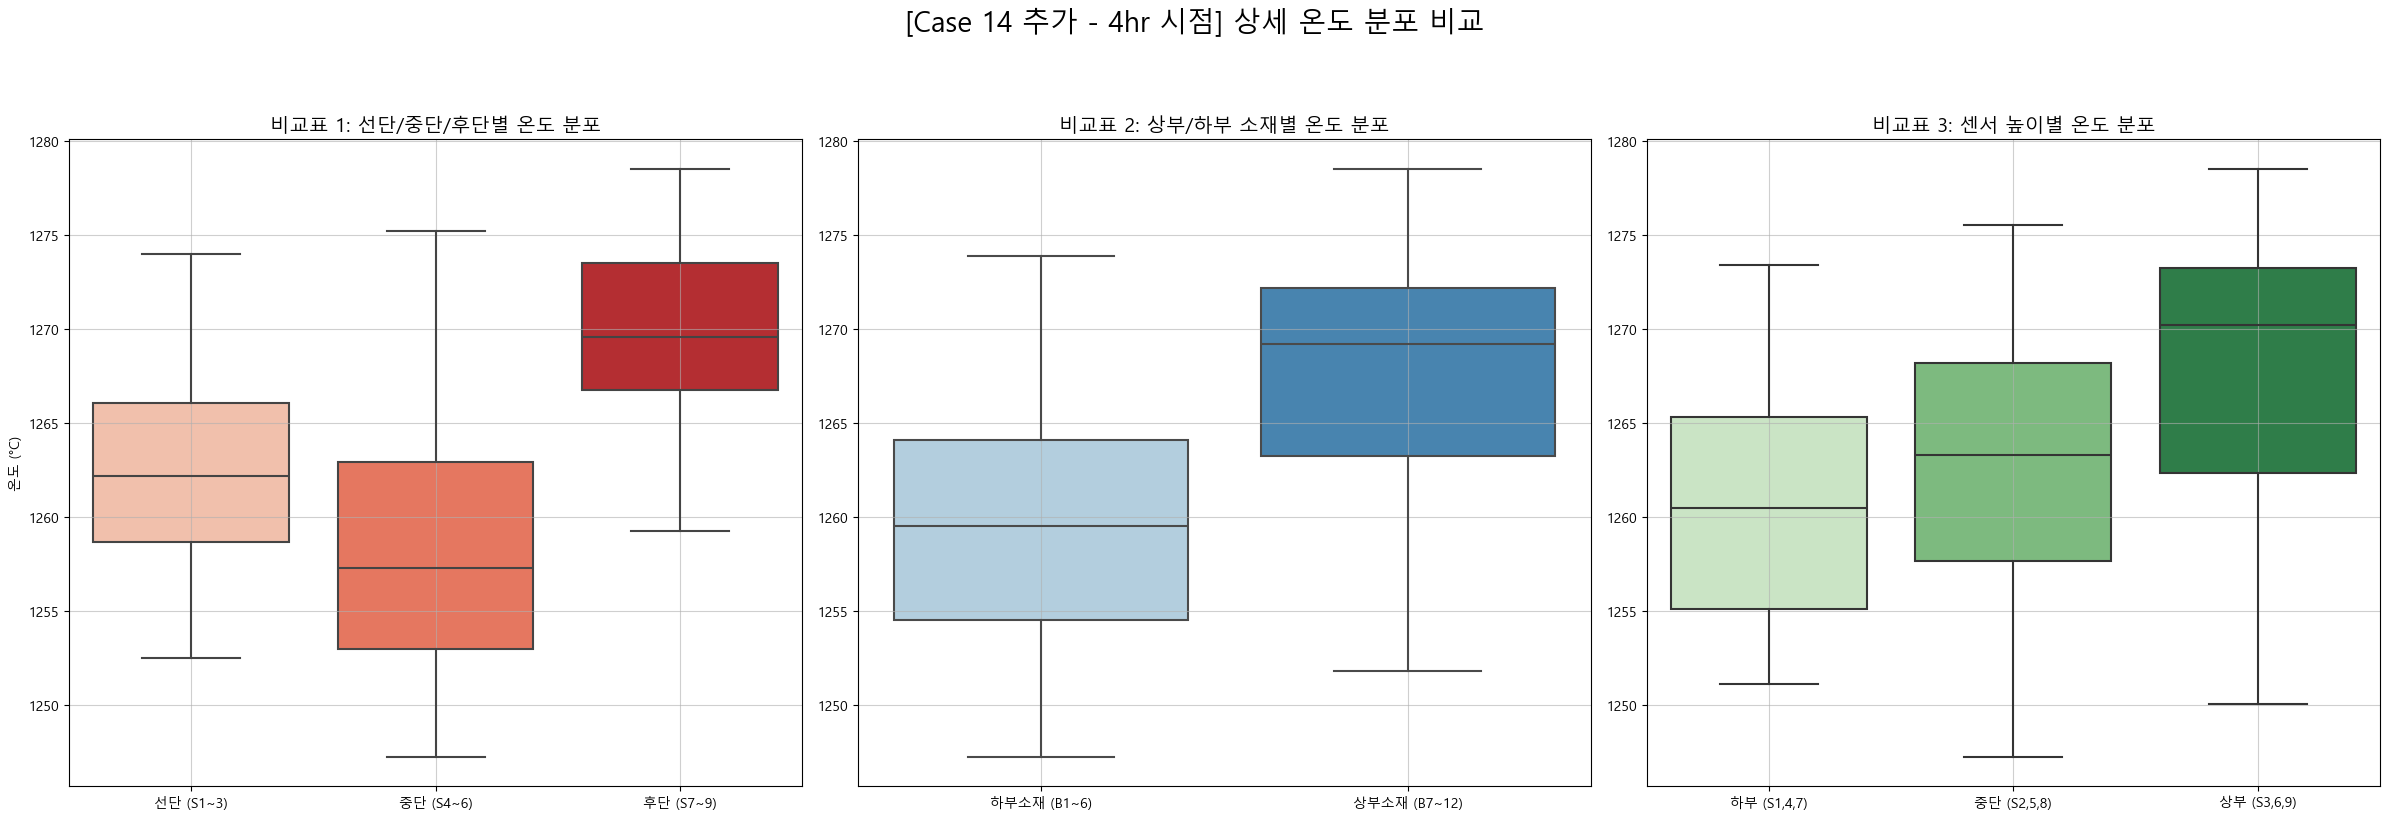

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1262.63 5.69 1252.50 1258.65 1262.20 1266.06 1274.00
중단 (S4~6)   36.00 1258.66 7.69 1247.23 1252.96 1257.28 1262.91 1275.23
후단 (S7~9)   36.00 1269.48 4.91 1259.23 1266.78 1269.57 1273.50 1278.54

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                             
상부소재 (B7~12)  54.00 1267.44 6.60 1251.82 1263.22 1269.23 1272.20 1278.54
하부소재 (B1~6)   54.00 1259.74 6.57 1247.23 1254.54 1259.50 1264.09 1273.88

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    36.00 1267.64 7.7

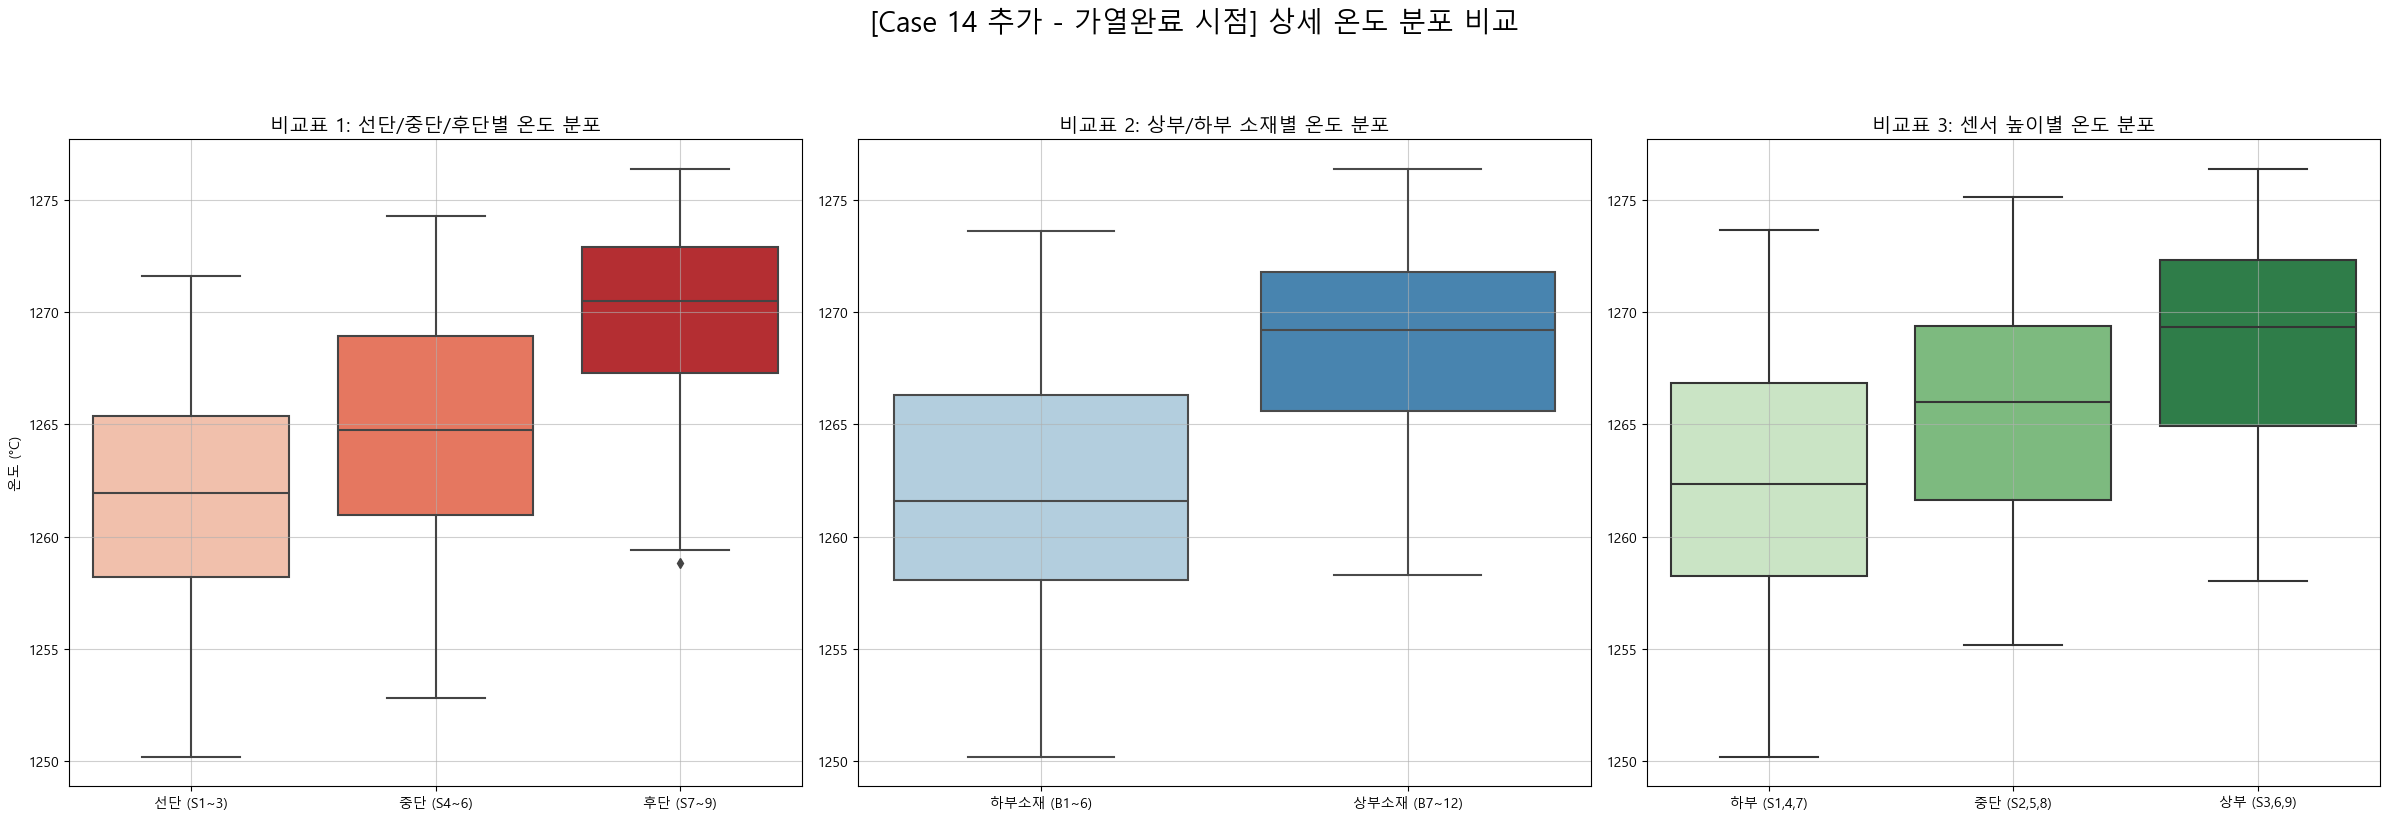

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1261.60 5.51 1250.20 1258.22 1261.93 1265.38 1271.61
중단 (S4~6)   36.00 1264.48 5.62 1252.84 1260.98 1264.76 1268.91 1274.28
후단 (S7~9)   36.00 1269.67 4.38 1258.83 1267.30 1270.49 1272.87 1276.38

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                             
상부소재 (B7~12)  54.00 1268.64 4.40 1258.28 1265.60 1269.18 1271.80 1276.38
하부소재 (B1~6)   54.00 1261.85 5.78 1250.20 1258.06 1261.60 1266.32 1273.59

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    36.00 1268.41 5.0

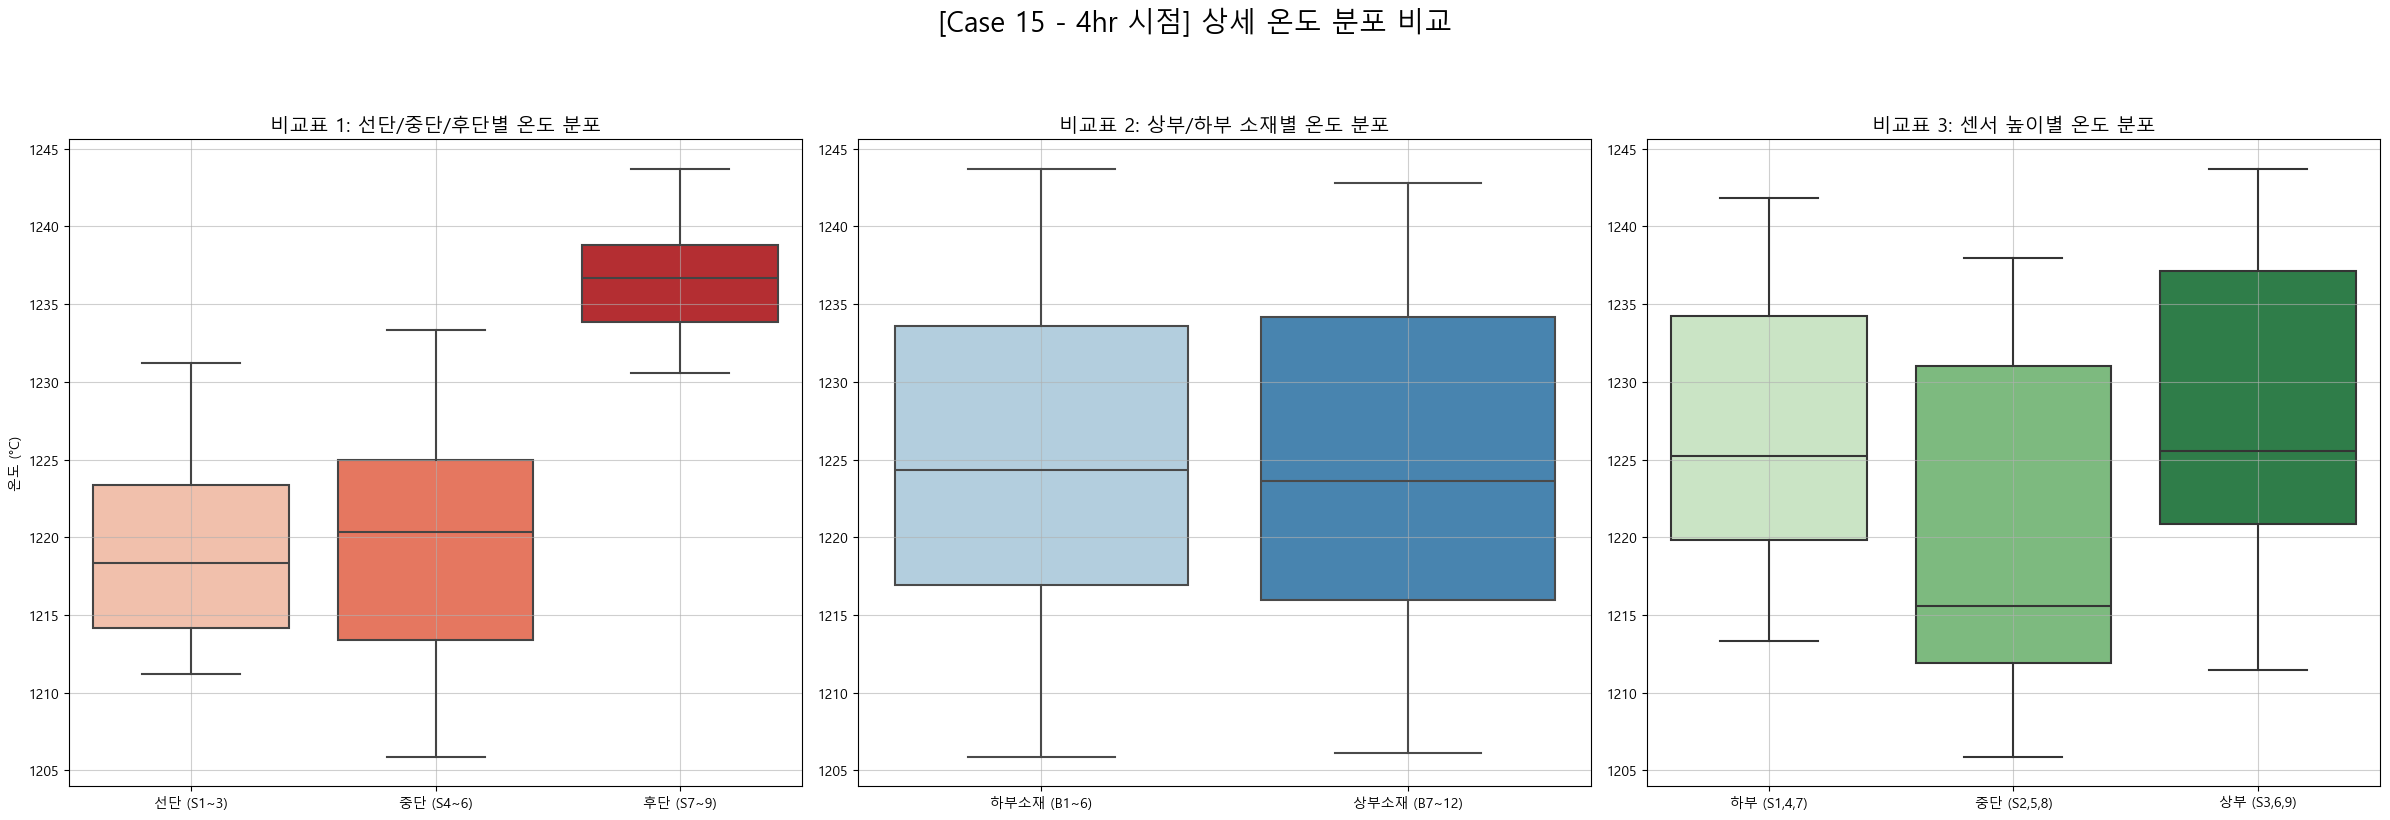

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1218.98 5.54 1211.19 1214.18 1218.36 1223.35 1231.22
중단 (S4~6)   36.00 1218.93 7.83 1205.87 1213.37 1220.37 1224.95 1233.34
후단 (S7~9)   36.00 1236.41 3.63 1230.58 1233.82 1236.67 1238.83 1243.72

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean   std     min     25%     50%     75%     max
소재 위치 (상/하)                                                              
상부소재 (B7~12)  54.00 1224.42 10.38 1206.11 1215.95 1223.62 1234.18 1242.78
하부소재 (B1~6)   54.00 1225.12  9.97 1205.87 1216.94 1224.33 1233.62 1243.72

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean   std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                             
상부 (S3,6,9)    36.00 1227.

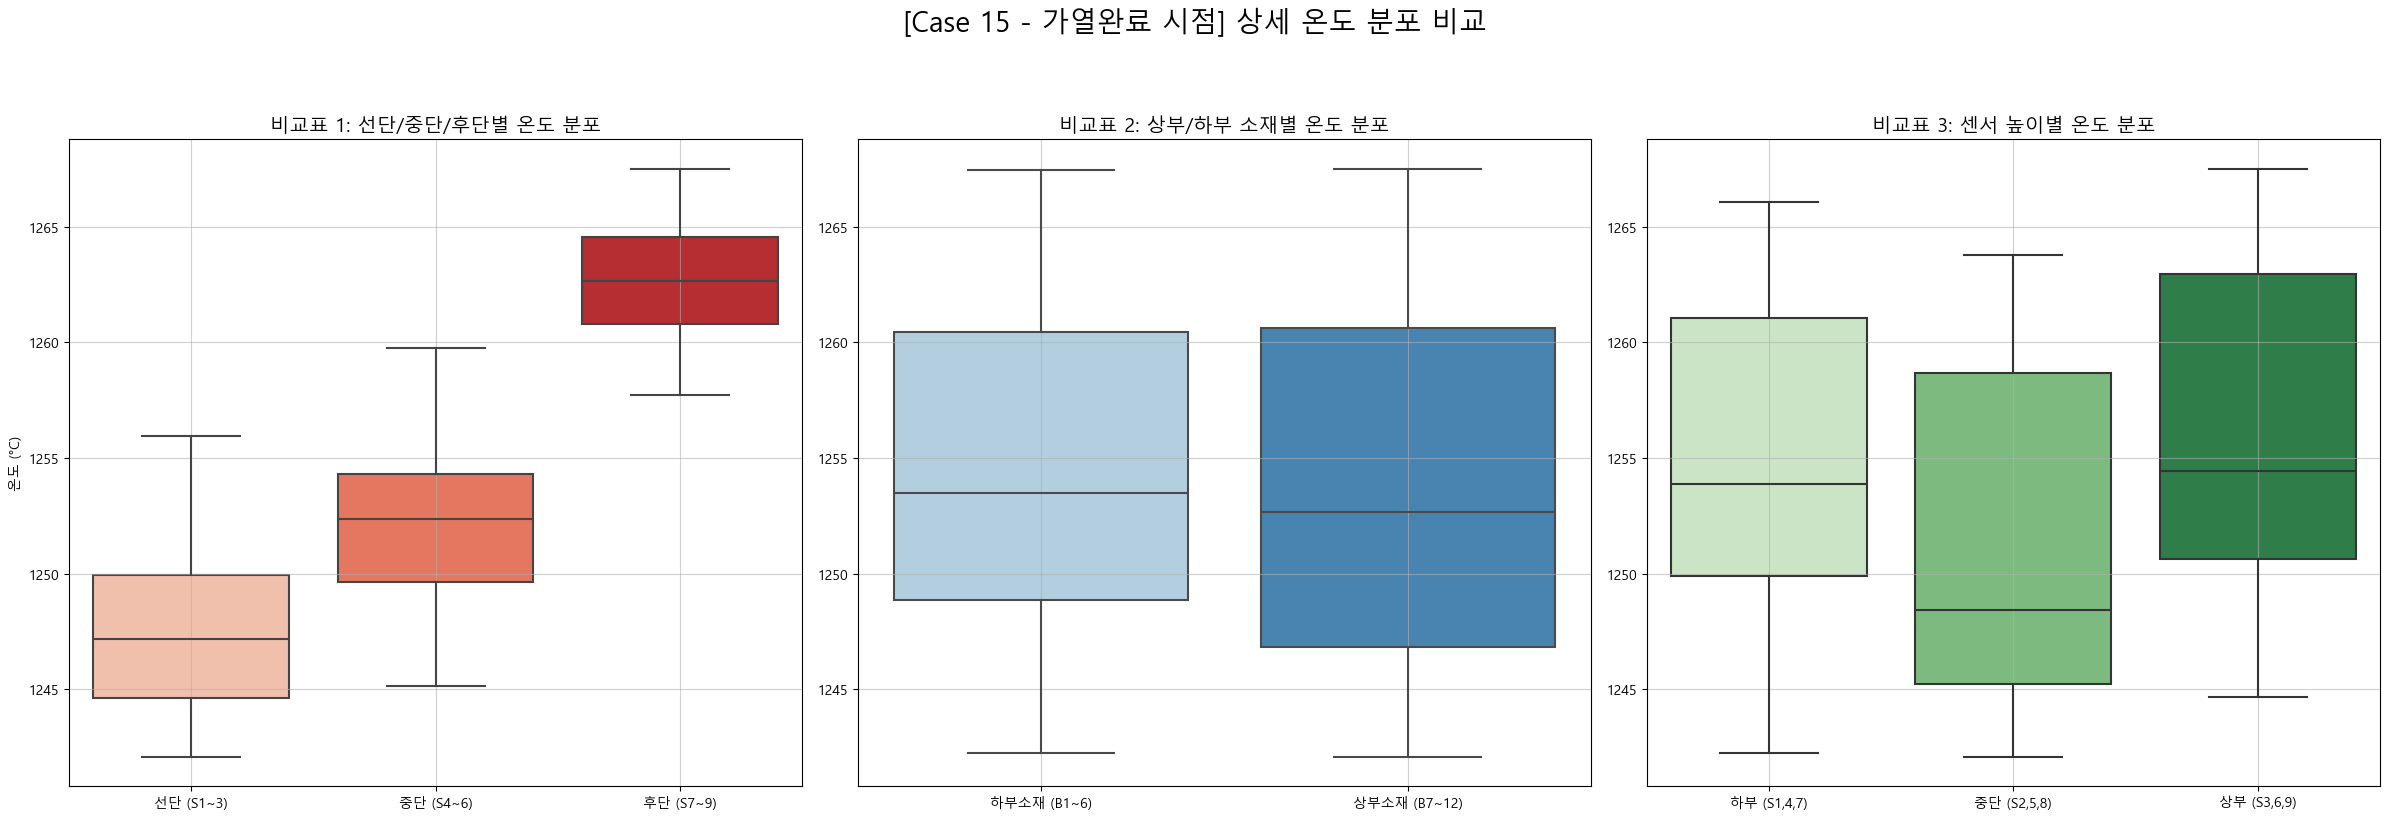

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1247.55 3.89 1242.08 1244.64 1247.18 1249.96 1255.93
중단 (S4~6)   36.00 1251.94 4.11 1245.16 1249.63 1252.36 1254.31 1259.75
후단 (S7~9)   36.00 1262.61 2.63 1257.74 1260.81 1262.64 1264.55 1267.51

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                             
상부소재 (B7~12)  54.00 1253.67 7.67 1242.08 1246.82 1252.65 1260.63 1267.51
하부소재 (B1~6)   54.00 1254.40 6.93 1242.24 1248.84 1253.51 1260.44 1267.44

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    36.00 1256.05 6.9

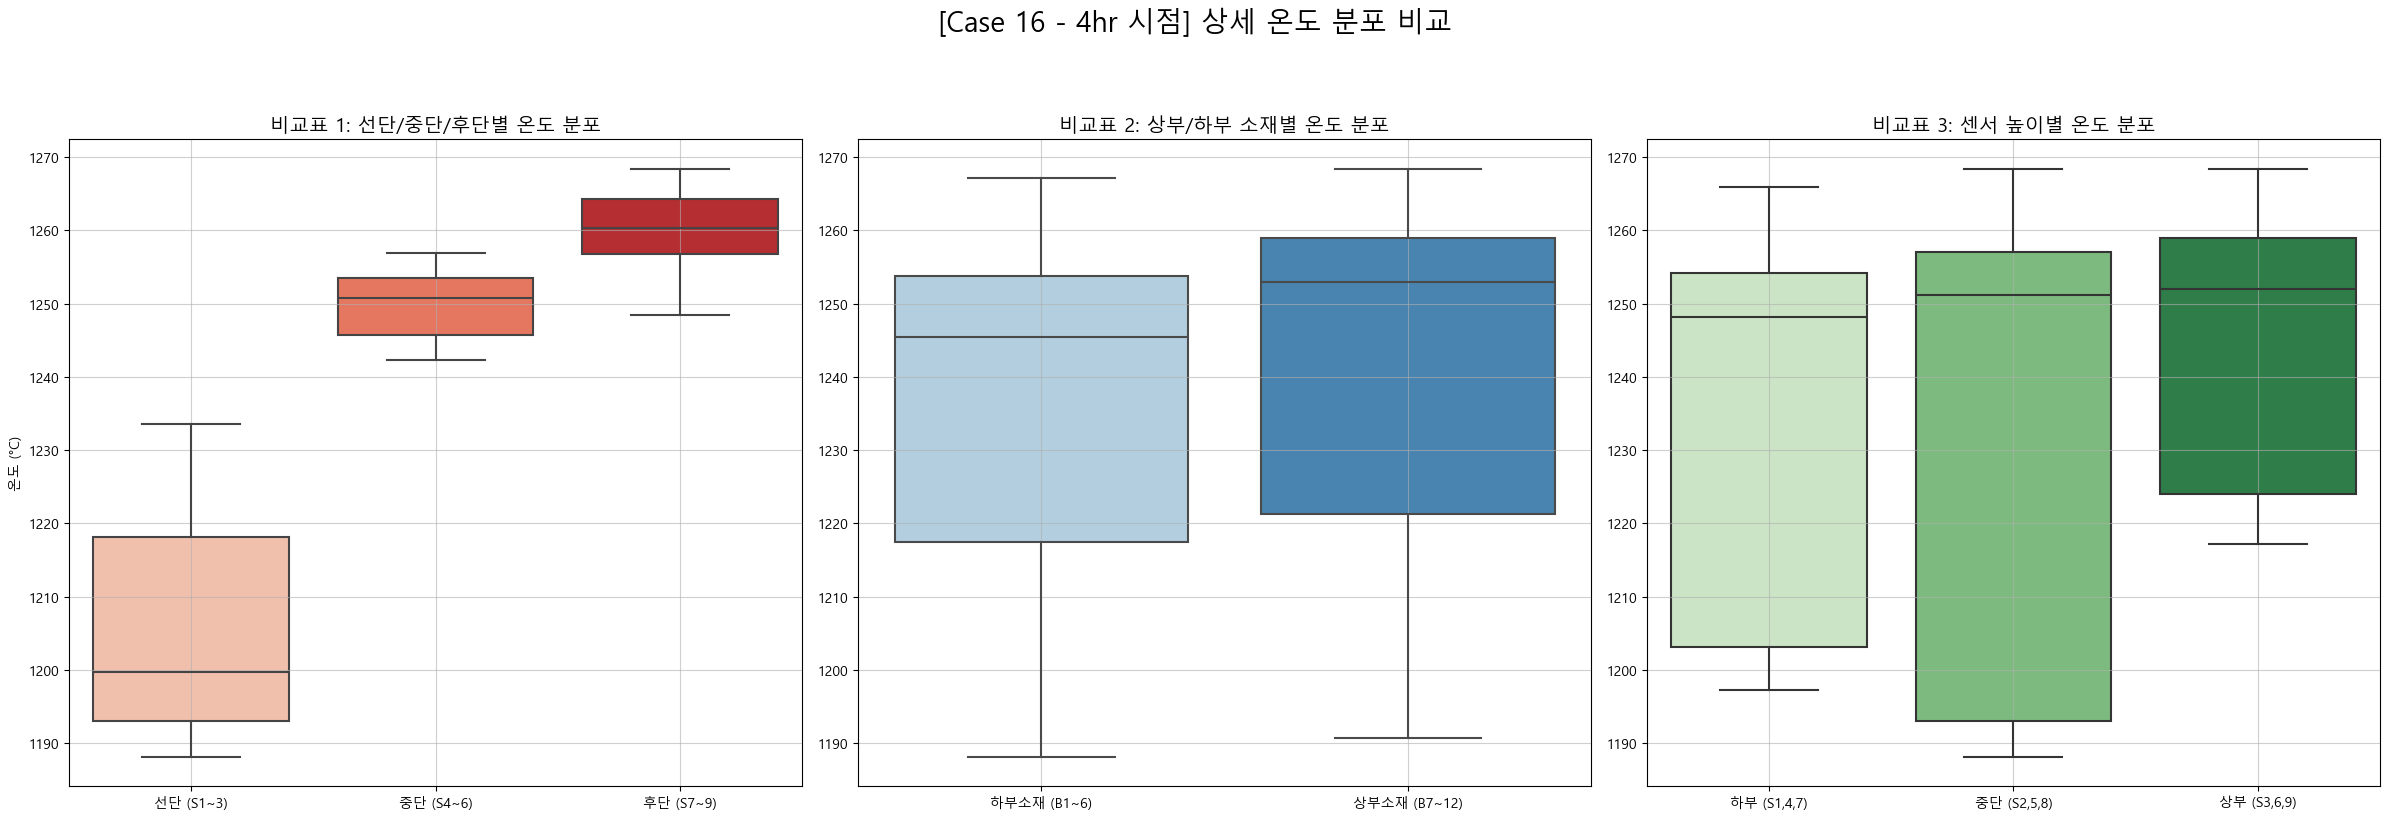

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean   std     min     25%     50%     75%     max
위치 (선/중/후)                                                             
선단 (S1~3)   36.00 1204.72 13.57 1188.15 1193.06 1199.74 1218.15 1233.57
중단 (S4~6)   36.00 1249.78  4.44 1242.26 1245.66 1250.73 1253.45 1256.88
후단 (S7~9)   36.00 1260.33  5.26 1248.47 1256.71 1260.30 1264.24 1268.41

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean   std     min     25%     50%     75%     max
소재 위치 (상/하)                                                              
상부소재 (B7~12)  54.00 1240.59 26.16 1190.77 1221.34 1252.94 1258.96 1268.41
하부소재 (B1~6)   54.00 1235.96 25.36 1188.15 1217.49 1245.39 1253.71 1267.19

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean   std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                             
상부 (S3,6,9)    36.00 

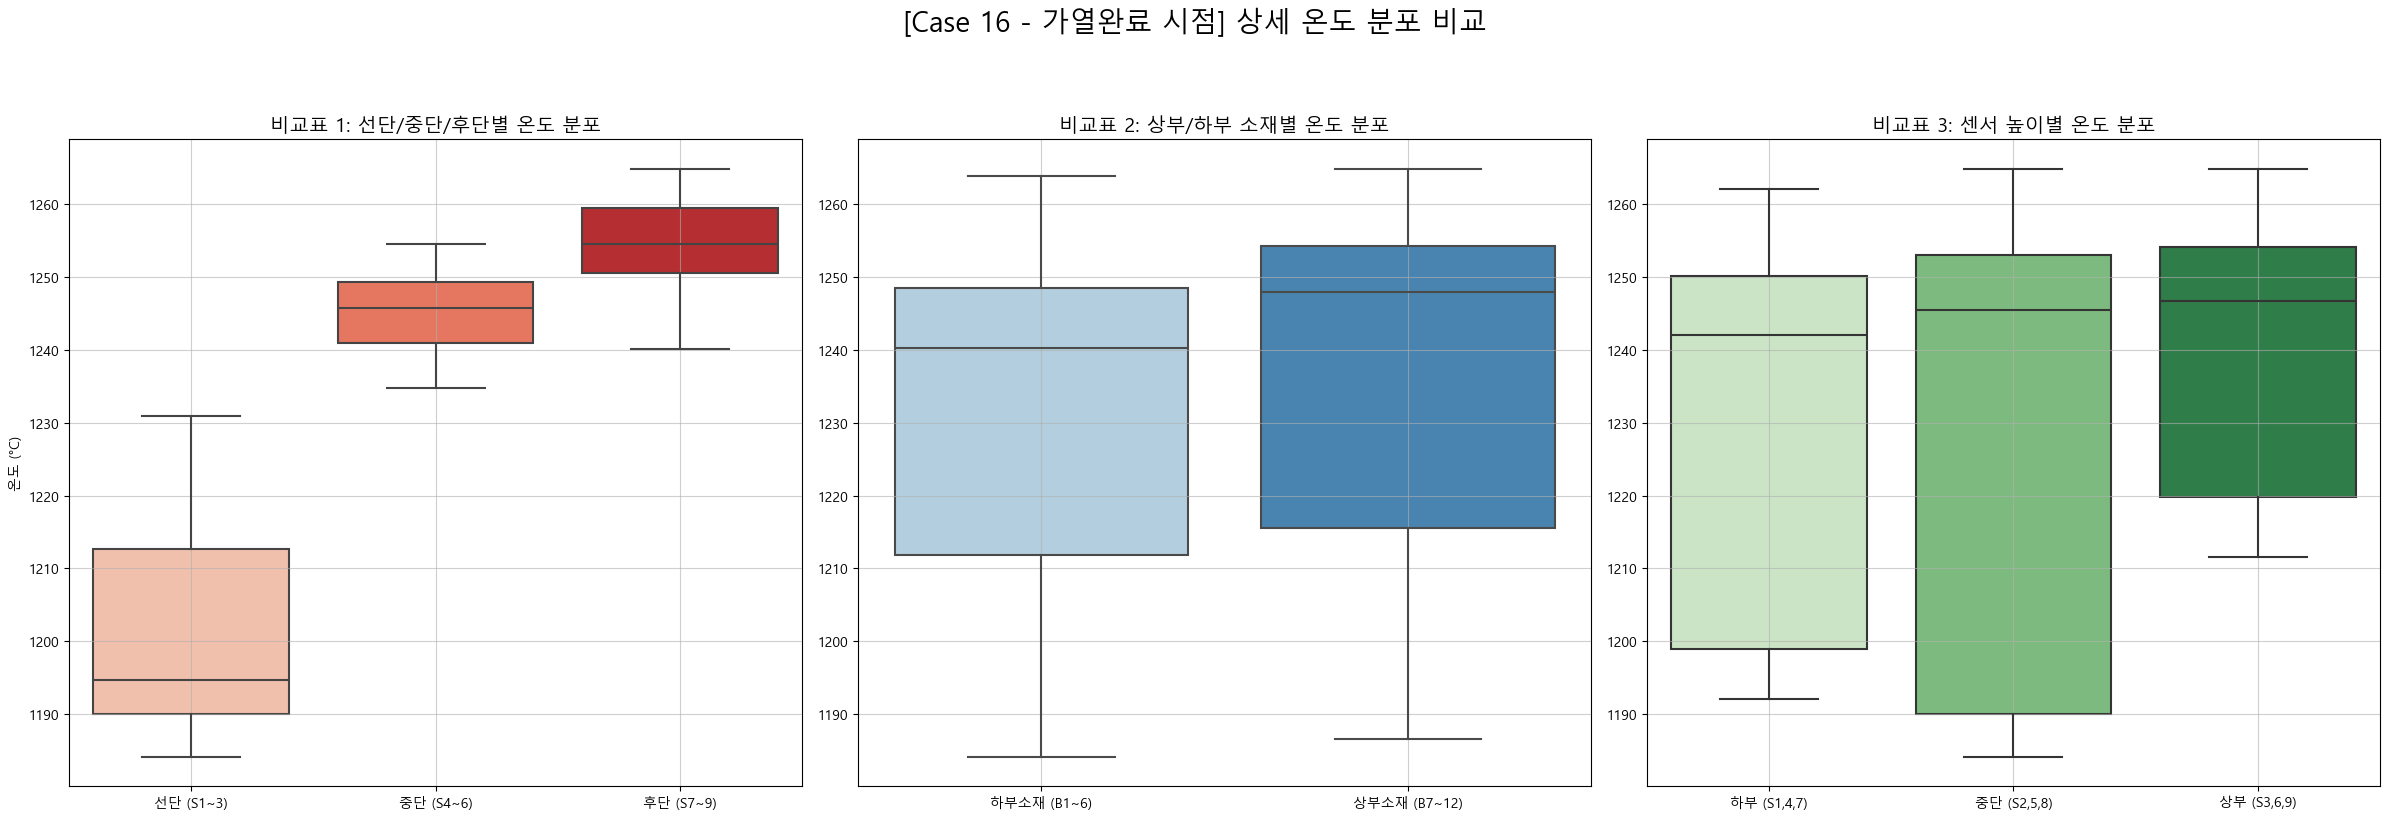

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean   std     min     25%     50%     75%     max
위치 (선/중/후)                                                             
선단 (S1~3)   36.00 1200.29 13.37 1184.18 1189.99 1194.68 1212.65 1230.84
중단 (S4~6)   36.00 1245.34  5.56 1234.76 1240.88 1245.74 1249.32 1254.45
후단 (S7~9)   36.00 1254.69  6.61 1240.07 1250.44 1254.47 1259.42 1264.81

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean   std     min     25%     50%     75%     max
소재 위치 (상/하)                                                              
상부소재 (B7~12)  54.00 1235.90 26.09 1186.57 1215.58 1247.87 1254.22 1264.81
하부소재 (B1~6)   54.00 1230.97 24.97 1184.18 1211.91 1240.21 1248.44 1263.74

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean   std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                             
상부 (S3,6,9)    36.00 

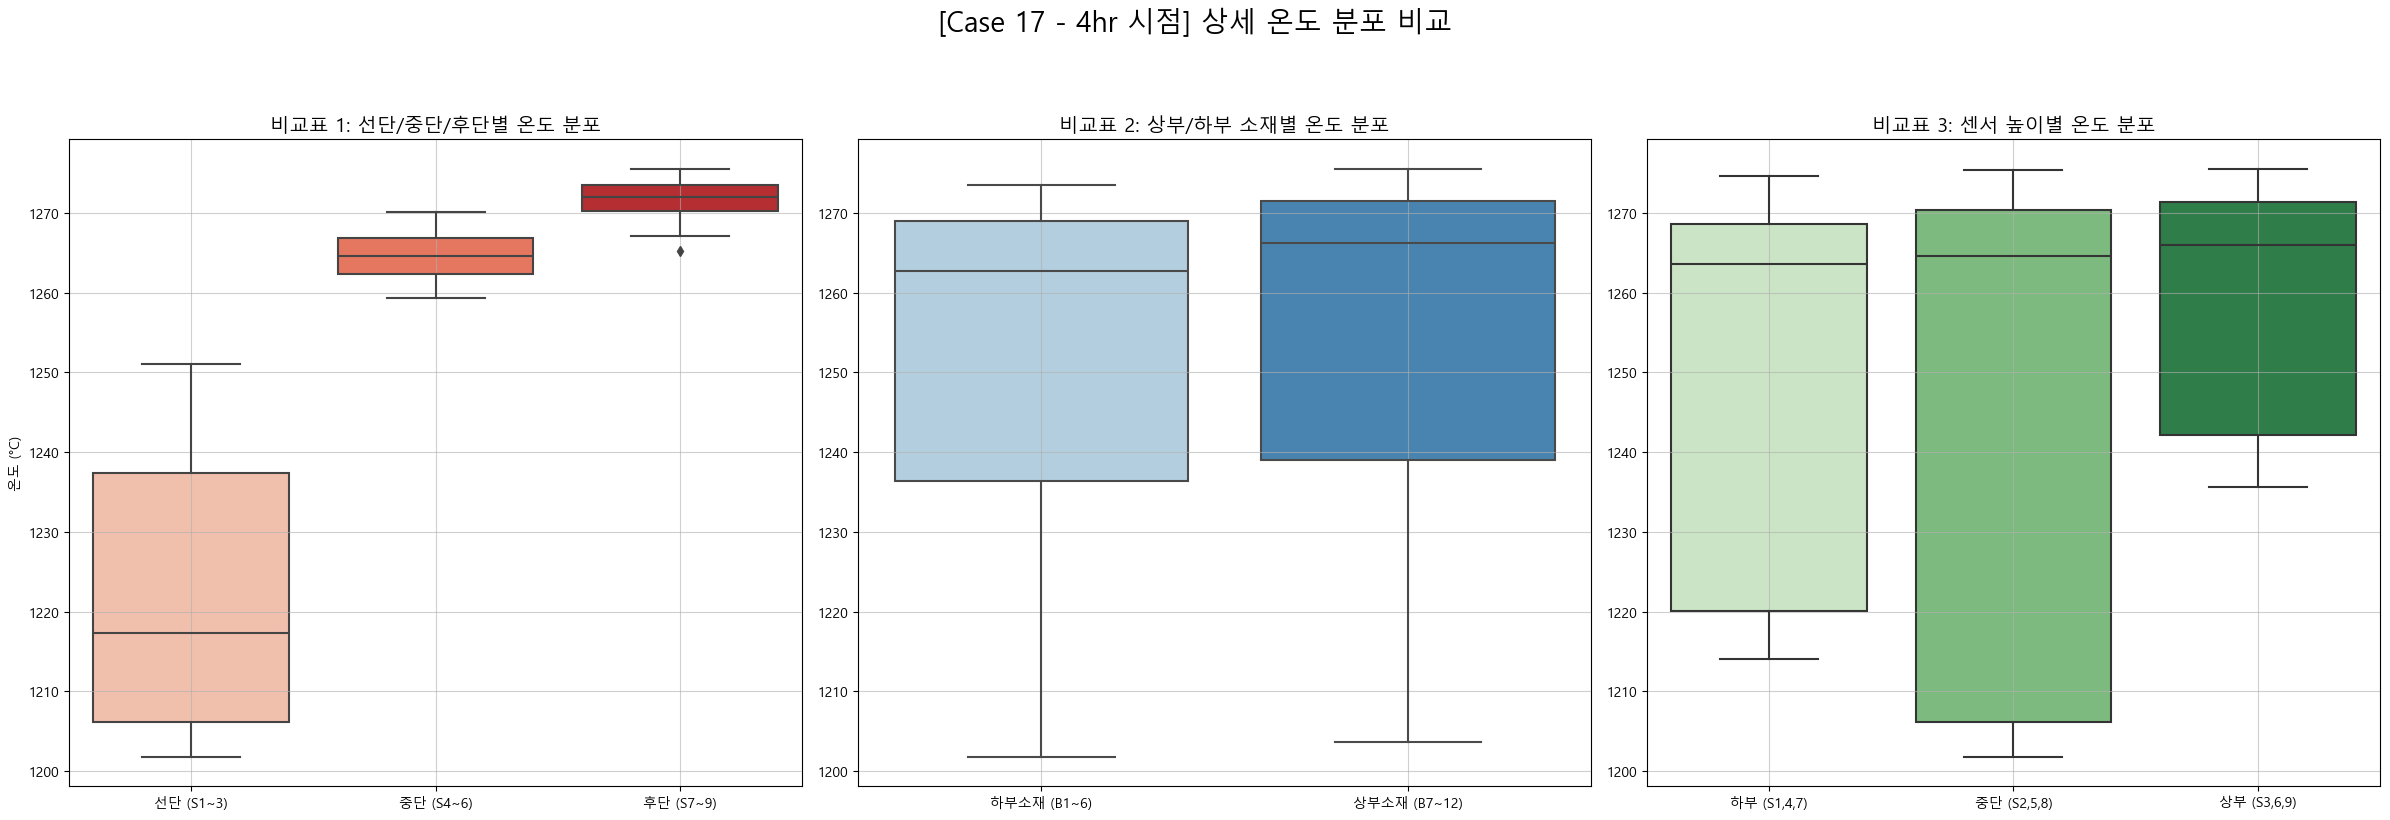

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean   std     min     25%     50%     75%     max
위치 (선/중/후)                                                             
선단 (S1~3)   36.00 1221.04 15.44 1201.80 1206.11 1217.37 1237.43 1251.09
중단 (S4~6)   36.00 1264.72  2.88 1259.29 1262.35 1264.61 1266.80 1270.07
후단 (S7~9)   36.00 1271.75  2.51 1265.23 1270.27 1272.03 1273.55 1275.56

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean   std     min     25%     50%     75%     max
소재 위치 (상/하)                                                              
상부소재 (B7~12)  54.00 1253.78 24.54 1203.71 1239.04 1266.29 1271.53 1275.56
하부소재 (B1~6)   54.00 1251.22 24.22 1201.80 1236.38 1262.76 1269.03 1273.50

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean   std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                             
상부 (S3,6,9)    36.00 

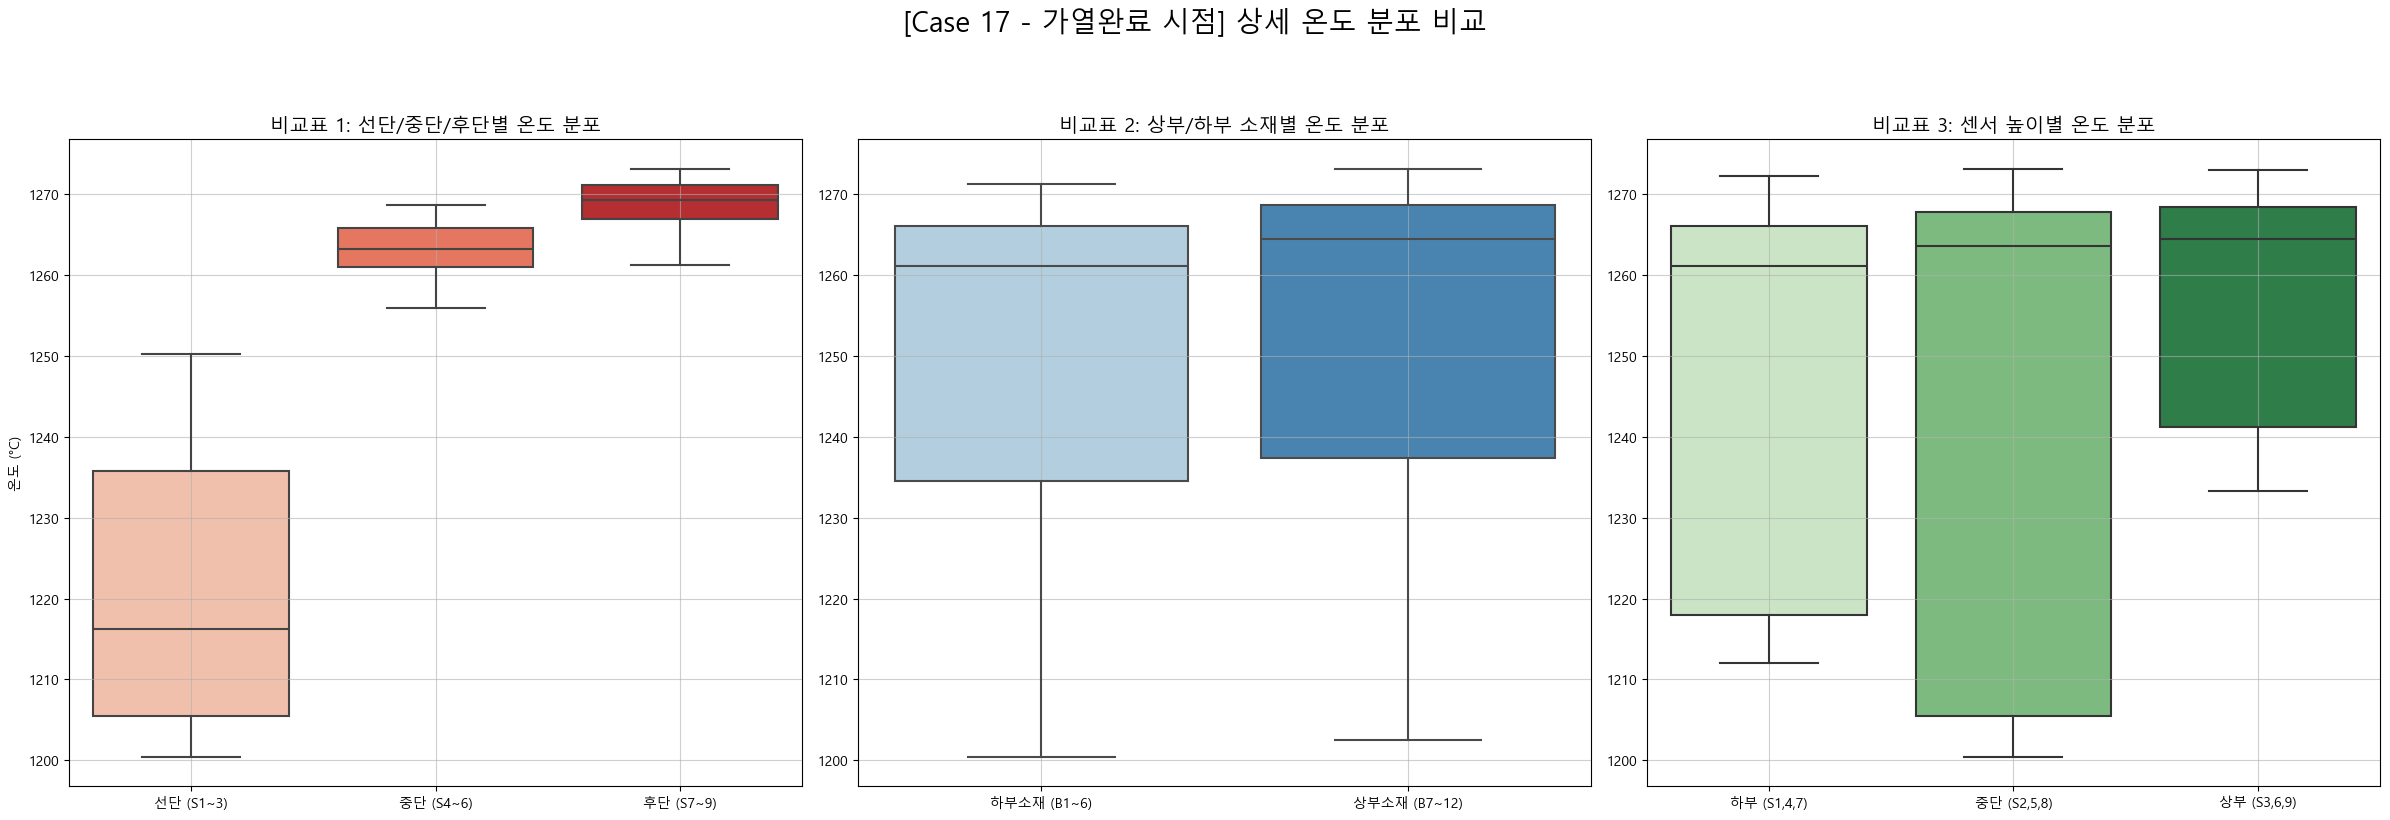

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean   std     min     25%     50%     75%     max
위치 (선/중/후)                                                             
선단 (S1~3)   36.00 1219.70 15.34 1200.43 1205.46 1216.18 1235.73 1250.17
중단 (S4~6)   36.00 1263.10  3.35 1255.94 1260.92 1263.16 1265.75 1268.65
후단 (S7~9)   36.00 1268.83  2.94 1261.20 1266.89 1269.22 1271.14 1273.14

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean   std     min     25%     50%     75%     max
소재 위치 (상/하)                                                              
상부소재 (B7~12)  54.00 1251.85 24.07 1202.47 1237.37 1264.44 1268.61 1273.14
하부소재 (B1~6)   54.00 1249.24 23.79 1200.43 1234.56 1261.07 1266.04 1271.22

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean   std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                             
상부 (S3,6,9)    36.00 

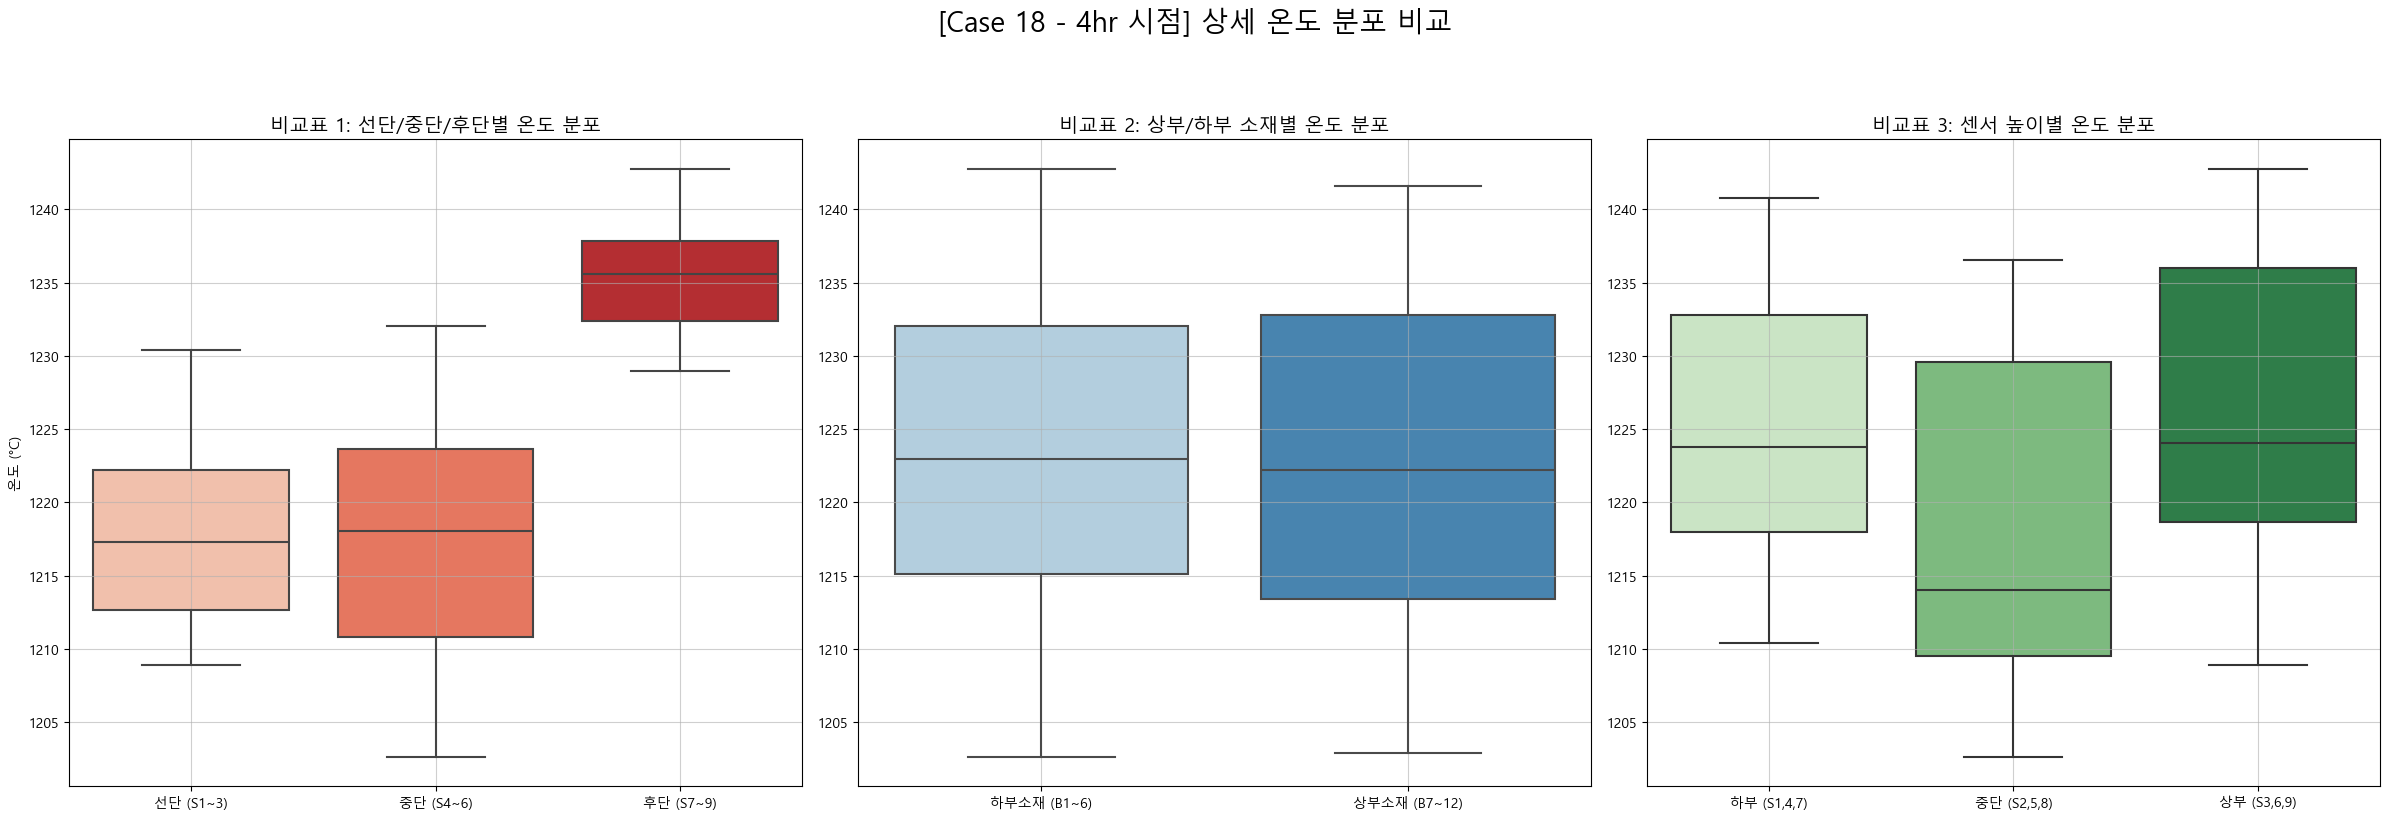

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1217.50 5.93 1208.91 1212.67 1217.33 1222.24 1230.38
중단 (S4~6)   36.00 1216.64 8.46 1202.63 1210.83 1218.02 1223.64 1232.07
후단 (S7~9)   36.00 1235.06 3.83 1228.94 1232.39 1235.57 1237.87 1242.79

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean   std     min     25%     50%     75%     max
소재 위치 (상/하)                                                              
상부소재 (B7~12)  54.00 1222.71 10.84 1202.87 1213.39 1222.18 1232.80 1241.59
하부소재 (B1~6)   54.00 1223.42 10.45 1202.63 1215.13 1222.99 1232.07 1242.79

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean   std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                             
상부 (S3,6,9)    36.00 1226.

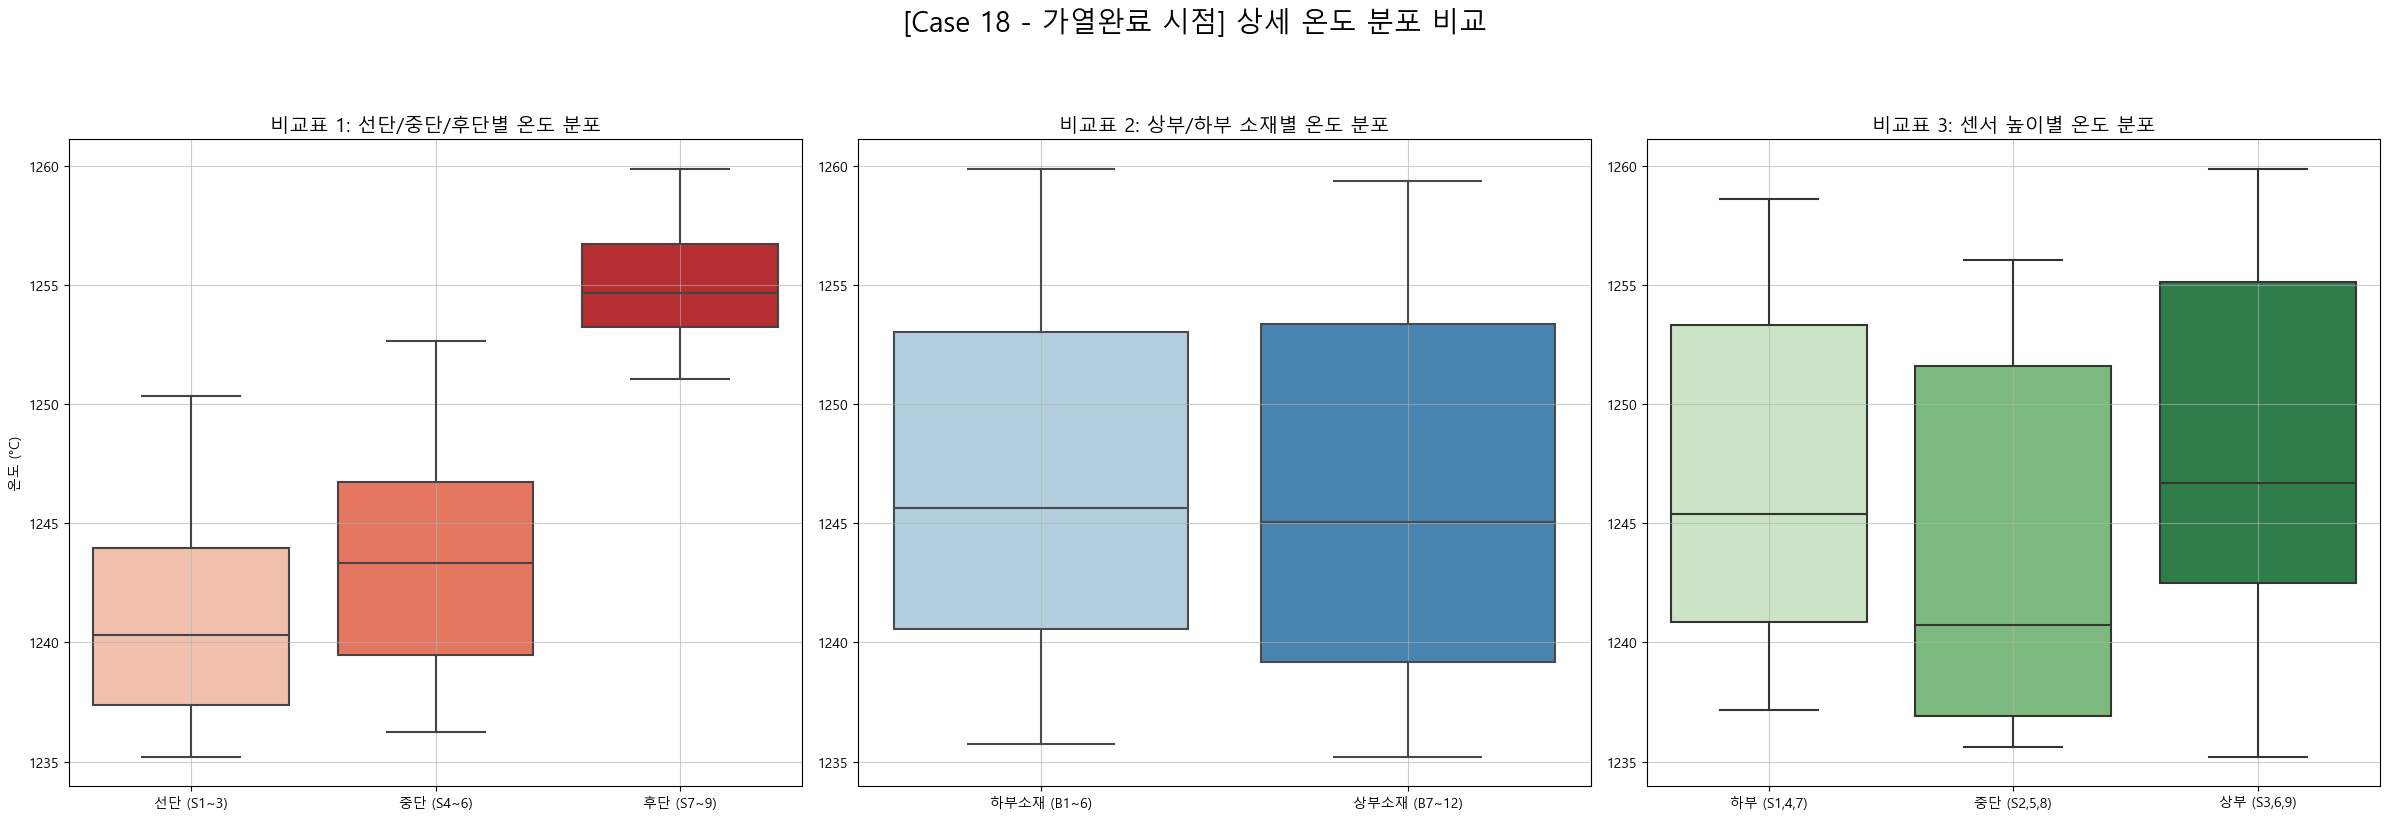

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1240.80 4.06 1235.20 1237.39 1240.33 1243.97 1250.35
중단 (S4~6)   36.00 1243.27 4.66 1236.23 1239.48 1243.35 1246.74 1252.66
후단 (S7~9)   36.00 1255.08 2.41 1251.05 1253.24 1254.65 1256.70 1259.88

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                             
상부소재 (B7~12)  54.00 1246.00 7.61 1235.20 1239.20 1245.04 1253.36 1259.34
하부소재 (B1~6)   54.00 1246.77 7.07 1235.75 1240.58 1245.63 1253.01 1259.88

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    36.00 1248.12 7.4

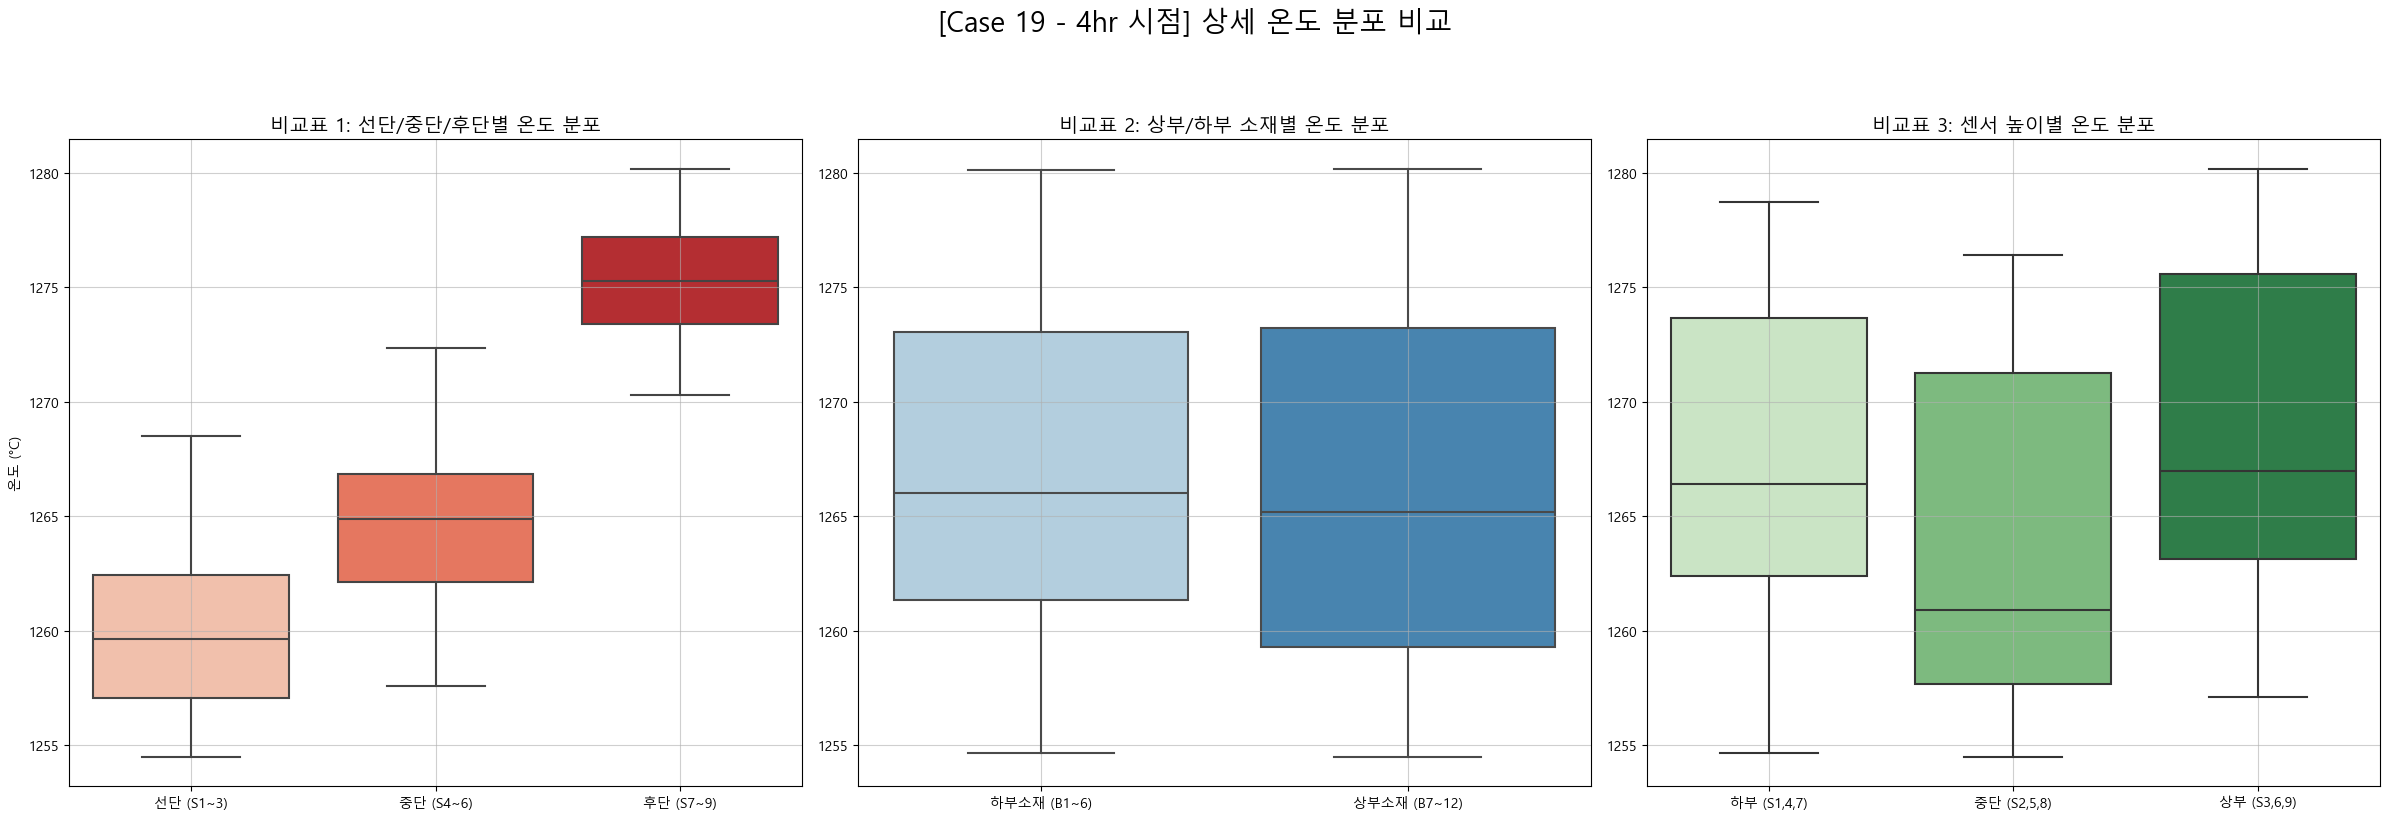

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1260.02 3.93 1254.50 1257.09 1259.66 1262.46 1268.49
중단 (S4~6)   36.00 1264.46 4.15 1257.61 1262.13 1264.88 1266.85 1272.35
후단 (S7~9)   36.00 1275.24 2.65 1270.32 1273.41 1275.27 1277.20 1280.19

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                             
상부소재 (B7~12)  54.00 1266.21 7.75 1254.50 1259.29 1265.18 1273.23 1280.19
하부소재 (B1~6)   54.00 1266.94 7.00 1254.66 1261.33 1266.04 1273.04 1280.11

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    36.00 1268.61 7.0

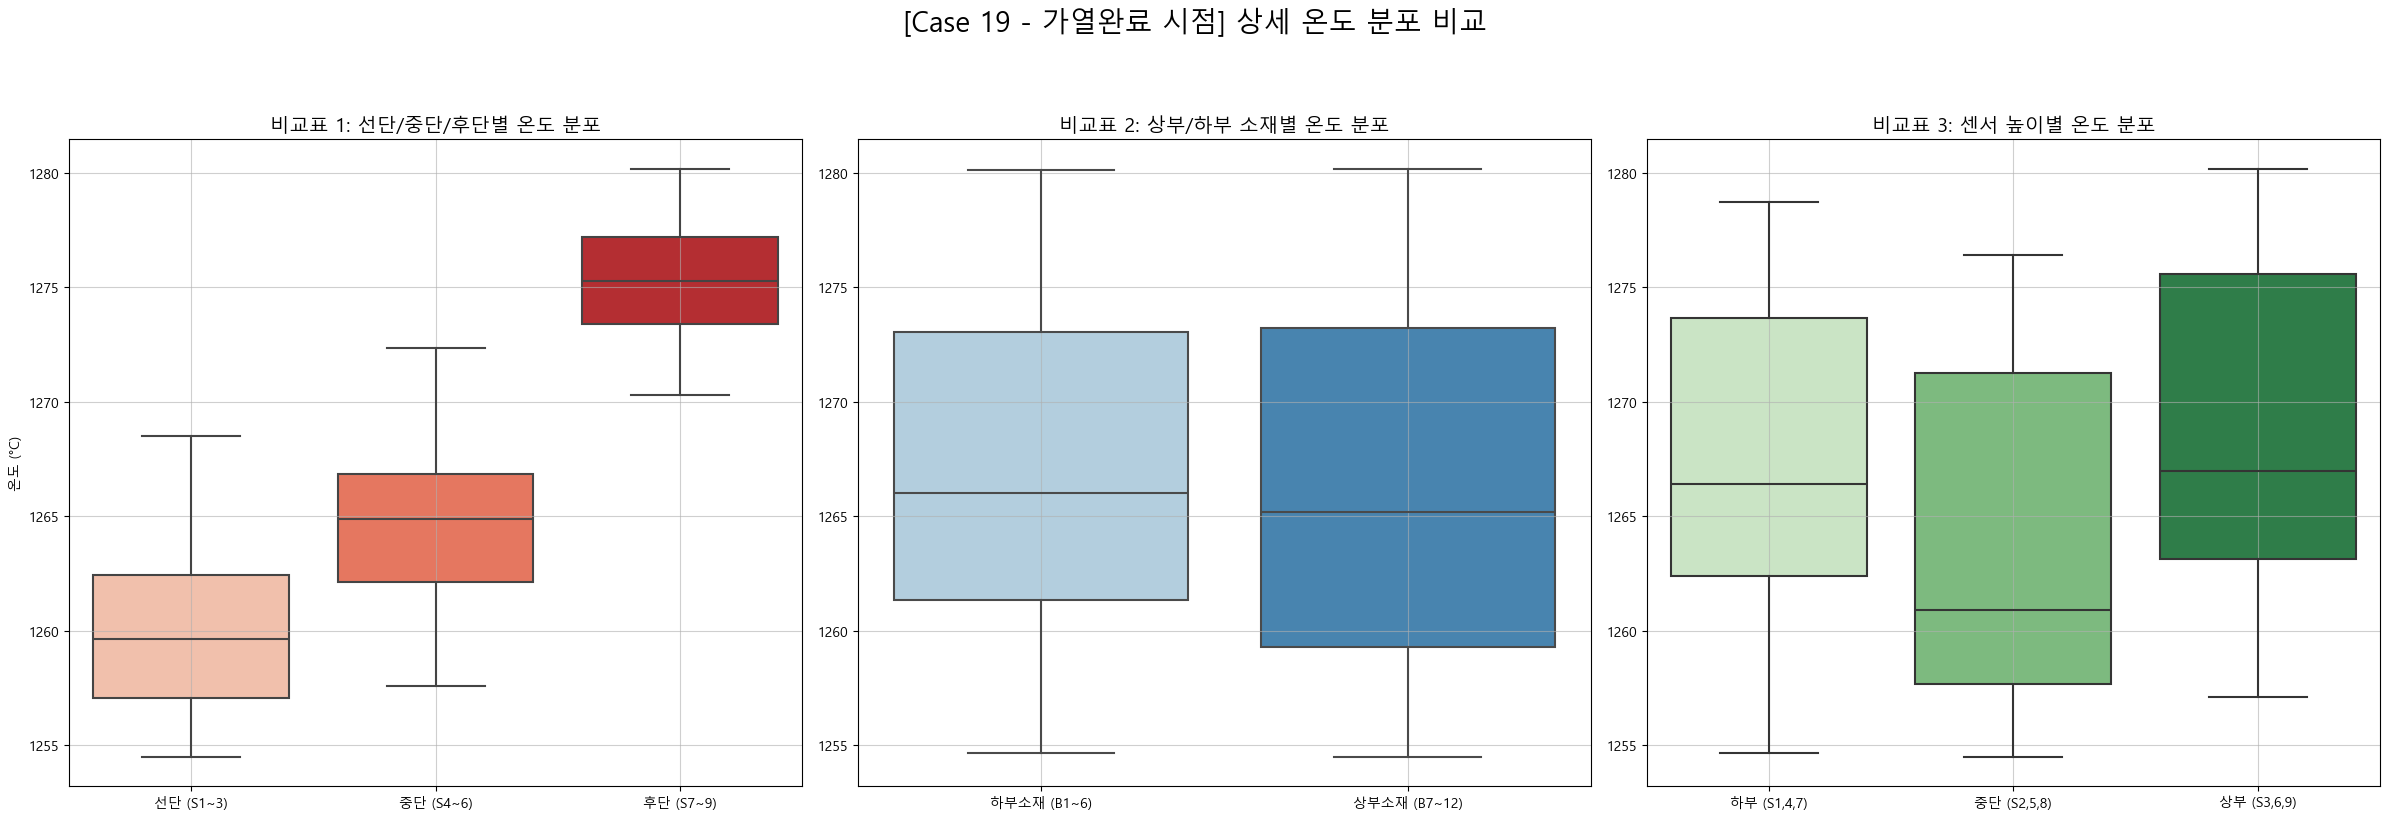

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1260.02 3.93 1254.50 1257.09 1259.66 1262.46 1268.49
중단 (S4~6)   36.00 1264.46 4.15 1257.61 1262.13 1264.88 1266.85 1272.35
후단 (S7~9)   36.00 1275.24 2.65 1270.32 1273.41 1275.27 1277.20 1280.19

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                             
상부소재 (B7~12)  54.00 1266.21 7.75 1254.50 1259.29 1265.18 1273.23 1280.19
하부소재 (B1~6)   54.00 1266.94 7.00 1254.66 1261.33 1266.04 1273.04 1280.11

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    36.00 1268.61 7.0

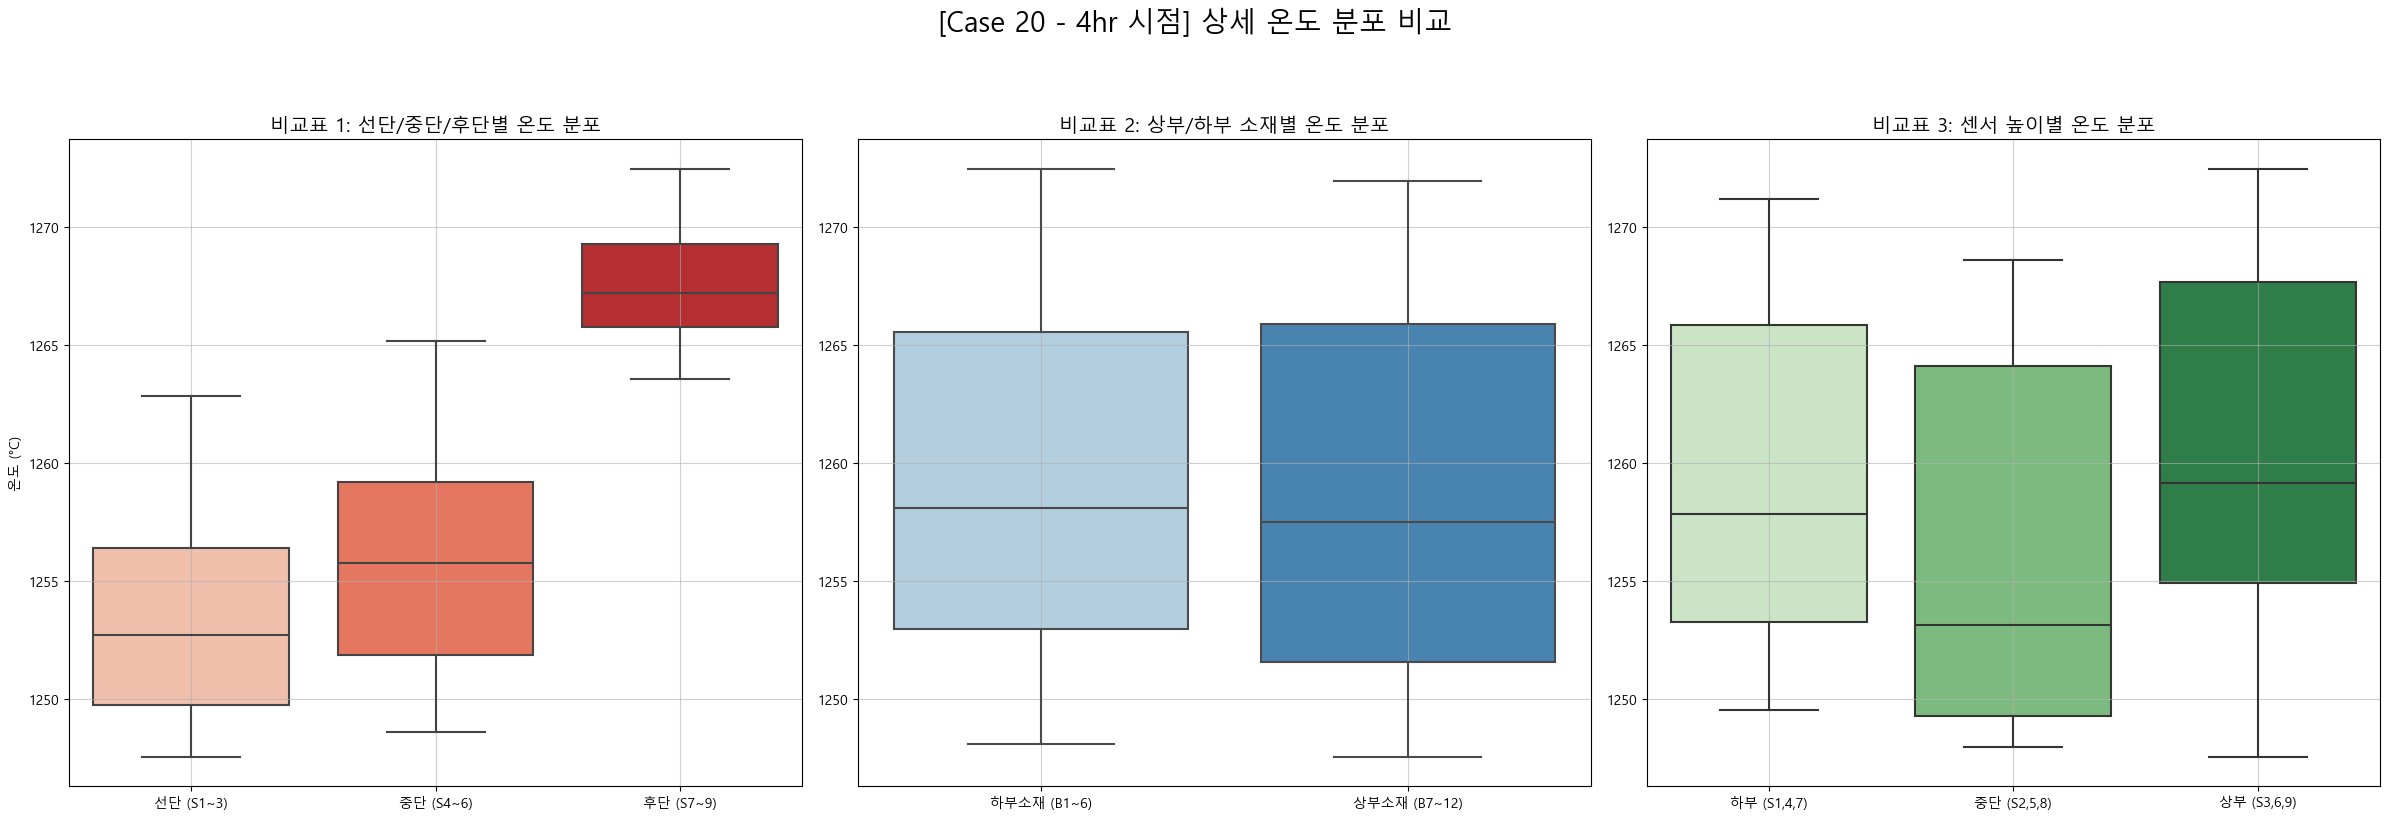

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()
c:\python_study\venv\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)



[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1253.21 4.10 1247.55 1249.77 1252.73 1256.40 1262.85
중단 (S4~6)   36.00 1255.70 4.71 1248.59 1251.88 1255.78 1259.21 1265.19
후단 (S7~9)   36.00 1267.63 2.44 1263.56 1265.77 1267.20 1269.27 1272.48

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                             
상부소재 (B7~12)  54.00 1258.46 7.69 1247.55 1251.59 1257.49 1265.90 1271.93
하부소재 (B1~6)   54.00 1259.24 7.14 1248.11 1252.98 1258.09 1265.54 1272.48

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    36.00 1260.61 7.4

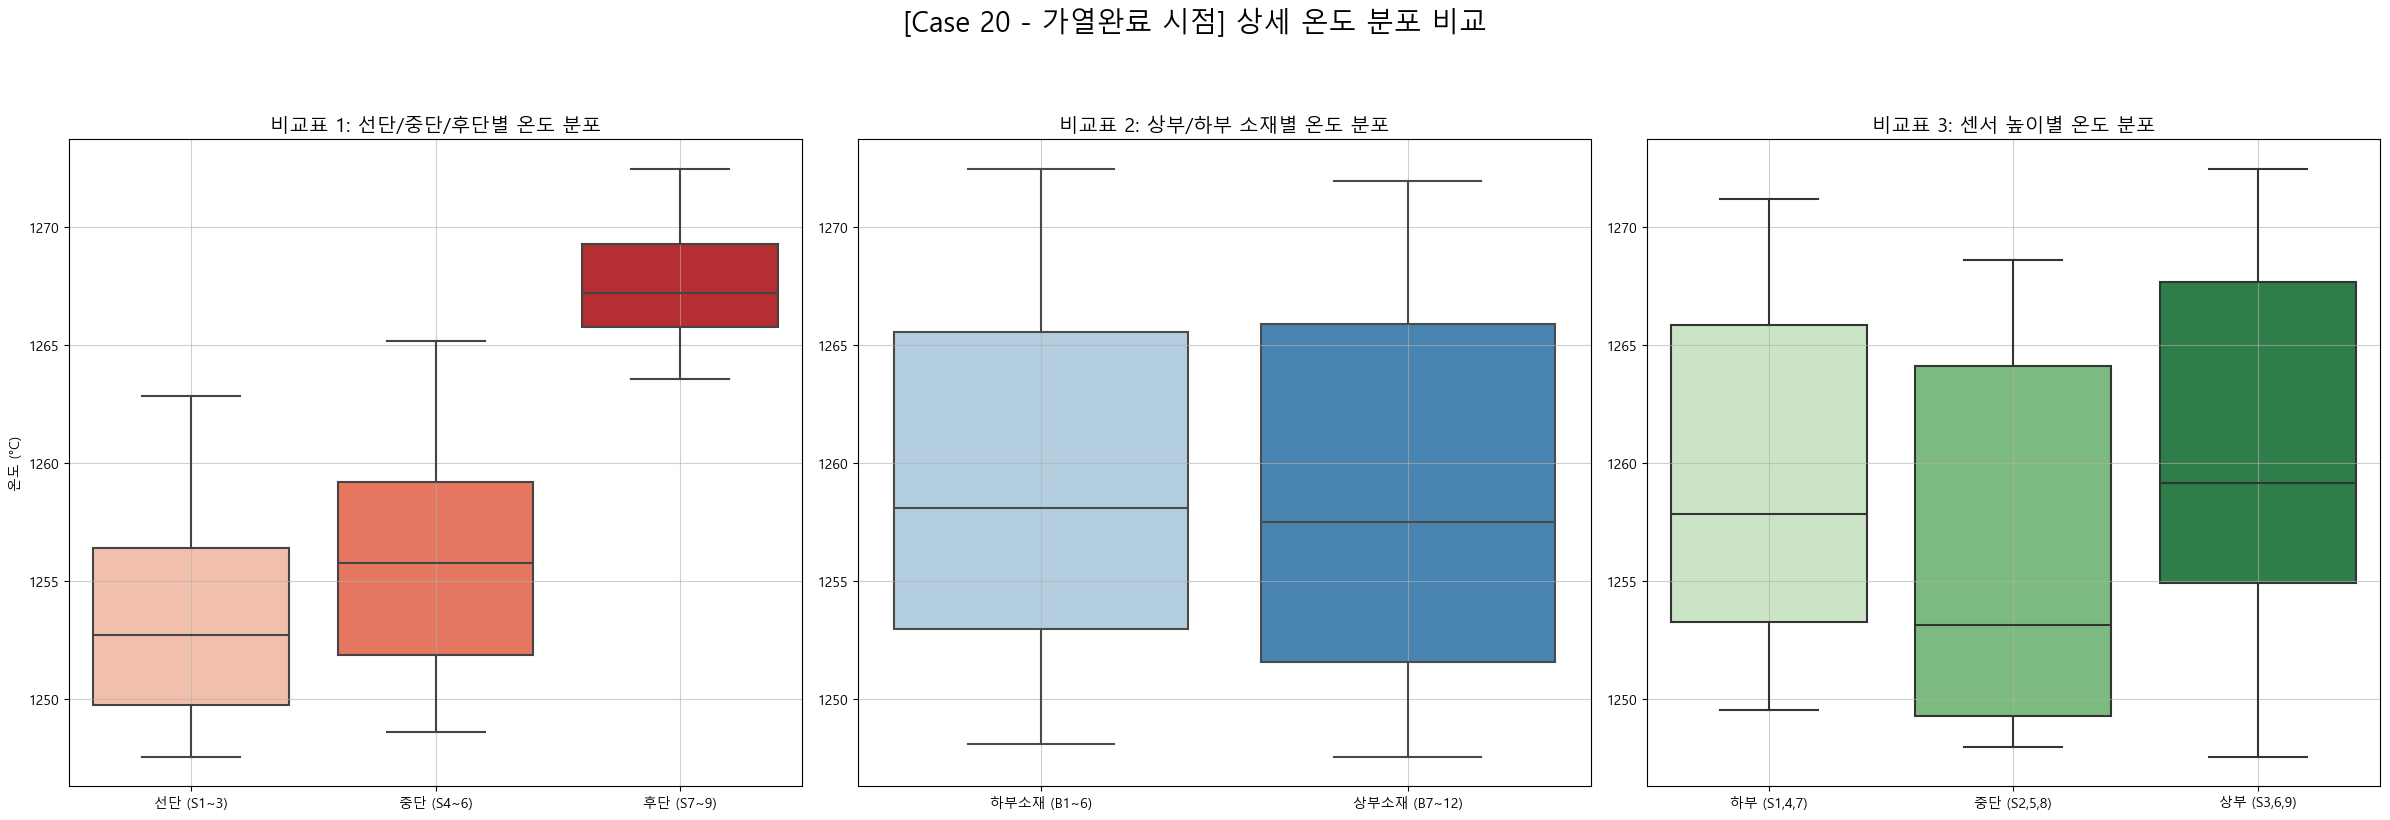


[비교표 1: 선단/중단/후단별 통계]

            count    mean  std     min     25%     50%     75%     max
위치 (선/중/후)                                                            
선단 (S1~3)   36.00 1253.21 4.10 1247.55 1249.77 1252.73 1256.40 1262.85
중단 (S4~6)   36.00 1255.70 4.71 1248.59 1251.88 1255.78 1259.21 1265.19
후단 (S7~9)   36.00 1267.63 2.44 1263.56 1265.77 1267.20 1269.27 1272.48

--------------------------------------------------

[비교표 2: 상부/하부 소재별 통계]

              count    mean  std     min     25%     50%     75%     max
소재 위치 (상/하)                                                             
상부소재 (B7~12)  54.00 1258.46 7.69 1247.55 1251.59 1257.49 1265.90 1271.93
하부소재 (B1~6)   54.00 1259.24 7.14 1248.11 1252.98 1258.09 1265.54 1272.48

--------------------------------------------------

[비교표 3: 센서 높이별 통계]

               count    mean  std     min     25%     50%     75%     max
센서 위치 (상/중/하)                                                            
상부 (S3,6,9)    36.00 1260.61 7.4

C:\Users\CTE25-034\AppData\Local\Temp\ipykernel_24756\1824806483.py:395: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats1 = case_df.groupby('위치 (선/중/후)')['Value'].describe()


In [7]:
# ==============================================================================
# Step 4a. [케이스별 상세 분석 실행]
# ==============================================================================
if 'heating_sensor_df' in locals():
    detailed_analysis_cases = [case for case in selected_cases if '냉각' not in case]
    analysis_time_points = ["4hr 시점", "가열완료 시점"]
    
    for case in detailed_analysis_cases:
        for time_point in analysis_time_points:
             analyze_case_details(bloom_sensor_df, case, time_point)
else:
    print("데이터가 로드되지 않았습니다. Step 1을 먼저 실행해주세요.")


In [4]:
# ==============================================================================
# Step 0. [환경설정] - 한글 폰트/필수 패키지 임포트
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os
import re
from typing import Dict, List, Optional, Tuple
from math import ceil

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
try:
    matplotlib.rc('font', family='Malgun Gothic')
except:
    matplotlib.rc('font', family='AppleGothic')
matplotlib.rc('axes', unicode_minus=False)

# ==============================================================================
# Step 1. [분석 함수 정의]
# ==============================================================================
def find_header_row(file_path: str, sheet_name: str) -> int:
    """
    엑셀 시트에서 'time' 문자열이 포함된 행을 찾아 헤더로 사용될 행 번호를 반환합니다.
    """
    try:
        tmp_df = pd.read_excel(file_path, sheet_name=sheet_name, engine='openpyxl', header=None, nrows=20)
        for i, row in tmp_df.iterrows():
            if any('time' in str(cell).strip().lower() for cell in row):
                return i
    except Exception as e:
        print(f"'{sheet_name}' 시트에서 헤더를 찾는 중 오류 발생: {e}")
    return 0

def extract_bloom_sensor_table(df: pd.DataFrame, sheet_name: str, time_point: float) -> Optional[pd.DataFrame]:
    """
    주어진 데이터프레임에서 특정 시점(time_point)의 Bloom 센서 데이터를 추출하여 테이블 형태로 가공합니다.
    """
    try:
        time_col = next((col for col in df.columns if 'time' in str(col).lower()), None)
        if not time_col:
            print(f"'{sheet_name}' 시트에서 Time 컬럼을 찾을 수 없습니다.")
            return None

        df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
        if df[time_col].isna().all():
            print(f"'{sheet_name}' 시트의 Time 컬럼에 유효한 숫자 데이터가 없습니다.")
            return None
        
        time_data_row = df.iloc[df[time_col].sub(time_point).abs().idxmin()]

        rows = []
        for i in range(1, 19):
            for j in range(1, 10):
                col_name = f'Bloom {i} sensor {j}'
                if col_name in df.columns:
                    value = time_data_row.get(col_name)
                    if pd.notna(value):
                        rows.append({"Case": sheet_name, "Time": time_point, "Bloom": i, "Sensor": j, "Value": value})

        return pd.DataFrame(rows) if rows else None
    except Exception as e:
        print(f"'{sheet_name}' 시트, {time_point}초 시점 데이터 추출 중 오류: {e}")
        return None

def extract_cooling_curve_data(df: pd.DataFrame, sheet_name: str, start_time: float, duration: float) -> Optional[pd.DataFrame]:
    """
    냉각 시작 시점부터 지정된 시간 동안의 온도 변화 데이터를 추출합니다.
    """
    try:
        time_col = next((col for col in df.columns if 'time' in str(col).lower()), None)
        if not time_col: return None

        df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
        
        cooling_df = df[(df[time_col] >= start_time) & (df[time_col] <= start_time + duration)].copy()
        if cooling_df.empty: return None

        cooling_df['경과 시간(초)'] = cooling_df[time_col] - start_time
        
        sensor_cols = [col for col in df.columns if 'sensor' in str(col).lower()]
        cooling_df['평균 온도'] = cooling_df[sensor_cols].mean(axis=1)
        
        sampled_times = np.arange(0, duration + 1, 20)
        resampled_data = []
        for t in sampled_times:
            closest_row = cooling_df.iloc[cooling_df['경과 시간(초)'].sub(t).abs().idxmin()]
            resampled_data.append(closest_row)
        
        result_df = pd.DataFrame(resampled_data)[['경과 시간(초)', '평균 온도']]
        result_df['Case'] = sheet_name
        return result_df

    except Exception as e:
        print(f"'{sheet_name}'에서 냉각 곡선 데이터 추출 중 오류: {e}")
        return None


def natural_sort_key(s: str) -> tuple:
    """
    "Case 1", "Case 10", "Case 2*"와 같은 문자열을 자연스럽게 정렬하기 위한 키를 생성합니다.
    """
    match = re.match(r'Case (\d+)(.*)', s)
    if match:
        number, suffix = match.groups()
        return int(number), suffix.strip()
    return (float('inf'), s)

# ==============================================================================
# Step 1a. [데이터 로딩 및 전처리 실행]
# ==============================================================================
# --- 분석 환경 설정 ---
excel_file_path = "250718_가열로 시뮬레이션 results4_가공.xlsx"
target_temperature = 1280.0

# --- 메타데이터 정의 ---
case_meta_data = {
    'Case': [
        'Case 1', 'Case 2', 'Case 2*', 'Case 3', 'Case 4', 'Case 5', 'Case 6', 'Case 7', 'Case 8', 'Case 8 냉각',
        'Case 9', 'Case 10', 'Case 11', 'Case 11 추가', 'Case 12', 'Case 13', 'Case 13 추가', 'Case 14', 'Case 14 추가',
        'Case 15', 'Case 15 냉각', 'Case 16', 'Case 17', 'Case 18', 'Case 18 냉각', 'Case 19', 'Case 20'
    ],
    'Sheet_Name': [
        'Case 1', 'Case 2', 'Case 2"', 'Case 3', 'Case 4', 'Case 5', 'Case 6', 'Case 7', 'Case 8', 'Case 8 냉각',
        'Case 9', 'Case 10', 'Case 11', 'Case 11 추가', 'Case 12', 'Case 13', 'Case 13 추가', 'Case 14', 'Case 14 추가',
        'Case 15', 'Case 15 냉각', 'Case 16', 'Case 17', 'Case 18', 'Case 18 냉각', 'Case 19', 'Case 20'
    ],
    'Furnace': [
        'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type',
        'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type', 'Batch-Type',
        'Soaking-Pit', 'Soaking-Pit', 'Soaking-Pit', 'Soaking-Pit', 'Soaking-Pit', 'Soaking-Pit', 'Soaking-Pit', 'Soaking-Pit'
    ],
    '작업방향': [
        'Longitudinal', 'Longitudinal', 'Longitudinal', 'Longitudinal', 'Longitudinal', 'Longitudinal', 'Longitudinal', 'Longitudinal', 'Longitudinal', 'Longitudinal',
        'Longitudinal', 'Longitudinal', 'Transverse', 'Transverse', 'Transverse', 'Transverse', 'Transverse', 'Transverse', 'Transverse',
        '수직 장입', '수직 장입', '수직 장입', '수직 장입', '수직 장입', '수직 장입', '수직 장입', '수직 장입'
    ],
    '적치단수': [ '2단', '2단', '2단', '1단', '2단', '2단', '2단', '2단', '1단', '1단', '2단', '2단', '2단', '2단', '1단', '2단', '2단', '2단', '2단', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X' ],
    '서포트높이': [ '250mm', '250mm', '250mm', '250mm', '250mm', '250mm', '470mm', '470mm', '470mm', '470mm', '470mm', '470mm', '250mm', '250mm', '250mm', '250mm', '250mm', '470mm', '470mm', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X' ],
    '작업방법': [ '2단(2-1)', '2단(2-5hr-1)', '2단(2-5hr-1)', '1단', '2단(2-1)', '2단(2-5hr-1)', '2단(2-1)', '2단(2-5hr-1)', '1단', '1단', '2단(2-1)', '2단(2-5hr-1)', '2단(2-1)', '2단(2-1)', '1단', '2단(2-5hr-1)', '2단(2-1)', '2단(2-1)', '2단(2-1)', '-', '-', '-', '-', '-', '-', '-', '-' ],
    '제어': [ '1Zone', '1Zone', '1Zone', '1Zone', '2Zone', '2Zone', '1Zone', '1Zone', '1Zone', '1Zone', '2Zone', '2Zone', '1Zone', '1Zone', '1Zone', '2Zone', '2Zone', '2Zone', '2Zone', '1Zone', '1Zone', '1Zone', '2Zone', '2Zone', '2Zone', '1Zone', '2Zone' ],
    '냉각': [ '-', '-', '7zone 37332초 후 온도고정', '-', '-', '-', '-', '-', '-', '대기 냉각 추가 (600초)', '-', '-', '추가 해석', '추가 해석', '-', '추가 해석', '추가 해석', '추가 해석', '추가 해석', '-', '대기 냉각 추가 (600초)', '-', '625', '-', '대기 냉각 추가 (600초)=625', '-', '-' ]
}
case_meta_df_all = pd.DataFrame(case_meta_data)

# --- 분석 대상 케이스 선택 ---
selected_cases = [
    'Case 1', 'Case 2', 'Case 2*','Case 3', 'Case 4', 'Case 5', 'Case 6', 'Case 9', 'Case 10', 
    'Case 11 추가', 'Case 13 추가', 'Case 14 추가', 
    'Case 15', 'Case 16', 'Case 17', 'Case 18', 'Case 19', 'Case 20',
    'Case 8 냉각', 'Case 15 냉각', 'Case 18 냉각'
]
case_meta_df = case_meta_df_all[case_meta_df_all['Case'].isin(selected_cases)].copy()
case_meta_df.reset_index(drop=True, inplace=True)

case_sheets = case_meta_df['Sheet_Name'].tolist()

time_points = { "4hr 시점": 47860.0, "가열완료 시점": 57382.5, "냉각완료 시점": 57382.5 + 600 }

# --- 엑셀 시트 미리 읽어오기 ---
print("엑셀 파일 로딩 시작...")
all_sheets_data = {}
if os.path.exists(excel_file_path):
    for sheet in case_sheets:
        try:
            df = pd.read_excel(excel_file_path, sheet_name=sheet, engine='openpyxl', header=find_header_row(excel_file_path, sheet))
            all_sheets_data[sheet] = df
        except Exception as e:
            print(f"'{sheet}' 시트 로딩 실패: {e}")
else:
    print(f"오류: 엑셀 파일을 찾을 수 없습니다 - {excel_file_path}")

print(f"엑셀 파일 로딩 완료. ({len(all_sheets_data)}/{len(case_sheets)} 시트)")

# --- 데이터 추출 및 병합 ---
if all_sheets_data:
    print("데이터 추출 및 가공 시작...")
    bloom_sensor_all = []
    cooling_curve_all = []
    long_heating_cases = case_meta_df[case_meta_df['작업방법'].str.contains('2-5hr', na=False)]['Sheet_Name'].tolist()
    special_completion_time = 75382.5

    for sheet, df in all_sheets_data.items():
        meta_info = case_meta_df[case_meta_df['Sheet_Name'] == sheet].iloc[0]
        heat_time = special_completion_time if sheet in long_heating_cases else time_points["가열완료 시점"]
        
        for time_desc, time_val in [("4hr 시점", time_points["4hr 시점"]), ("가열완료 시점", heat_time)]:
            result = extract_bloom_sensor_table(df, sheet, time_val)
            if result is not None:
                result["TimeDesc"] = time_desc
                bloom_sensor_all.append(result)

        is_cooling_case = '냉각' in meta_info['Case']
        if is_cooling_case:
            curve_data = extract_cooling_curve_data(df, meta_info['Case'], 0, 600)
            if curve_data is not None:
                cooling_curve_all.append(curve_data)

    if bloom_sensor_all:
        bloom_sensor_df = pd.concat(bloom_sensor_all, ignore_index=True)
        bloom_sensor_df.rename(columns={'Case': 'Sheet_Name'}, inplace=True)
        bloom_sensor_df = pd.merge(bloom_sensor_df, case_meta_df, on="Sheet_Name")

        summary_cols = ['Case', 'TimeDesc', 'Bloom', 'Furnace', '작업방향', '서포트높이', '제어', '적치단수', '작업방법']
        bloom_summary = (
            bloom_sensor_df.groupby([col for col in summary_cols if col in bloom_sensor_df.columns])
            .agg(평균=('Value', 'mean'), 내부ΔT=('Value', lambda x: np.nanmax(x) - np.nanmin(x) if x.notna().any() else np.nan))
            .reset_index()
        )
        
        cooling_case_names = case_meta_df[case_meta_df['Case'].str.contains('냉각')]['Case'].tolist()
        heating_summary = bloom_summary[~bloom_summary['Case'].isin(cooling_case_names)]
        heating_sensor_df = bloom_sensor_df[~bloom_sensor_df['Case'].isin(cooling_case_names)]
        
        print("데이터 준비 완료.")
    else:
        print("추출된 데이터가 없어 분석을 진행할 수 없습니다.")


엑셀 파일 로딩 시작...
엑셀 파일 로딩 완료. (21/21 시트)
데이터 추출 및 가공 시작...
데이터 준비 완료.



[Case 1, Case 4] - [4hr 시점] 비교 분석


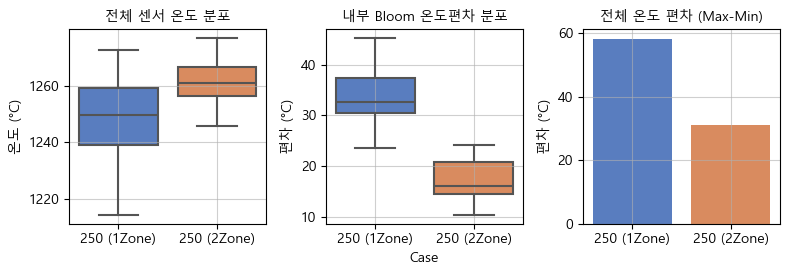

In [46]:
# ==============================================================================
# Step 0. [환경설정] - 이전 코드 블록의 데이터 사용
# ==============================================================================
# 이 코드는 이전 블록에서 생성된 'bloom_sensor_df' 데이터프레임이
# 메모리에 로드되어 있다고 가정하고 동작합니다.
# 만약 이 블록만 단독으로 실행하려면, 이전 코드의 데이터 로딩 부분을 여기에 포함해야 합니다.

# ==============================================================================
# Step 1. [신규 분석 함수 정의] - 특정 케이스 비교용
# ==============================================================================
def compare_specific_cases(sensor_df: pd.DataFrame, cases_to_compare: List[str], time_desc: str, label_map: Optional[Dict[str, str]] = None):
    """
    지정된 케이스 목록과 시간에 대해 3가지 유형의 비교 Boxplot을 생성하고 통계량을 출력합니다.
    
    Args:
        sensor_df (pd.DataFrame): 전체 센서 데이터가 포함된 데이터프레임.
        cases_to_compare (List[str]): 비교할 케이스 이름의 리스트.
        time_desc (str): 분석할 시간 시점 ('4hr 시점' 또는 '가열완료 시점').
        label_map (Optional[Dict[str, str]]): X축에 표시될 케이스 이름을 변경하기 위한 딕셔너리.
    """
    print("\n" + "="*80 + f"\n[{', '.join(cases_to_compare)}] - [{time_desc}] 비교 분석\n" + "="*80)
    
    # 1. 분석 대상 데이터 필터링
    df_filtered = sensor_df[(sensor_df['Case'].isin(cases_to_compare)) & (sensor_df['TimeDesc'] == time_desc)].copy()
    
    if df_filtered.empty:
        print("선택하신 조건에 해당하는 데이터가 없습니다. 케이스 이름과 시간 시점을 확인해주세요.")
        return

    # 2. 분석에 필요한 데이터 가공
    # 2a. 내부 Bloom 온도 편차 계산
    bloom_delta_t = df_filtered.groupby(['Case', 'Bloom'])['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    bloom_delta_t.rename(columns={'Value': '내부 Bloom 온도편차(ΔT)'}, inplace=True)

    # 2b. 케이스별 전체 온도 편차 (Max-Min) 계산
    case_total_delta_t = df_filtered.groupby('Case')['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    case_total_delta_t.rename(columns={'Value': '전체 온도 편차(Max-Min)'}, inplace=True)

    # 3. 시각화를 위한 라벨 변경 및 순서 정의
    plot_order = [case for case in cases_to_compare if case in df_filtered['Case'].unique()]
    
    if label_map:
        # 데이터프레임의 'Case' 컬럼 값을 새로운 라벨로 변경 (복사본 사용)
        df_filtered['Case'] = df_filtered['Case'].replace(label_map)
        bloom_delta_t['Case'] = bloom_delta_t['Case'].replace(label_map)
        case_total_delta_t['Case'] = case_total_delta_t['Case'].replace(label_map)
        
        # 플롯 순서도 새로운 라벨에 맞게 업데이트
        plot_order = [label_map.get(case, case) for case in plot_order]

    # 4. 시각화
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))
    #fig.suptitle(f'[{time_desc}] 선택 케이스 비교 분석', fontsize=14, y=1.02)

    # 그래프 1: 전체 센서 온도 분포
    sns.boxplot(ax=axes[0], x='Case', y='Value', data=df_filtered, palette='muted', order=plot_order)
    axes[0].set_title('전체 센서 온도 분포', fontsize=10)
    axes[0].set_ylabel('온도 (°C)')
    axes[0].set_xlabel('')
    axes[0].grid(True, alpha=0.6)
    axes[0].tick_params(axis='x', rotation=0)

    # 그래프 2: 내부 Bloom 온도편차 분포
    sns.boxplot(ax=axes[1], x='Case', y='내부 Bloom 온도편차(ΔT)', data=bloom_delta_t, palette='muted', order=plot_order)
    axes[1].set_title('내부 Bloom 온도편차 분포', fontsize=10)
    axes[1].set_ylabel('편차 (°C)')
    axes[1].set_xlabel('Case')
    axes[1].grid(True, alpha=0.6)
    axes[1].tick_params(axis='x', rotation=0)

    # 그래프 3: 전체 온도 편차 (Max-Min)
    sns.barplot(ax=axes[2], x='Case', y='전체 온도 편차(Max-Min)', data=case_total_delta_t, palette='muted', order=plot_order)
    axes[2].set_title('전체 온도 편차 (Max-Min)', fontsize=10)
    axes[2].set_ylabel('편차 (°C)')
    axes[2].set_xlabel('')
    axes[2].grid(True, alpha=0.6)
    axes[2].tick_params(axis='x', rotation=0)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ==============================================================================
# Step 2. [비교 분석 실행] - 여기만 수정하세요!
# ==============================================================================
# --- 1. 비교하고 싶은 케이스를 리스트에 추가하세요 ---
cases_to_compare = ['Case 1', 'Case 4']

# --- 2. X축에 표시될 이름을 변경하고 싶으면 아래 딕셔너리를 수정하세요 (선택 사항) ---
# 예시: case_label_map = {'Case 1': '기존 조건', 'Case 4': '개선 조건'}
case_label_map = {
    'Case 1': '250 (1Zone)',
    'Case 4': '250 (2Zone)'
}


# --- 분석 실행 ---
if 'heating_sensor_df' in locals():
    compare_specific_cases(
        sensor_df=heating_sensor_df, 
        cases_to_compare=cases_to_compare, 
        time_desc='4hr 시점',
        label_map=case_label_map
    )
else:
    print("데이터가 로드되지 않았습니다. 이전 코드 블록(Step 1)을 먼저 실행해주세요.")




[Case 1 (4hr 시점) vs Case 4 (4hr 시점)] 비교 분석


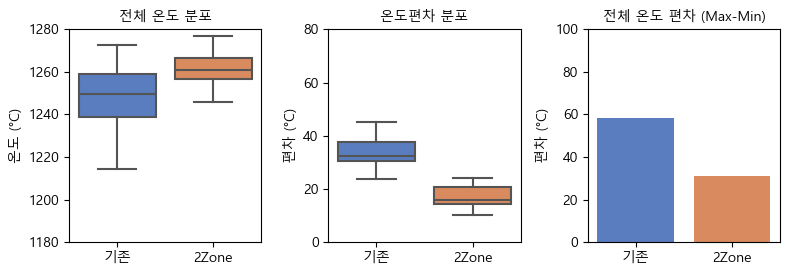


[통계 데이터]

[그래프 1: 전체 온도 분포 통계]

        count    mean   std     min     25%     50%     75%     max
Case                                                               
Case 1 108.00 1248.44 13.43 1214.47 1238.98 1249.62 1259.04 1272.69
Case 4 108.00 1261.47  7.27 1245.76 1256.44 1260.93 1266.58 1276.76


[그래프 2: 온도편차 분포 통계]

        count  mean  std   min   25%   50%   75%   max
Case                                                  
Case 1  12.00 33.58 6.95 23.58 30.53 32.55 37.48 45.27
Case 4  12.00 16.86 4.66 10.32 14.38 15.94 20.84 24.09


[그래프 3: 전체 온도 편차 (Max-Min) 값]

        전체 온도 편차(Max-Min)
Case                     
Case 1              58.22
Case 4              31.00


In [57]:
# ==============================================================================
# Step 0. [환경설정] - 이전 코드 블록의 데이터 사용
# ==============================================================================
# 이 코드는 이전 블록에서 생성된 'bloom_sensor_df' 데이터프레임이
# 메모리에 로드되어 있다고 가정하고 동작합니다.
# 만약 이 블록만 단독으로 실행하려면, 이전 코드의 데이터 로딩 부분을 여기에 포함해야 합니다.

# ==============================================================================
# Step 1. [신규 분석 함수 정의] - 특정 케이스 비교용
# ==============================================================================
def compare_specific_cases(
    sensor_df: pd.DataFrame, 
    cases_and_times: Dict[str, str], 
    label_map: Optional[Dict[str, str]] = None,
    y_lim_temp: Optional[Tuple[float, float]] = None,
    y_lim_delta_bloom: Optional[Tuple[float, float]] = None,
    y_lim_delta_total: Optional[Tuple[float, float]] = None
):
    """
    지정된 케이스 목록과 각기 다른 시간에 대해 3가지 유형의 비교 Boxplot을 생성하고 통계량을 출력합니다.
    
    Args:
        sensor_df (pd.DataFrame): 전체 센서 데이터가 포함된 데이터프레임.
        cases_and_times (Dict[str, str]): {'케이스 이름': '시간 시점'} 형태의 딕셔너리.
        label_map (Optional[Dict[str, str]]): X축에 표시될 케이스 이름을 변경하기 위한 딕셔너리.
        y_lim_temp (Optional[Tuple[float, float]]): '전체 온도 분포' 그래프의 Y축 범위.
        y_lim_delta_bloom (Optional[Tuple[float, float]]): '내부 Bloom 편차' 그래프의 Y축 범위.
        y_lim_delta_total (Optional[Tuple[float, float]]): '전체 온도 편차' 그래프의 Y축 범위.
    """
    # 동적 제목 생성을 위한 문자열 조합
    title_info = ' vs '.join([f"{case} ({time_desc})" for case, time_desc in cases_and_times.items()])
    print("\n" + "="*80 + f"\n[{title_info}] 비교 분석\n" + "="*80)
    
    # 1. 분석 대상 데이터 필터링 (각 케이스별로 지정된 시간에 맞춰 데이터 추출)
    dfs_to_concat = []
    for case, time_desc in cases_and_times.items():
        df_slice = sensor_df[(sensor_df['Case'] == case) & (sensor_df['TimeDesc'] == time_desc)].copy()
        if not df_slice.empty:
            dfs_to_concat.append(df_slice)
    
    if not dfs_to_concat:
        print("선택하신 조건에 해당하는 데이터가 없습니다. 케이스 이름과 시간 시점을 확인해주세요.")
        return
        
    df_filtered = pd.concat(dfs_to_concat)

    # 2. 분석에 필요한 데이터 가공
    bloom_delta_t = df_filtered.groupby(['Case', 'Bloom'])['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    bloom_delta_t.rename(columns={'Value': '내부 Bloom 온도편차(ΔT)'}, inplace=True)

    case_total_delta_t = df_filtered.groupby('Case')['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    case_total_delta_t.rename(columns={'Value': '전체 온도 편차(Max-Min)'}, inplace=True)

    # 3. 시각화를 위한 라벨 변경 및 순서 정의
    plot_order = list(cases_and_times.keys())
    
    df_plot = df_filtered.copy()
    bloom_delta_t_plot = bloom_delta_t.copy()
    case_total_delta_t_plot = case_total_delta_t.copy()
    
    if label_map:
        df_plot['Case'] = df_plot['Case'].replace(label_map)
        bloom_delta_t_plot['Case'] = bloom_delta_t_plot['Case'].replace(label_map)
        case_total_delta_t_plot['Case'] = case_total_delta_t_plot['Case'].replace(label_map)
        plot_order = [label_map.get(case, case) for case in plot_order]

    # 4. 시각화
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))
    #fig.suptitle(f'선택 케이스 비교 분석: {title_info}', fontsize=20, y=1.02)

    # 그래프 1: 전체 센서 온도 분포
    sns.boxplot(ax=axes[0], x='Case', y='Value', data=df_plot, palette='muted', order=plot_order)
    axes[0].set_title('전체 온도 분포', fontsize=10)
    axes[0].set_ylabel('온도 (°C)')
    axes[0].set_xlabel('')
#    axes[0].grid(True, alpha=0.6)
    axes[0].tick_params(axis='x', rotation=0)
    if y_lim_temp:
        axes[0].set_ylim(y_lim_temp)

    # 그래프 2: 내부 Bloom 온도편차 분포
    sns.boxplot(ax=axes[1], x='Case', y='내부 Bloom 온도편차(ΔT)', data=bloom_delta_t_plot, palette='muted', order=plot_order)
    axes[1].set_title('온도편차 분포', fontsize=10)
    axes[1].set_ylabel('편차 (°C)')
    axes[1].set_xlabel('')
#    axes[1].grid(True, alpha=0.6)
    axes[1].tick_params(axis='x', rotation=0)
    if y_lim_delta_bloom:
        axes[1].set_ylim(y_lim_delta_bloom)

    # 그래프 3: 전체 온도 편차 (Max-Min)
    sns.barplot(ax=axes[2], x='Case', y='전체 온도 편차(Max-Min)', data=case_total_delta_t_plot, palette='muted', order=plot_order)
    axes[2].set_title('전체 온도 편차 (Max-Min)', fontsize=10)
    axes[2].set_ylabel('편차 (°C)')
    axes[2].set_xlabel('')
#    axes[2].grid(True, alpha=0.6)
    axes[2].tick_params(axis='x', rotation=0)
    if y_lim_delta_total:
        axes[2].set_ylim(y_lim_delta_total)


    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # --- 5. 통계량 출력 ---
    print("\n" + "="*50 + "\n[통계 데이터]\n" + "="*50)

    stats1 = df_filtered.groupby('Case')['Value'].describe()
    print("\n[그래프 1: 전체 온도 분포 통계]\n")
    print(stats1.to_string(float_format='{:.2f}'.format))

    stats2 = bloom_delta_t.groupby('Case')['내부 Bloom 온도편차(ΔT)'].describe()
    print("\n\n[그래프 2: 온도편차 분포 통계]\n")
    print(stats2.to_string(float_format='{:.2f}'.format))

    stats3 = case_total_delta_t.set_index('Case')
    print("\n\n[그래프 3: 전체 온도 편차 (Max-Min) 값]\n")
    print(stats3.to_string(float_format='{:.2f}'.format))


# ==============================================================================
# Step 2. [비교 분석 실행] - 여기만 수정하세요!
# ==============================================================================
# --- 1. 비교하고 싶은 케이스와 해당 시간 시점을 딕셔너리 형태로 지정하세요 ---
cases_and_times_to_compare = {
    'Case 1': '4hr 시점',
    'Case 4': '4hr 시점'
}

# --- 2. X축에 표시될 이름을 변경하고 싶으면 아래 딕셔너리를 수정하세요 (선택 사항) ---
case_label_map = {
    'Case 1': '기존',
    'Case 4': '2Zone'
}

# --- 3. (선택 사항) 각 그래프의 Y축 범위를 직접 지정하고 싶으면 아래 값을 수정하세요 ---
# 자동 설정을 원하시면 None으로 두세요. (예: y_axis_range_temp = None)
y_axis_range_temp = (1180, 1280)         # 그래프 1: 전체 온도 분포 Y축 범위
y_axis_range_delta_bloom = (0, 80)      # 그래프 2: 내부 Bloom 편차 Y축 범위
y_axis_range_delta_total = (0, 100)      # 그래프 3: 전체 편차 Y축 범위

# --- 분석 실행 ---
if 'heating_sensor_df' in locals():
    compare_specific_cases(
        sensor_df=heating_sensor_df, 
        cases_and_times=cases_and_times_to_compare,
        label_map=case_label_map,
        y_lim_temp=y_axis_range_temp,
        y_lim_delta_bloom=y_axis_range_delta_bloom,
        y_lim_delta_total=y_axis_range_delta_total
    )
else:
    print("데이터가 로드되지 않았습니다. 이전 코드 블록(Step 1)을 먼저 실행해주세요.")




[Case 1 (4hr 시점) vs Case 6 (4hr 시점)] 비교 분석


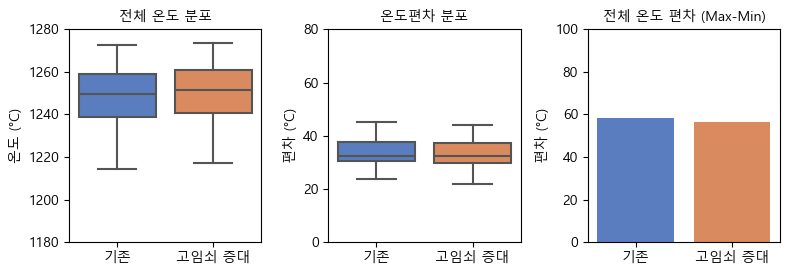


[통계 데이터]

[그래프 1: 전체 온도 분포 통계]

        count    mean   std     min     25%     50%     75%     max
Case                                                               
Case 1 108.00 1248.44 13.43 1214.47 1238.98 1249.62 1259.04 1272.69
Case 6 108.00 1250.37 13.23 1217.30 1240.66 1251.55 1260.75 1273.62


[그래프 2: 온도편차 분포 통계]

        count  mean  std   min   25%   50%   75%   max
Case                                                  
Case 1  12.00 33.58 6.95 23.58 30.53 32.55 37.48 45.27
Case 6  12.00 32.86 6.96 21.82 29.58 32.26 37.19 43.91


[그래프 3: 전체 온도 편차 (Max-Min) 값]

        전체 온도 편차(Max-Min)
Case                     
Case 1              58.22
Case 6              56.32


In [58]:
# ==============================================================================
# Step 0. [환경설정] - 이전 코드 블록의 데이터 사용
# ==============================================================================
# 이 코드는 이전 블록에서 생성된 'bloom_sensor_df' 데이터프레임이
# 메모리에 로드되어 있다고 가정하고 동작합니다.
# 만약 이 블록만 단독으로 실행하려면, 이전 코드의 데이터 로딩 부분을 여기에 포함해야 합니다.

# ==============================================================================
# Step 1. [신규 분석 함수 정의] - 특정 케이스 비교용
# ==============================================================================
def compare_specific_cases(
    sensor_df: pd.DataFrame, 
    cases_and_times: Dict[str, str], 
    label_map: Optional[Dict[str, str]] = None,
    y_lim_temp: Optional[Tuple[float, float]] = None,
    y_lim_delta_bloom: Optional[Tuple[float, float]] = None,
    y_lim_delta_total: Optional[Tuple[float, float]] = None
):
    """
    지정된 케이스 목록과 각기 다른 시간에 대해 3가지 유형의 비교 Boxplot을 생성하고 통계량을 출력합니다.
    
    Args:
        sensor_df (pd.DataFrame): 전체 센서 데이터가 포함된 데이터프레임.
        cases_and_times (Dict[str, str]): {'케이스 이름': '시간 시점'} 형태의 딕셔너리.
        label_map (Optional[Dict[str, str]]): X축에 표시될 케이스 이름을 변경하기 위한 딕셔너리.
        y_lim_temp (Optional[Tuple[float, float]]): '전체 온도 분포' 그래프의 Y축 범위.
        y_lim_delta_bloom (Optional[Tuple[float, float]]): '내부 Bloom 편차' 그래프의 Y축 범위.
        y_lim_delta_total (Optional[Tuple[float, float]]): '전체 온도 편차' 그래프의 Y축 범위.
    """
    # 동적 제목 생성을 위한 문자열 조합
    title_info = ' vs '.join([f"{case} ({time_desc})" for case, time_desc in cases_and_times.items()])
    print("\n" + "="*80 + f"\n[{title_info}] 비교 분석\n" + "="*80)
    
    # 1. 분석 대상 데이터 필터링 (각 케이스별로 지정된 시간에 맞춰 데이터 추출)
    dfs_to_concat = []
    for case, time_desc in cases_and_times.items():
        df_slice = sensor_df[(sensor_df['Case'] == case) & (sensor_df['TimeDesc'] == time_desc)].copy()
        if not df_slice.empty:
            dfs_to_concat.append(df_slice)
    
    if not dfs_to_concat:
        print("선택하신 조건에 해당하는 데이터가 없습니다. 케이스 이름과 시간 시점을 확인해주세요.")
        return
        
    df_filtered = pd.concat(dfs_to_concat)

    # 2. 분석에 필요한 데이터 가공
    bloom_delta_t = df_filtered.groupby(['Case', 'Bloom'])['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    bloom_delta_t.rename(columns={'Value': '내부 Bloom 온도편차(ΔT)'}, inplace=True)

    case_total_delta_t = df_filtered.groupby('Case')['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    case_total_delta_t.rename(columns={'Value': '전체 온도 편차(Max-Min)'}, inplace=True)

    # 3. 시각화를 위한 라벨 변경 및 순서 정의
    plot_order = list(cases_and_times.keys())
    
    df_plot = df_filtered.copy()
    bloom_delta_t_plot = bloom_delta_t.copy()
    case_total_delta_t_plot = case_total_delta_t.copy()
    
    if label_map:
        df_plot['Case'] = df_plot['Case'].replace(label_map)
        bloom_delta_t_plot['Case'] = bloom_delta_t_plot['Case'].replace(label_map)
        case_total_delta_t_plot['Case'] = case_total_delta_t_plot['Case'].replace(label_map)
        plot_order = [label_map.get(case, case) for case in plot_order]

    # 4. 시각화
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))
    #fig.suptitle(f'선택 케이스 비교 분석: {title_info}', fontsize=20, y=1.02)

    # 그래프 1: 전체 센서 온도 분포
    sns.boxplot(ax=axes[0], x='Case', y='Value', data=df_plot, palette='muted', order=plot_order)
    axes[0].set_title('전체 온도 분포', fontsize=10)
    axes[0].set_ylabel('온도 (°C)')
    axes[0].set_xlabel('')
#    axes[0].grid(True, alpha=0.6)
    axes[0].tick_params(axis='x', rotation=0)
    if y_lim_temp:
        axes[0].set_ylim(y_lim_temp)

    # 그래프 2: 내부 Bloom 온도편차 분포
    sns.boxplot(ax=axes[1], x='Case', y='내부 Bloom 온도편차(ΔT)', data=bloom_delta_t_plot, palette='muted', order=plot_order)
    axes[1].set_title('온도편차 분포', fontsize=10)
    axes[1].set_ylabel('편차 (°C)')
    axes[1].set_xlabel('')
#    axes[1].grid(True, alpha=0.6)
    axes[1].tick_params(axis='x', rotation=0)
    if y_lim_delta_bloom:
        axes[1].set_ylim(y_lim_delta_bloom)

    # 그래프 3: 전체 온도 편차 (Max-Min)
    sns.barplot(ax=axes[2], x='Case', y='전체 온도 편차(Max-Min)', data=case_total_delta_t_plot, palette='muted', order=plot_order)
    axes[2].set_title('전체 온도 편차 (Max-Min)', fontsize=10)
    axes[2].set_ylabel('편차 (°C)')
    axes[2].set_xlabel('')
#    axes[2].grid(True, alpha=0.6)
    axes[2].tick_params(axis='x', rotation=0)
    if y_lim_delta_total:
        axes[2].set_ylim(y_lim_delta_total)


    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # --- 5. 통계량 출력 ---
    print("\n" + "="*50 + "\n[통계 데이터]\n" + "="*50)

    stats1 = df_filtered.groupby('Case')['Value'].describe()
    print("\n[그래프 1: 전체 온도 분포 통계]\n")
    print(stats1.to_string(float_format='{:.2f}'.format))

    stats2 = bloom_delta_t.groupby('Case')['내부 Bloom 온도편차(ΔT)'].describe()
    print("\n\n[그래프 2: 온도편차 분포 통계]\n")
    print(stats2.to_string(float_format='{:.2f}'.format))

    stats3 = case_total_delta_t.set_index('Case')
    print("\n\n[그래프 3: 전체 온도 편차 (Max-Min) 값]\n")
    print(stats3.to_string(float_format='{:.2f}'.format))


# ==============================================================================
# Step 2. [비교 분석 실행] - 여기만 수정하세요!
# ==============================================================================
# --- 1. 비교하고 싶은 케이스와 해당 시간 시점을 딕셔너리 형태로 지정하세요 ---
cases_and_times_to_compare = {
    'Case 1': '4hr 시점',
    'Case 6': '4hr 시점'
}

# --- 2. X축에 표시될 이름을 변경하고 싶으면 아래 딕셔너리를 수정하세요 (선택 사항) ---
case_label_map = {
    'Case 1': '기존',
    'Case 6': '고임쇠 증대'
}

# --- 3. (선택 사항) 각 그래프의 Y축 범위를 직접 지정하고 싶으면 아래 값을 수정하세요 ---
# 자동 설정을 원하시면 None으로 두세요. (예: y_axis_range_temp = None)
y_axis_range_temp = (1180, 1280)         # 그래프 1: 전체 온도 분포 Y축 범위
y_axis_range_delta_bloom = (0, 80)      # 그래프 2: 내부 Bloom 편차 Y축 범위
y_axis_range_delta_total = (0, 100)      # 그래프 3: 전체 편차 Y축 범위

# --- 분석 실행 ---
if 'heating_sensor_df' in locals():
    compare_specific_cases(
        sensor_df=heating_sensor_df, 
        cases_and_times=cases_and_times_to_compare,
        label_map=case_label_map,
        y_lim_temp=y_axis_range_temp,
        y_lim_delta_bloom=y_axis_range_delta_bloom,
        y_lim_delta_total=y_axis_range_delta_total
    )
else:
    print("데이터가 로드되지 않았습니다. 이전 코드 블록(Step 1)을 먼저 실행해주세요.")




[Case 1 (4hr 시점) vs Case 11 추가 (4hr 시점)] 비교 분석


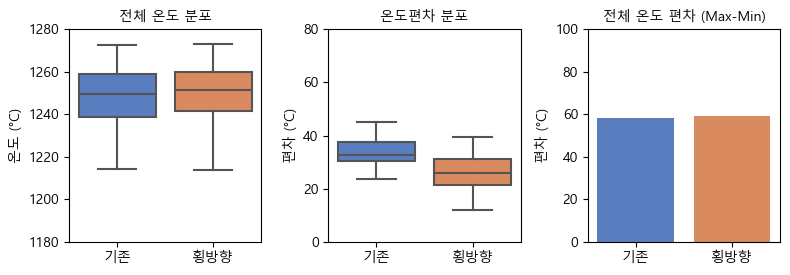


[통계 데이터]

[그래프 1: 전체 온도 분포 통계]

            count    mean   std     min     25%     50%     75%     max
Case                                                                   
Case 1     108.00 1248.44 13.43 1214.47 1238.98 1249.62 1259.04 1272.69
Case 11 추가 108.00 1249.82 13.13 1213.95 1241.60 1251.63 1260.11 1273.26


[그래프 2: 온도편차 분포 통계]

            count  mean  std   min   25%   50%   75%   max
Case                                                      
Case 1      12.00 33.58 6.95 23.58 30.53 32.55 37.48 45.27
Case 11 추가  12.00 26.22 8.39 11.99 21.58 26.09 31.04 39.30


[그래프 3: 전체 온도 편차 (Max-Min) 값]

            전체 온도 편차(Max-Min)
Case                         
Case 1                  58.22
Case 11 추가              59.31


In [59]:
# ==============================================================================
# Step 0. [환경설정] - 이전 코드 블록의 데이터 사용
# ==============================================================================
# 이 코드는 이전 블록에서 생성된 'bloom_sensor_df' 데이터프레임이
# 메모리에 로드되어 있다고 가정하고 동작합니다.
# 만약 이 블록만 단독으로 실행하려면, 이전 코드의 데이터 로딩 부분을 여기에 포함해야 합니다.

# ==============================================================================
# Step 1. [신규 분석 함수 정의] - 특정 케이스 비교용
# ==============================================================================
def compare_specific_cases(
    sensor_df: pd.DataFrame, 
    cases_and_times: Dict[str, str], 
    label_map: Optional[Dict[str, str]] = None,
    y_lim_temp: Optional[Tuple[float, float]] = None,
    y_lim_delta_bloom: Optional[Tuple[float, float]] = None,
    y_lim_delta_total: Optional[Tuple[float, float]] = None
):
    """
    지정된 케이스 목록과 각기 다른 시간에 대해 3가지 유형의 비교 Boxplot을 생성하고 통계량을 출력합니다.
    
    Args:
        sensor_df (pd.DataFrame): 전체 센서 데이터가 포함된 데이터프레임.
        cases_and_times (Dict[str, str]): {'케이스 이름': '시간 시점'} 형태의 딕셔너리.
        label_map (Optional[Dict[str, str]]): X축에 표시될 케이스 이름을 변경하기 위한 딕셔너리.
        y_lim_temp (Optional[Tuple[float, float]]): '전체 온도 분포' 그래프의 Y축 범위.
        y_lim_delta_bloom (Optional[Tuple[float, float]]): '내부 Bloom 편차' 그래프의 Y축 범위.
        y_lim_delta_total (Optional[Tuple[float, float]]): '전체 온도 편차' 그래프의 Y축 범위.
    """
    # 동적 제목 생성을 위한 문자열 조합
    title_info = ' vs '.join([f"{case} ({time_desc})" for case, time_desc in cases_and_times.items()])
    print("\n" + "="*80 + f"\n[{title_info}] 비교 분석\n" + "="*80)
    
    # 1. 분석 대상 데이터 필터링 (각 케이스별로 지정된 시간에 맞춰 데이터 추출)
    dfs_to_concat = []
    for case, time_desc in cases_and_times.items():
        df_slice = sensor_df[(sensor_df['Case'] == case) & (sensor_df['TimeDesc'] == time_desc)].copy()
        if not df_slice.empty:
            dfs_to_concat.append(df_slice)
    
    if not dfs_to_concat:
        print("선택하신 조건에 해당하는 데이터가 없습니다. 케이스 이름과 시간 시점을 확인해주세요.")
        return
        
    df_filtered = pd.concat(dfs_to_concat)

    # 2. 분석에 필요한 데이터 가공
    bloom_delta_t = df_filtered.groupby(['Case', 'Bloom'])['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    bloom_delta_t.rename(columns={'Value': '내부 Bloom 온도편차(ΔT)'}, inplace=True)

    case_total_delta_t = df_filtered.groupby('Case')['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    case_total_delta_t.rename(columns={'Value': '전체 온도 편차(Max-Min)'}, inplace=True)

    # 3. 시각화를 위한 라벨 변경 및 순서 정의
    plot_order = list(cases_and_times.keys())
    
    df_plot = df_filtered.copy()
    bloom_delta_t_plot = bloom_delta_t.copy()
    case_total_delta_t_plot = case_total_delta_t.copy()
    
    if label_map:
        df_plot['Case'] = df_plot['Case'].replace(label_map)
        bloom_delta_t_plot['Case'] = bloom_delta_t_plot['Case'].replace(label_map)
        case_total_delta_t_plot['Case'] = case_total_delta_t_plot['Case'].replace(label_map)
        plot_order = [label_map.get(case, case) for case in plot_order]

    # 4. 시각화
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))
    #fig.suptitle(f'선택 케이스 비교 분석: {title_info}', fontsize=20, y=1.02)

    # 그래프 1: 전체 센서 온도 분포
    sns.boxplot(ax=axes[0], x='Case', y='Value', data=df_plot, palette='muted', order=plot_order)
    axes[0].set_title('전체 온도 분포', fontsize=10)
    axes[0].set_ylabel('온도 (°C)')
    axes[0].set_xlabel('')
#    axes[0].grid(True, alpha=0.6)
    axes[0].tick_params(axis='x', rotation=0)
    if y_lim_temp:
        axes[0].set_ylim(y_lim_temp)

    # 그래프 2: 내부 Bloom 온도편차 분포
    sns.boxplot(ax=axes[1], x='Case', y='내부 Bloom 온도편차(ΔT)', data=bloom_delta_t_plot, palette='muted', order=plot_order)
    axes[1].set_title('온도편차 분포', fontsize=10)
    axes[1].set_ylabel('편차 (°C)')
    axes[1].set_xlabel('')
#    axes[1].grid(True, alpha=0.6)
    axes[1].tick_params(axis='x', rotation=0)
    if y_lim_delta_bloom:
        axes[1].set_ylim(y_lim_delta_bloom)

    # 그래프 3: 전체 온도 편차 (Max-Min)
    sns.barplot(ax=axes[2], x='Case', y='전체 온도 편차(Max-Min)', data=case_total_delta_t_plot, palette='muted', order=plot_order)
    axes[2].set_title('전체 온도 편차 (Max-Min)', fontsize=10)
    axes[2].set_ylabel('편차 (°C)')
    axes[2].set_xlabel('')
#    axes[2].grid(True, alpha=0.6)
    axes[2].tick_params(axis='x', rotation=0)
    if y_lim_delta_total:
        axes[2].set_ylim(y_lim_delta_total)


    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # --- 5. 통계량 출력 ---
    print("\n" + "="*50 + "\n[통계 데이터]\n" + "="*50)

    stats1 = df_filtered.groupby('Case')['Value'].describe()
    print("\n[그래프 1: 전체 온도 분포 통계]\n")
    print(stats1.to_string(float_format='{:.2f}'.format))

    stats2 = bloom_delta_t.groupby('Case')['내부 Bloom 온도편차(ΔT)'].describe()
    print("\n\n[그래프 2: 온도편차 분포 통계]\n")
    print(stats2.to_string(float_format='{:.2f}'.format))

    stats3 = case_total_delta_t.set_index('Case')
    print("\n\n[그래프 3: 전체 온도 편차 (Max-Min) 값]\n")
    print(stats3.to_string(float_format='{:.2f}'.format))


# ==============================================================================
# Step 2. [비교 분석 실행] - 여기만 수정하세요!
# ==============================================================================
# --- 1. 비교하고 싶은 케이스와 해당 시간 시점을 딕셔너리 형태로 지정하세요 ---
cases_and_times_to_compare = {
    'Case 1': '4hr 시점',
    'Case 11 추가': '4hr 시점'
}

# --- 2. X축에 표시될 이름을 변경하고 싶으면 아래 딕셔너리를 수정하세요 (선택 사항) ---
case_label_map = {
    'Case 1': '기존',
    'Case 11 추가': '횡방향'
}

# --- 3. (선택 사항) 각 그래프의 Y축 범위를 직접 지정하고 싶으면 아래 값을 수정하세요 ---
# 자동 설정을 원하시면 None으로 두세요. (예: y_axis_range_temp = None)
y_axis_range_temp = (1180, 1280)         # 그래프 1: 전체 온도 분포 Y축 범위
y_axis_range_delta_bloom = (0, 80)      # 그래프 2: 내부 Bloom 편차 Y축 범위
y_axis_range_delta_total = (0, 100)      # 그래프 3: 전체 편차 Y축 범위

# --- 분석 실행 ---
if 'heating_sensor_df' in locals():
    compare_specific_cases(
        sensor_df=heating_sensor_df, 
        cases_and_times=cases_and_times_to_compare,
        label_map=case_label_map,
        y_lim_temp=y_axis_range_temp,
        y_lim_delta_bloom=y_axis_range_delta_bloom,
        y_lim_delta_total=y_axis_range_delta_total
    )
else:
    print("데이터가 로드되지 않았습니다. 이전 코드 블록(Step 1)을 먼저 실행해주세요.")




[Case 1 (4hr 시점) vs Case 16 (4hr 시점)] 비교 분석


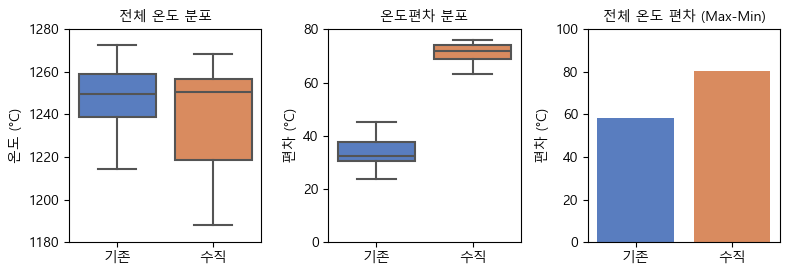


[통계 데이터]

[그래프 1: 전체 온도 분포 통계]

         count    mean   std     min     25%     50%     75%     max
Case                                                                
Case 1  108.00 1248.44 13.43 1214.47 1238.98 1249.62 1259.04 1272.69
Case 16 108.00 1238.28 25.75 1188.15 1218.39 1250.38 1256.88 1268.41


[그래프 2: 온도편차 분포 통계]

         count  mean  std   min   25%   50%   75%   max
Case                                                   
Case 1   12.00 33.58 6.95 23.58 30.53 32.55 37.48 45.27
Case 16  12.00 71.15 4.20 63.16 68.82 71.97 74.26 76.03


[그래프 3: 전체 온도 편차 (Max-Min) 값]

         전체 온도 편차(Max-Min)
Case                      
Case 1               58.22
Case 16              80.26


In [60]:
# ==============================================================================
# Step 0. [환경설정] - 이전 코드 블록의 데이터 사용
# ==============================================================================
# 이 코드는 이전 블록에서 생성된 'bloom_sensor_df' 데이터프레임이
# 메모리에 로드되어 있다고 가정하고 동작합니다.
# 만약 이 블록만 단독으로 실행하려면, 이전 코드의 데이터 로딩 부분을 여기에 포함해야 합니다.

# ==============================================================================
# Step 1. [신규 분석 함수 정의] - 특정 케이스 비교용
# ==============================================================================
def compare_specific_cases(
    sensor_df: pd.DataFrame, 
    cases_and_times: Dict[str, str], 
    label_map: Optional[Dict[str, str]] = None,
    y_lim_temp: Optional[Tuple[float, float]] = None,
    y_lim_delta_bloom: Optional[Tuple[float, float]] = None,
    y_lim_delta_total: Optional[Tuple[float, float]] = None
):
    """
    지정된 케이스 목록과 각기 다른 시간에 대해 3가지 유형의 비교 Boxplot을 생성하고 통계량을 출력합니다.
    
    Args:
        sensor_df (pd.DataFrame): 전체 센서 데이터가 포함된 데이터프레임.
        cases_and_times (Dict[str, str]): {'케이스 이름': '시간 시점'} 형태의 딕셔너리.
        label_map (Optional[Dict[str, str]]): X축에 표시될 케이스 이름을 변경하기 위한 딕셔너리.
        y_lim_temp (Optional[Tuple[float, float]]): '전체 온도 분포' 그래프의 Y축 범위.
        y_lim_delta_bloom (Optional[Tuple[float, float]]): '내부 Bloom 편차' 그래프의 Y축 범위.
        y_lim_delta_total (Optional[Tuple[float, float]]): '전체 온도 편차' 그래프의 Y축 범위.
    """
    # 동적 제목 생성을 위한 문자열 조합
    title_info = ' vs '.join([f"{case} ({time_desc})" for case, time_desc in cases_and_times.items()])
    print("\n" + "="*80 + f"\n[{title_info}] 비교 분석\n" + "="*80)
    
    # 1. 분석 대상 데이터 필터링 (각 케이스별로 지정된 시간에 맞춰 데이터 추출)
    dfs_to_concat = []
    for case, time_desc in cases_and_times.items():
        df_slice = sensor_df[(sensor_df['Case'] == case) & (sensor_df['TimeDesc'] == time_desc)].copy()
        if not df_slice.empty:
            dfs_to_concat.append(df_slice)
    
    if not dfs_to_concat:
        print("선택하신 조건에 해당하는 데이터가 없습니다. 케이스 이름과 시간 시점을 확인해주세요.")
        return
        
    df_filtered = pd.concat(dfs_to_concat)

    # 2. 분석에 필요한 데이터 가공
    bloom_delta_t = df_filtered.groupby(['Case', 'Bloom'])['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    bloom_delta_t.rename(columns={'Value': '내부 Bloom 온도편차(ΔT)'}, inplace=True)

    case_total_delta_t = df_filtered.groupby('Case')['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    case_total_delta_t.rename(columns={'Value': '전체 온도 편차(Max-Min)'}, inplace=True)

    # 3. 시각화를 위한 라벨 변경 및 순서 정의
    plot_order = list(cases_and_times.keys())
    
    df_plot = df_filtered.copy()
    bloom_delta_t_plot = bloom_delta_t.copy()
    case_total_delta_t_plot = case_total_delta_t.copy()
    
    if label_map:
        df_plot['Case'] = df_plot['Case'].replace(label_map)
        bloom_delta_t_plot['Case'] = bloom_delta_t_plot['Case'].replace(label_map)
        case_total_delta_t_plot['Case'] = case_total_delta_t_plot['Case'].replace(label_map)
        plot_order = [label_map.get(case, case) for case in plot_order]

    # 4. 시각화
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))
    #fig.suptitle(f'선택 케이스 비교 분석: {title_info}', fontsize=20, y=1.02)

    # 그래프 1: 전체 센서 온도 분포
    sns.boxplot(ax=axes[0], x='Case', y='Value', data=df_plot, palette='muted', order=plot_order)
    axes[0].set_title('전체 온도 분포', fontsize=10)
    axes[0].set_ylabel('온도 (°C)')
    axes[0].set_xlabel('')
#    axes[0].grid(True, alpha=0.6)
    axes[0].tick_params(axis='x', rotation=0)
    if y_lim_temp:
        axes[0].set_ylim(y_lim_temp)

    # 그래프 2: 내부 Bloom 온도편차 분포
    sns.boxplot(ax=axes[1], x='Case', y='내부 Bloom 온도편차(ΔT)', data=bloom_delta_t_plot, palette='muted', order=plot_order)
    axes[1].set_title('온도편차 분포', fontsize=10)
    axes[1].set_ylabel('편차 (°C)')
    axes[1].set_xlabel('')
#    axes[1].grid(True, alpha=0.6)
    axes[1].tick_params(axis='x', rotation=0)
    if y_lim_delta_bloom:
        axes[1].set_ylim(y_lim_delta_bloom)

    # 그래프 3: 전체 온도 편차 (Max-Min)
    sns.barplot(ax=axes[2], x='Case', y='전체 온도 편차(Max-Min)', data=case_total_delta_t_plot, palette='muted', order=plot_order)
    axes[2].set_title('전체 온도 편차 (Max-Min)', fontsize=10)
    axes[2].set_ylabel('편차 (°C)')
    axes[2].set_xlabel('')
#    axes[2].grid(True, alpha=0.6)
    axes[2].tick_params(axis='x', rotation=0)
    if y_lim_delta_total:
        axes[2].set_ylim(y_lim_delta_total)


    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # --- 5. 통계량 출력 ---
    print("\n" + "="*50 + "\n[통계 데이터]\n" + "="*50)

    stats1 = df_filtered.groupby('Case')['Value'].describe()
    print("\n[그래프 1: 전체 온도 분포 통계]\n")
    print(stats1.to_string(float_format='{:.2f}'.format))

    stats2 = bloom_delta_t.groupby('Case')['내부 Bloom 온도편차(ΔT)'].describe()
    print("\n\n[그래프 2: 온도편차 분포 통계]\n")
    print(stats2.to_string(float_format='{:.2f}'.format))

    stats3 = case_total_delta_t.set_index('Case')
    print("\n\n[그래프 3: 전체 온도 편차 (Max-Min) 값]\n")
    print(stats3.to_string(float_format='{:.2f}'.format))


# ==============================================================================
# Step 2. [비교 분석 실행] - 여기만 수정하세요!
# ==============================================================================
# --- 1. 비교하고 싶은 케이스와 해당 시간 시점을 딕셔너리 형태로 지정하세요 ---
cases_and_times_to_compare = {
    'Case 1': '4hr 시점',
    'Case 16': '4hr 시점'
}

# --- 2. X축에 표시될 이름을 변경하고 싶으면 아래 딕셔너리를 수정하세요 (선택 사항) ---
case_label_map = {
    'Case 1': '기존',
    'Case 16': '수직'
}

# --- 3. (선택 사항) 각 그래프의 Y축 범위를 직접 지정하고 싶으면 아래 값을 수정하세요 ---
# 자동 설정을 원하시면 None으로 두세요. (예: y_axis_range_temp = None)
y_axis_range_temp = (1180, 1280)         # 그래프 1: 전체 온도 분포 Y축 범위
y_axis_range_delta_bloom = (0, 80)      # 그래프 2: 내부 Bloom 편차 Y축 범위
y_axis_range_delta_total = (0, 100)      # 그래프 3: 전체 편차 Y축 범위

# --- 분석 실행 ---
if 'heating_sensor_df' in locals():
    compare_specific_cases(
        sensor_df=heating_sensor_df, 
        cases_and_times=cases_and_times_to_compare,
        label_map=case_label_map,
        y_lim_temp=y_axis_range_temp,
        y_lim_delta_bloom=y_axis_range_delta_bloom,
        y_lim_delta_total=y_axis_range_delta_total
    )
else:
    print("데이터가 로드되지 않았습니다. 이전 코드 블록(Step 1)을 먼저 실행해주세요.")




[Case 1 (4hr 시점) vs Case 2* (가열완료 시점) vs Case 3 (4hr 시점)] 비교 분석


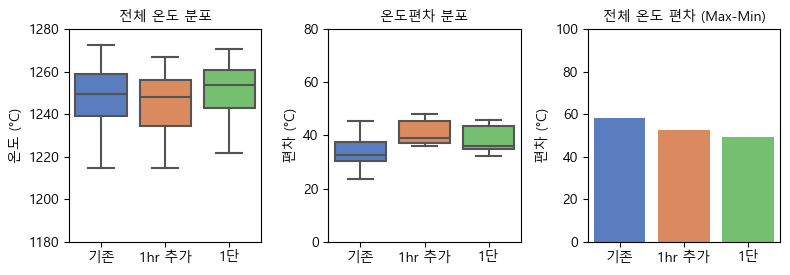


[통계 데이터]

[그래프 1: 전체 온도 분포 통계]

         count    mean   std     min     25%     50%     75%     max
Case                                                                
Case 1  108.00 1248.44 13.43 1214.47 1238.98 1249.62 1259.04 1272.69
Case 2*  54.00 1245.23 13.87 1214.79 1234.30 1247.90 1256.14 1267.19
Case 3   54.00 1251.44 12.73 1221.77 1242.87 1253.55 1261.03 1270.93


[그래프 2: 온도편차 분포 통계]

         count  mean  std   min   25%   50%   75%   max
Case                                                   
Case 1   12.00 33.58 6.95 23.58 30.53 32.55 37.48 45.27
Case 2*   6.00 41.13 5.48 36.12 37.22 38.96 45.63 48.26
Case 3    6.00 38.46 6.02 32.22 34.84 35.88 43.66 46.01


[그래프 3: 전체 온도 편차 (Max-Min) 값]

         전체 온도 편차(Max-Min)
Case                      
Case 1               58.22
Case 2*              52.40
Case 3               49.16


In [13]:
# ==============================================================================
# Step 0. [환경설정] - 이전 코드 블록의 데이터 사용
# ==============================================================================
# 이 코드는 이전 블록에서 생성된 'bloom_sensor_df' 데이터프레임이
# 메모리에 로드되어 있다고 가정하고 동작합니다.
# 만약 이 블록만 단독으로 실행하려면, 이전 코드의 데이터 로딩 부분을 여기에 포함해야 합니다.

# ==============================================================================
# Step 1. [신규 분석 함수 정의] - 특정 케이스 비교용
# ==============================================================================
def compare_specific_cases(
    sensor_df: pd.DataFrame, 
    cases_and_times: Dict[str, str], 
    label_map: Optional[Dict[str, str]] = None,
    y_lim_temp: Optional[Tuple[float, float]] = None,
    y_lim_delta_bloom: Optional[Tuple[float, float]] = None,
    y_lim_delta_total: Optional[Tuple[float, float]] = None
):
    """
    지정된 케이스 목록과 각기 다른 시간에 대해 3가지 유형의 비교 Boxplot을 생성하고 통계량을 출력합니다.
    
    Args:
        sensor_df (pd.DataFrame): 전체 센서 데이터가 포함된 데이터프레임.
        cases_and_times (Dict[str, str]): {'케이스 이름': '시간 시점'} 형태의 딕셔너리.
        label_map (Optional[Dict[str, str]]): X축에 표시될 케이스 이름을 변경하기 위한 딕셔너리.
        y_lim_temp (Optional[Tuple[float, float]]): '전체 온도 분포' 그래프의 Y축 범위.
        y_lim_delta_bloom (Optional[Tuple[float, float]]): '내부 Bloom 편차' 그래프의 Y축 범위.
        y_lim_delta_total (Optional[Tuple[float, float]]): '전체 온도 편차' 그래프의 Y축 범위.
    """
    # 동적 제목 생성을 위한 문자열 조합
    title_info = ' vs '.join([f"{case} ({time_desc})" for case, time_desc in cases_and_times.items()])
    print("\n" + "="*80 + f"\n[{title_info}] 비교 분석\n" + "="*80)
    
    # 1. 분석 대상 데이터 필터링 (각 케이스별로 지정된 시간에 맞춰 데이터 추출)
    dfs_to_concat = []
    for case, time_desc in cases_and_times.items():
        df_slice = sensor_df[(sensor_df['Case'] == case) & (sensor_df['TimeDesc'] == time_desc)].copy()
        if not df_slice.empty:
            dfs_to_concat.append(df_slice)
    
    if not dfs_to_concat:
        print("선택하신 조건에 해당하는 데이터가 없습니다. 케이스 이름과 시간 시점을 확인해주세요.")
        return
        
    df_filtered = pd.concat(dfs_to_concat)

    # 2. 분석에 필요한 데이터 가공
    bloom_delta_t = df_filtered.groupby(['Case', 'Bloom'])['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    bloom_delta_t.rename(columns={'Value': '내부 Bloom 온도편차(ΔT)'}, inplace=True)

    case_total_delta_t = df_filtered.groupby('Case')['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    case_total_delta_t.rename(columns={'Value': '전체 온도 편차(Max-Min)'}, inplace=True)

    # 3. 시각화를 위한 라벨 변경 및 순서 정의
    plot_order = list(cases_and_times.keys())
    
    df_plot = df_filtered.copy()
    bloom_delta_t_plot = bloom_delta_t.copy()
    case_total_delta_t_plot = case_total_delta_t.copy()
    
    if label_map:
        df_plot['Case'] = df_plot['Case'].replace(label_map)
        bloom_delta_t_plot['Case'] = bloom_delta_t_plot['Case'].replace(label_map)
        case_total_delta_t_plot['Case'] = case_total_delta_t_plot['Case'].replace(label_map)
        plot_order = [label_map.get(case, case) for case in plot_order]

    # 4. 시각화
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))
    #fig.suptitle(f'선택 케이스 비교 분석: {title_info}', fontsize=20, y=1.02)

    # 그래프 1: 전체 센서 온도 분포
    sns.boxplot(ax=axes[0], x='Case', y='Value', data=df_plot, palette='muted', order=plot_order)
    axes[0].set_title('전체 온도 분포', fontsize=10)
    axes[0].set_ylabel('온도 (°C)')
    axes[0].set_xlabel('')
#    axes[0].grid(True, alpha=0.6)
    axes[0].tick_params(axis='x', rotation=0)
    if y_lim_temp:
        axes[0].set_ylim(y_lim_temp)

    # 그래프 2: 내부 Bloom 온도편차 분포
    sns.boxplot(ax=axes[1], x='Case', y='내부 Bloom 온도편차(ΔT)', data=bloom_delta_t_plot, palette='muted', order=plot_order)
    axes[1].set_title('온도편차 분포', fontsize=10)
    axes[1].set_ylabel('편차 (°C)')
    axes[1].set_xlabel('')
#    axes[1].grid(True, alpha=0.6)
    axes[1].tick_params(axis='x', rotation=0)
    if y_lim_delta_bloom:
        axes[1].set_ylim(y_lim_delta_bloom)

    # 그래프 3: 전체 온도 편차 (Max-Min)
    sns.barplot(ax=axes[2], x='Case', y='전체 온도 편차(Max-Min)', data=case_total_delta_t_plot, palette='muted', order=plot_order)
    axes[2].set_title('전체 온도 편차 (Max-Min)', fontsize=10)
    axes[2].set_ylabel('편차 (°C)')
    axes[2].set_xlabel('')
#    axes[2].grid(True, alpha=0.6)
    axes[2].tick_params(axis='x', rotation=0)
    if y_lim_delta_total:
        axes[2].set_ylim(y_lim_delta_total)


    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # --- 5. 통계량 출력 ---
    print("\n" + "="*50 + "\n[통계 데이터]\n" + "="*50)

    stats1 = df_filtered.groupby('Case')['Value'].describe()
    print("\n[그래프 1: 전체 온도 분포 통계]\n")
    print(stats1.to_string(float_format='{:.2f}'.format))

    stats2 = bloom_delta_t.groupby('Case')['내부 Bloom 온도편차(ΔT)'].describe()
    print("\n\n[그래프 2: 온도편차 분포 통계]\n")
    print(stats2.to_string(float_format='{:.2f}'.format))

    stats3 = case_total_delta_t.set_index('Case')
    print("\n\n[그래프 3: 전체 온도 편차 (Max-Min) 값]\n")
    print(stats3.to_string(float_format='{:.2f}'.format))


# ==============================================================================
# Step 2. [비교 분석 실행] - 여기만 수정하세요!
# ==============================================================================
# --- 1. 비교하고 싶은 케이스와 해당 시간 시점을 딕셔너리 형태로 지정하세요 ---
cases_and_times_to_compare = {
    'Case 1': '4hr 시점',
    'Case 2*': '가열완료 시점',
    'Case 3': '4hr 시점'
}

# --- 2. X축에 표시될 이름을 변경하고 싶으면 아래 딕셔너리를 수정하세요 (선택 사항) ---
case_label_map = {
    'Case 1': '기존',
    'Case 2*': '1hr 추가',
    'Case 3': '1단'
}

# --- 3. (선택 사항) 각 그래프의 Y축 범위를 직접 지정하고 싶으면 아래 값을 수정하세요 ---
# 자동 설정을 원하시면 None으로 두세요. (예: y_axis_range_temp = None)
y_axis_range_temp = (1180, 1280)         # 그래프 1: 전체 온도 분포 Y축 범위
y_axis_range_delta_bloom = (0, 80)      # 그래프 2: 내부 Bloom 편차 Y축 범위
y_axis_range_delta_total = (0, 100)      # 그래프 3: 전체 편차 Y축 범위

# --- 분석 실행 ---
if 'heating_sensor_df' in locals():
    compare_specific_cases(
        sensor_df=heating_sensor_df, 
        cases_and_times=cases_and_times_to_compare,
        label_map=case_label_map,
        y_lim_temp=y_axis_range_temp,
        y_lim_delta_bloom=y_axis_range_delta_bloom,
        y_lim_delta_total=y_axis_range_delta_total
    )
else:
    print("데이터가 로드되지 않았습니다. 이전 코드 블록(Step 1)을 먼저 실행해주세요.")




[Case 1 (4hr 시점) vs Case 19 (4hr 시점)] 비교 분석


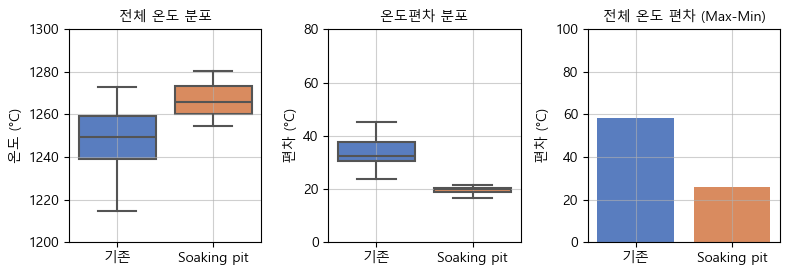


[통계 데이터]

[그래프 1: 전체 온도 분포 통계]

         count    mean   std     min     25%     50%     75%     max
Case                                                                
Case 1  108.00 1248.44 13.43 1214.47 1238.98 1249.62 1259.04 1272.69
Case 19 108.00 1266.57  7.36 1254.50 1260.10 1265.68 1273.22 1280.19


[그래프 2: 온도편차 분포 통계]

         count  mean  std   min   25%   50%   75%   max
Case                                                   
Case 1   12.00 33.58 6.95 23.58 30.53 32.55 37.48 45.27
Case 19  12.00 19.65 1.45 16.71 18.85 19.93 20.51 21.59


[그래프 3: 전체 온도 편차 (Max-Min) 값]

         전체 온도 편차(Max-Min)
Case                      
Case 1               58.22
Case 19              25.68


In [81]:
# ==============================================================================
# Step 0. [환경설정] - 이전 코드 블록의 데이터 사용
# ==============================================================================
# 이 코드는 이전 블록에서 생성된 'bloom_sensor_df' 데이터프레임이
# 메모리에 로드되어 있다고 가정하고 동작합니다.
# 만약 이 블록만 단독으로 실행하려면, 이전 코드의 데이터 로딩 부분을 여기에 포함해야 합니다.

# ==============================================================================
# Step 1. [신규 분석 함수 정의] - 특정 케이스 비교용
# ==============================================================================
def compare_specific_cases(
    sensor_df: pd.DataFrame, 
    cases_and_times: Dict[str, str], 
    label_map: Optional[Dict[str, str]] = None,
    y_lim_temp: Optional[Tuple[float, float]] = None,
    y_lim_delta_bloom: Optional[Tuple[float, float]] = None,
    y_lim_delta_total: Optional[Tuple[float, float]] = None
):
    """
    지정된 케이스 목록과 각기 다른 시간에 대해 3가지 유형의 비교 Boxplot을 생성하고 통계량을 출력합니다.
    
    Args:
        sensor_df (pd.DataFrame): 전체 센서 데이터가 포함된 데이터프레임.
        cases_and_times (Dict[str, str]): {'케이스 이름': '시간 시점'} 형태의 딕셔너리.
        label_map (Optional[Dict[str, str]]): X축에 표시될 케이스 이름을 변경하기 위한 딕셔너리.
        y_lim_temp (Optional[Tuple[float, float]]): '전체 온도 분포' 그래프의 Y축 범위.
        y_lim_delta_bloom (Optional[Tuple[float, float]]): '내부 Bloom 편차' 그래프의 Y축 범위.
        y_lim_delta_total (Optional[Tuple[float, float]]): '전체 온도 편차' 그래프의 Y축 범위.
    """
    # 동적 제목 생성을 위한 문자열 조합
    title_info = ' vs '.join([f"{case} ({time_desc})" for case, time_desc in cases_and_times.items()])
    print("\n" + "="*80 + f"\n[{title_info}] 비교 분석\n" + "="*80)
    
    # 1. 분석 대상 데이터 필터링 (각 케이스별로 지정된 시간에 맞춰 데이터 추출)
    dfs_to_concat = []
    for case, time_desc in cases_and_times.items():
        df_slice = sensor_df[(sensor_df['Case'] == case) & (sensor_df['TimeDesc'] == time_desc)].copy()
        if not df_slice.empty:
            dfs_to_concat.append(df_slice)
    
    if not dfs_to_concat:
        print("선택하신 조건에 해당하는 데이터가 없습니다. 케이스 이름과 시간 시점을 확인해주세요.")
        return
        
    df_filtered = pd.concat(dfs_to_concat)

    # 2. 분석에 필요한 데이터 가공
    bloom_delta_t = df_filtered.groupby(['Case', 'Bloom'])['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    bloom_delta_t.rename(columns={'Value': '내부 Bloom 온도편차(ΔT)'}, inplace=True)

    case_total_delta_t = df_filtered.groupby('Case')['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    case_total_delta_t.rename(columns={'Value': '전체 온도 편차(Max-Min)'}, inplace=True)

    # 3. 시각화를 위한 라벨 변경 및 순서 정의
    plot_order = list(cases_and_times.keys())
    
    df_plot = df_filtered.copy()
    bloom_delta_t_plot = bloom_delta_t.copy()
    case_total_delta_t_plot = case_total_delta_t.copy()
    
    if label_map:
        df_plot['Case'] = df_plot['Case'].replace(label_map)
        bloom_delta_t_plot['Case'] = bloom_delta_t_plot['Case'].replace(label_map)
        case_total_delta_t_plot['Case'] = case_total_delta_t_plot['Case'].replace(label_map)
        plot_order = [label_map.get(case, case) for case in plot_order]

    # 4. 시각화
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))
    #fig.suptitle(f'선택 케이스 비교 분석: {title_info}', fontsize=20, y=1.02)

    # 그래프 1: 전체 센서 온도 분포
    sns.boxplot(ax=axes[0], x='Case', y='Value', data=df_plot, palette='muted', order=plot_order)
    axes[0].set_title('전체 온도 분포', fontsize=10)
    axes[0].set_ylabel('온도 (°C)')
    axes[0].set_xlabel('')
    axes[0].grid(True, alpha=0.6)
    axes[0].tick_params(axis='x', rotation=0)
    if y_lim_temp:
        axes[0].set_ylim(y_lim_temp)

    # 그래프 2: 내부 Bloom 온도편차 분포
    sns.boxplot(ax=axes[1], x='Case', y='내부 Bloom 온도편차(ΔT)', data=bloom_delta_t_plot, palette='muted', order=plot_order)
    axes[1].set_title('온도편차 분포', fontsize=10)
    axes[1].set_ylabel('편차 (°C)')
    axes[1].set_xlabel('')
    axes[1].grid(True, alpha=0.6)
    axes[1].tick_params(axis='x', rotation=0)
    if y_lim_delta_bloom:
        axes[1].set_ylim(y_lim_delta_bloom)

    # 그래프 3: 전체 온도 편차 (Max-Min)
    sns.barplot(ax=axes[2], x='Case', y='전체 온도 편차(Max-Min)', data=case_total_delta_t_plot, palette='muted', order=plot_order)
    axes[2].set_title('전체 온도 편차 (Max-Min)', fontsize=10)
    axes[2].set_ylabel('편차 (°C)')
    axes[2].set_xlabel('')
    axes[2].grid(True, alpha=0.6)
    axes[2].tick_params(axis='x', rotation=0)
    if y_lim_delta_total:
        axes[2].set_ylim(y_lim_delta_total)


    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # --- 5. 통계량 출력 ---
    print("\n" + "="*50 + "\n[통계 데이터]\n" + "="*50)

    stats1 = df_filtered.groupby('Case')['Value'].describe()
    print("\n[그래프 1: 전체 온도 분포 통계]\n")
    print(stats1.to_string(float_format='{:.2f}'.format))

    stats2 = bloom_delta_t.groupby('Case')['내부 Bloom 온도편차(ΔT)'].describe()
    print("\n\n[그래프 2: 온도편차 분포 통계]\n")
    print(stats2.to_string(float_format='{:.2f}'.format))

    stats3 = case_total_delta_t.set_index('Case')
    print("\n\n[그래프 3: 전체 온도 편차 (Max-Min) 값]\n")
    print(stats3.to_string(float_format='{:.2f}'.format))


# ==============================================================================
# Step 2. [비교 분석 실행] - 여기만 수정하세요!
# ==============================================================================
# --- 1. 비교하고 싶은 케이스와 해당 시간 시점을 딕셔너리 형태로 지정하세요 ---
cases_and_times_to_compare = {
    'Case 1': '4hr 시점',
    #'Case 2*': '가열완료 시점',
    'Case 19': '4hr 시점'
}

# --- 2. X축에 표시될 이름을 변경하고 싶으면 아래 딕셔너리를 수정하세요 (선택 사항) ---
case_label_map = {
    'Case 1': '기존',
    #'Case 2*': '5hr 추가',
    'Case 19': 'Soaking pit'
}

# --- 3. (선택 사항) 각 그래프의 Y축 범위를 직접 지정하고 싶으면 아래 값을 수정하세요 ---
# 자동 설정을 원하시면 None으로 두세요. (예: y_axis_range_temp = None)
y_axis_range_temp = (1200, 1300)         # 그래프 1: 전체 온도 분포 Y축 범위
y_axis_range_delta_bloom = (0, 80)      # 그래프 2: 내부 Bloom 편차 Y축 범위
y_axis_range_delta_total = (0, 100)      # 그래프 3: 전체 편차 Y축 범위

# --- 분석 실행 ---
if 'heating_sensor_df' in locals():
    compare_specific_cases(
        sensor_df=heating_sensor_df, 
        cases_and_times=cases_and_times_to_compare,
        label_map=case_label_map,
        y_lim_temp=y_axis_range_temp,
        y_lim_delta_bloom=y_axis_range_delta_bloom,
        y_lim_delta_total=y_axis_range_delta_total
    )
else:
    print("데이터가 로드되지 않았습니다. 이전 코드 블록(Step 1)을 먼저 실행해주세요.")




[Case 16 - 4hr 시점] 선단/중단/후단 상세 분석


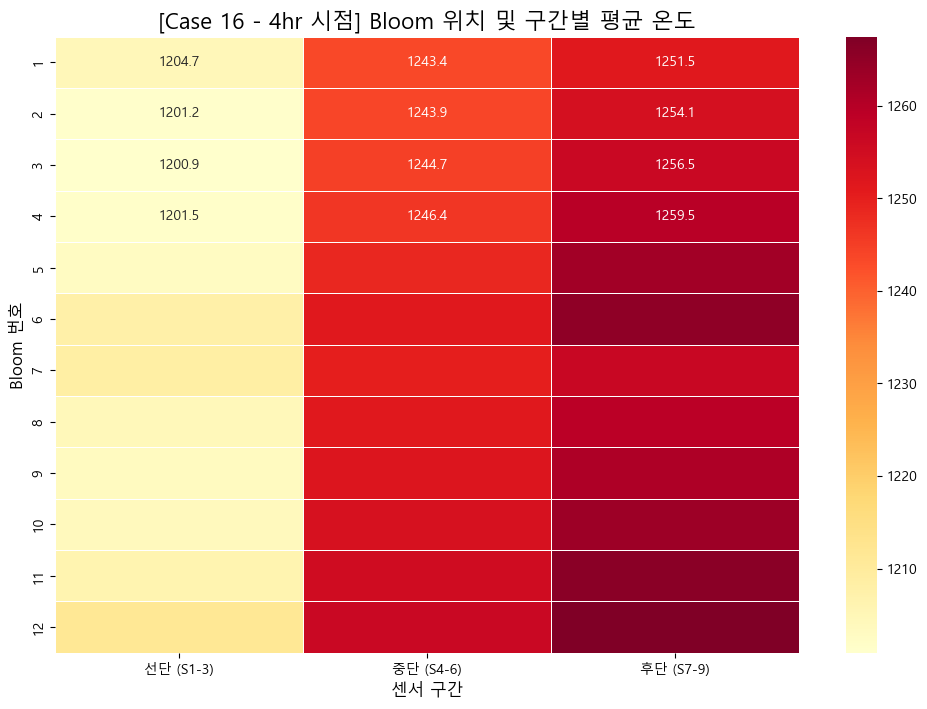


[상세 데이터 테이블]

구분     선단 (S1-3)  중단 (S4-6)  후단 (S7-9)
Bloom                                 
1        1204.69    1243.41    1251.54
2        1201.16    1243.89    1254.13
3        1200.90    1244.74    1256.52
4        1201.47    1246.38    1259.49
5        1202.96    1248.71    1262.76
6        1207.68    1251.47    1265.30
7        1208.50    1250.15    1256.70
8        1204.38    1251.40    1259.27
9        1203.37    1252.15    1261.14
10       1203.93    1253.46    1263.52
11       1206.17    1255.24    1266.11
12       1211.40    1256.35    1267.48


In [79]:
# ==============================================================================
# Step 1. [신규 분석 함수 정의] - 선단/중단/후단 분석용
# ==============================================================================
def analyze_bloom_sections(sensor_df: pd.DataFrame, case_name: str, time_desc: str):
    """
    지정된 케이스와 시간에 대해, 각 Bloom을 선단/중단/후단으로 나누어
    평균 온도를 계산하고 히트맵과 테이블로 결과를 보여줍니다.
    """
    print("\n" + "="*80 + f"\n[{case_name} - {time_desc}] 선단/중단/후단 상세 분석\n" + "="*80)
    
    # 1. 분석 대상 데이터 필터링
    case_df = sensor_df[(sensor_df['Case'] == case_name) & (sensor_df['TimeDesc'] == time_desc)].copy()
    
    if case_df.empty:
        print("선택하신 조건에 해당하는 데이터가 없습니다. 케이스 이름과 시간 시점을 확인해주세요.")
        return

    # 2. 센서 위치를 선단/중단/후단으로 구분하는 컬럼 추가
    def categorize_sensor_section(sensor_num):
        if sensor_num in [1, 2, 3]: return '선단 (S1-3)'
        if sensor_num in [4, 5, 6]: return '중단 (S4-6)'
        if sensor_num in [7, 8, 9]: return '후단 (S7-9)'
        return None
    case_df['구분'] = case_df['Sensor'].apply(categorize_sensor_section)

    # 3. Bloom 및 구분별 평균 온도 계산
    section_summary = case_df.groupby(['Bloom', '구분'])['Value'].mean().unstack()
    
    # 정렬을 위해 Bloom 번호를 숫자형으로 변환
    section_summary.index = section_summary.index.astype(int)
    section_summary = section_summary.sort_index()

    # 4. 히트맵 시각화
    plt.figure(figsize=(12, 8))
    sns.heatmap(section_summary, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=.5)
    plt.title(f'[{case_name} - {time_desc}] Bloom 위치 및 구간별 평균 온도', fontsize=16)
    plt.xlabel('센서 구간', fontsize=12)
    plt.ylabel('Bloom 번호', fontsize=12)
    plt.show()

    # 5. 데이터프레임(테이블) 출력
    print("\n[상세 데이터 테이블]\n")
    print(section_summary.to_string(float_format='{:.2f}'.format))


# ==============================================================================
# Step 2. [분석 실행] - 여기만 수정하세요!
# ==============================================================================
# --- 1. 분석하고 싶은 케이스를 지정하세요 ---
case_to_analyze = 'Case 16'

# --- 2. 분석하고 싶은 시간 시점을 선택하세요 ('4hr 시점' 또는 '가열완료 시점') ---
time_to_analyze = '4hr 시점'

# --- 분석 실행 ---
if 'heating_sensor_df' in locals():
    analyze_bloom_sections(
        sensor_df=heating_sensor_df, 
        case_name=case_to_analyze, 
        time_desc=time_to_analyze
    )
else:
    print("데이터가 로드되지 않았습니다. 이전 코드 블록(Step 1)을 먼저 실행해주세요.")


[Case 19 - 4hr 시점] 선단/중단/후단 상세 분석


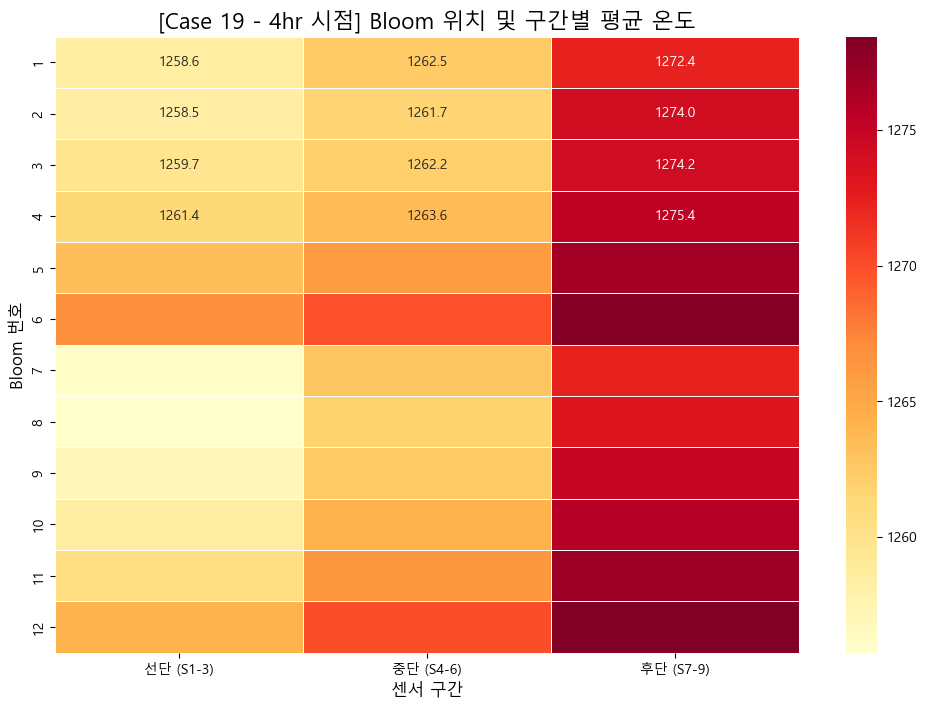


[상세 데이터 테이블]

구분     선단 (S1-3)  중단 (S4-6)  후단 (S7-9)
Bloom                                 
1        1258.57    1262.46    1272.38
2        1258.48    1261.73    1274.01
3        1259.74    1262.15    1274.23
4        1261.38    1263.55    1275.36
5        1263.39    1266.00    1276.68
6        1266.79    1269.80    1278.23
7        1256.00    1262.75    1272.37
8        1255.74    1261.85    1273.35
9        1256.94    1262.55    1274.96
10       1258.56    1264.33    1275.79
11       1260.60    1266.32    1277.03
12       1264.12    1269.98    1278.44


In [83]:
# ==============================================================================
# Step 1. [신규 분석 함수 정의] - 선단/중단/후단 분석용
# ==============================================================================
def analyze_bloom_sections(sensor_df: pd.DataFrame, case_name: str, time_desc: str):
    """
    지정된 케이스와 시간에 대해, 각 Bloom을 선단/중단/후단으로 나누어
    평균 온도를 계산하고 히트맵과 테이블로 결과를 보여줍니다.
    """
    print("\n" + "="*80 + f"\n[{case_name} - {time_desc}] 선단/중단/후단 상세 분석\n" + "="*80)
    
    # 1. 분석 대상 데이터 필터링
    case_df = sensor_df[(sensor_df['Case'] == case_name) & (sensor_df['TimeDesc'] == time_desc)].copy()
    
    if case_df.empty:
        print("선택하신 조건에 해당하는 데이터가 없습니다. 케이스 이름과 시간 시점을 확인해주세요.")
        return

    # 2. 센서 위치를 선단/중단/후단으로 구분하는 컬럼 추가
    def categorize_sensor_section(sensor_num):
        if sensor_num in [1, 2, 3]: return '선단 (S1-3)'
        if sensor_num in [4, 5, 6]: return '중단 (S4-6)'
        if sensor_num in [7, 8, 9]: return '후단 (S7-9)'
        return None
    case_df['구분'] = case_df['Sensor'].apply(categorize_sensor_section)

    # 3. Bloom 및 구분별 평균 온도 계산
    section_summary = case_df.groupby(['Bloom', '구분'])['Value'].mean().unstack()
    
    # 정렬을 위해 Bloom 번호를 숫자형으로 변환
    section_summary.index = section_summary.index.astype(int)
    section_summary = section_summary.sort_index()

    # 4. 히트맵 시각화
    plt.figure(figsize=(12, 8))
    sns.heatmap(section_summary, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=.5)
    plt.title(f'[{case_name} - {time_desc}] Bloom 위치 및 구간별 평균 온도', fontsize=16)
    plt.xlabel('센서 구간', fontsize=12)
    plt.ylabel('Bloom 번호', fontsize=12)
    plt.show()

    # 5. 데이터프레임(테이블) 출력
    print("\n[상세 데이터 테이블]\n")
    print(section_summary.to_string(float_format='{:.2f}'.format))


# ==============================================================================
# Step 2. [분석 실행] - 여기만 수정하세요!
# ==============================================================================
# --- 1. 분석하고 싶은 케이스를 지정하세요 ---
case_to_analyze = 'Case 19'

# --- 2. 분석하고 싶은 시간 시점을 선택하세요 ('4hr 시점' 또는 '가열완료 시점') ---
time_to_analyze = '4hr 시점'

# --- 분석 실행 ---
if 'heating_sensor_df' in locals():
    analyze_bloom_sections(
        sensor_df=heating_sensor_df, 
        case_name=case_to_analyze, 
        time_desc=time_to_analyze
    )
else:
    print("데이터가 로드되지 않았습니다. 이전 코드 블록(Step 1)을 먼저 실행해주세요.")


[Case 1 (4hr 시점) vs Case 2* (가열완료 시점) vs Case 3 (4hr 시점) vs Case 4 (4hr 시점) vs Case 5 (가열완료 시점) vs Case 6 (4hr 시점) vs Case 9 (4hr 시점) vs Case 10 (가열완료 시점) vs Case 11 추가 (4hr 시점) vs Case 13 추가 (4hr 시점) vs Case 14 추가 (4hr 시점) vs Case 16 (4hr 시점) vs Case 17 (4hr 시점) vs Case 19 (4hr 시점) vs Case 20 (4hr 시점)] 비교 분석


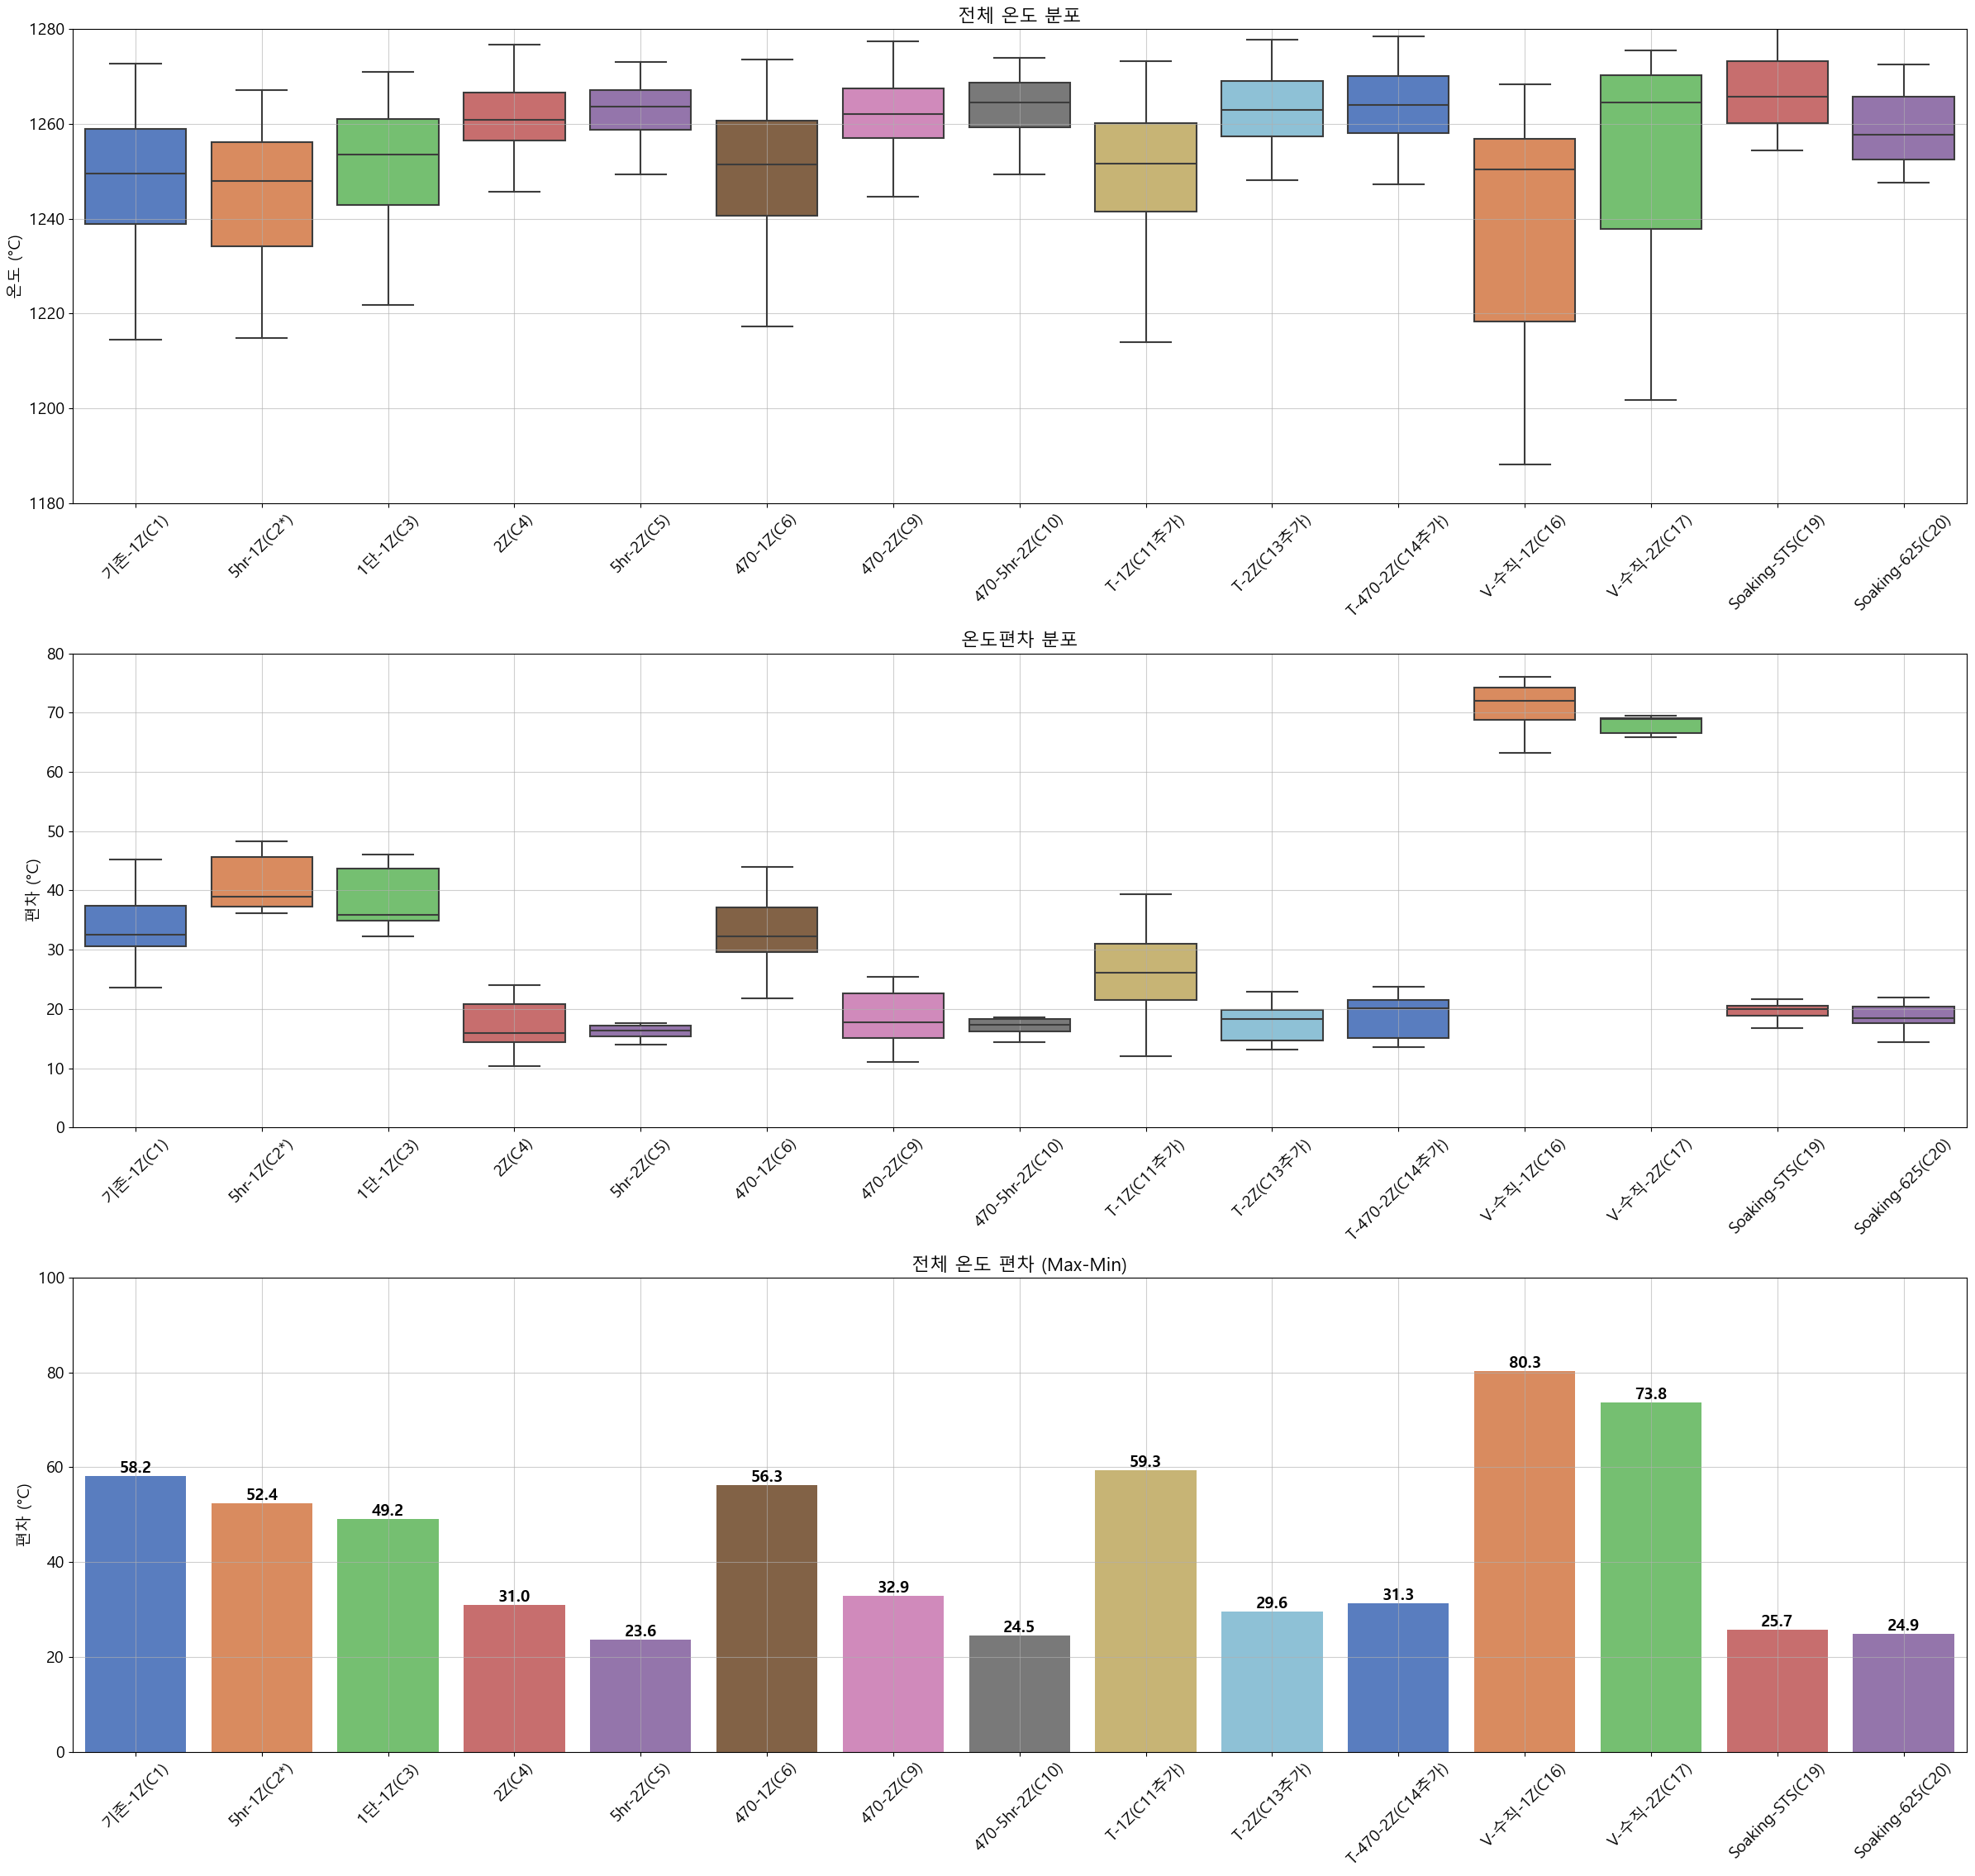


[통계 데이터]

[그래프 1: 전체 온도 분포 통계]

            count    mean   std     min     25%     50%     75%     max
Case                                                                   
Case 1     108.00 1248.44 13.43 1214.47 1238.98 1249.62 1259.04 1272.69
Case 10     54.00 1263.73  6.10 1249.36 1259.35 1264.60 1268.70 1273.87
Case 11 추가 108.00 1249.82 13.13 1213.95 1241.60 1251.63 1260.11 1273.26
Case 13 추가 108.00 1262.94  7.27 1248.16 1257.41 1262.89 1269.02 1277.80
Case 14 추가 108.00 1263.59  7.61 1247.23 1258.12 1264.06 1270.06 1278.54
Case 16    108.00 1238.28 25.75 1188.15 1218.39 1250.38 1256.88 1268.41
Case 17    108.00 1252.50 24.30 1201.80 1237.87 1264.61 1270.26 1275.56
Case 19    108.00 1266.57  7.36 1254.50 1260.10 1265.68 1273.22 1280.19
Case 2*     54.00 1245.23 13.87 1214.79 1234.30 1247.90 1256.14 1267.19
Case 20    108.00 1258.85  7.39 1247.55 1252.43 1257.74 1265.70 1272.48
Case 3      54.00 1251.44 12.73 1221.77 1242.87 1253.55 1261.03 1270.93
Case 4     108.00 1261.47  7.27

In [3]:
# ==============================================================================
# Step 0. [환경설정] - 이전 코드 블록의 데이터 사용
# ==============================================================================
# 이 코드는 이전 블록에서 생성된 'bloom_sensor_df' 데이터프레임이
# 메모리에 로드되어 있다고 가정하고 동작합니다.
# 만약 이 블록만 단독으로 실행하려면, 이전 코드의 데이터 로딩 부분을 여기에 포함해야 합니다.

# ==============================================================================
# Step 1. [신규 분석 함수 정의] - 특정 케이스 비교용
# ==============================================================================
def compare_specific_cases(
    sensor_df: pd.DataFrame, 
    cases_and_times: Dict[str, str], 
    label_map: Optional[Dict[str, str]] = None,
    y_lim_temp: Optional[Tuple[float, float]] = None,
    y_lim_delta_bloom: Optional[Tuple[float, float]] = None,
    y_lim_delta_total: Optional[Tuple[float, float]] = None
):
    """
    지정된 케이스 목록과 각기 다른 시간에 대해 3가지 유형의 비교 Boxplot을 생성하고 통계량을 출력합니다.
    
    Args:
        sensor_df (pd.DataFrame): 전체 센서 데이터가 포함된 데이터프레임.
        cases_and_times (Dict[str, str]): {'케이스 이름': '시간 시점'} 형태의 딕셔너리.
        label_map (Optional[Dict[str, str]]): X축에 표시될 케이스 이름을 변경하기 위한 딕셔너리.
        y_lim_temp (Optional[Tuple[float, float]]): '전체 온도 분포' 그래프의 Y축 범위.
        y_lim_delta_bloom (Optional[Tuple[float, float]]): '내부 Bloom 편차' 그래프의 Y축 범위.
        y_lim_delta_total (Optional[Tuple[float, float]]): '전체 온도 편차' 그래프의 Y축 범위.
    """
    # 동적 제목 생성을 위한 문자열 조합
    title_info = ' vs '.join([f"{case} ({time_desc})" for case, time_desc in cases_and_times.items()])
    print("\n" + "="*80 + f"\n[{title_info}] 비교 분석\n" + "="*80)
    
    # 1. 분석 대상 데이터 필터링 (각 케이스별로 지정된 시간에 맞춰 데이터 추출)
    dfs_to_concat = []
    for case, time_desc in cases_and_times.items():
        df_slice = sensor_df[(sensor_df['Case'] == case) & (sensor_df['TimeDesc'] == time_desc)].copy()
        if not df_slice.empty:
            dfs_to_concat.append(df_slice)
    
    if not dfs_to_concat:
        print("선택하신 조건에 해당하는 데이터가 없습니다. 케이스 이름과 시간 시점을 확인해주세요.")
        return
        
    df_filtered = pd.concat(dfs_to_concat)

    # 2. 분석에 필요한 데이터 가공
    bloom_delta_t = df_filtered.groupby(['Case', 'Bloom'])['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    bloom_delta_t.rename(columns={'Value': '내부 Bloom 온도편차(ΔT)'}, inplace=True)

    case_total_delta_t = df_filtered.groupby('Case')['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    case_total_delta_t.rename(columns={'Value': '전체 온도 편차(Max-Min)'}, inplace=True)

    # 3. 시각화를 위한 라벨 변경 및 순서 정의
    plot_order = list(cases_and_times.keys())
    
    df_plot = df_filtered.copy()
    bloom_delta_t_plot = bloom_delta_t.copy()
    case_total_delta_t_plot = case_total_delta_t.copy()
    
    if label_map:
        df_plot['Case'] = df_plot['Case'].replace(label_map)
        bloom_delta_t_plot['Case'] = bloom_delta_t_plot['Case'].replace(label_map)
        case_total_delta_t_plot['Case'] = case_total_delta_t_plot['Case'].replace(label_map)
        plot_order = [label_map.get(case, case) for case in plot_order]

    # 4. 시각화
    fig, axes = plt.subplots(3, 1, figsize=(24, 24))
    #fig.suptitle(f'선택 케이스 비교 분석: {title_info}', fontsize=20, y=1.02)

    # 그래프 1: 전체 센서 온도 분포
    sns.boxplot(ax=axes[0], x='Case', y='Value', data=df_plot, palette='muted', order=plot_order)
    axes[0].set_title('전체 온도 분포', fontsize=16)
    axes[0].set_ylabel('온도 (°C)', fontsize=14)
    axes[0].set_xlabel('')
    axes[0].grid(True, alpha=0.6)
    axes[0].tick_params(axis='x', rotation=45, labelsize=14)
    axes[0].tick_params(axis='y', rotation=0, labelsize=14)
    if y_lim_temp:
        axes[0].set_ylim(y_lim_temp)

    # 그래프 2: 내부 Bloom 온도편차 분포
    sns.boxplot(ax=axes[1], x='Case', y='내부 Bloom 온도편차(ΔT)', data=bloom_delta_t_plot, palette='muted', order=plot_order)
    axes[1].set_title('온도편차 분포', fontsize=16)
    axes[1].set_ylabel('편차 (°C)', fontsize=14)
    axes[1].set_xlabel('')
    axes[1].grid(True, alpha=0.6)
    axes[1].tick_params(axis='x', rotation=45, labelsize=14)
    axes[1].tick_params(axis='y', rotation=0, labelsize=14)
    if y_lim_delta_bloom:
        axes[1].set_ylim(y_lim_delta_bloom)

    # 그래프 3: 전체 온도 편차 (Max-Min)
    sns.barplot(ax=axes[2], x='Case', y='전체 온도 편차(Max-Min)', data=case_total_delta_t_plot, palette='muted', order=plot_order)
    axes[2].set_title('전체 온도 편차 (Max-Min)', fontsize=16)
    axes[2].set_ylabel('편차 (°C)', fontsize=14)
    axes[2].set_xlabel('')
    axes[2].grid(True, alpha=0.6)
    axes[2].tick_params(axis='x', rotation=45, labelsize=14)
    axes[2].tick_params(axis='y', rotation=0, labelsize=14)
    if y_lim_delta_total:
        axes[2].set_ylim(y_lim_delta_total)

    ## 그래프 3 --- 막대 위에 값 표시 ---
    for bar in axes[2].patches:
        value = bar.get_height()
        axes[2].annotate(f'{value:.1f}',             # 소수점 1자리
                        (bar.get_x() + bar.get_width()/2, value),   # 위치
                        ha='center', va='bottom',   # 정렬
                        fontsize=14, fontweight='bold')  # 폰트 옵션


    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # --- 5. 통계량 출력 ---
    print("\n" + "="*50 + "\n[통계 데이터]\n" + "="*50)

    stats1 = df_filtered.groupby('Case')['Value'].describe()
    print("\n[그래프 1: 전체 온도 분포 통계]\n")
    print(stats1.to_string(float_format='{:.2f}'.format))

    stats2 = bloom_delta_t.groupby('Case')['내부 Bloom 온도편차(ΔT)'].describe()
    print("\n\n[그래프 2: 온도편차 분포 통계]\n")
    print(stats2.to_string(float_format='{:.2f}'.format))

    stats3 = case_total_delta_t.set_index('Case')
    print("\n\n[그래프 3: 전체 온도 편차 (Max-Min) 값]\n")
    print(stats3.to_string(float_format='{:.2f}'.format))


# ==============================================================================
# Step 2. [비교 분석 실행] - 여기만 수정하세요!
# ==============================================================================
# --- 1. 비교하고 싶은 케이스와 해당 시간 시점을 딕셔너리 형태로 지정하세요 ---
cases_and_times_to_compare = {
    'Case 1': '4hr 시점',
    'Case 2*': '가열완료 시점',
    'Case 3': '4hr 시점',
    'Case 4': '4hr 시점',
    'Case 5': '가열완료 시점',
    'Case 6': '4hr 시점',
#    'Case 7': '4hr 시점',
#    'Case 8': '4hr 시점',
    'Case 9': '4hr 시점',
    'Case 10': '가열완료 시점',
    'Case 11 추가': '4hr 시점',
    'Case 13 추가': '4hr 시점',
    'Case 14 추가': '4hr 시점',
    'Case 16': '4hr 시점',
    'Case 17': '4hr 시점',
    'Case 19': '4hr 시점',
    'Case 20': '4hr 시점'
}

# --- 2. X축에 표시될 이름을 변경하고 싶으면 아래 딕셔너리를 수정하세요 (선택 사항) ---
case_label_map = {
    'Case 1': '기존-1Z(C1)',
    'Case 2*': '5hr-1Z(C2*)',
    'Case 3': '1단-1Z(C3)',
    'Case 4': '2Z(C4)',
    'Case 5': '5hr-2Z(C5)',
    'Case 6': '470-1Z(C6)',
#    'Case 7': '470-5hr-1Z(C7)',
#    'Case 8': '470-1단-1Z(C8)',
    'Case 9': '470-2Z(C9)',
    'Case 10': '470-5hr-2Z(C10)',
    'Case 11 추가': 'T-1Z(C11추가)',
    'Case 13 추가': 'T-2Z(C13추가)',
    'Case 14 추가': 'T-470-2Z(C14추가)',
    'Case 16': 'V-수직-1Z(C16)',
    'Case 17': 'V-수직-2Z(C17)',
    'Case 19': 'Soaking-STS(C19)',
    'Case 20': 'Soaking-625(C20)'
}

# --- 3. (선택 사항) 각 그래프의 Y축 범위를 직접 지정하고 싶으면 아래 값을 수정하세요 ---
# 자동 설정을 원하시면 None으로 두세요. (예: y_axis_range_temp = None)
y_axis_range_temp = (1180, 1280)         # 그래프 1: 전체 온도 분포 Y축 범위
y_axis_range_delta_bloom = (0, 80)      # 그래프 2: 내부 Bloom 편차 Y축 범위
y_axis_range_delta_total = (0, 100)      # 그래프 3: 전체 편차 Y축 범위

# --- 분석 실행 ---
if 'heating_sensor_df' in locals():
    compare_specific_cases(
        sensor_df=heating_sensor_df, 
        cases_and_times=cases_and_times_to_compare,
        label_map=case_label_map,
        y_lim_temp=y_axis_range_temp,
        y_lim_delta_bloom=y_axis_range_delta_bloom,
        y_lim_delta_total=y_axis_range_delta_total
    )
else:
    print("데이터가 로드되지 않았습니다. 이전 코드 블록(Step 1)을 먼저 실행해주세요.")




[Case 1 (4hr 시점) vs Case 2* (가열완료 시점) vs Case 3 (4hr 시점) vs Case 4 (4hr 시점) vs Case 5 (가열완료 시점) vs Case 6 (4hr 시점) vs Case 9 (4hr 시점) vs Case 10 (가열완료 시점) vs Case 11 추가 (4hr 시점) vs Case 13 추가 (4hr 시점) vs Case 14 추가 (4hr 시점) vs Case 16 (4hr 시점) vs Case 17 (4hr 시점) vs Case 19 (4hr 시점) vs Case 20 (4hr 시점)] 비교 분석


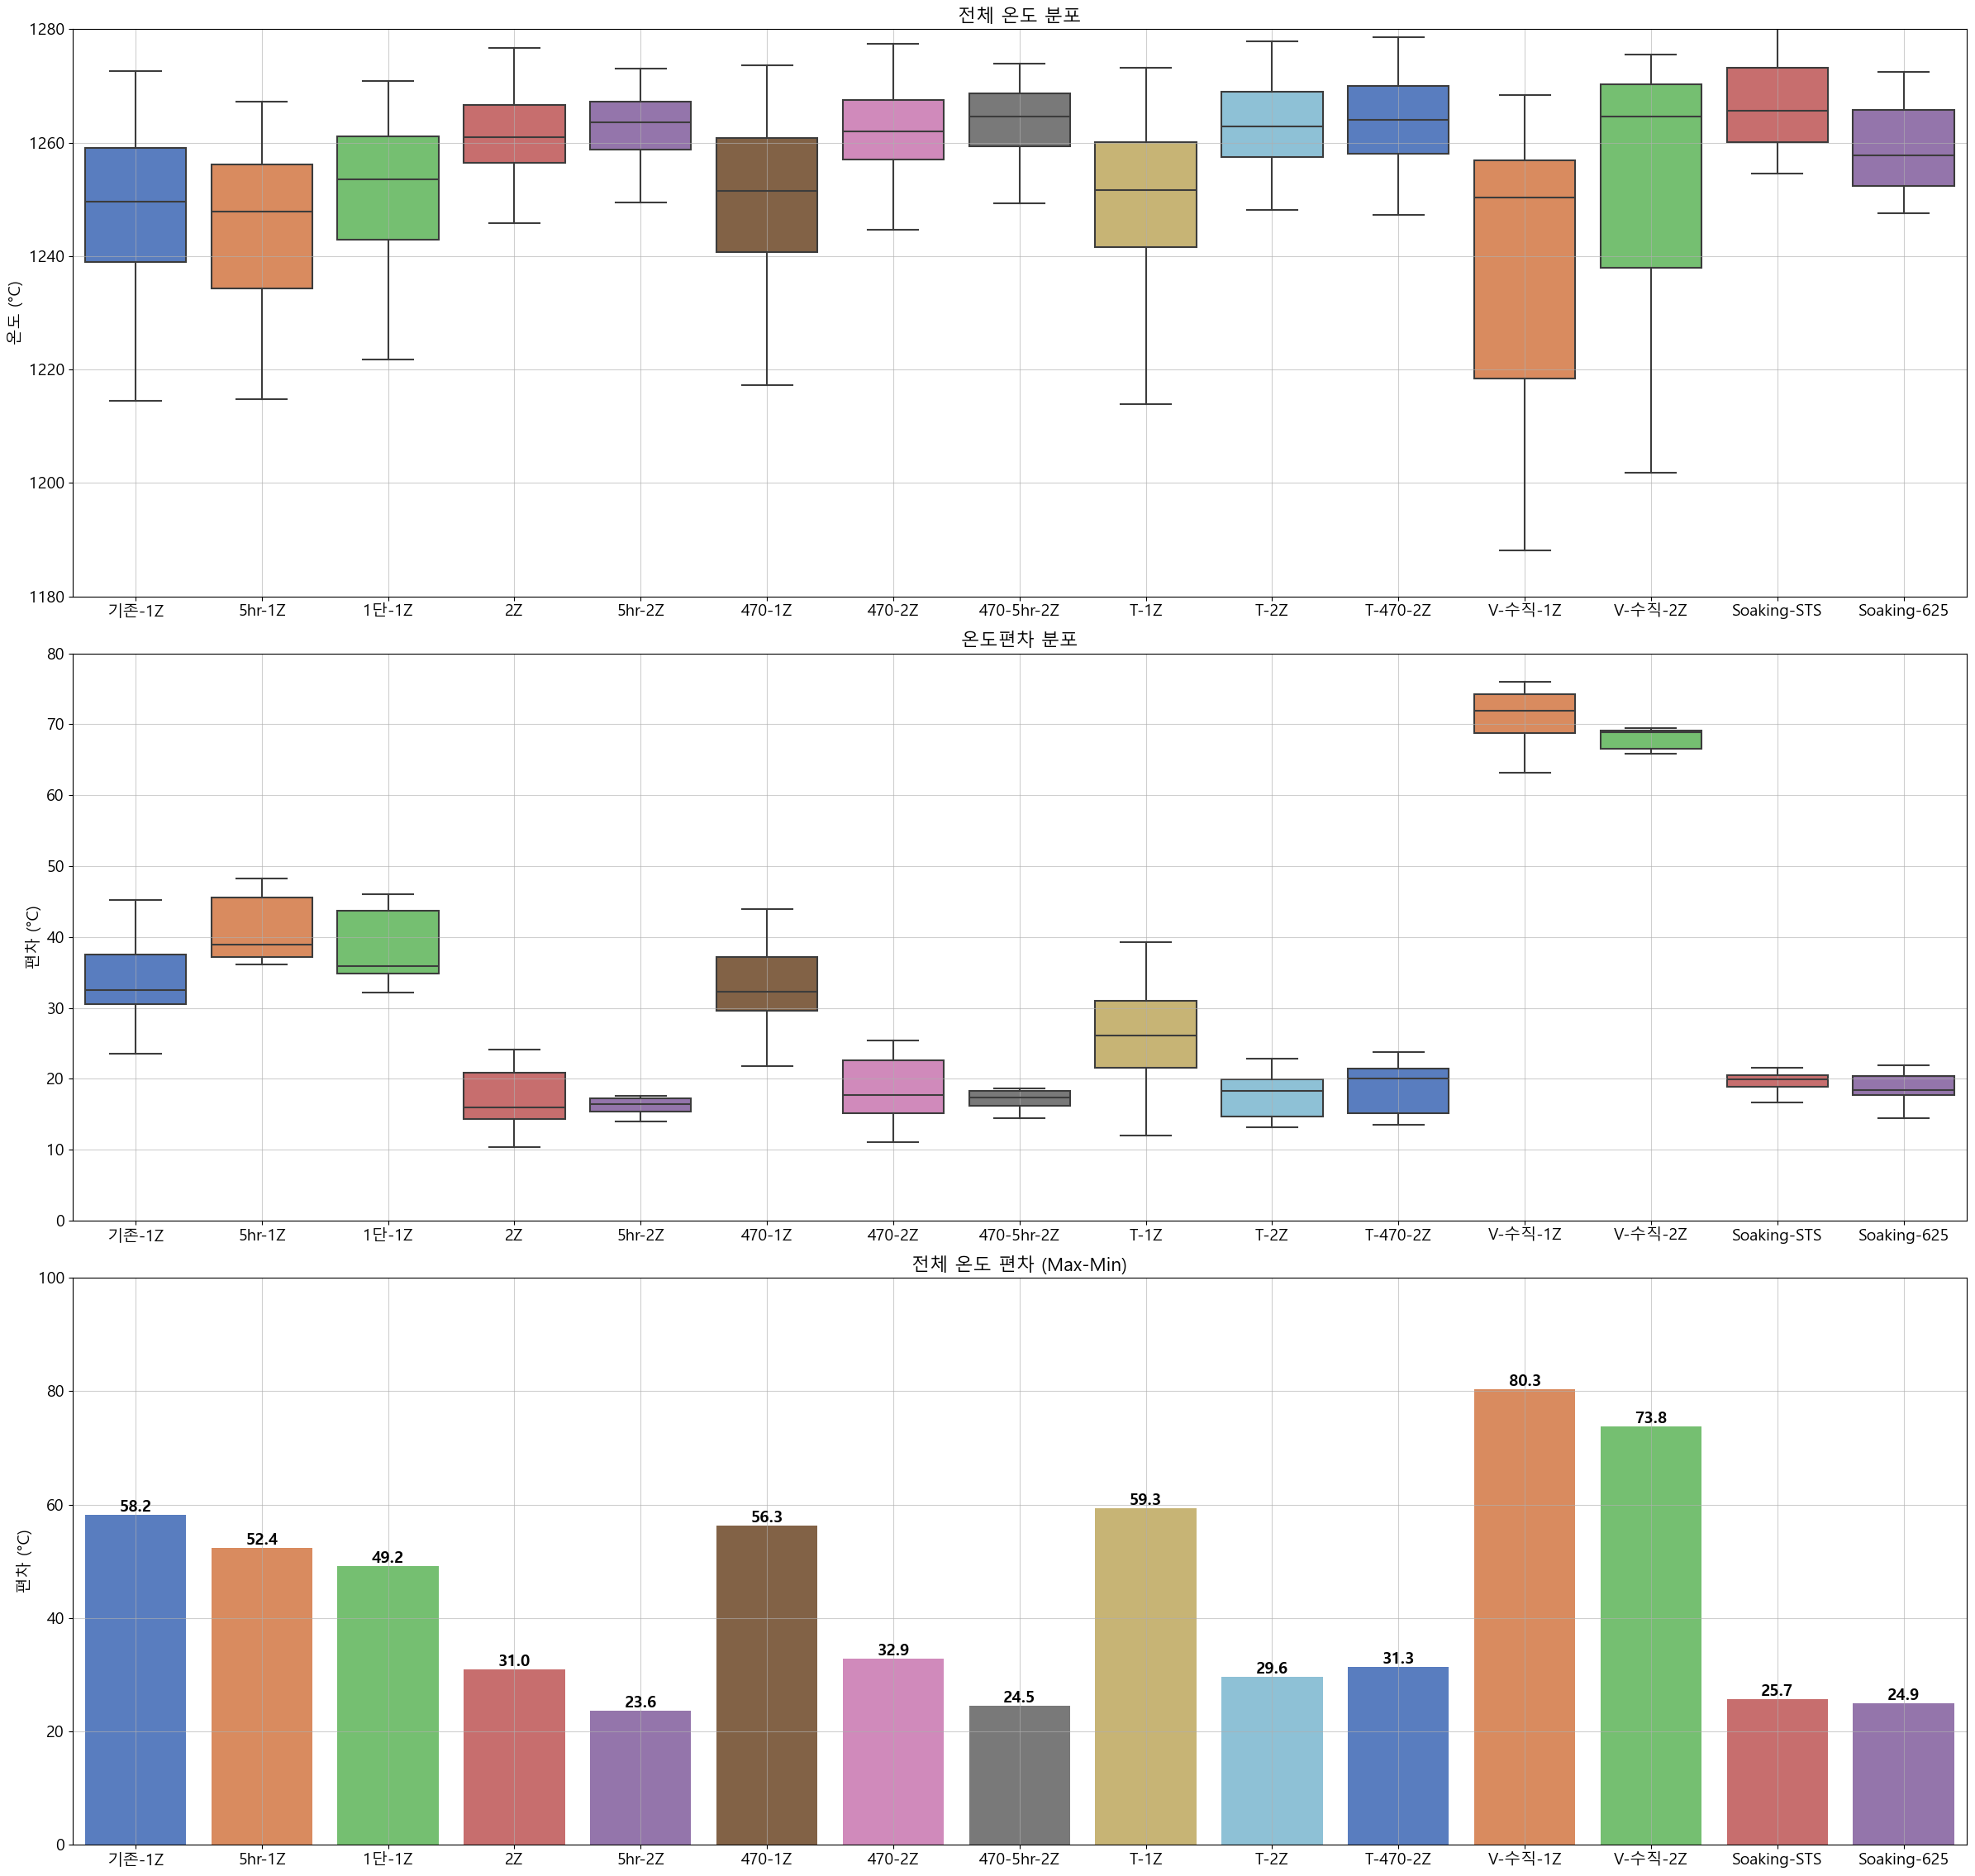


[통계 데이터]

[그래프 1: 전체 온도 분포 통계]

            count    mean   std     min     25%     50%     75%     max
Case                                                                   
Case 1     108.00 1248.44 13.43 1214.47 1238.98 1249.62 1259.04 1272.69
Case 10     54.00 1263.73  6.10 1249.36 1259.35 1264.60 1268.70 1273.87
Case 11 추가 108.00 1249.82 13.13 1213.95 1241.60 1251.63 1260.11 1273.26
Case 13 추가 108.00 1262.94  7.27 1248.16 1257.41 1262.89 1269.02 1277.80
Case 14 추가 108.00 1263.59  7.61 1247.23 1258.12 1264.06 1270.06 1278.54
Case 16    108.00 1238.28 25.75 1188.15 1218.39 1250.38 1256.88 1268.41
Case 17    108.00 1252.50 24.30 1201.80 1237.87 1264.61 1270.26 1275.56
Case 19    108.00 1266.57  7.36 1254.50 1260.10 1265.68 1273.22 1280.19
Case 2*     54.00 1245.23 13.87 1214.79 1234.30 1247.90 1256.14 1267.19
Case 20    108.00 1258.85  7.39 1247.55 1252.43 1257.74 1265.70 1272.48
Case 3      54.00 1251.44 12.73 1221.77 1242.87 1253.55 1261.03 1270.93
Case 4     108.00 1261.47  7.27

In [4]:
# ==============================================================================
# Step 0. [환경설정] - 이전 코드 블록의 데이터 사용
# ==============================================================================
# 이 코드는 이전 블록에서 생성된 'bloom_sensor_df' 데이터프레임이
# 메모리에 로드되어 있다고 가정하고 동작합니다.
# 만약 이 블록만 단독으로 실행하려면, 이전 코드의 데이터 로딩 부분을 여기에 포함해야 합니다.

# ==============================================================================
# Step 1. [신규 분석 함수 정의] - 특정 케이스 비교용
# ==============================================================================
def compare_specific_cases(
    sensor_df: pd.DataFrame, 
    cases_and_times: Dict[str, str], 
    label_map: Optional[Dict[str, str]] = None,
    y_lim_temp: Optional[Tuple[float, float]] = None,
    y_lim_delta_bloom: Optional[Tuple[float, float]] = None,
    y_lim_delta_total: Optional[Tuple[float, float]] = None
):
    """
    지정된 케이스 목록과 각기 다른 시간에 대해 3가지 유형의 비교 Boxplot을 생성하고 통계량을 출력합니다.
    
    Args:
        sensor_df (pd.DataFrame): 전체 센서 데이터가 포함된 데이터프레임.
        cases_and_times (Dict[str, str]): {'케이스 이름': '시간 시점'} 형태의 딕셔너리.
        label_map (Optional[Dict[str, str]]): X축에 표시될 케이스 이름을 변경하기 위한 딕셔너리.
        y_lim_temp (Optional[Tuple[float, float]]): '전체 온도 분포' 그래프의 Y축 범위.
        y_lim_delta_bloom (Optional[Tuple[float, float]]): '내부 Bloom 편차' 그래프의 Y축 범위.
        y_lim_delta_total (Optional[Tuple[float, float]]): '전체 온도 편차' 그래프의 Y축 범위.
    """
    # 동적 제목 생성을 위한 문자열 조합
    title_info = ' vs '.join([f"{case} ({time_desc})" for case, time_desc in cases_and_times.items()])
    print("\n" + "="*80 + f"\n[{title_info}] 비교 분석\n" + "="*80)
    
    # 1. 분석 대상 데이터 필터링 (각 케이스별로 지정된 시간에 맞춰 데이터 추출)
    dfs_to_concat = []
    for case, time_desc in cases_and_times.items():
        df_slice = sensor_df[(sensor_df['Case'] == case) & (sensor_df['TimeDesc'] == time_desc)].copy()
        if not df_slice.empty:
            dfs_to_concat.append(df_slice)
    
    if not dfs_to_concat:
        print("선택하신 조건에 해당하는 데이터가 없습니다. 케이스 이름과 시간 시점을 확인해주세요.")
        return
        
    df_filtered = pd.concat(dfs_to_concat)

    # 2. 분석에 필요한 데이터 가공
    bloom_delta_t = df_filtered.groupby(['Case', 'Bloom'])['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    bloom_delta_t.rename(columns={'Value': '내부 Bloom 온도편차(ΔT)'}, inplace=True)

    case_total_delta_t = df_filtered.groupby('Case')['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    case_total_delta_t.rename(columns={'Value': '전체 온도 편차(Max-Min)'}, inplace=True)

    # 3. 시각화를 위한 라벨 변경 및 순서 정의
    plot_order = list(cases_and_times.keys())
    
    df_plot = df_filtered.copy()
    bloom_delta_t_plot = bloom_delta_t.copy()
    case_total_delta_t_plot = case_total_delta_t.copy()
    
    if label_map:
        df_plot['Case'] = df_plot['Case'].replace(label_map)
        bloom_delta_t_plot['Case'] = bloom_delta_t_plot['Case'].replace(label_map)
        case_total_delta_t_plot['Case'] = case_total_delta_t_plot['Case'].replace(label_map)
        plot_order = [label_map.get(case, case) for case in plot_order]

    # 4. 시각화
    fig, axes = plt.subplots(3, 1, figsize=(24, 24))
    #fig.suptitle(f'선택 케이스 비교 분석: {title_info}', fontsize=20, y=1.02)

    # 그래프 1: 전체 센서 온도 분포
    sns.boxplot(ax=axes[0], x='Case', y='Value', data=df_plot, palette='muted', order=plot_order)
    axes[0].set_title('전체 온도 분포', fontsize=16)
    axes[0].set_ylabel('온도 (°C)', fontsize=14)
    axes[0].set_xlabel('')
    axes[0].grid(True, alpha=0.6)
    axes[0].tick_params(axis='x', rotation=0, labelsize=14)
    axes[0].tick_params(axis='y', rotation=0, labelsize=14)
    if y_lim_temp:
        axes[0].set_ylim(y_lim_temp)

    # 그래프 2: 내부 Bloom 온도편차 분포
    sns.boxplot(ax=axes[1], x='Case', y='내부 Bloom 온도편차(ΔT)', data=bloom_delta_t_plot, palette='muted', order=plot_order)
    axes[1].set_title('온도편차 분포', fontsize=16)
    axes[1].set_ylabel('편차 (°C)', fontsize=14)
    axes[1].set_xlabel('')
    axes[1].grid(True, alpha=0.6)
    axes[1].tick_params(axis='x', rotation=0, labelsize=14)
    axes[1].tick_params(axis='y', rotation=0, labelsize=14)
    if y_lim_delta_bloom:
        axes[1].set_ylim(y_lim_delta_bloom)

    # 그래프 3: 전체 온도 편차 (Max-Min)
    sns.barplot(ax=axes[2], x='Case', y='전체 온도 편차(Max-Min)', data=case_total_delta_t_plot, palette='muted', order=plot_order)
    axes[2].set_title('전체 온도 편차 (Max-Min)', fontsize=16)
    axes[2].set_ylabel('편차 (°C)', fontsize=14)
    axes[2].set_xlabel('')
    axes[2].grid(True, alpha=0.6)
    axes[2].tick_params(axis='x', rotation=0, labelsize=14)
    axes[2].tick_params(axis='y', rotation=0, labelsize=14)
    if y_lim_delta_total:
        axes[2].set_ylim(y_lim_delta_total)

    ## 그래프 3 --- 막대 위에 값 표시 ---
    for bar in axes[2].patches:
        value = bar.get_height()
        axes[2].annotate(f'{value:.1f}',             # 소수점 1자리
                        (bar.get_x() + bar.get_width()/2, value),   # 위치
                        ha='center', va='bottom',   # 정렬
                        fontsize=14, fontweight='bold')  # 폰트 옵션


    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # --- 5. 통계량 출력 ---
    print("\n" + "="*50 + "\n[통계 데이터]\n" + "="*50)

    stats1 = df_filtered.groupby('Case')['Value'].describe()
    print("\n[그래프 1: 전체 온도 분포 통계]\n")
    print(stats1.to_string(float_format='{:.2f}'.format))

    stats2 = bloom_delta_t.groupby('Case')['내부 Bloom 온도편차(ΔT)'].describe()
    print("\n\n[그래프 2: 온도편차 분포 통계]\n")
    print(stats2.to_string(float_format='{:.2f}'.format))

    stats3 = case_total_delta_t.set_index('Case')
    print("\n\n[그래프 3: 전체 온도 편차 (Max-Min) 값]\n")
    print(stats3.to_string(float_format='{:.2f}'.format))


# ==============================================================================
# Step 2. [비교 분석 실행] - 여기만 수정하세요!
# ==============================================================================
# --- 1. 비교하고 싶은 케이스와 해당 시간 시점을 딕셔너리 형태로 지정하세요 ---
cases_and_times_to_compare = {
    'Case 1': '4hr 시점',
    'Case 2*': '가열완료 시점',
    'Case 3': '4hr 시점',
    'Case 4': '4hr 시점',
    'Case 5': '가열완료 시점',
    'Case 6': '4hr 시점',
#    'Case 7': '4hr 시점',
#    'Case 8': '4hr 시점',
    'Case 9': '4hr 시점',
    'Case 10': '가열완료 시점',
    'Case 11 추가': '4hr 시점',
    'Case 13 추가': '4hr 시점',
    'Case 14 추가': '4hr 시점',
    'Case 16': '4hr 시점',
    'Case 17': '4hr 시점',
    'Case 19': '4hr 시점',
    'Case 20': '4hr 시점'
}

# --- 2. X축에 표시될 이름을 변경하고 싶으면 아래 딕셔너리를 수정하세요 (선택 사항) ---
case_label_map = {
    'Case 1': '기존-1Z',
    'Case 2*': '5hr-1Z',
    'Case 3': '1단-1Z',
    'Case 4': '2Z',
    'Case 5': '5hr-2Z',
    'Case 6': '470-1Z',
#    'Case 7': '470-5hr-1Z',
#    'Case 8': '470-1단-1Z',
    'Case 9': '470-2Z',
    'Case 10': '470-5hr-2Z',
    'Case 11 추가': 'T-1Z',
    'Case 13 추가': 'T-2Z',
    'Case 14 추가': 'T-470-2Z',
    'Case 16': 'V-수직-1Z',
    'Case 17': 'V-수직-2Z',
    'Case 19': 'Soaking-STS',
    'Case 20': 'Soaking-625'
}

# --- 3. (선택 사항) 각 그래프의 Y축 범위를 직접 지정하고 싶으면 아래 값을 수정하세요 ---
# 자동 설정을 원하시면 None으로 두세요. (예: y_axis_range_temp = None)
y_axis_range_temp = (1180, 1280)         # 그래프 1: 전체 온도 분포 Y축 범위
y_axis_range_delta_bloom = (0, 80)      # 그래프 2: 내부 Bloom 편차 Y축 범위
y_axis_range_delta_total = (0, 100)      # 그래프 3: 전체 편차 Y축 범위

# --- 분석 실행 ---
if 'heating_sensor_df' in locals():
    compare_specific_cases(
        sensor_df=heating_sensor_df, 
        cases_and_times=cases_and_times_to_compare,
        label_map=case_label_map,
        y_lim_temp=y_axis_range_temp,
        y_lim_delta_bloom=y_axis_range_delta_bloom,
        y_lim_delta_total=y_axis_range_delta_total
    )
else:
    print("데이터가 로드되지 않았습니다. 이전 코드 블록(Step 1)을 먼저 실행해주세요.")




[Case 1 (4hr 시점) vs Case 2* (가열완료 시점) vs Case 3 (4hr 시점) vs Case 4 (4hr 시점) vs Case 5 (가열완료 시점) vs Case 6 (4hr 시점) vs Case 9 (4hr 시점) vs Case 10 (가열완료 시점) vs Case 11 추가 (4hr 시점) vs Case 13 추가 (4hr 시점) vs Case 14 추가 (4hr 시점) vs Case 16 (4hr 시점) vs Case 17 (4hr 시점)] 비교 분석


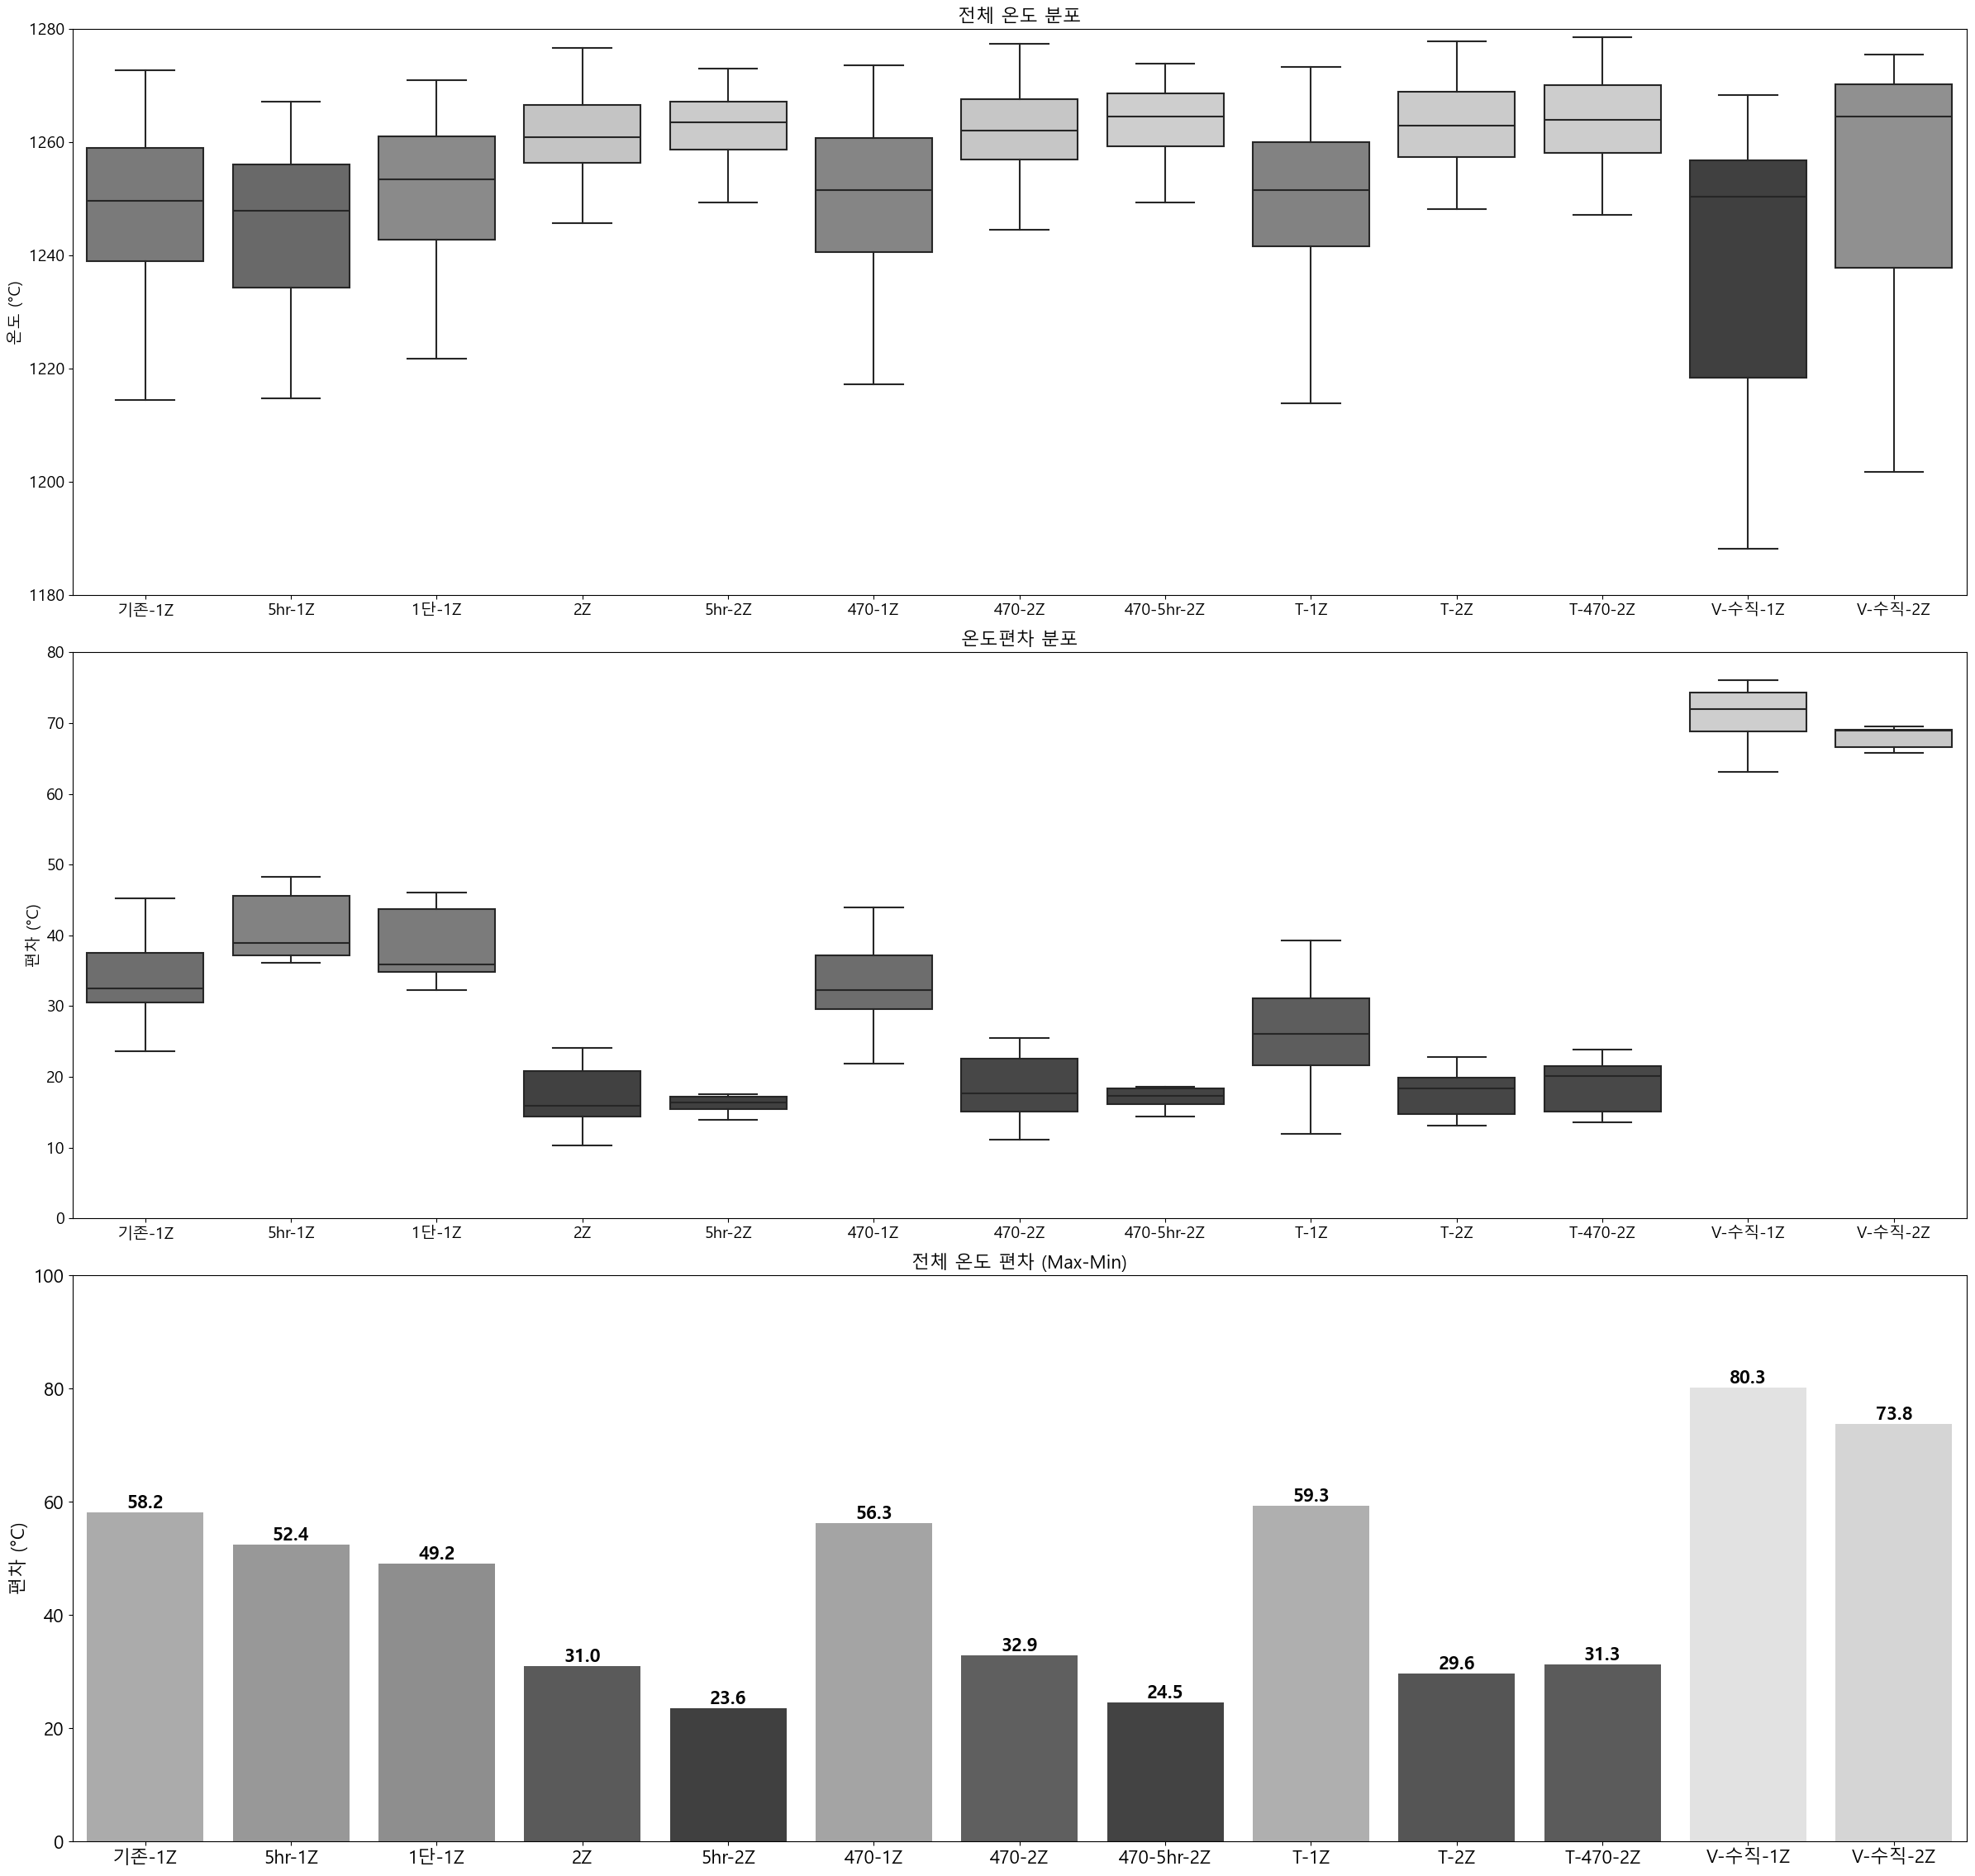


[통계 데이터]

[그래프 1: 전체 온도 분포 통계]

            count    mean   std     min     25%     50%     75%     max
Case                                                                   
Case 1     108.00 1248.44 13.43 1214.47 1238.98 1249.62 1259.04 1272.69
Case 10     54.00 1263.73  6.10 1249.36 1259.35 1264.60 1268.70 1273.87
Case 11 추가 108.00 1249.82 13.13 1213.95 1241.60 1251.63 1260.11 1273.26
Case 13 추가 108.00 1262.94  7.27 1248.16 1257.41 1262.89 1269.02 1277.80
Case 14 추가 108.00 1263.59  7.61 1247.23 1258.12 1264.06 1270.06 1278.54
Case 16    108.00 1238.28 25.75 1188.15 1218.39 1250.38 1256.88 1268.41
Case 17    108.00 1252.50 24.30 1201.80 1237.87 1264.61 1270.26 1275.56
Case 2*     54.00 1245.23 13.87 1214.79 1234.30 1247.90 1256.14 1267.19
Case 3      54.00 1251.44 12.73 1221.77 1242.87 1253.55 1261.03 1270.93
Case 4     108.00 1261.47  7.27 1245.76 1256.44 1260.93 1266.58 1276.76
Case 5      54.00 1263.03  5.79 1249.46 1258.71 1263.62 1267.20 1273.04
Case 6     108.00 1250.37 13.23

In [7]:
# ==============================================================================
# Step 0. [환경설정] - 이전 코드 블록의 데이터 사용
# ==============================================================================
# 이 코드는 이전 블록에서 생성된 'bloom_sensor_df' 데이터프레임이
# 메모리에 로드되어 있다고 가정하고 동작합니다.
# 만약 이 블록만 단독으로 실행하려면, 이전 코드의 데이터 로딩 부분을 여기에 포함해야 합니다.

# ==============================================================================
# Step 1. [신규 분석 함수 정의] - 특정 케이스 비교용
# ==============================================================================
def compare_specific_cases(
    sensor_df: pd.DataFrame, 
    cases_and_times: Dict[str, str], 
    label_map: Optional[Dict[str, str]] = None,
    y_lim_temp: Optional[Tuple[float, float]] = None,
    y_lim_delta_bloom: Optional[Tuple[float, float]] = None,
    y_lim_delta_total: Optional[Tuple[float, float]] = None
):
    """
    지정된 케이스 목록과 각기 다른 시간에 대해 3가지 유형의 비교 Boxplot을 생성하고 통계량을 출력합니다.
    
    Args:
        sensor_df (pd.DataFrame): 전체 센서 데이터가 포함된 데이터프레임.
        cases_and_times (Dict[str, str]): {'케이스 이름': '시간 시점'} 형태의 딕셔너리.
        label_map (Optional[Dict[str, str]]): X축에 표시될 케이스 이름을 변경하기 위한 딕셔너리.
        y_lim_temp (Optional[Tuple[float, float]]): '전체 온도 분포' 그래프의 Y축 범위.
        y_lim_delta_bloom (Optional[Tuple[float, float]]): '내부 Bloom 편차' 그래프의 Y축 범위.
        y_lim_delta_total (Optional[Tuple[float, float]]): '전체 온도 편차' 그래프의 Y축 범위.
    """
    # 동적 제목 생성을 위한 문자열 조합
    title_info = ' vs '.join([f"{case} ({time_desc})" for case, time_desc in cases_and_times.items()])
    print("\n" + "="*80 + f"\n[{title_info}] 비교 분석\n" + "="*80)
    
    # 1. 분석 대상 데이터 필터링 (각 케이스별로 지정된 시간에 맞춰 데이터 추출)
    dfs_to_concat = []
    for case, time_desc in cases_and_times.items():
        df_slice = sensor_df[(sensor_df['Case'] == case) & (sensor_df['TimeDesc'] == time_desc)].copy()
        if not df_slice.empty:
            dfs_to_concat.append(df_slice)
    
    if not dfs_to_concat:
        print("선택하신 조건에 해당하는 데이터가 없습니다. 케이스 이름과 시간 시점을 확인해주세요.")
        return
        
    df_filtered = pd.concat(dfs_to_concat)

    # 2. 분석에 필요한 데이터 가공
    bloom_delta_t = df_filtered.groupby(['Case', 'Bloom'])['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    bloom_delta_t.rename(columns={'Value': '내부 Bloom 온도편차(ΔT)'}, inplace=True)

    case_total_delta_t = df_filtered.groupby('Case')['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    case_total_delta_t.rename(columns={'Value': '전체 온도 편차(Max-Min)'}, inplace=True)

    # 3. 시각화를 위한 라벨 변경 및 순서 정의
    plot_order = list(cases_and_times.keys())
    
    df_plot = df_filtered.copy()
    bloom_delta_t_plot = bloom_delta_t.copy()
    case_total_delta_t_plot = case_total_delta_t.copy()
    
    if label_map:
        df_plot['Case'] = df_plot['Case'].replace(label_map)
        bloom_delta_t_plot['Case'] = bloom_delta_t_plot['Case'].replace(label_map)
        case_total_delta_t_plot['Case'] = case_total_delta_t_plot['Case'].replace(label_map)
        plot_order = [label_map.get(case, case) for case in plot_order]

    # 4. 시각화
    fig, axes = plt.subplots(3, 1, figsize=(24, 24))
    #fig.suptitle(f'선택 케이스 비교 분석: {title_info}', fontsize=20, y=1.02)

    # ====== 그래프 1: 전체 센서 온도 분포 ======
    means_temp = [df_plot[df_plot['Case'] == case]['Value'].mean() for case in plot_order]
    norm_temp = plt.Normalize(min(means_temp), max(means_temp))
    colors_temp = [plt.cm.Greys(0.8 - 0.5 * norm_temp(v)) for v in means_temp]
    sns.boxplot(ax=axes[0], x='Case', y='Value', data=df_plot, palette=colors_temp, order=plot_order)
    axes[0].set_title('전체 온도 분포', fontsize=16)
    axes[0].set_ylabel('온도 (°C)', fontsize=14)
    axes[0].set_xlabel('')
#    axes[0].grid(True, alpha=0.6)
    axes[0].tick_params(axis='x', rotation=0, labelsize=14)
    axes[0].tick_params(axis='y', rotation=0, labelsize=14)
    if y_lim_temp:
        axes[0].set_ylim(y_lim_temp)

    # ====== 그래프 2: 내부 Bloom 온도편차 분포 ======
    means_bloom = [bloom_delta_t_plot[bloom_delta_t_plot['Case'] == case]['내부 Bloom 온도편차(ΔT)'].mean() for case in plot_order]
    norm_bloom = plt.Normalize(min(means_bloom), max(means_bloom))
    colors_bloom = [plt.cm.Greys(0.8 - 0.5 * norm_bloom(v)) for v in means_bloom]
    sns.boxplot(ax=axes[1], x='Case', y='내부 Bloom 온도편차(ΔT)', data=bloom_delta_t_plot, palette=colors_bloom, order=plot_order)
    axes[1].set_title('온도편차 분포', fontsize=16)
    axes[1].set_ylabel('편차 (°C)', fontsize=14)
    axes[1].set_xlabel('')
#    axes[1].grid(True, alpha=0.6)
    axes[1].tick_params(axis='x', rotation=0, labelsize=14)
    axes[1].tick_params(axis='y', rotation=0, labelsize=14)
    if y_lim_delta_bloom:
        axes[1].set_ylim(y_lim_delta_bloom)

    # ====== 그래프 3: 전체 온도 편차 (Max-Min) ======
    bar_vals = [case_total_delta_t_plot.set_index('Case').loc[case, '전체 온도 편차(Max-Min)'] for case in plot_order]
    norm = plt.Normalize(min(bar_vals), max(bar_vals))
    colors = [plt.cm.Greys(0.8 - 0.6 * norm(v)) for v in bar_vals]
    sns.barplot(ax=axes[2], x='Case', y='전체 온도 편차(Max-Min)', data=case_total_delta_t_plot, palette=colors, order=plot_order)
    axes[2].set_title('전체 온도 편차 (Max-Min)', fontsize=16)
    axes[2].set_ylabel('편차 (°C)', fontsize=16)
    axes[2].set_xlabel('')
#    axes[2].grid(True, alpha=0.6)
    axes[2].tick_params(axis='x', rotation=0, labelsize=16)
    axes[2].tick_params(axis='y', rotation=0, labelsize=16)
    if y_lim_delta_total:
        axes[2].set_ylim(y_lim_delta_total)

    ## 그래프 3 --- 막대 위에 값 표시 ---
    for bar in axes[2].patches:
        value = bar.get_height()
        axes[2].annotate(f'{value:.1f}',             # 소수점 1자리
                        (bar.get_x() + bar.get_width()/2, value),   # 위치
                        ha='center', va='bottom',   # 정렬
                        fontsize=16, fontweight='bold')  # 폰트 옵션


    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # --- 5. 통계량 출력 ---
    print("\n" + "="*50 + "\n[통계 데이터]\n" + "="*50)

    stats1 = df_filtered.groupby('Case')['Value'].describe()
    print("\n[그래프 1: 전체 온도 분포 통계]\n")
    print(stats1.to_string(float_format='{:.2f}'.format))

    stats2 = bloom_delta_t.groupby('Case')['내부 Bloom 온도편차(ΔT)'].describe()
    print("\n\n[그래프 2: 온도편차 분포 통계]\n")
    print(stats2.to_string(float_format='{:.2f}'.format))

    stats3 = case_total_delta_t.set_index('Case')
    print("\n\n[그래프 3: 전체 온도 편차 (Max-Min) 값]\n")
    print(stats3.to_string(float_format='{:.2f}'.format))


# ==============================================================================
# Step 2. [비교 분석 실행] - 여기만 수정하세요!
# ==============================================================================
# --- 1. 비교하고 싶은 케이스와 해당 시간 시점을 딕셔너리 형태로 지정하세요 ---
cases_and_times_to_compare = {
    'Case 1': '4hr 시점',
    'Case 2*': '가열완료 시점',
    'Case 3': '4hr 시점',
    'Case 4': '4hr 시점',
    'Case 5': '가열완료 시점',
    'Case 6': '4hr 시점',
#    'Case 7': '4hr 시점',
#    'Case 8': '4hr 시점',
    'Case 9': '4hr 시점',
    'Case 10': '가열완료 시점',
    'Case 11 추가': '4hr 시점',
    'Case 13 추가': '4hr 시점',
    'Case 14 추가': '4hr 시점',
    'Case 16': '4hr 시점',
    'Case 17': '4hr 시점',
#    'Case 19': '4hr 시점',
#    'Case 20': '4hr 시점'
}

# --- 2. X축에 표시될 이름을 변경하고 싶으면 아래 딕셔너리를 수정하세요 (선택 사항) ---
case_label_map = {
    'Case 1': '기존-1Z',
    'Case 2*': '5hr-1Z',
    'Case 3': '1단-1Z',
    'Case 4': '2Z',
    'Case 5': '5hr-2Z',
    'Case 6': '470-1Z',
#    'Case 7': '470-5hr-1Z',
#    'Case 8': '470-1단-1Z',
    'Case 9': '470-2Z',
    'Case 10': '470-5hr-2Z',
    'Case 11 추가': 'T-1Z',
    'Case 13 추가': 'T-2Z',
    'Case 14 추가': 'T-470-2Z',
    'Case 16': 'V-수직-1Z',
    'Case 17': 'V-수직-2Z',
#    'Case 19': 'Soaking-STS',
#    'Case 20': 'Soaking-625'
}

# --- 3. (선택 사항) 각 그래프의 Y축 범위를 직접 지정하고 싶으면 아래 값을 수정하세요 ---
# 자동 설정을 원하시면 None으로 두세요. (예: y_axis_range_temp = None)
y_axis_range_temp = (1180, 1280)         # 그래프 1: 전체 온도 분포 Y축 범위
y_axis_range_delta_bloom = (0, 80)      # 그래프 2: 내부 Bloom 편차 Y축 범위
y_axis_range_delta_total = (0, 100)      # 그래프 3: 전체 편차 Y축 범위

# --- 분석 실행 ---
if 'heating_sensor_df' in locals():
    compare_specific_cases(
        sensor_df=heating_sensor_df, 
        cases_and_times=cases_and_times_to_compare,
        label_map=case_label_map,
        y_lim_temp=y_axis_range_temp,
        y_lim_delta_bloom=y_axis_range_delta_bloom,
        y_lim_delta_total=y_axis_range_delta_total
    )
else:
    print("데이터가 로드되지 않았습니다. 이전 코드 블록(Step 1)을 먼저 실행해주세요.")



[Case 1 (4hr 시점) vs Case 2* (가열완료 시점) vs Case 3 (4hr 시점) vs Case 4 (4hr 시점) vs Case 5 (가열완료 시점) vs Case 6 (4hr 시점) vs Case 9 (4hr 시점) vs Case 10 (가열완료 시점) vs Case 11 추가 (4hr 시점) vs Case 13 추가 (4hr 시점) vs Case 14 추가 (4hr 시점) vs Case 16 (4hr 시점) vs Case 17 (4hr 시점)] 비교 분석


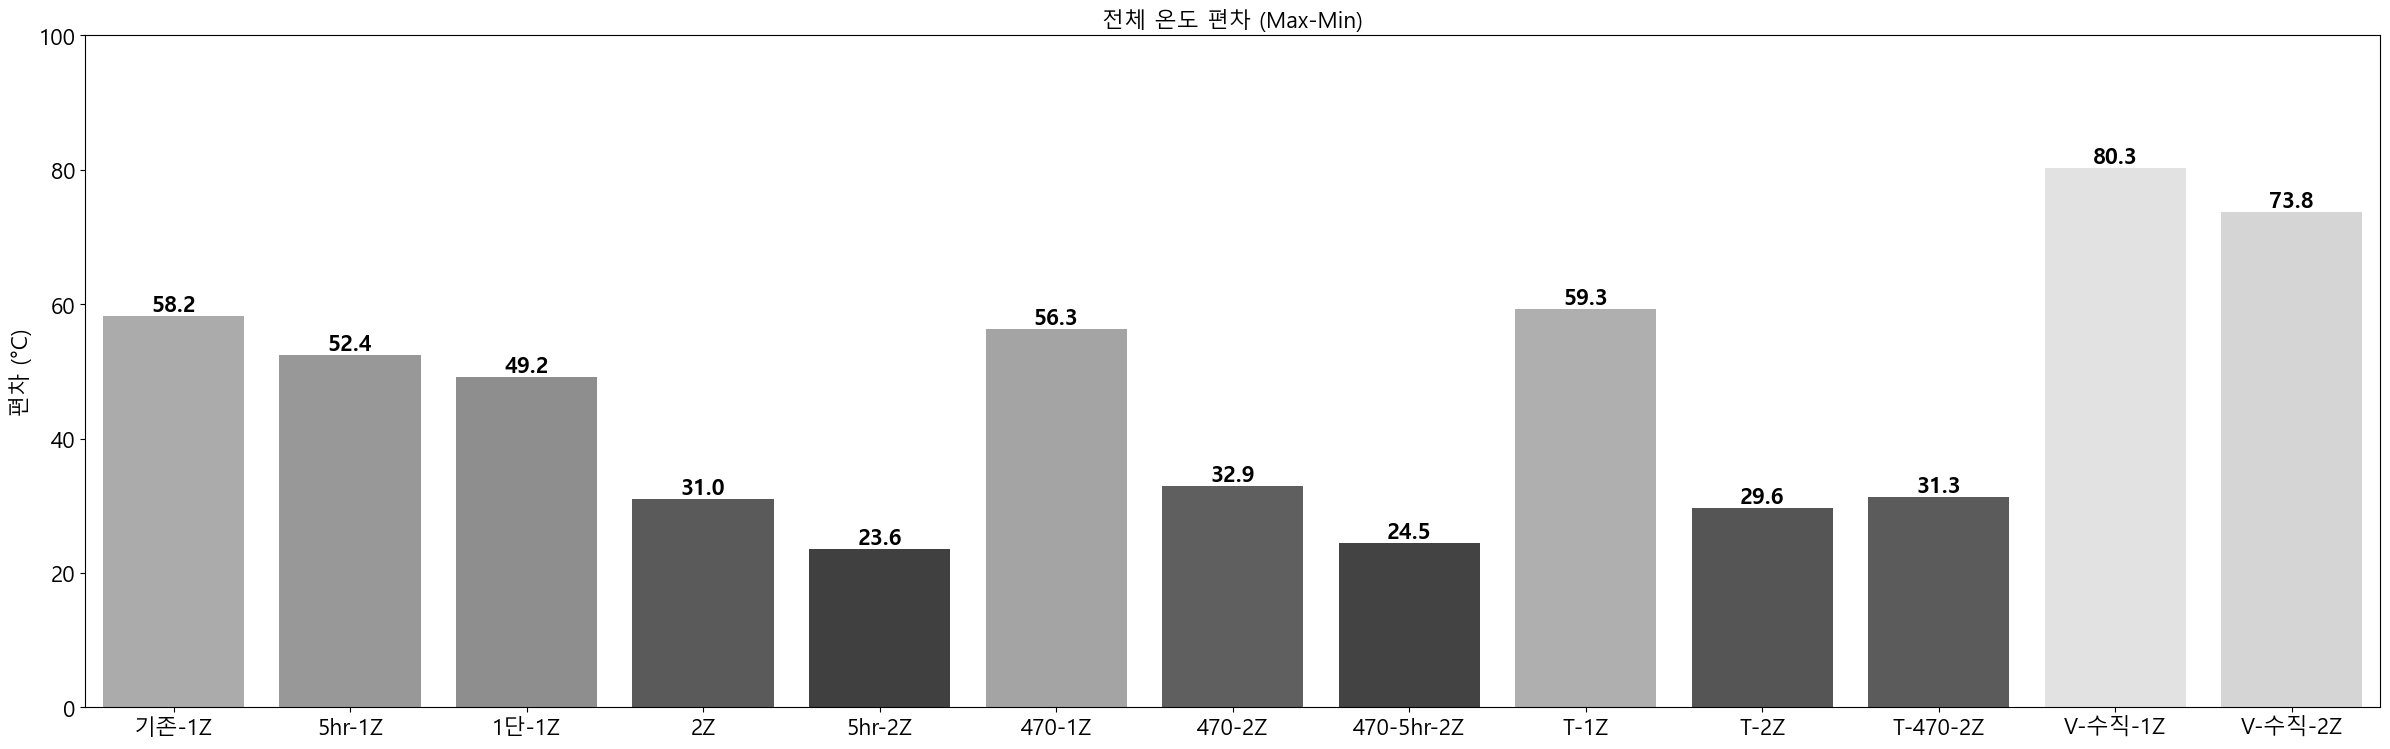


[그래프 3: 전체 온도 편차 (Max-Min) 값]
            전체 온도 편차(Max-Min)
Case                         
Case 1                  58.22
Case 10                 24.51
Case 11 추가              59.31
Case 13 추가              29.64
Case 14 추가              31.31
Case 16                 80.26
Case 17                 73.76
Case 2*                 52.40
Case 3                  49.16
Case 4                  31.00
Case 5                  23.58
Case 6                  56.32
Case 9                  32.88


In [10]:
# ==============================================================================
# Step 0. [환경설정] - 이전 코드 블록의 데이터 사용
# ==============================================================================
# 이 코드는 이전 블록에서 생성된 'bloom_sensor_df' 데이터프레임이
# 메모리에 로드되어 있다고 가정하고 동작합니다.
# 만약 이 블록만 단독으로 실행하려면, 이전 코드의 데이터 로딩 부분을 여기에 포함해야 합니다.

from typing import Dict, Optional, Tuple
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# Step 1. [신규 분석 함수 정의] - 특정 케이스 비교용
# ==============================================================================
def compare_specific_cases(
    sensor_df: pd.DataFrame, 
    cases_and_times: Dict[str, str], 
    label_map: Optional[Dict[str, str]] = None,
    y_lim_delta_total: Optional[Tuple[float, float]] = None
):
    """
    지정된 케이스 목록과 각기 다른 시간에 대해 3가지 유형의 비교 Boxplot 중
    '전체 온도 편차(Max-Min)' 그래프만 생성하고 통계량을 출력합니다.
    
    Args:
        sensor_df (pd.DataFrame): 전체 센서 데이터가 포함된 데이터프레임.
        cases_and_times (Dict[str, str]): {'케이스 이름': '시간 시점'} 형태의 딕셔너리.
        label_map (Optional[Dict[str, str]]): X축에 표시될 케이스 이름을 변경하기 위한 딕셔너리.
        y_lim_delta_total (Optional[Tuple[float, float]]): '전체 온도 편차' 그래프의 Y축 범위.
    """
    # 동적 제목 생성을 위한 문자열 조합
    title_info = ' vs '.join([f"{case} ({time_desc})" for case, time_desc in cases_and_times.items()])
    print("\n" + "="*80 + f"\n[{title_info}] 비교 분석\n" + "="*80)
    
    # 1. 분석 대상 데이터 필터링 (각 케이스별로 지정된 시간에 맞춰 데이터 추출)
    dfs_to_concat = []
    for case, time_desc in cases_and_times.items():
        df_slice = sensor_df[(sensor_df['Case'] == case) & (sensor_df['TimeDesc'] == time_desc)].copy()
        if not df_slice.empty:
            dfs_to_concat.append(df_slice)
    
    if not dfs_to_concat:
        print("선택하신 조건에 해당하는 데이터가 없습니다. 케이스 이름과 시간 시점을 확인해주세요.")
        return
        
    df_filtered = pd.concat(dfs_to_concat)

    # 2. 전체 온도 편차 계산
    case_total_delta_t = df_filtered.groupby('Case')['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    case_total_delta_t.rename(columns={'Value': '전체 온도 편차(Max-Min)'}, inplace=True)

    # 3. 시각화를 위한 라벨 변경 및 순서 정의
    plot_order = list(cases_and_times.keys())
    case_total_delta_t_plot = case_total_delta_t.copy()

    if label_map:
        case_total_delta_t_plot['Case'] = case_total_delta_t_plot['Case'].replace(label_map)
        plot_order = [label_map.get(case, case) for case in plot_order]

    # 인덱스를 라벨로 설정
    case_total_delta_t_plot.set_index('Case', inplace=True)

    # 4. 시각화
    fig, axes = plt.subplots(1, 1, figsize=(24, 8))

    # ====== 그래프 3: 전체 온도 편차 (Max-Min) ======
    bar_vals = [case_total_delta_t_plot.loc[case, '전체 온도 편차(Max-Min)'] for case in plot_order]
    norm = plt.Normalize(min(bar_vals), max(bar_vals))
    colors = [plt.cm.Greys(0.8 - 0.6 * norm(v)) for v in bar_vals]

    sns.barplot(
        ax=axes, x='Case', y='전체 온도 편차(Max-Min)',
        data=case_total_delta_t_plot.reset_index(),
        palette=colors, order=plot_order
    )
    axes.set_title('전체 온도 편차 (Max-Min)', fontsize=16)
    axes.set_ylabel('편차 (°C)', fontsize=16)
    axes.set_xlabel('')
    axes.tick_params(axis='x', rotation=0, labelsize=16)
    axes.tick_params(axis='y', rotation=0, labelsize=16)
    if y_lim_delta_total:
        axes.set_ylim(y_lim_delta_total)

    # 막대 위에 값 표시
    for i, val in enumerate(bar_vals):
        axes.annotate(f'{val:.1f}', (i, val),
                      ha='center', va='bottom',
                      fontsize=16, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # --- 5. 통계량 출력 ---
    print("\n" + "="*50 + "\n[그래프 3: 전체 온도 편차 (Max-Min) 값]\n" + "="*50)
    print(case_total_delta_t.set_index('Case').to_string(float_format='{:.2f}'.format))


# ==============================================================================
# Step 2. [비교 분석 실행] - 여기만 수정하세요!
# ==============================================================================
# --- 1. 비교하고 싶은 케이스와 해당 시간 시점을 딕셔너리 형태로 지정하세요 ---
cases_and_times_to_compare = {
    'Case 1': '4hr 시점',
    'Case 2*': '가열완료 시점',
    'Case 3': '4hr 시점',
    'Case 4': '4hr 시점',
    'Case 5': '가열완료 시점',
    'Case 6': '4hr 시점',
#    'Case 7': '4hr 시점',
#    'Case 8': '4hr 시점',
    'Case 9': '4hr 시점',
    'Case 10': '가열완료 시점',
    'Case 11 추가': '4hr 시점',
    'Case 13 추가': '4hr 시점',
    'Case 14 추가': '4hr 시점',
    'Case 16': '4hr 시점',
    'Case 17': '4hr 시점',
#    'Case 19': '4hr 시점',
#    'Case 20': '4hr 시점'
}

# --- 2. X축에 표시될 이름을 변경하고 싶으면 아래 딕셔너리를 수정하세요 (선택 사항) ---
case_label_map = {
    'Case 1': '기존-1Z',
    'Case 2*': '5hr-1Z',
    'Case 3': '1단-1Z',
    'Case 4': '2Z',
    'Case 5': '5hr-2Z',
    'Case 6': '470-1Z',
#    'Case 7': '470-5hr-1Z',
#    'Case 8': '470-1단-1Z',
    'Case 9': '470-2Z',
    'Case 10': '470-5hr-2Z',
    'Case 11 추가': 'T-1Z',
    'Case 13 추가': 'T-2Z',
    'Case 14 추가': 'T-470-2Z',
    'Case 16': 'V-수직-1Z',
    'Case 17': 'V-수직-2Z',
#    'Case 19': 'Soaking-STS',
#    'Case 20': 'Soaking-625'
}

# --- 3. (선택 사항) 각 그래프의 Y축 범위를 직접 지정하고 싶으면 아래 값을 수정하세요 ---
y_axis_range_delta_total = (0, 100)  # 그래프 3: 전체 온도 편차 Y축 범위

# --- 분석 실행 ---
if 'heating_sensor_df' in locals():
    compare_specific_cases(
        sensor_df=heating_sensor_df, 
        cases_and_times=cases_and_times_to_compare,
        label_map=case_label_map,
        y_lim_delta_total=y_axis_range_delta_total
    )
else:
    print("데이터가 로드되지 않았습니다. 이전 코드 블록(Step 1)을 먼저 실행해주세요.")



[Case 1 (4hr 시점) vs Case 2* (가열완료 시점) vs Case 3 (4hr 시점) vs Case 4 (4hr 시점) vs Case 5 (가열완료 시점) vs Case 6 (4hr 시점) vs Case 9 (4hr 시점) vs Case 10 (가열완료 시점) vs Case 11 추가 (4hr 시점) vs Case 13 추가 (4hr 시점) vs Case 14 추가 (4hr 시점) vs Case 16 (4hr 시점) vs Case 17 (4hr 시점)] 비교 분석


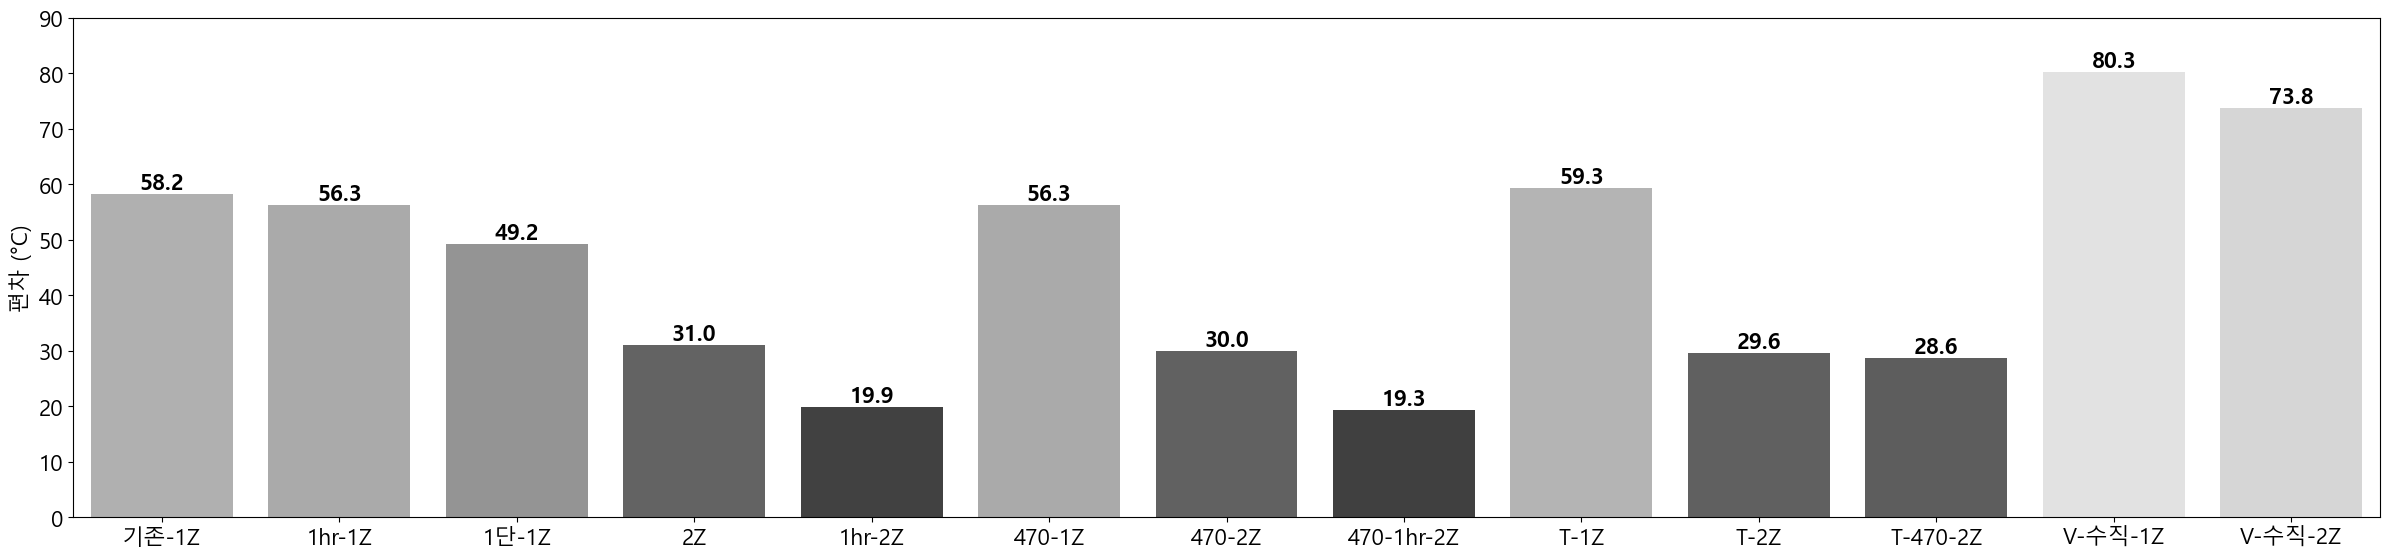


[그래프 3: 전체 온도 편차 (Max-Min) 값]
            전체 온도 편차(Max-Min)
Case                         
Case 1                  58.22
Case 10                 19.30
Case 11 추가              59.31
Case 13 추가              29.64
Case 14 추가              28.60
Case 16                 80.26
Case 17                 73.76
Case 2*                 56.30
Case 3                  49.16
Case 4                  31.00
Case 5                  19.90
Case 6                  56.32
Case 9                  30.00


In [14]:
# Data값 강제 수정(Case 2*, 5, 9, 10, 14 추가)
# # ==============================================================================
# Step 0. [환경설정] - 이전 코드 블록의 데이터 사용
# ==============================================================================
# 이 코드는 이전 블록에서 생성된 'bloom_sensor_df' 데이터프레임이
# 메모리에 로드되어 있다고 가정하고 동작합니다.
# 만약 이 블록만 단독으로 실행하려면, 이전 코드의 데이터 로딩 부분을 여기에 포함해야 합니다.

from typing import Dict, Optional, Tuple
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# Step 1. [신규 분석 함수 정의] - 특정 케이스 비교용
# ==============================================================================
def compare_specific_cases(
    sensor_df: pd.DataFrame, 
    cases_and_times: Dict[str, str], 
    label_map: Optional[Dict[str, str]] = None,
    y_lim_delta_total: Optional[Tuple[float, float]] = None
):
    """
    지정된 케이스 목록과 각기 다른 시간에 대해 3가지 유형의 비교 Boxplot 중
    '전체 온도 편차(Max-Min)' 그래프만 생성하고 통계량을 출력합니다.
    
    Args:
        sensor_df (pd.DataFrame): 전체 센서 데이터가 포함된 데이터프레임.
        cases_and_times (Dict[str, str]): {'케이스 이름': '시간 시점'} 형태의 딕셔너리.
        label_map (Optional[Dict[str, str]]): X축에 표시될 케이스 이름을 변경하기 위한 딕셔너리.
        y_lim_delta_total (Optional[Tuple[float, float]]): '전체 온도 편차' 그래프의 Y축 범위.
    """
    # 동적 제목 생성을 위한 문자열 조합
    title_info = ' vs '.join([f"{case} ({time_desc})" for case, time_desc in cases_and_times.items()])
    print("\n" + "="*80 + f"\n[{title_info}] 비교 분석\n" + "="*80)
    
    # 1. 분석 대상 데이터 필터링 (각 케이스별로 지정된 시간에 맞춰 데이터 추출)
    dfs_to_concat = []
    for case, time_desc in cases_and_times.items():
        df_slice = sensor_df[(sensor_df['Case'] == case) & (sensor_df['TimeDesc'] == time_desc)].copy()
        if not df_slice.empty:
            dfs_to_concat.append(df_slice)
    
    if not dfs_to_concat:
        print("선택하신 조건에 해당하는 데이터가 없습니다. 케이스 이름과 시간 시점을 확인해주세요.")
        return
        
    df_filtered = pd.concat(dfs_to_concat)

    # 2. 전체 온도 편차 계산
    case_total_delta_t = df_filtered.groupby('Case')['Value'].agg(lambda x: x.max() - x.min()).reset_index()
    case_total_delta_t.rename(columns={'Value': '전체 온도 편차(Max-Min)'}, inplace=True)

    # 2.1 ====== [추가] 강제 값 수정 ======
    forced_values = {
        'Case 2*': 56.3,
        'Case 5': 19.9,
        'Case 9': 30.0,
        'Case 10': 19.3,
        'Case 14 추가': 28.6
    }
    case_total_delta_t['전체 온도 편차(Max-Min)'] = case_total_delta_t.apply(
        lambda row: forced_values[row['Case']] if row['Case'] in forced_values else row['전체 온도 편차(Max-Min)'],
        axis=1
    )

    # 3. 시각화를 위한 라벨 변경 및 순서 정의
    plot_order = list(cases_and_times.keys())
    case_total_delta_t_plot = case_total_delta_t.copy()

    if label_map:
        case_total_delta_t_plot['Case'] = case_total_delta_t_plot['Case'].replace(label_map)
        plot_order = [label_map.get(case, case) for case in plot_order]

    # 인덱스를 라벨로 설정
    case_total_delta_t_plot.set_index('Case', inplace=True)

    # 4. 시각화
    fig, axes = plt.subplots(1, 1, figsize=(24, 6))

    # ====== 그래프 3: 전체 온도 편차 (Max-Min) ======
    bar_vals = [case_total_delta_t_plot.loc[case, '전체 온도 편차(Max-Min)'] for case in plot_order]
    norm = plt.Normalize(min(bar_vals), max(bar_vals))
    colors = [plt.cm.Greys(0.8 - 0.6 * norm(v)) for v in bar_vals]

    sns.barplot(
        ax=axes, x='Case', y='전체 온도 편차(Max-Min)',
        data=case_total_delta_t_plot.reset_index(),
        palette=colors, order=plot_order
    )
    #axes.set_title('전체 온도 편차 (Max-Min)', fontsize=16)
    axes.set_ylabel('편차 (°C)', fontsize=16)
    axes.set_xlabel('')
    axes.tick_params(axis='x', rotation=0, labelsize=16)
    axes.tick_params(axis='y', rotation=0, labelsize=16)
    if y_lim_delta_total:
        axes.set_ylim(y_lim_delta_total)

    # 막대 위에 값 표시
    for i, val in enumerate(bar_vals):
        axes.annotate(f'{val:.1f}', (i, val),
                      ha='center', va='bottom',
                      fontsize=16, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # --- 5. 통계량 출력 ---
    print("\n" + "="*50 + "\n[그래프 3: 전체 온도 편차 (Max-Min) 값]\n" + "="*50)
    print(case_total_delta_t.set_index('Case').to_string(float_format='{:.2f}'.format))


# ==============================================================================
# Step 2. [비교 분석 실행] - 여기만 수정하세요!
# ==============================================================================
# --- 1. 비교하고 싶은 케이스와 해당 시간 시점을 딕셔너리 형태로 지정하세요 ---
cases_and_times_to_compare = {
    'Case 1': '4hr 시점',
    'Case 2*': '가열완료 시점',
    'Case 3': '4hr 시점',
    'Case 4': '4hr 시점',
    'Case 5': '가열완료 시점',
    'Case 6': '4hr 시점',
#    'Case 7': '4hr 시점',
#    'Case 8': '4hr 시점',
    'Case 9': '4hr 시점',
    'Case 10': '가열완료 시점',
    'Case 11 추가': '4hr 시점',
    'Case 13 추가': '4hr 시점',
    'Case 14 추가': '4hr 시점',
    'Case 16': '4hr 시점',
    'Case 17': '4hr 시점',
#    'Case 19': '4hr 시점',
#    'Case 20': '4hr 시점'
}

# --- 2. X축에 표시될 이름을 변경하고 싶으면 아래 딕셔너리를 수정하세요 (선택 사항) ---
case_label_map = {
    'Case 1': '기존-1Z',
    'Case 2*': '1hr-1Z',
    'Case 3': '1단-1Z',
    'Case 4': '2Z',
    'Case 5': '1hr-2Z',
    'Case 6': '470-1Z',
#    'Case 7': '470-5hr-1Z',
#    'Case 8': '470-1단-1Z',
    'Case 9': '470-2Z',
    'Case 10': '470-1hr-2Z',
    'Case 11 추가': 'T-1Z',
    'Case 13 추가': 'T-2Z',
    'Case 14 추가': 'T-470-2Z',
    'Case 16': 'V-수직-1Z',
    'Case 17': 'V-수직-2Z',
#    'Case 19': 'Soaking-STS',
#    'Case 20': 'Soaking-625'
}

# --- 3. (선택 사항) 각 그래프의 Y축 범위를 직접 지정하고 싶으면 아래 값을 수정하세요 ---
y_axis_range_delta_total = (0, 90)  # 그래프 3: 전체 온도 편차 Y축 범위

# --- 분석 실행 ---
if 'heating_sensor_df' in locals():
    compare_specific_cases(
        sensor_df=heating_sensor_df, 
        cases_and_times=cases_and_times_to_compare,
        label_map=case_label_map,
        y_lim_delta_total=y_axis_range_delta_total
    )
else:
    print("데이터가 로드되지 않았습니다. 이전 코드 블록(Step 1)을 먼저 실행해주세요.")



[냉각 완료 케이스 분석]


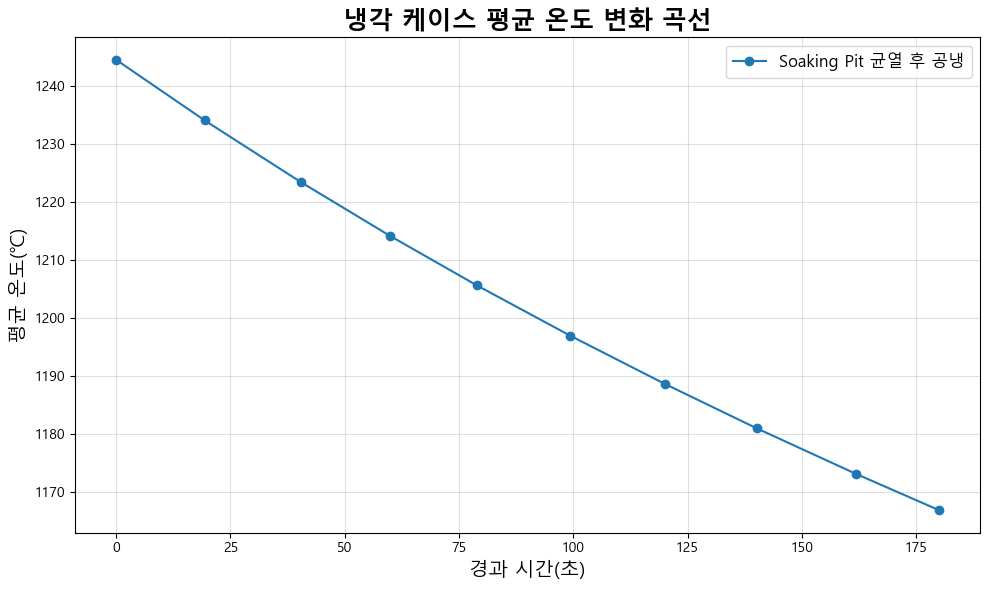


[냉각 케이스별 평균 온도 변화 테이블]
               Case 경과 시간(초)   평균 온도
                                    
Soaking Pit 균열 후 공냉     0.00 1244.44
Soaking Pit 균열 후 공냉    19.32 1234.04
Soaking Pit 균열 후 공냉    40.48 1223.36
Soaking Pit 균열 후 공냉    60.00 1214.10
Soaking Pit 균열 후 공냉    78.88 1205.64
Soaking Pit 균열 후 공냉    99.38 1196.95
Soaking Pit 균열 후 공냉   120.00 1188.69
Soaking Pit 균열 후 공냉   140.14 1181.03
Soaking Pit 균열 후 공냉   161.95 1173.16
Soaking Pit 균열 후 공냉   180.00 1166.96


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ====== 파라미터 ======
excel_file_path = "250718_가열로 시뮬레이션 results4_가공.xlsx"
cooling_case_sheets = ["Case 19 냉각"]  # 실제 엑셀의 시트명
cooling_case_name_map = {
    "Case 19 냉각": "Soaking Pit 균열 후 공냉"  # 원하는 출력명으로!
}
cooling_duration = 180

def extract_cooling_curve_multicol(df, sheet_name, output_case_name, start_time, duration):
    try:
        time_col = [col for col in df.columns if str(col[0]).strip().lower() == 'time' or str(col[1]).strip().lower() == 'time']
        if not time_col:
            print(f"{sheet_name}: Time 컬럼 없음 (컬럼: {list(df.columns)})")
            return None
        time_col = time_col[0]

        df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
        cooling_df = df[(df[time_col] >= start_time) & (df[time_col] <= start_time + duration)].copy()
        if cooling_df.empty:
            print(f"{sheet_name}: 지정 구간에 데이터 없음")
            return None

        cooling_df['경과 시간(초)'] = cooling_df[time_col] - start_time

        sensor_keyword_list = ['sensor', '도어', '중앙', '내측']
        sensor_cols = [
            col for col in df.columns
            if (
                str(col[0]).strip() not in ['Time', '', None] and
                any(kw in str(col[1]) for kw in sensor_keyword_list)
            )
        ]
        if not sensor_cols:
            print(f"{sheet_name}: 센서 컬럼 없음 (컬럼: {list(df.columns)})")
            return None

        cooling_df['평균 온도'] = cooling_df[sensor_cols].mean(axis=1)

        sampled_times = np.arange(0, duration + 1, 20)
        resampled_data = []
        for t in sampled_times:
            idx = (cooling_df['경과 시간(초)'] - t).abs().idxmin()
            resampled_data.append(cooling_df.iloc[idx])

        result_df = pd.DataFrame(resampled_data)[['경과 시간(초)', '평균 온도']]
        result_df['Case'] = output_case_name  # 출력용 이름 사용!
        return result_df

    except Exception as e:
        print(f"{sheet_name} 추출 오류: {e}")
        return None

# ====== 데이터 추출 및 결과 표시 ======
cooling_curve_all = []
if os.path.exists(excel_file_path):
    for sheet in cooling_case_sheets:
        output_name = cooling_case_name_map.get(sheet, sheet)
        try:
            df = pd.read_excel(excel_file_path, sheet_name=sheet, engine='openpyxl', header=[0,1])
            curve = extract_cooling_curve_multicol(df, sheet, output_name, 0, cooling_duration)
            if curve is not None:
                cooling_curve_all.append(curve)
        except Exception as e:
            print(f"{sheet} 로딩 오류: {e}")
else:
    print(f"오류: 엑셀 파일을 찾을 수 없습니다 - {excel_file_path}")

# ====== 결과 시각화 및 테이블 출력 ======
if cooling_curve_all:
    print("\n" + "="*50 + "\n[냉각 완료 케이스 분석]\n" + "="*50)
    cooling_curve_df = pd.concat(cooling_curve_all, ignore_index=True)

    # ==== 1. 그래프 ====
    plt.figure(figsize=(10,6))
    for case in cooling_curve_df['Case'].unique():
        sub = cooling_curve_df[cooling_curve_df['Case'] == case]
        plt.plot(sub['경과 시간(초)'], sub['평균 온도'], marker='o', label=case)
    plt.xlabel('경과 시간(초)', fontsize=14)
    plt.ylabel('평균 온도(℃)', fontsize=14)
    plt.title('냉각 케이스 평균 온도 변화 곡선', fontsize=18, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ==== 2. 결과 테이블 ====
    print("\n[냉각 케이스별 평균 온도 변화 테이블]")
    display_cols = ['Case', '경과 시간(초)', '평균 온도']
    print(cooling_curve_df[display_cols].to_string(index=False, float_format='{:.2f}'.format))

else:
    print("\n" + "="*50 + "\n[냉각 완료 케이스 분석]\n" + "="*50)
    print("분석 대상에 냉각 케이스가 없거나 데이터 추출에 실패했습니다.")



[냉각 완료 케이스 분석]


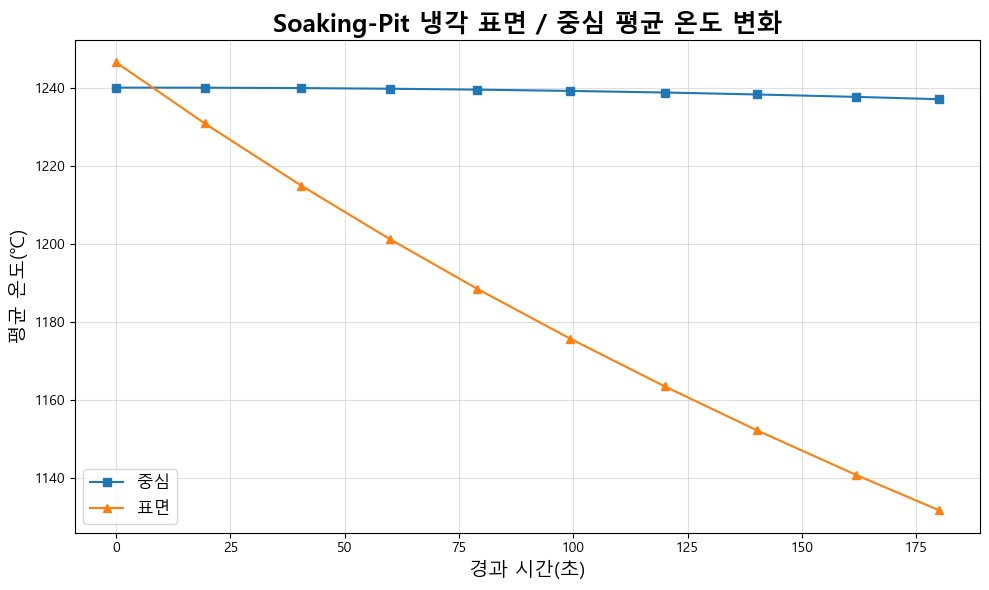


[센서 그룹별 평균 온도 변화 테이블 (일부 샘플)]
          Case 경과 시간(초) 평균 온도 (2,5,8) 평균 온도 (나머지)
                                                 
Soaking-Pit 냉각     0.00       1240.14     1246.59
Soaking-Pit 냉각    19.32       1240.12     1231.00
Soaking-Pit 냉각    40.48       1240.02     1215.03
Soaking-Pit 냉각    60.00       1239.85     1201.23
Soaking-Pit 냉각    78.88       1239.62     1188.65
Soaking-Pit 냉각    99.38       1239.30     1175.78
Soaking-Pit 냉각   120.00       1238.88     1163.59
Soaking-Pit 냉각   140.14       1238.39     1152.35
Soaking-Pit 냉각   161.95       1237.77     1140.86
Soaking-Pit 냉각   180.00       1237.17     1131.85


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 파라미터 ---
excel_file_path = "250718_가열로 시뮬레이션 results4_가공.xlsx"
cooling_case_sheets = ["Case 19 냉각"]
cooling_case_name_map = {"Case 19 냉각": "Soaking-Pit 냉각"}
cooling_duration = 180

def extract_cooling_curve_multicol(df, sheet_name, output_case_name, start_time, duration):
    try:
        time_col = [col for col in df.columns if str(col[0]).strip().lower() == 'time' or str(col[1]).strip().lower() == 'time']
        if not time_col:
            print(f"{sheet_name}: Time 컬럼 없음 (컬럼: {list(df.columns)})")
            return None
        time_col = time_col[0]
        df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
        cooling_df = df[(df[time_col] >= start_time) & (df[time_col] <= start_time + duration)].copy()
        if cooling_df.empty:
            print(f"{sheet_name}: 지정 구간에 데이터 없음")
            return None
        cooling_df['경과 시간(초)'] = cooling_df[time_col] - start_time

        # 센서 컬럼 추출
        sensor_keyword_list = ['sensor', '도어', '중앙', '내측']
        sensor_cols = [
            col for col in df.columns
            if (
                str(col[0]).strip() not in ['Time', '', None] and
                any(kw in str(col[1]) for kw in sensor_keyword_list)
            )
        ]
        if not sensor_cols:
            print(f"{sheet_name}: 센서 컬럼 없음 (컬럼: {list(df.columns)})")
            return None

        # Sensor 2,5,8 컬럼
        s258_cols = [col for col in sensor_cols if any(f'sensor {i}' in str(col[1]).lower() for i in [2,5,8])]
        # 나머지 센서
        rest_cols = [col for col in sensor_cols if col not in s258_cols]

        cooling_df['평균 온도 (2,5,8)'] = cooling_df[s258_cols].mean(axis=1) if s258_cols else np.nan
        cooling_df['평균 온도 (나머지)'] = cooling_df[rest_cols].mean(axis=1) if rest_cols else np.nan

        # 20초 단위 샘플링
        sampled_times = np.arange(0, duration + 1, 20)
        resampled_data = []
        for t in sampled_times:
            idx = (cooling_df['경과 시간(초)'] - t).abs().idxmin()
            resampled_data.append(cooling_df.iloc[idx])

        result_df = pd.DataFrame(resampled_data)[['경과 시간(초)', '평균 온도 (2,5,8)', '평균 온도 (나머지)']]
        result_df['Case'] = output_case_name
        return result_df

    except Exception as e:
        print(f"{sheet_name} 추출 오류: {e}")
        return None

# --- 데이터 추출 및 결과 표시 ---
cooling_curve_all = []
if os.path.exists(excel_file_path):
    for sheet in cooling_case_sheets:
        output_name = cooling_case_name_map.get(sheet, sheet)
        try:
            df = pd.read_excel(excel_file_path, sheet_name=sheet, engine='openpyxl', header=[0,1])
            curve = extract_cooling_curve_multicol(df, sheet, output_name, 0, cooling_duration)
            if curve is not None:
                cooling_curve_all.append(curve)
        except Exception as e:
            print(f"{sheet} 로딩 오류: {e}")
else:
    print(f"오류: 엑셀 파일을 찾을 수 없습니다 - {excel_file_path}")

# --- 결과 시각화 및 테이블 출력 ---
if cooling_curve_all:
    print("\n" + "="*50 + "\n[냉각 완료 케이스 분석]\n" + "="*50)
    cooling_curve_df = pd.concat(cooling_curve_all, ignore_index=True)
    case_name = cooling_curve_df['Case'].iloc[0]

    # ==== 1. 그래프 (2개 곡선만) ====
    plt.figure(figsize=(10,6))
    plt.plot(cooling_curve_df['경과 시간(초)'], cooling_curve_df['평균 온도 (2,5,8)'], marker='s', label="중심")
    plt.plot(cooling_curve_df['경과 시간(초)'], cooling_curve_df['평균 온도 (나머지)'], marker='^', label="표면")
    plt.xlabel('경과 시간(초)', fontsize=14)
    plt.ylabel('평균 온도(℃)', fontsize=14)
    plt.title(f'{case_name} 표면 / 중심 평균 온도 변화', fontsize=18, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ==== 2. 결과 테이블 ====
    print("\n[센서 그룹별 평균 온도 변화 테이블 (일부 샘플)]")
    display_cols = ['Case', '경과 시간(초)', '평균 온도 (2,5,8)', '평균 온도 (나머지)']
    print(cooling_curve_df[display_cols].to_string(index=False, float_format='{:.2f}'.format))
else:
    print("\n" + "="*50 + "\n[냉각 완료 케이스 분석]\n" + "="*50)
    print("분석 대상에 냉각 케이스가 없거나 데이터 추출에 실패했습니다.")



[냉각 완료 케이스 분석]


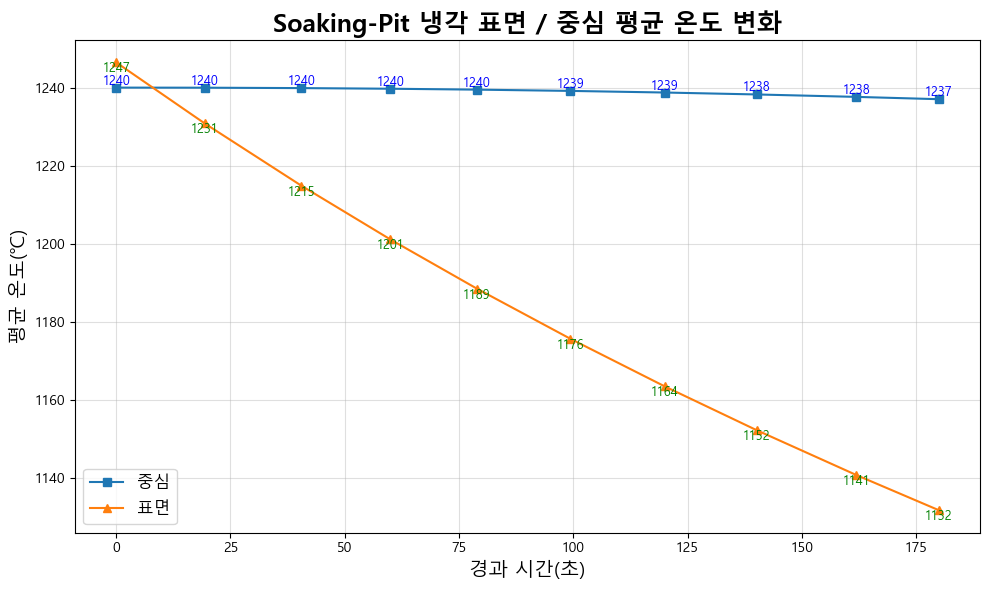


[센서 그룹별 평균 온도 변화 테이블 (일부 샘플)]
          Case 경과 시간(초) 평균 온도 (2,5,8) 평균 온도 (나머지)
                                                 
Soaking-Pit 냉각     0.00       1240.14     1246.59
Soaking-Pit 냉각    19.32       1240.12     1231.00
Soaking-Pit 냉각    40.48       1240.02     1215.03
Soaking-Pit 냉각    60.00       1239.85     1201.23
Soaking-Pit 냉각    78.88       1239.62     1188.65
Soaking-Pit 냉각    99.38       1239.30     1175.78
Soaking-Pit 냉각   120.00       1238.88     1163.59
Soaking-Pit 냉각   140.14       1238.39     1152.35
Soaking-Pit 냉각   161.95       1237.77     1140.86
Soaking-Pit 냉각   180.00       1237.17     1131.85


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 파라미터 ---
excel_file_path = "250718_가열로 시뮬레이션 results4_가공.xlsx"
cooling_case_sheets = ["Case 19 냉각"]
cooling_case_name_map = {"Case 19 냉각": "Soaking-Pit 냉각"}
cooling_duration = 180

def extract_cooling_curve_multicol(df, sheet_name, output_case_name, start_time, duration):
    try:
        time_col = [col for col in df.columns if str(col[0]).strip().lower() == 'time' or str(col[1]).strip().lower() == 'time']
        if not time_col:
            print(f"{sheet_name}: Time 컬럼 없음 (컬럼: {list(df.columns)})")
            return None
        time_col = time_col[0]
        df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
        cooling_df = df[(df[time_col] >= start_time) & (df[time_col] <= start_time + duration)].copy()
        if cooling_df.empty:
            print(f"{sheet_name}: 지정 구간에 데이터 없음")
            return None
        cooling_df['경과 시간(초)'] = cooling_df[time_col] - start_time

        # 센서 컬럼 추출 (sensor, 도어, 중앙, 내측 모두 허용)
        sensor_keyword_list = ['sensor', '도어', '중앙', '내측']
        sensor_cols = [
            col for col in df.columns
            if (
                str(col[0]).strip() not in ['Time', '', None] and
                any(kw in str(col[1]) for kw in sensor_keyword_list)
            )
        ]
        if not sensor_cols:
            print(f"{sheet_name}: 센서 컬럼 없음 (컬럼: {list(df.columns)})")
            return None

        # Sensor 2,5,8 컬럼과 나머지 센서 분리
        s258_cols = [col for col in sensor_cols if any(f'sensor {i}' in str(col[1]).lower() for i in [2,5,8])]
        rest_cols = [col for col in sensor_cols if col not in s258_cols]

        # 평균 온도 계산 (실수 그대로, 그래프 출력 시만 반올림)
        cooling_df['평균 온도 (2,5,8)'] = cooling_df[s258_cols].mean(axis=1) if s258_cols else np.nan
        cooling_df['평균 온도 (나머지)'] = cooling_df[rest_cols].mean(axis=1) if rest_cols else np.nan

        # 20초 단위 샘플링
        sampled_times = np.arange(0, duration + 1, 20)
        resampled_data = []
        for t in sampled_times:
            idx = (cooling_df['경과 시간(초)'] - t).abs().idxmin()
            resampled_data.append(cooling_df.iloc[idx])

        result_df = pd.DataFrame(resampled_data)[['경과 시간(초)', '평균 온도 (2,5,8)', '평균 온도 (나머지)']]
        result_df['Case'] = output_case_name
        return result_df

    except Exception as e:
        print(f"{sheet_name} 추출 오류: {e}")
        return None

# --- 데이터 추출 및 결과 표시 ---
cooling_curve_all = []
if os.path.exists(excel_file_path):
    for sheet in cooling_case_sheets:
        output_name = cooling_case_name_map.get(sheet, sheet)
        try:
            df = pd.read_excel(excel_file_path, sheet_name=sheet, engine='openpyxl', header=[0,1])
            curve = extract_cooling_curve_multicol(df, sheet, output_name, 0, cooling_duration)
            if curve is not None:
                cooling_curve_all.append(curve)
        except Exception as e:
            print(f"{sheet} 로딩 오류: {e}")
else:
    print(f"오류: 엑셀 파일을 찾을 수 없습니다 - {excel_file_path}")

# --- 결과 시각화 및 테이블 출력 ---
if cooling_curve_all:
    print("\n" + "="*50 + "\n[냉각 완료 케이스 분석]\n" + "="*50)
    cooling_curve_df = pd.concat(cooling_curve_all, ignore_index=True)
    case_name = cooling_curve_df['Case'].iloc[0]

    # ==== 1. 그래프 (2개 곡선, 값은 마커 위에 정수로 표기) ====
    plt.figure(figsize=(10,6))
    x = cooling_curve_df['경과 시간(초)']

    y1 = cooling_curve_df['평균 온도 (2,5,8)']
    y2 = cooling_curve_df['평균 온도 (나머지)']

    plt.plot(x, y1, marker='s', label="중심")
    plt.plot(x, y2, marker='^', label="표면")

    # --- 정수값 마커 위에 표시 ---
    for xi, yi in zip(x, y1):
        if not np.isnan(yi):
            plt.text(xi, yi, str(int(round(yi))), ha='center', va='bottom', fontsize=9, color='blue')
    for xi, yi in zip(x, y2):
        if not np.isnan(yi):
            plt.text(xi, yi, str(int(round(yi))), ha='center', va='top', fontsize=9, color='green')

    plt.xlabel('경과 시간(초)', fontsize=14)
    plt.ylabel('평균 온도(℃)', fontsize=14)
    plt.title(f'{case_name} 표면 / 중심 평균 온도 변화', fontsize=18, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ==== 2. 결과 테이블 ====
    print("\n[센서 그룹별 평균 온도 변화 테이블 (일부 샘플)]")
    display_cols = ['Case', '경과 시간(초)', '평균 온도 (2,5,8)', '평균 온도 (나머지)']
    print(cooling_curve_df[display_cols].to_string(index=False, float_format='{:.2f}'.format))
else:
    print("\n" + "="*50 + "\n[냉각 완료 케이스 분석]\n" + "="*50)
    print("분석 대상에 냉각 케이스가 없거나 데이터 추출에 실패했습니다.")


In [12]:
# =====================================================================
# [Case 19] 소재별(1~12) 센서 위치별 하부/중단/상부 평균값 집계 (+시점 선택)
# =====================================================================

# 1. 분석할 시점(예: '가열완료 시점', '4hr 시점') 선택
target_time_desc = '가열완료 시점'   # 원하는 시점으로 변경하세요!

# 2. Case 19 & 시점 필터링
case19_df = bloom_sensor_df[
    (bloom_sensor_df['Case'] == 'Case 19') &
    (bloom_sensor_df['TimeDesc'] == target_time_desc)
].copy()

# 3. 센서 그룹핑 함수 (센서 컬럼이 숫자형이 아닐 경우 int 변환)
def sensor_group(sensor):
    if sensor in [1, 2, 3]:
        return '하부'
    elif sensor in [4, 5, 6]:
        return '중단'
    elif sensor in [7, 8, 9]:
        return '상부'
    else:
        return '기타'

case19_df['Sensor'] = case19_df['Sensor'].astype(int)
case19_df['위치'] = case19_df['Sensor'].apply(sensor_group)

# 4. 소재번호(Bloom)별, 위치별 평균값
pivot = (
    case19_df.groupby(['Bloom', '위치'])['Value']
    .mean()
    .unstack()   # '하부', '중단', '상부'가 컬럼
    .reindex(range(1, 13))  # Bloom 1~12 순서
    .round(1)    # 보기 좋게 소수점 1자리
)

print(f"Case 19번, 시점: {target_time_desc}, 소재별(1~12) 하부/중단/상부 평균값:")
print(pivot)


Case 19번, 시점: 가열완료 시점, 소재별(1~12) 하부/중단/상부 평균값:
위치         상부      중단      하부
Bloom                        
1      1272.4  1262.5  1258.6
2      1274.0  1261.7  1258.5
3      1274.2  1262.2  1259.7
4      1275.4  1263.6  1261.4
5      1276.7  1266.0  1263.4
6      1278.2  1269.8  1266.8
7      1272.4  1262.8  1256.0
8      1273.3  1261.9  1255.7
9      1275.0  1262.6  1256.9
10     1275.8  1264.3  1258.6
11     1277.0  1266.3  1260.6
12     1278.4  1270.0  1264.1



[각 케이스별, 소재별(1~12번) 내부 온도 편차 + 통계값 Table]



,1,2,3,4,5,6,7,8,9,10,11,12,count,mean,std,min,25%,50%,75%,max
Case,,,,,,,,,,,,,,,,,,,,
Case 1,27.81,33.21,44.91,45.27,34.31,31.90,24.11,31.47,37.50,37.47,31.44,23.58,12.0,33.58,6.95,23.58,30.53,32.55,37.48,45.27
Case 2*,36.66,39.03,48.26,47.83,38.89,36.12,NaN,NaN,NaN,NaN,NaN,NaN,6.0,41.13,5.48,36.12,37.22,38.96,45.63,48.26
Case 3,32.22,35.07,46.01,45.99,36.68,34.77,NaN,NaN,NaN,NaN,NaN,NaN,6.0,38.46,6.02,32.22,34.84,35.88,43.66,46.01
Case 4,10.66,14.86,16.33,16.27,14.63,10.32,15.61,21.67,24.09,23.69,20.56,13.64,12.0,16.86,4.66,10.32,14.38,15.94,20.84,24.09
Case 5,17.55,17.39,16.77,16.05,15.22,13.93,NaN,NaN,NaN,NaN,NaN,NaN,6.0,16.15,1.39,13.93,15.43,16.41,17.24,17.55
Case 6,27.02,32.32,43.74,43.91,33.05,30.43,23.36,32.21,37.27,37.17,31.98,21.82,12.0,32.86,6.96,21.82,29.58,32.26,37.19,43.91
Case 9,11.83,17.12,18.47,18.28,16.50,11.07,15.55,23.44,25.45,25.03,22.28,13.77,12.0,18.23,4.91,11.07,15.11,17.70,22.57,25.45
Case 10,18.63,18.52,17.76,16.89,15.92,14.43,NaN,NaN,NaN,NaN,NaN,NaN,6.0,17.03,1.63,14.43,16.16,17.33,18.33,18.63
Case 11 추가,15.13,22.28,37.48,39.30,28.08,20.90,11.99,21.81,30.31,33.24,30.01,24.09,12.0,26.22,8.39,11.99,21.58,26.09,31.04,39.30


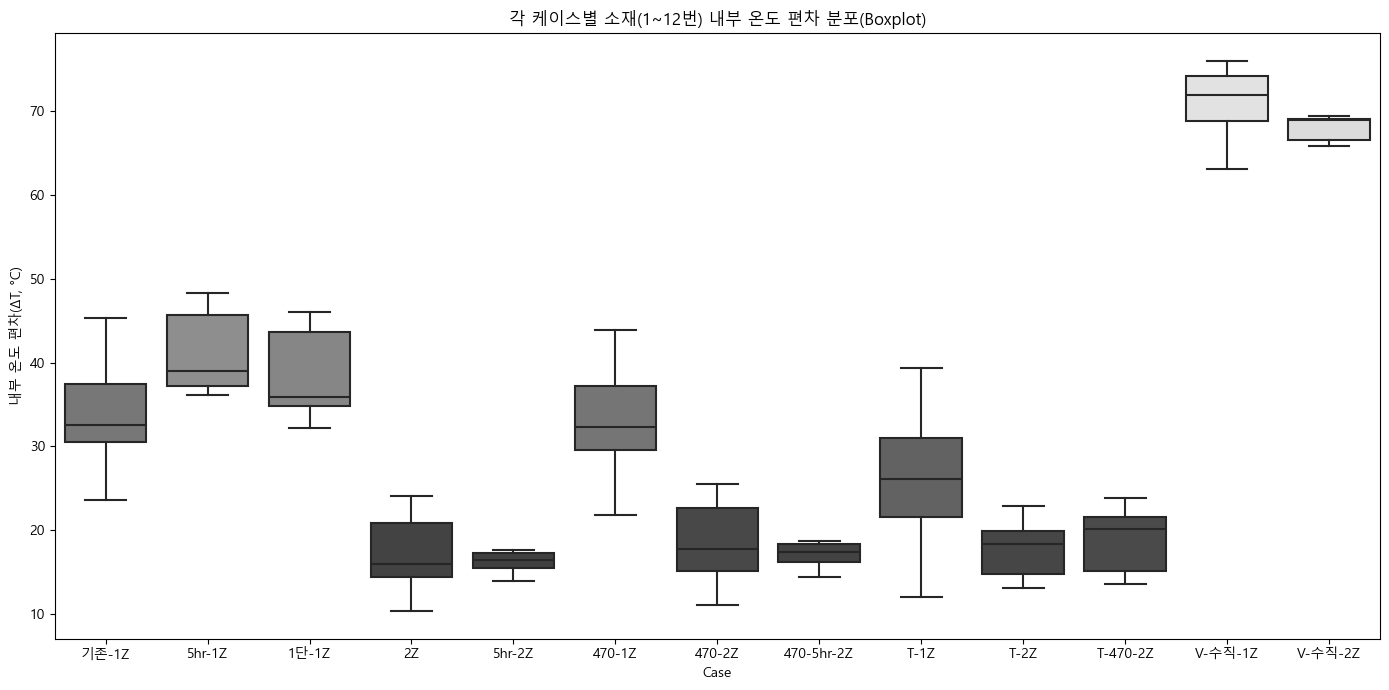

In [22]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# 0. 자연스러운 케이스 정렬 함수
def case_sort_key(s):
    m = re.match(r'([^\d]*)(\d+)(.*)', str(s))
    if m:
        prefix, num, suffix = m.groups()
        return (prefix, int(num), suffix)
    else:
        return (s, 0, '')

# 1. 분석 대상 Case/TimeDesc 조합 DataFrame 생성
target_case_time = pd.DataFrame([
    {"Case": case, "TimeDesc": time_desc}
    for case, time_desc in cases_and_times_to_compare.items()
])

# 2. heating_sensor_df에서 정확히 일치하는 Case/TimeDesc 조합만 필터링 (merge 활용)
df_filtered = pd.merge(
    heating_sensor_df,
    target_case_time,
    on=["Case", "TimeDesc"],
    how="inner"
)

# 3. 각 케이스별, 소재별(1~12) 내부 센서 온도 편차 테이블 집계
bloom_delta_t_table = (
    df_filtered[df_filtered['Bloom'].between(1, 12)]
    .groupby(['Case', 'Bloom'])['Value']
    .agg(lambda x: x.max() - x.min())
    .unstack()
    .round(2)
)

# 5. 케이스별 소재별 편차의 통계값(describe)
stats = (
    df_filtered[df_filtered['Bloom'].between(1, 12)]
    .groupby(['Case', 'Bloom'])['Value']
    .agg(lambda x: x.max() - x.min())
    .groupby('Case')
    .describe()
    .round(2)
)

# 6. Table+통계를 하나의 DataFrame으로 결합 (Case index 기준)
# 소재별 Bloom 컬럼+ 통계값 컬럼 concat
result_table = pd.concat([bloom_delta_t_table, stats], axis=1)

# 7. Case 오름차순 정렬 적용
sorted_case_idx = sorted(result_table.index, key=case_sort_key)
result_table = result_table.loc[sorted_case_idx]

# 8. 테이블 표로 출력 (Jupyter/Colab)
print("\n[각 케이스별, 소재별(1~12번) 내부 온도 편차 + 통계값 Table]\n")
display(result_table)

# 9. Boxplot용 long-form 변환
bloom_delta_t_long = (
    df_filtered[df_filtered['Bloom'].between(1, 12)]
    .groupby(['Case', 'Bloom'])['Value']
    .agg(lambda x: x.max() - x.min())
    .reset_index()
)

# 라벨 변경(선택)
if case_label_map:
    bloom_delta_t_long['Case'] = bloom_delta_t_long['Case'].replace(case_label_map)
    boxplot_order = [case_label_map.get(c, c) for c in sorted_case_idx]
else:
    boxplot_order = sorted_case_idx

# Case별 평균 편차에 따라 색상 배열 생성
case_means = [bloom_delta_t_long[bloom_delta_t_long['Case'] == case]['Value'].mean() for case in boxplot_order]
norm = plt.Normalize(min(case_means), max(case_means))
box_colors = [plt.cm.Greys(0.8 - 0.6 * norm(v)) for v in case_means]

plt.figure(figsize=(14, 7))
sns.boxplot(
    x='Case', y='Value', data=bloom_delta_t_long,
    order=boxplot_order,
    palette=box_colors
)
plt.title("각 케이스별 소재(1~12번) 내부 온도 편차 분포(Boxplot)")
plt.xlabel("Case")
plt.ylabel("내부 온도 편차(ΔT, °C)")
plt.tight_layout()
plt.show()



[각 케이스별, 소재별(1~12번) 내부 온도 편차 + 통계값 Table]



,1,2,3,4,5,6,7,8,9,10,11,12,count,mean,std,min,25%,50%,75%,max
Case,,,,,,,,,,,,,,,,,,,,
Case 1,27.81,33.21,44.91,45.27,34.31,31.90,24.11,31.47,37.50,37.47,31.44,23.58,12.0,33.58,6.95,23.58,30.53,32.55,37.48,45.27
Case 2*,36.66,39.03,48.26,47.83,38.89,36.12,NaN,NaN,NaN,NaN,NaN,NaN,6.0,41.13,5.48,36.12,37.22,38.96,45.63,48.26
Case 3,32.22,35.07,46.01,45.99,36.68,34.77,NaN,NaN,NaN,NaN,NaN,NaN,6.0,38.46,6.02,32.22,34.84,35.88,43.66,46.01
Case 4,10.66,14.86,16.33,16.27,14.63,10.32,15.61,21.67,24.09,23.69,20.56,13.64,12.0,16.86,4.66,10.32,14.38,15.94,20.84,24.09
Case 5,17.55,17.39,16.77,16.05,15.22,13.93,NaN,NaN,NaN,NaN,NaN,NaN,6.0,16.15,1.39,13.93,15.43,16.41,17.24,17.55
Case 6,27.02,32.32,43.74,43.91,33.05,30.43,23.36,32.21,37.27,37.17,31.98,21.82,12.0,32.86,6.96,21.82,29.58,32.26,37.19,43.91
Case 9,11.83,17.12,18.47,18.28,16.50,11.07,15.55,23.44,25.45,25.03,22.28,13.77,12.0,18.23,4.91,11.07,15.11,17.70,22.57,25.45
Case 10,18.63,18.52,17.76,16.89,15.92,14.43,NaN,NaN,NaN,NaN,NaN,NaN,6.0,17.03,1.63,14.43,16.16,17.33,18.33,18.63
Case 11 추가,15.13,22.28,37.48,39.30,28.08,20.90,11.99,21.81,30.31,33.24,30.01,24.09,12.0,26.22,8.39,11.99,21.58,26.09,31.04,39.30


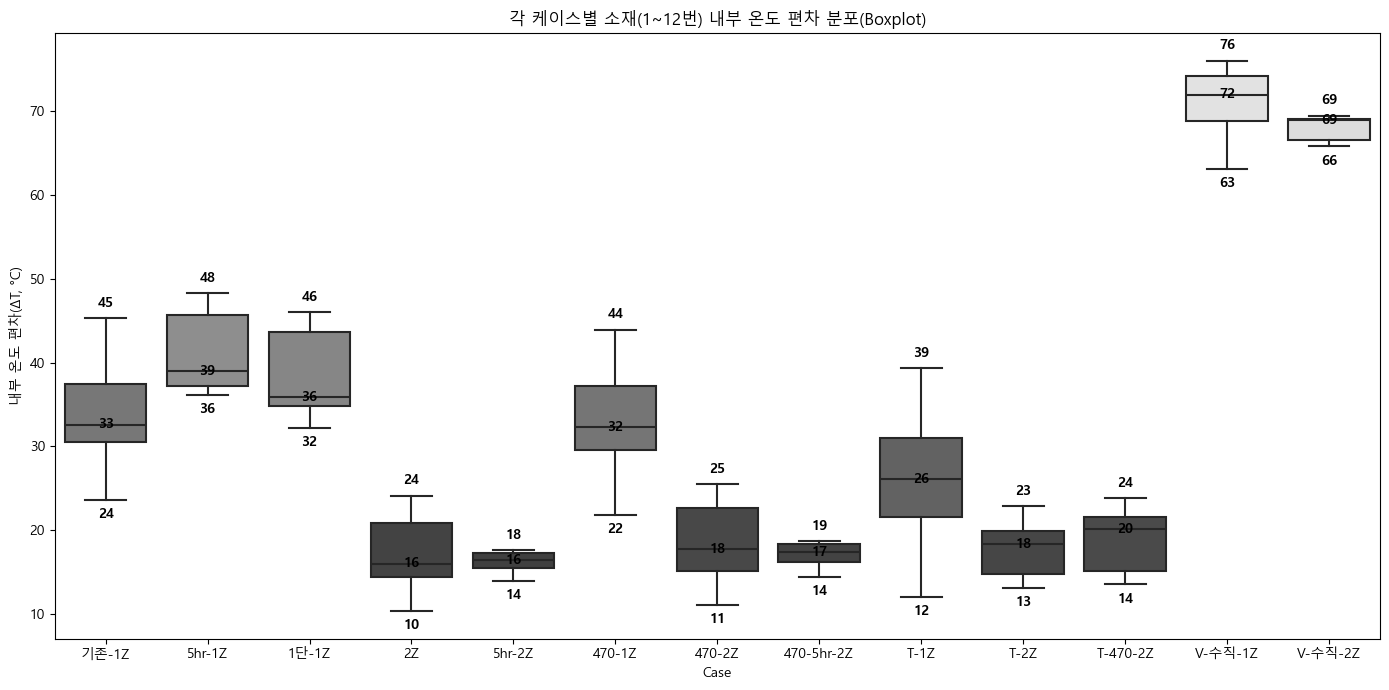

In [40]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

# 0. 자연스러운 케이스 정렬 함수
def case_sort_key(s):
    m = re.match(r'([^\d]*)(\d+)(.*)', str(s))
    if m:
        prefix, num, suffix = m.groups()
        return (prefix, int(num), suffix)
    else:
        return (s, 0, '')

# 1. 분석 대상 Case/TimeDesc 조합 DataFrame 생성
target_case_time = pd.DataFrame([
    {"Case": case, "TimeDesc": time_desc}
    for case, time_desc in cases_and_times_to_compare.items()
])

# 2. heating_sensor_df에서 정확히 일치하는 Case/TimeDesc 조합만 필터링 (merge 활용)
df_filtered = pd.merge(
    heating_sensor_df,
    target_case_time,
    on=["Case", "TimeDesc"],
    how="inner"
)

# 3. 각 케이스별, 소재별(1~12) 내부 센서 온도 편차 테이블 집계
bloom_delta_t_table = (
    df_filtered[df_filtered['Bloom'].between(1, 12)]
    .groupby(['Case', 'Bloom'])['Value']
    .agg(lambda x: x.max() - x.min())
    .unstack()
    .round(2)
)

# 4. 케이스별 소재별 편차의 통계값(describe)
stats = (
    df_filtered[df_filtered['Bloom'].between(1, 12)]
    .groupby(['Case', 'Bloom'])['Value']
    .agg(lambda x: x.max() - x.min())
    .groupby('Case')
    .describe()
    .round(2)
)

# 5. Table+통계를 하나의 DataFrame으로 결합 (Case index 기준)
result_table = pd.concat([bloom_delta_t_table, stats], axis=1)

# 6. Case 오름차순 정렬 적용
sorted_case_idx = sorted(result_table.index, key=case_sort_key)
result_table = result_table.loc[sorted_case_idx]

# 7. 테이블 표로 출력 (Jupyter/Colab)
print("\n[각 케이스별, 소재별(1~12번) 내부 온도 편차 + 통계값 Table]\n")
display(result_table)

# 8. Boxplot용 long-form 변환
bloom_delta_t_long = (
    df_filtered[df_filtered['Bloom'].between(1, 12)]
    .groupby(['Case', 'Bloom'])['Value']
    .agg(lambda x: x.max() - x.min())
    .reset_index()
)

# 라벨 변경(선택)
if case_label_map:
    bloom_delta_t_long['Case'] = bloom_delta_t_long['Case'].replace(case_label_map)
    boxplot_order = [case_label_map.get(c, c) for c in sorted_case_idx]
else:
    boxplot_order = sorted_case_idx

# Case별 평균 편차에 따라 색상 배열 생성
case_means = [bloom_delta_t_long[bloom_delta_t_long['Case'] == case]['Value'].mean() for case in boxplot_order]
norm = plt.Normalize(min(case_means), max(case_means))
box_colors = [plt.cm.Greys(0.8 - 0.6 * norm(v)) for v in case_means]

plt.figure(figsize=(14, 7))
ax = sns.boxplot(
    x='Case', y='Value', data=bloom_delta_t_long,
    order=boxplot_order,
    palette=box_colors
)
plt.title("각 케이스별 소재(1~12번) 내부 온도 편차 분포(Boxplot)")
plt.xlabel("Case")
plt.ylabel("내부 온도 편차(ΔT, °C)")

# ====== 박스플롯 최대/최소/중앙값 숫자만 표기(검정색) ======
for i, case in enumerate(boxplot_order):
    vals = bloom_delta_t_long[bloom_delta_t_long['Case'] == case]['Value'].dropna().values
    if len(vals) == 0:
        continue
    min_val = vals.min()
    max_val = vals.max()
    median_val = np.median(vals)
    # 최댓값: 박스 위
    ax.text(i, max_val + 1, f"{max_val:.0f}", ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')
    # 중앙값: 박스 중앙
    ax.text(i, median_val, f"{median_val:.0f}", ha='center', va='center', fontsize=10, color='black', fontweight='bold')
    # 최솟값: 박스 아래
    ax.text(i, min_val - 1, f"{min_val:.0f}", ha='center', va='top', fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.show()



[각 케이스별, 소재별(1~12번) 온도값 + 통계값 Table]



,1,2,3,4,5,6,7,8,9,10,11,12,count,mean,std,min,25%,50%,75%,max
Case,,,,,,,,,,,,,,,,,,,,
Case 1,1244.13,1239.26,1236.65,1238.02,1243.23,1250.34,1254.01,1252.18,1252.02,1253.66,1256.84,1260.92,12.0,1248.44,7.93,1236.65,1242.24,1251.18,1253.75,1260.92
Case 2*,1243.39,1242.49,1241.63,1243.57,1248.12,1252.17,NaN,NaN,NaN,NaN,NaN,NaN,6.0,1245.23,4.08,1241.63,1242.71,1243.48,1246.99,1252.17
Case 3,1250.60,1249.55,1248.49,1249.87,1253.51,1256.65,NaN,NaN,NaN,NaN,NaN,NaN,6.0,1251.44,3.06,1248.49,1249.63,1250.23,1252.78,1256.65
Case 4,1255.97,1254.56,1255.38,1257.04,1259.45,1263.91,1264.00,1262.92,1263.39,1264.62,1266.53,1269.93,12.0,1261.47,4.90,1254.56,1256.77,1263.15,1264.16,1269.93
Case 5,1258.65,1260.62,1262.40,1264.08,1265.60,1266.84,NaN,NaN,NaN,NaN,NaN,NaN,6.0,1263.03,3.09,1258.65,1261.07,1263.24,1265.22,1266.84
Case 6,1246.47,1241.94,1239.90,1241.37,1246.28,1253.17,1254.89,1252.81,1252.87,1254.62,1257.85,1262.33,12.0,1250.37,7.08,1239.90,1245.19,1252.84,1254.69,1262.33
Case 9,1256.64,1254.88,1255.76,1257.46,1259.95,1264.74,1264.78,1263.27,1263.76,1264.99,1266.88,1270.63,12.0,1261.98,4.96,1254.88,1257.26,1263.51,1264.83,1270.63
Case 10,1259.29,1261.19,1263.02,1264.77,1266.38,1267.70,NaN,NaN,NaN,NaN,NaN,NaN,6.0,1263.73,3.18,1259.29,1261.65,1263.89,1265.98,1267.70
Case 11 추가,1259.86,1251.43,1241.12,1235.49,1234.93,1236.88,1266.87,1261.29,1255.86,1252.31,1250.96,1250.83,12.0,1249.82,10.62,1234.93,1240.06,1251.19,1256.86,1266.87


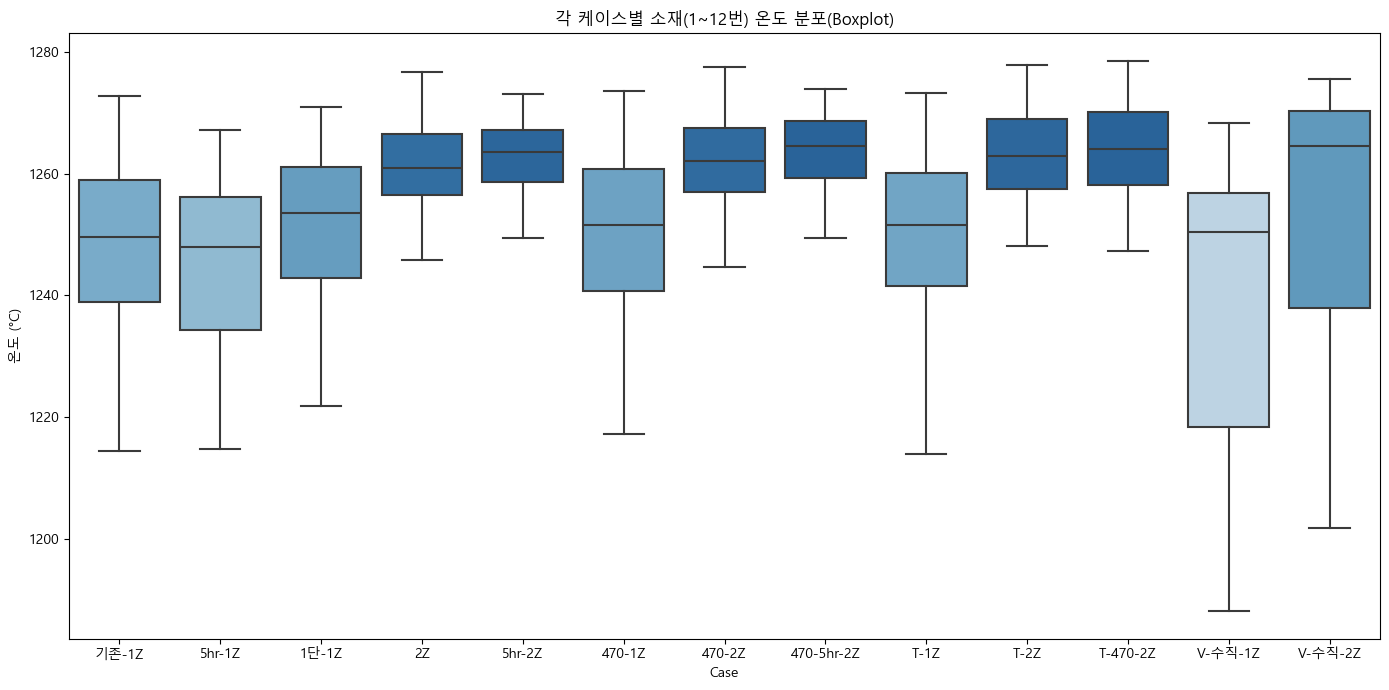

In [34]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 0. 자연스러운 케이스 정렬 함수
def case_sort_key(s):
    m = re.match(r'([^\d]*)(\d+)(.*)', str(s))
    if m:
        prefix, num, suffix = m.groups()
        return (prefix, int(num), suffix)
    else:
        return (s, 0, '')

# 1. 분석 대상 Case/TimeDesc 조합 DataFrame 생성
target_case_time = pd.DataFrame([
    {"Case": case, "TimeDesc": time_desc}
    for case, time_desc in cases_and_times_to_compare.items()
])

# 2. heating_sensor_df에서 정확히 일치하는 Case/TimeDesc 조합만 필터링 (merge 활용)
df_filtered = pd.merge(
    heating_sensor_df,
    target_case_time,
    on=["Case", "TimeDesc"],
    how="inner"
)

# 3. 각 케이스별, 소재별(1~12) 온도값 테이블 집계 (원본 Case명)
temperature_table = (
    df_filtered[df_filtered['Bloom'].between(1, 12)]
    .groupby(['Case', 'Bloom'])['Value']
    .mean()
    .unstack()
    .round(2)
)

# 4. 케이스별 소재별 온도의 통계값(describe) (원본 Case명)
stats = (
    df_filtered[df_filtered['Bloom'].between(1, 12)]
    .groupby(['Case', 'Bloom'])['Value']
    .mean()
    .groupby('Case')
    .describe()
    .round(2)
)

# 5. Table+통계를 하나의 DataFrame으로 결합 (Case index 기준)
result_table = pd.concat([temperature_table, stats], axis=1)

# 6. Case 오름차순 정렬 적용
sorted_case_idx = sorted(result_table.index, key=case_sort_key)
result_table = result_table.loc[sorted_case_idx]

# 7. 테이블 표로 출력 (Jupyter/Colab)
print("\n[각 케이스별, 소재별(1~12번) 온도값 + 통계값 Table]\n")
display(result_table)

# 8. Boxplot용 long-form 변환 (온도값 자체로!)
temperature_long = (
    df_filtered[df_filtered['Bloom'].between(1, 12)]
    .loc[:, ['Case', 'Bloom', 'Value']]
    .copy()
)

# 9. 그래프의 X축만 변경된 케이스명으로!
if case_label_map:
    # 오름차순 정렬된 원본 Case 리스트 → 변경된 라벨 리스트로 변환
    boxplot_order = [case_label_map.get(c, c) for c in sorted_case_idx]
    # temperature_long에 그래프용 'CaseLabel' 컬럼 추가
    temperature_long['CaseLabel'] = temperature_long['Case'].map(case_label_map).fillna(temperature_long['Case'])
else:
    boxplot_order = sorted_case_idx
    temperature_long['CaseLabel'] = temperature_long['Case']

# Case별 평균 온도에 따라 색상 배열 생성 (CaseLabel 기준)
case_means = [temperature_long[temperature_long['CaseLabel'] == case]['Value'].mean() for case in boxplot_order]
norm = plt.Normalize(min(case_means), max(case_means))
box_colors = [plt.cm.Blues(0.3 + 0.5 * norm(v)) for v in case_means]

plt.figure(figsize=(14, 7))
sns.boxplot(
    x='CaseLabel', y='Value', data=temperature_long,
    order=boxplot_order,
    palette=box_colors
)
plt.title("각 케이스별 소재(1~12번) 온도 분포(Boxplot)")
plt.xlabel("Case")
plt.ylabel("온도 (°C)")
plt.tight_layout()
plt.show()



[시간별 전체 Bloom 센서 온도 통계 Table + Max-Min]



,Hour,count,mean,std,min,25%,50%,75%,max,calc_min,calc_max,MaxMin_Diff
0,13,54.0,1257.06,7.13,1241.15,1253.17,1258.65,1261.57,1269.85,1241.15,1269.85,28.70
1,14,54.0,1260.13,5.42,1250.38,1255.78,1260.53,1264.20,1272.11,1250.38,1272.11,21.73
2,15,54.0,1261.45,5.23,1251.12,1257.65,1261.12,1265.09,1273.03,1251.12,1273.03,21.91
3,16,54.0,1261.85,5.47,1250.00,1257.84,1261.99,1265.91,1273.26,1250.00,1273.26,23.26


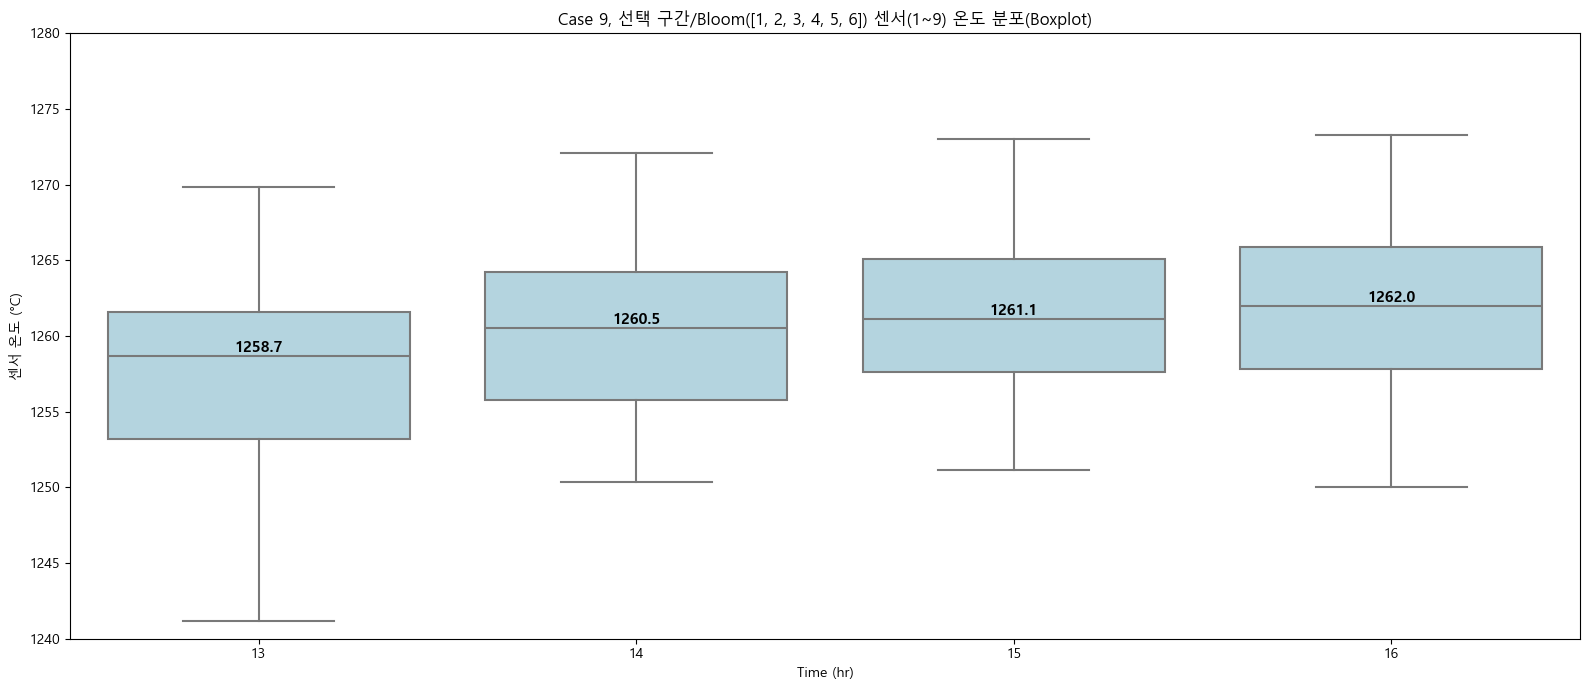

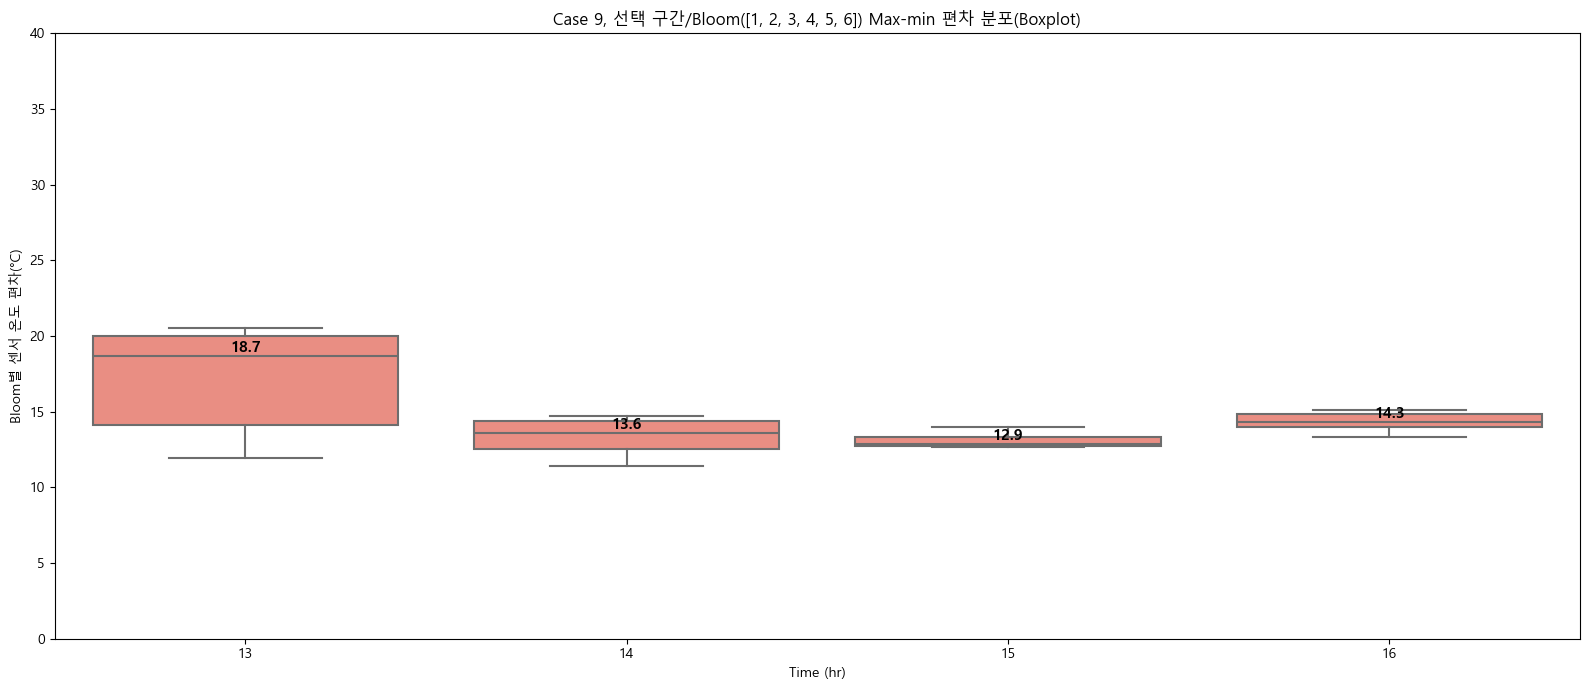


[시간별 전체 Bloom+센서 Max-Min 온도 차이 Table]



,Hour,MaxMin_Diff
0,13,28.70
1,14,21.73
2,15,21.91
3,16,23.26


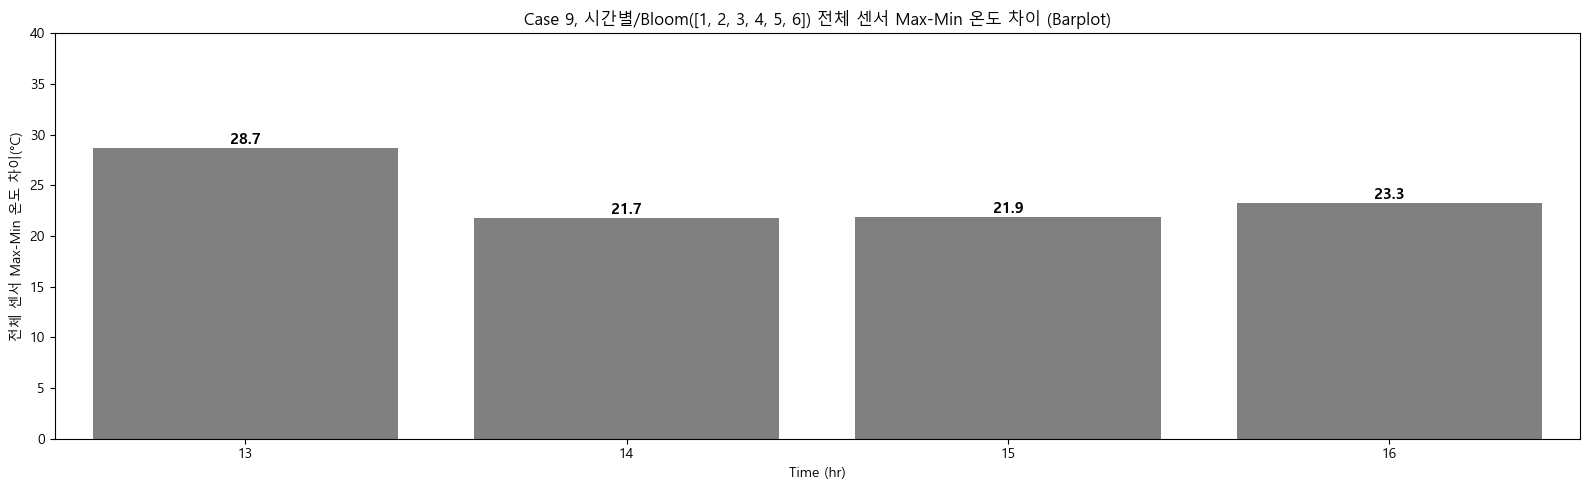

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# [1] 원본 데이터 로딩
excel_file_path = "250718_가열로 시뮬레이션 results4_가공.xlsx"
sheet_name = "Case 9"   # --- 케이스를 바꾸려면 여기만!
header_row = find_header_row(excel_file_path, sheet_name)
case_raw = pd.read_excel(excel_file_path, sheet_name=sheet_name, engine='openpyxl', header=header_row)

# [2] 시간(hr) 컬럼 생성
time_col = next((col for col in case_raw.columns if 'time' in str(col).lower()), None)
case_raw['Time_hr'] = case_raw[time_col] / 3600

# [3] Bloom 번호, 시간 구간 지정 (필요에 따라 수정)
bloom_list = list(range(1, 7))        # 예: [1,2,3,4,5,6]
intervals = [(13, 16)]                # 예: [(16, 21)]
y_range_temp = (1240, 1280)           # 온도 Boxplot Y축 범위
y_range_delta = (0, 40)               # Bloom별 편차 Boxplot Y축 범위
y_range_total = (0, 40)              # 전체 MaxMin Barplot Y축 범위

# [4] 데이터 구성
records = []
bloom_delta_records = []
for interval in intervals:
    start, end = interval
    for h in range(start, end + 1):
        idx = (case_raw['Time_hr'] - h).abs().idxmin()
        actual_hr = int(round(case_raw.loc[idx, 'Time_hr']))
        for bloom in bloom_list:
            sensor_vals = []
            for sensor in range(1, 10):
                col_name = f'Bloom {bloom} sensor {sensor}'
                if col_name in case_raw.columns:
                    value = case_raw.loc[idx, col_name]
                    records.append({'Hour': actual_hr, 'Bloom': bloom, 'Sensor': sensor, 'Value': value})
                    sensor_vals.append(value)
            if sensor_vals:
                delta = np.nanmax(sensor_vals) - np.nanmin(sensor_vals)
                bloom_delta_records.append({'Hour': actual_hr, 'Bloom': bloom, 'Delta': delta})

boxplot_df = pd.DataFrame(records)
bloom_delta_df = pd.DataFrame(bloom_delta_records)

# [5] 시간별 전체 센서 통계(describe) + max-min 값 (컬럼명 구분)
stat_table = (
    boxplot_df.groupby('Hour')['Value']
    .describe()
    .rename_axis('Hour')
    .round(2)
).reset_index()

# 별도 Max-Min(재계산) 컬럼 추가
calc_maxmin = (
    boxplot_df.groupby('Hour')['Value']
    .agg(calc_max='max', calc_min='min')
    .reset_index()
)
stat_table = pd.merge(stat_table, calc_maxmin, on='Hour')
stat_table['MaxMin_Diff'] = (stat_table['calc_max'] - stat_table['calc_min']).round(2)

print("\n[시간별 전체 Bloom 센서 온도 통계 Table + Max-Min]\n")
display(stat_table[['Hour', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'calc_min', 'calc_max', 'MaxMin_Diff']])

# [6] Boxplot: 시간별(Bloom 지정) 센서 온도 분포 (값 표기)
plt.figure(figsize=(16, 7))
ax = sns.boxplot(x='Hour', y='Value', data=boxplot_df, color='lightblue')
plt.title(f"{sheet_name}, 선택 구간/Bloom({bloom_list}) 센서(1~9) 온도 분포(Boxplot)")
plt.xlabel("Time (hr)")
plt.ylabel("센서 온도 (°C)")
plt.ylim(y_range_temp)
# --- 각 boxplot의 중앙값 표기 ---
medians = boxplot_df.groupby('Hour')['Value'].median().sort_index()
for i, median in enumerate(medians):
    plt.text(i, median, f"{median:.1f}", ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.tight_layout()
plt.show()

# [7] 시간별 Bloom별 Max-min 편차 분포(Boxplot) (값 표기)
plt.figure(figsize=(16, 7))
ax = sns.boxplot(x='Hour', y='Delta', data=bloom_delta_df, color='salmon')
plt.title(f"{sheet_name}, 선택 구간/Bloom({bloom_list}) Max-min 편차 분포(Boxplot)")
plt.xlabel("Time (hr)")
plt.ylabel("Bloom별 센서 온도 편차(°C)")
plt.ylim(y_range_delta)
# --- 중앙값 표기 ---
medians_delta = bloom_delta_df.groupby('Hour')['Delta'].median().sort_index()
for i, median in enumerate(medians_delta):
    plt.text(i, median, f"{median:.1f}", ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.tight_layout()
plt.show()

# [8] 시간별 전체 Bloom+센서에서 Max-Min 차이 계산 (Barplot, 값 표기)
hourly_maxmin = (
    boxplot_df.groupby('Hour')['Value']
    .agg(['max', 'min'])
    .reset_index()
)
hourly_maxmin['MaxMin_Diff'] = (hourly_maxmin['max'] - hourly_maxmin['min']).round(2)

print("\n[시간별 전체 Bloom+센서 Max-Min 온도 차이 Table]\n")
display(hourly_maxmin[['Hour', 'MaxMin_Diff']])

plt.figure(figsize=(16, 5))
ax = sns.barplot(x='Hour', y='MaxMin_Diff', data=hourly_maxmin, color='gray')
plt.title(f"{sheet_name}, 시간별/Bloom({bloom_list}) 전체 센서 Max-Min 온도 차이 (Barplot)")
plt.xlabel("Time (hr)")
plt.ylabel("전체 센서 Max-Min 온도 차이(°C)")
plt.ylim(y_range_total)
# --- 각 막대 위에 값 표기 ---
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"{val:.1f}", (p.get_x() + p.get_width() / 2., val), ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.tight_layout()
plt.show()



[시간별 전체 Bloom 센서 온도 통계 Table + Max-Min]



,Hour,count,mean,std,min,25%,50%,75%,max,calc_min,calc_max,MaxMin_Diff
0,16,54.0,1262.11,5.60,1249.92,1257.88,1262.38,1266.12,1273.45,1249.92,1273.45,23.53
1,17,54.0,1263.30,6.12,1249.30,1258.96,1264.09,1268.20,1273.84,1249.30,1273.84,24.54
2,18,54.0,1263.59,6.11,1249.34,1259.22,1264.28,1268.55,1273.86,1249.34,1273.86,24.52
3,19,54.0,1263.68,6.10,1249.36,1259.31,1264.51,1268.66,1273.87,1249.36,1273.87,24.51
4,20,54.0,1263.72,6.10,1249.36,1259.34,1264.58,1268.70,1273.87,1249.36,1273.87,24.51
5,21,54.0,1263.73,6.10,1249.36,1259.35,1264.60,1268.70,1273.87,1249.36,1273.87,24.51


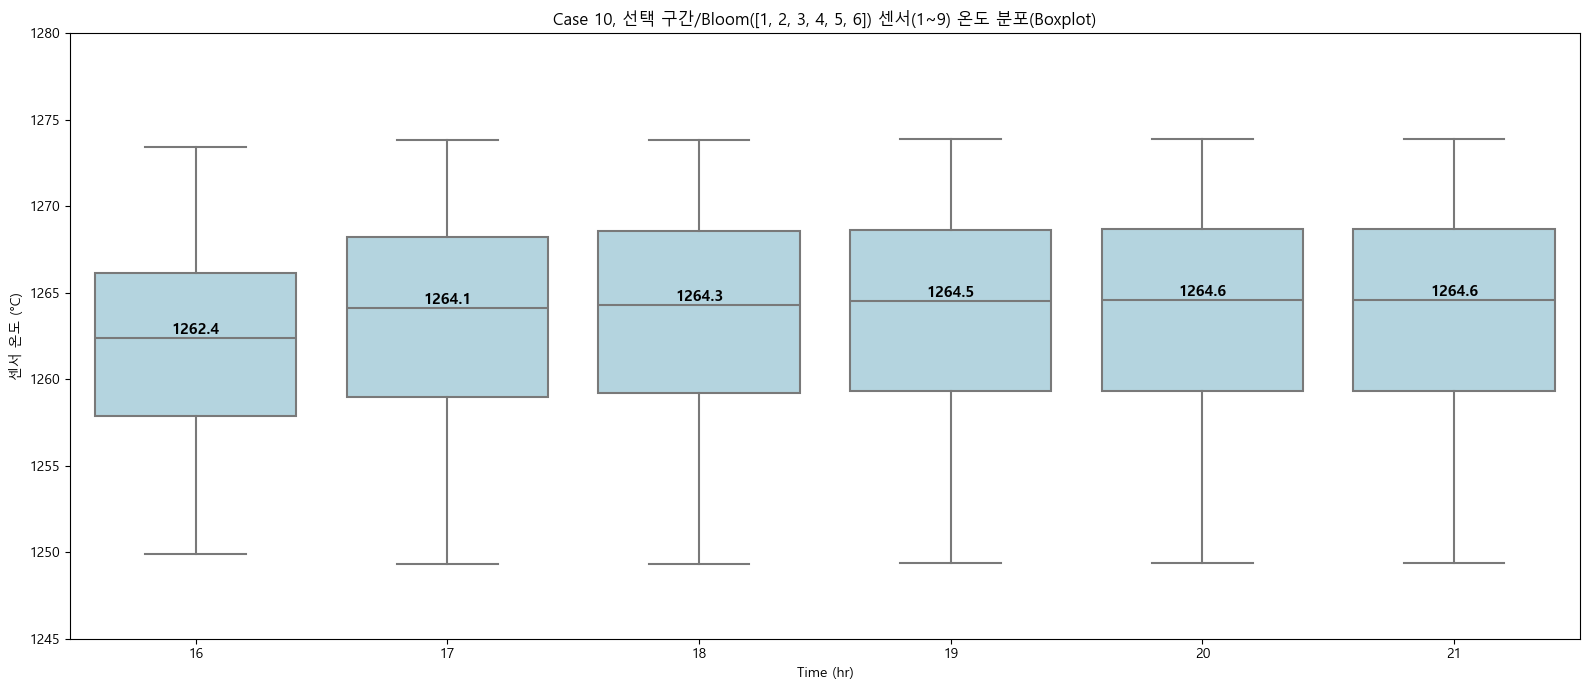

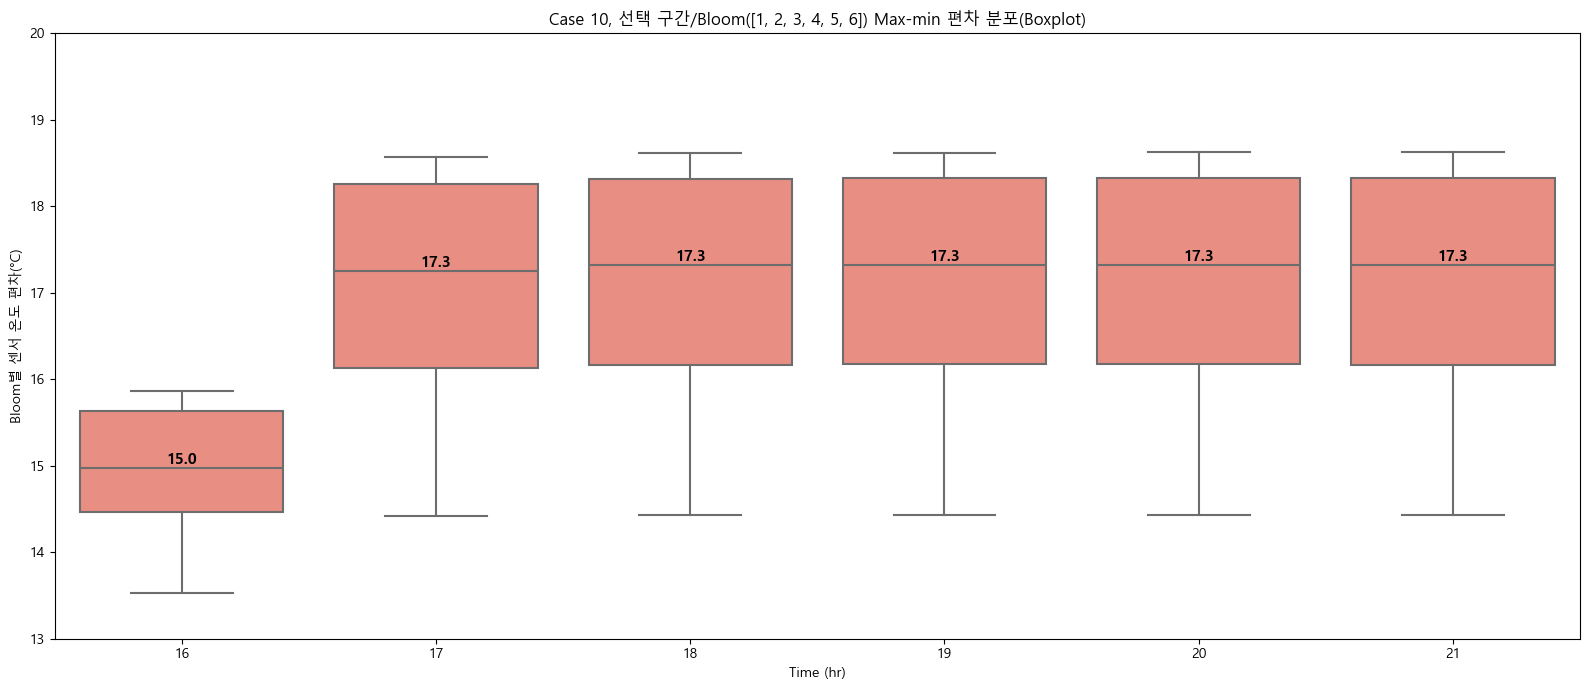


[시간별 전체 Bloom+센서 Max-Min 온도 차이 Table]



,Hour,MaxMin_Diff
0,16,23.53
1,17,24.54
2,18,24.52
3,19,24.51
4,20,24.51
5,21,24.51


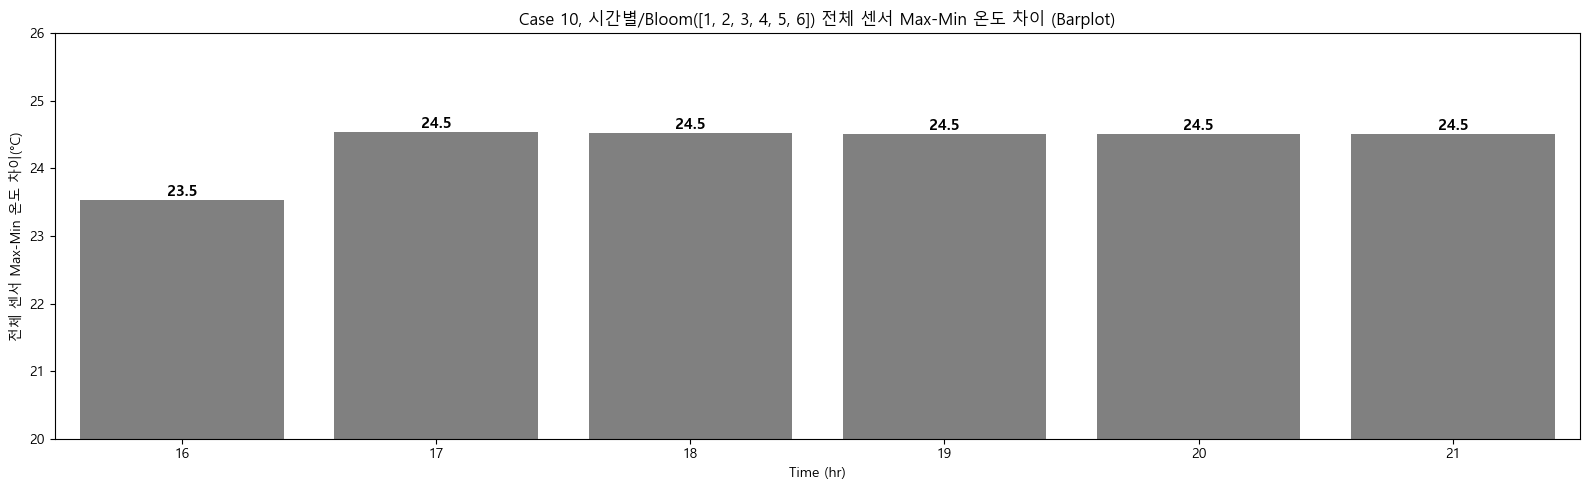

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# [1] 원본 데이터 로딩
excel_file_path = "250718_가열로 시뮬레이션 results4_가공.xlsx"
sheet_name = "Case 10"   # --- 케이스를 바꾸려면 여기만!
header_row = find_header_row(excel_file_path, sheet_name)
case_raw = pd.read_excel(excel_file_path, sheet_name=sheet_name, engine='openpyxl', header=header_row)

# [2] 시간(hr) 컬럼 생성
time_col = next((col for col in case_raw.columns if 'time' in str(col).lower()), None)
case_raw['Time_hr'] = case_raw[time_col] / 3600

# [3] Bloom 번호, 시간 구간 지정 (필요에 따라 수정)
bloom_list = list(range(1, 7))        # 예: [1,2,3,4,5,6]
intervals = [(16, 21)]                # 예: [(16, 21)]
y_range_temp = (1245, 1280)           # 온도 Boxplot Y축 범위
y_range_delta = (13, 20)               # Bloom별 편차 Boxplot Y축 범위
y_range_total = (20, 26)              # 전체 MaxMin Barplot Y축 범위

# [4] 데이터 구성
records = []
bloom_delta_records = []
for interval in intervals:
    start, end = interval
    for h in range(start, end + 1):
        idx = (case_raw['Time_hr'] - h).abs().idxmin()
        actual_hr = int(round(case_raw.loc[idx, 'Time_hr']))
        for bloom in bloom_list:
            sensor_vals = []
            for sensor in range(1, 10):
                col_name = f'Bloom {bloom} sensor {sensor}'
                if col_name in case_raw.columns:
                    value = case_raw.loc[idx, col_name]
                    records.append({'Hour': actual_hr, 'Bloom': bloom, 'Sensor': sensor, 'Value': value})
                    sensor_vals.append(value)
            if sensor_vals:
                delta = np.nanmax(sensor_vals) - np.nanmin(sensor_vals)
                bloom_delta_records.append({'Hour': actual_hr, 'Bloom': bloom, 'Delta': delta})

boxplot_df = pd.DataFrame(records)
bloom_delta_df = pd.DataFrame(bloom_delta_records)

# [5] 시간별 전체 센서 통계(describe) + max-min 값 (컬럼명 구분)
stat_table = (
    boxplot_df.groupby('Hour')['Value']
    .describe()
    .rename_axis('Hour')
    .round(2)
).reset_index()

# 별도 Max-Min(재계산) 컬럼 추가
calc_maxmin = (
    boxplot_df.groupby('Hour')['Value']
    .agg(calc_max='max', calc_min='min')
    .reset_index()
)
stat_table = pd.merge(stat_table, calc_maxmin, on='Hour')
stat_table['MaxMin_Diff'] = (stat_table['calc_max'] - stat_table['calc_min']).round(2)

print("\n[시간별 전체 Bloom 센서 온도 통계 Table + Max-Min]\n")
display(stat_table[['Hour', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'calc_min', 'calc_max', 'MaxMin_Diff']])

# [6] Boxplot: 시간별(Bloom 지정) 센서 온도 분포 (값 표기)
plt.figure(figsize=(16, 7))
ax = sns.boxplot(x='Hour', y='Value', data=boxplot_df, color='lightblue')
plt.title(f"{sheet_name}, 선택 구간/Bloom({bloom_list}) 센서(1~9) 온도 분포(Boxplot)")
plt.xlabel("Time (hr)")
plt.ylabel("센서 온도 (°C)")
plt.ylim(y_range_temp)
# --- 각 boxplot의 중앙값 표기 ---
medians = boxplot_df.groupby('Hour')['Value'].median().sort_index()
for i, median in enumerate(medians):
    plt.text(i, median, f"{median:.1f}", ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.tight_layout()
plt.show()

# [7] 시간별 Bloom별 Max-min 편차 분포(Boxplot) (값 표기)
plt.figure(figsize=(16, 7))
ax = sns.boxplot(x='Hour', y='Delta', data=bloom_delta_df, color='salmon')
plt.title(f"{sheet_name}, 선택 구간/Bloom({bloom_list}) Max-min 편차 분포(Boxplot)")
plt.xlabel("Time (hr)")
plt.ylabel("Bloom별 센서 온도 편차(°C)")
plt.ylim(y_range_delta)
# --- 중앙값 표기 ---
medians_delta = bloom_delta_df.groupby('Hour')['Delta'].median().sort_index()
for i, median in enumerate(medians_delta):
    plt.text(i, median, f"{median:.1f}", ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.tight_layout()
plt.show()

# [8] 시간별 전체 Bloom+센서에서 Max-Min 차이 계산 (Barplot, 값 표기)
hourly_maxmin = (
    boxplot_df.groupby('Hour')['Value']
    .agg(['max', 'min'])
    .reset_index()
)
hourly_maxmin['MaxMin_Diff'] = (hourly_maxmin['max'] - hourly_maxmin['min']).round(2)

print("\n[시간별 전체 Bloom+센서 Max-Min 온도 차이 Table]\n")
display(hourly_maxmin[['Hour', 'MaxMin_Diff']])

plt.figure(figsize=(16, 5))
ax = sns.barplot(x='Hour', y='MaxMin_Diff', data=hourly_maxmin, color='gray')
plt.title(f"{sheet_name}, 시간별/Bloom({bloom_list}) 전체 센서 Max-Min 온도 차이 (Barplot)")
plt.xlabel("Time (hr)")
plt.ylabel("전체 센서 Max-Min 온도 차이(°C)")
plt.ylim(y_range_total)
# --- 각 막대 위에 값 표기 ---
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"{val:.1f}", (p.get_x() + p.get_width() / 2., val), ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.tight_layout()
plt.show()
